<a href="https://colab.research.google.com/github/arunviswanathan91/ImageAnalysis/blob/main/Final_copy_of_MultiplexIF_Analysis_Suite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🔬Multiplex Immunofluorescence Analysis Suite
<div style='background:linear-gradient(135deg,#0d1b2a,#0a3d62);padding:16px 24px;border-radius:12px;display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:10px;margin-bottom:10px'>
  <div style='display:flex;align-items:center;gap:12px'>
    <span style='font-size:32px'>
    

  </div>
  <div style='display:flex;align-items:center;gap:8px;flex-wrap:wrap'>
    <span style='background:rgba(255,255,255,0.08);color:#aed6f1;font-size:0.75em;padding:4px 8px;border-radius:6px'>📂 .oir .czi .lif .nd2 .tif  | </span>
    <span style='background:rgba(255,255,255,0.08);color:#aed6f1;font-size:0.75em;padding:4px 8px;border-radius:6px'>🎨 Channel Mapper | </span>
    <span style='background:rgba(255,255,255,0.08);color:#aed6f1;font-size:0.75em;padding:4px 8px;border-radius:6px'>🧠 Cellpose-SAM | </span>
    <span style='background:rgba(255,255,255,0.08);color:#aed6f1;font-size:0.75em;padding:4px 8px;border-radius:6px'>📊 Cell Statistics</span>
  <div>
    <a href="https://colab.research.google.com/drive/1Ud3Y_YBN2NAudNDyiVo6NRUnrPKjif-B" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg"/></a>
    <a href="https://drive.google.com/uc?export=copy&id=1Ud3Y_YBN2NAudNDyiVo6NRUnrPKjif-B" target="_blank"><img src="https://img.shields.io/badge/Copy%20to%20Drive-4285F4?logo=googledrive&logoColor=white&style=flat"/></a>
  </div>
  </div>
</div>

In [ ]:
# @title ⚙️ Step 1 — Environment Setup & GPU Check
# =============================================================
# STEP 1 — Environment Setup & GPU Check
# Run this cell first.
# Runtime -> Change runtime type -> T4 GPU before starting.
# =============================================================

import subprocess, sys

print("Installing dependencies — this takes ~3 min on first run.....only run once per session...")

# -----------------------------------------------------------------------
# Image IO stack. bioio replaces aicsimageio, which no longer installs on
# Python 3.13. The whole stack goes in one pip call so the resolver picks
# a single bioio-base version that every plugin agrees on.
# -----------------------------------------------------------------------
bioio_stack = [
    'bioio',
    'bioio-bioformats>=2.0',
    'bioio-czi',
    'bioio-lif',
    'bioio-nd2',
    'bioio-tifffile',
]

print("Installing bioio image readers...")
r_io = subprocess.run([sys.executable, '-m', 'pip', 'install', *bioio_stack, '-q'],
                      capture_output=True, text=True)
if r_io.returncode != 0:
    print(f"WARNING: bioio stack failed — {r_io.stderr.strip()[:400]}")

# Native readers used as fallbacks inside read_image_universal.
pkgs = [
    'cellpose',
    'aicspylibczi',
    'readlif',
    'nd2',
    'pandas',
    'matplotlib',
    'seaborn',
    'ipywidgets',
    'openpyxl',
    'tqdm',
    'Pillow',
    'psutil',
]

for pkg in pkgs:
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f"WARNING: {pkg} failed — {r.stderr.strip()[:300]}")

!pip install cellpose --upgrade
!pip install git+https://github.com/facebookresearch/dinov3

# -----------------------------------------------------------------------
# No Java installation step. bioio-bioformats reads OIR through bffile,
# which fetches its own Java runtime and the Bio-Formats jars on first use.
# No tifffile pin either. The old pin worked around an aicsimageio bug and
# conflicts with the tifffile version cellpose 4.x requires.
# -----------------------------------------------------------------------

# -----------------------------------------------------------------------
# Force numpy 2.x last. Kept as a safety net for transitive numpy 1.x
# pulls from cellpose. bioio requires numpy 2.x itself, so the original
# aicsimageio contamination path is gone and this may be removable once
# the version report below comes back clean on a few runs.
# -----------------------------------------------------------------------
print("Force-reinstalling numpy 2.x to fix _center / umath ImportError...")
r_np = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'numpy>=2.0', '--upgrade', '--force-reinstall', '--no-cache-dir', '-q'],
    capture_output=True, text=True
)
if r_np.returncode != 0:
    print(f"WARNING: numpy reinstall failed:\n{r_np.stderr.strip()[:200]}")
else:
    print("numpy reinstalled successfully")

# Reinstall scipy and scikit-image compiled against the clean numpy 2.x.
print("Reinstalling scipy and scikit-image against clean numpy 2.x...")
r_sp = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'scipy>=1.13.1', 'scikit-image>=0.24.0',
     '--force-reinstall', '--no-cache-dir', '-q'],
    capture_output=True, text=True
)
if r_sp.returncode != 0:
    print(f"WARNING: scipy/scikit-image reinstall failed:\n{r_sp.stderr.strip()[:200]}")
else:
    print("scipy and scikit-image reinstalled successfully")

# -----------------------------------------------------------------------
# Bio-Formats warm-up. Starts the JVM and downloads the runtime and jars
# now, on the main thread, so the first OIR read and the background
# objective-metadata reader in Step 3 do not pay that cost silently.
# -----------------------------------------------------------------------
print("\nPreparing Bio-Formats (first run downloads a Java runtime and jars)...")
bf_version = None
try:
    from bffile import BioFile
    bf_version = BioFile.bioformats_version()
    print(f"  Bio-Formats {bf_version} ready")
except Exception as e:
    print(f"  WARNING: Bio-Formats unavailable — {type(e).__name__}: {e}")
    print("  OIR files will not open. If the error mentions maven or mvn,")
    print("  run:  !apt-get install -y maven   and re-run this cell.")

# -----------------------------------------------------------------------
# Version report — confirms what is actually on disk before restart.
# -----------------------------------------------------------------------
import importlib.metadata
print("\nVersions on disk (before restart):")
for pkg_name in ['numpy', 'scipy', 'scikit-image', 'tifffile', 'cellpose',
                 'bioio', 'bioio-bioformats', 'bffile']:
    try:
        print(f"  {pkg_name:<18}: {importlib.metadata.version(pkg_name)}")
    except Exception:
        print(f"  {pkg_name:<18}: not found")

print(f"  {'Bio-Formats':<18}: {bf_version if bf_version else 'NOT available — OIR reading disabled'}")

import torch
gpu_ok   = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_ok else 'Not available'

import platform, psutil
ram = psutil.virtual_memory().total / 1e9

print(f"\n{'='*55}")
print(f"  SYSTEM STATUS")
print(f"{'='*55}")
print(f"  GPU     : {gpu_name}")
print(f"  PyTorch : {torch.__version__}")
print(f"  RAM     : {ram:.1f} GB")
print(f"  Python  : {platform.python_version()}")
print(f"{'='*55}")

if not gpu_ok:
    print("\nNo GPU detected. Go to Runtime > Change runtime type > T4 GPU.")
else:
    print("\nGPU ready.")

print("\n" + "="*55)
print("  Restarting kernel to load clean package state...")
print("  When Colab says 'Your session crashed',")
print("  that is expected — go directly to Step 2.")
print("  Do NOT re-run Step 1.")
print("="*55)

# Auto-restart so there is no manual step and no risk of
# accidentally re-running Step 1 which would re-contaminate numpy.
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Installing dependencies — this takes ~3 min on first run.....only run once per session...
Installing bioio image readers...
  Cloning https://github.com/facebookresearch/dinov3 to /tmp/pip-req-build-l3542ah3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/dinov3 /tmp/pip-req-build-l3542ah3
  Resolved https://github.com/facebookresearch/dinov3 to commit 6876159a11b4df116f30f667f8c9888617df0751
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.0 MB/s eta 0:00:00
  Created wheel for dinov3: filename=dinov3-0.0.1-py3-none-any.whl size=329846 sha256=0c4585b5131e132ee142b9c41d040cbeafe8a9990ca05b72b927ca96b924784f
  Stored in directory: /tmp/pip-ephem-

cjdk: Installing JDK zulu-jre:11.0.32 to /root/.cache/cjdk
Download 100% of  40.9 MiB |#############| Elapsed Time: 0:00:00 Time:  0:00:00
Extract | |          #                              | 362 Elapsed Time: 0:00:01
  central: HTTP 404
  scijava.public: HTTP 404


  OIR files will not open. If the error mentions maven or mvn,
  run:  !apt-get install -y maven   and re-run this cell.

Versions on disk (before restart):
  numpy             : 2.5.2
  scipy             : 1.18.1
  scikit-image      : 0.26.0
  tifffile          : 2026.8.23
  cellpose          : 4.2.1.1
  bioio             : 3.5.0
  bioio-bioformats  : 2.0.0
  bffile            : 0.1.1
  Bio-Formats       : NOT available — OIR reading disabled

  SYSTEM STATUS
  GPU     : Tesla T4
  PyTorch : 2.11.0+cu128
  RAM     : 54.8 GB
  Python  : 3.13.15

GPU ready.

  Restarting kernel to load clean package state...
  When Colab says 'Your session crashed',
  that is expected — go directly to Step 2.
  Do NOT re-run Step 1.


{'status': 'ok', 'restart': True}

> Upload **one image file** per run. Supported: `.oir` `.czi` `.lif` `.nd2` `.tif` `.tiff` `.png` `.jpg`
>
> For **batch processing** of multiple files, see Step 9 at the bottom.

In [ ]:
# @title Step 2 - File Upload and Format Detection
# =============================================================
# STEP 2 - Image Source Selection
# =============================================================

# -----------------------------------------------------------------------
# Bio-Formats provisioning.
#
# bioio-bioformats reads proprietary formats through bffile, which by
# default resolves ome:formats-gpl from Maven at runtime. That resolution
# depends on the availability of Maven Central, the SciJava mirror and
# every transitive artifact, so the same notebook can read a file one day
# and fail the next. For a published protocol the reader version must be
# fixed and the network dependency removed.
#
# The jar is therefore downloaded once at a pinned version and placed
# directly on the JVM classpath. If the download is unavailable, the
# notebook falls back to Maven resolution with the OME repository added.
# -----------------------------------------------------------------------
import os, urllib.request

BIOFORMATS_PIN = '8.1.1'
BIOFORMATS_JAR = '/content/bioformats_package.jar'

os.environ.setdefault('BIOFORMATS_VERSION', BIOFORMATS_PIN)

import scyjava.config
scyjava.config.add_repositories({
    'ome': 'https://artifacts.openmicroscopy.org/artifactory/maven',
})

def _provision_bioformats():
    """Return a dict describing how Bio-Formats was made available."""
    info = {'version': BIOFORMATS_PIN, 'source': 'maven', 'jar_path': None}
    try:
        if not os.path.exists(BIOFORMATS_JAR):
            url = (f'https://downloads.openmicroscopy.org/bio-formats/'
                   f'{BIOFORMATS_PIN}/artifacts/bioformats_package.jar')
            print(f'Downloading Bio-Formats {BIOFORMATS_PIN}...')
            urllib.request.urlretrieve(url, BIOFORMATS_JAR)
            size_mb = os.path.getsize(BIOFORMATS_JAR) / 1e6
            if size_mb < 5:
                os.remove(BIOFORMATS_JAR)
                raise RuntimeError(f'incomplete download ({size_mb:.1f} MB)')
            print(f'  cached {size_mb:.1f} MB at {BIOFORMATS_JAR}')

        # bffile appends its Maven endpoints at import time, so the clear
        # has to happen after the import, not before.
        import bffile  # noqa: F401
        scyjava.config.endpoints.clear()
        scyjava.config.add_classpath(BIOFORMATS_JAR)
        info['source']   = 'vendored jar'
        info['jar_path'] = BIOFORMATS_JAR
    except Exception as exc:
        print(f'Vendored jar unavailable ({type(exc).__name__}: {exc}).')
        print('Falling back to Maven resolution.')
    return info

BIOFORMATS_INFO = _provision_bioformats()

import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt
import pandas as pd
import warnings, threading, time
warnings.filterwarnings('ignore')
from IPython.display import display, clear_output
import ipywidgets as widgets
from skimage import exposure, filters, morphology, measure, segmentation
from scipy import ndimage
import json
from collections import OrderedDict

# -- Global STATE ---------------------------------------------
STATE = {
    'raw_data':        None,
    'channels':        [],
    'n_channels':      0,
    'channel_names':   [],
    'channel_roles':   {},
    'masks':           None,
    'df':              None,
    'file_path':       '',
    'folder_path':     '',
    'folder_name':     '',
    'batch_files':     [],
    'is_batch':        False,
    'pixel_size_um':   None,
    'bit_depth':       None,
    'objective':       {'magnification': None, 'na': None, 'model': None},
    'provenance':      {},
}

SUPPORTED_EXTS = {'.oir', '.czi', '.lif', '.nd2', '.tif', '.tiff', '.png', '.jpg', '.jpeg'}

# =============================================================
# READER BACKEND
# bioio is the maintained successor to aicsimageio, which no longer
# installs on Python 3.13. The two APIs are call compatible for
# get_image_data, channel_names, physical_pixel_sizes and ome_metadata,
# so the rest of this notebook is unchanged.
# =============================================================
try:
    from bioio import BioImage as _BioImage
    _BIOIO = True
    _BACKEND = 'bioio'
except ImportError:
    from aicsimageio import AICSImage as _BioImage
    _BIOIO = False
    _BACKEND = 'aicsimageio'

def _open_bioformats(path):
    """Open a file explicitly through the Bio-Formats reader."""
    if _BIOIO:
        import bioio_bioformats
        return _BioImage(path, reader=bioio_bioformats.Reader)
    from aicsimageio.readers.bioformats_reader import BioformatsReader
    return _BioImage(path, reader=BioformatsReader)

def _record_provenance():
    """Reader configuration written to STATE so exports can cite it."""
    import importlib.metadata as _md
    def _ver(pkg):
        try: return _md.version(pkg)
        except Exception: return 'not installed'
    STATE['provenance'] = {
        'reader_backend':      _BACKEND,
        'bioio_version':       _ver('bioio'),
        'plugin_version':      _ver('bioio-bioformats'),
        'bffile_version':      _ver('bffile'),
        'bioformats_version':  BIOFORMATS_INFO['version'],
        'bioformats_source':   BIOFORMATS_INFO['source'],
    }
    return STATE['provenance']

_record_provenance()

# =============================================================
# OBJECTIVE EXTRACTION
# =============================================================
def _extract_objective_fast(path):
    """Binary text scan. No JVM, typically 1-50 ms per file."""
    result = {'magnification': None, 'na': None, 'model': None}
    try:
        with open(path, 'rb') as f:
            raw = f.read(8 * 1024 * 1024)
        import re
        texts = []
        for enc in ['utf-16-le', 'utf-8', 'latin-1']:
            try: texts.append(raw.decode(enc, errors='ignore'))
            except: pass
        for text in texts:
            if result['magnification'] is None:
                for pat in [r'"Magnification"\s*[:\s]+(\d+\.?\d*)',
                            r'Magnification[">:\s]+(\d+\.?\d*)',
                            r'<[Mm]agnification[^>]*>(\d+\.?\d*)',
                            r'lsMagnification>(\d+\.?\d*)',
                            r'NominalMagnification[^0-9]+(\d+\.?\d*)']:
                    m = re.search(pat, text)
                    if m:
                        try:
                            v = float(m.group(1))
                            if 2 <= v <= 200:
                                result['magnification'] = int(v); break
                        except: pass
            if result['na'] is None:
                for pat in [r'"NumericalAperture"\s*[:\s]+(\d+\.?\d*)',
                            r'NumericalAperture[">:\s]+(\d+\.?\d*)',
                            r'<[Nn]umerical[Aa]perture[^>]*>(\d+\.?\d*)',
                            r'lsNA>(\d+\.?\d*)', r'LensNA[^0-9]+(\d+\.?\d*)']:
                    m = re.search(pat, text)
                    if m:
                        try:
                            v = float(m.group(1))
                            if 0.01 < v < 2.0:
                                result['na'] = round(v, 3); break
                        except: pass
            if result['model'] is None:
                for pat in [r'"ObjectiveName"\s*[:\s]+"([^"]{3,30})"',
                            r'"LensName"\s*[:\s]+"([^"]{3,30})"',
                            r'lsObjectiveName>([^<]{3,30})<']:
                    m = re.search(pat, text)
                    if m:
                        name = m.group(1).strip()
                        if 3 <= len(name) <= 30:
                            result['model'] = name; break
            if result['magnification'] is not None and result['na'] is not None:
                break
    except: pass
    return result

def _extract_objective_bioformats(path):
    """OME metadata through the JVM. Authoritative but 5-15 s per file."""
    result = {'magnification': None, 'na': None, 'model': None}
    try:
        img = _BioImage(path)
        ome = img.ome_metadata
        if ome is None: return result
        for instrument in (getattr(ome, 'instruments', None) or []):
            for obj in (getattr(instrument, 'objectives', None) or []):
                mag = getattr(obj, 'nominal_magnification', None)
                na  = getattr(obj, 'lens_na', None)
                mod = getattr(obj, 'model', None)
                if mag is not None:
                    try: result['magnification'] = int(float(mag))
                    except: pass
                if na is not None:
                    try: result['na'] = round(float(na), 3)
                    except: pass
                if mod: result['model'] = str(mod).strip()
                if any(v is not None for v in result.values()): return result
    except: pass
    return result

def _extract_objective(path):
    """
    Two tier lookup. The binary scan resolves the great majority of files
    in milliseconds; the JVM path runs only when it does not, which keeps
    batch metadata reading from costing minutes per folder.
    """
    fast = _extract_objective_fast(path)
    if fast.get('magnification') is not None:
        fast['source'] = 'binary scan'
        return fast
    slow = _extract_objective_bioformats(path)
    slow['source'] = 'bioformats'
    return slow

# =============================================================
# UNIVERSAL IMAGE READER
# =============================================================
def percentile_norm(img, lo=1, hi=99.5):
    p_lo, p_hi = np.percentile(img[img > 0], [lo, hi]) if np.any(img > 0) else (0, 1)
    return np.clip((img.astype(np.float32) - p_lo) / (p_hi - p_lo + 1e-8), 0, 1)

def read_image_universal(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.oir':
        def _px(r):
            try:
                px = r.physical_pixel_sizes
                if px and px.Y:
                    v = float(px.Y)
                    return v/1000 if v>1000 else v*1e6 if v<0.001 else v
            except: pass
            return None
        errors = []
        for opener in (_BioImage, _open_bioformats):
            try:
                img = opener(path)
                data = img.get_image_data('TCZYX')
                chs = img.channel_names or [f'Ch{i}' for i in range(data.shape[1])]
                return data, chs, _px(img)
            except Exception as exc:
                errors.append(f"{type(exc).__name__}: {exc}")
        raise ValueError("OIR read failed.\n  " + "\n  ".join(errors))
    elif ext == '.czi':
        try:
            img = _BioImage(path); data = img.get_image_data('TCZYX')
            chs = img.channel_names or [f'Ch{i}' for i in range(data.shape[1])]
            try: px = img.physical_pixel_sizes; px_um = float(px.Y)*1e6 if px and px.Y else None
            except: px_um = None
            return data, chs, px_um
        except:
            from aicspylibczi import CziFile
            czi = CziFile(path); data = np.squeeze(czi.read_image()[0])
            while data.ndim < 5: data = np.expand_dims(data, 0)
            return data, [f'Ch{i}' for i in range(data.shape[1])], None
    elif ext == '.lif':
        import readlif
        lif = readlif.reader.LifFile(path); img = lif.get_image(0)
        chs = [np.array(img.get_frame(z=0,t=0,c=c,m=0)) for c in range(img.channels)]
        data = np.stack(chs)[np.newaxis,:,np.newaxis,:,:]
        return data, [f'Ch{i}' for i in range(len(chs))], None
    elif ext == '.nd2':
        import nd2; arr = nd2.imread(path)
        if arr.ndim==2: arr=arr[np.newaxis,np.newaxis,np.newaxis,:,:]
        elif arr.ndim==3: arr=arr[np.newaxis,:,np.newaxis,:,:]
        elif arr.ndim==4: arr=arr[np.newaxis].transpose(0,2,1,3,4)
        return arr, [f'Ch{i}' for i in range(arr.shape[1])], None
    elif ext in ['.tif','.tiff']:
        import tifffile
        with tifffile.TiffFile(path) as tf: arr = tf.asarray()
        if arr.ndim==2: arr=arr[np.newaxis,np.newaxis,np.newaxis,:,:]
        elif arr.ndim==3:
            arr = arr[np.newaxis,:,np.newaxis,:,:] if arr.shape[0]<=8 else arr[np.newaxis,np.newaxis,:,:,:]
        elif arr.ndim==4: arr=arr[np.newaxis]
        return arr, [f'Ch{i}' for i in range(arr.shape[1])], None
    elif ext in ['.png','.jpg','.jpeg']:
        from PIL import Image
        im = Image.open(path); arr = np.array(im)
        if arr.ndim==2: return arr[np.newaxis,np.newaxis,np.newaxis,:,:], ['Gray'], None
        names = ['Red','Green','Blue','Alpha'][:arr.shape[2]]
        stacked = np.stack([arr[:,:,i] for i in range(arr.shape[2])], axis=0)[np.newaxis,:,np.newaxis,:,:]
        return stacked, names, None
    raise ValueError(f'Unsupported format: {ext}')

def mount_drive_if_needed():
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            print("Mounting Google Drive..."); drive.mount('/content/drive'); print("Drive mounted.")
        else: print("Drive already mounted.")
        return True
    except Exception as e: print(f"Drive mount failed: {e}"); return False

def scan_folder(folder_path, recursive=True):
    found = []
    if recursive:
        for root, dirs, files in os.walk(folder_path):
            dirs.sort()
            for f in sorted(files):
                if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS:
                    full = os.path.join(root, f)
                    found.append({'path': full, 'filename': f,
                                  'folder_name': os.path.basename(root),
                                  'relative_path': os.path.relpath(full, folder_path)})
    else:
        for f in sorted(os.listdir(folder_path)):
            if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS:
                full = os.path.join(folder_path, f)
                found.append({'path': full, 'filename': f,
                              'folder_name': os.path.basename(folder_path), 'relative_path': f})
    return found

# =============================================================
# LOAD PROGRESS
# The first read of a session starts the JVM and can take a minute.
# A staged bar reports what is happening instead of leaving the cell
# apparently frozen.
# =============================================================
class LoadProgress:
    def __init__(self, stages, title='Loading'):
        self.stages = stages
        self.t0     = time.time()
        self.bar = widgets.IntProgress(
            value=0, min=0, max=len(stages), bar_style='info',
            layout=widgets.Layout(width='340px'))
        self.lbl = widgets.HTML()
        self.box = widgets.VBox(
            [widgets.HTML(f"<span style='font-size:12px;font-weight:bold;"
                          f"color:#7ecef4'>{title}</span>"),
             widgets.HBox([self.bar, self.lbl],
                          layout=widgets.Layout(align_items='center', gap='10px'))],
            layout=widgets.Layout(margin='4px 0 10px 0'))
        display(self.box)

    def step(self, index):
        self.bar.value = index
        if index < len(self.stages):
            self.lbl.value = (f"<span style='font-size:11px;color:#aaaaaa'>"
                              f"{self.stages[index]}</span>")

    def done(self):
        self.bar.value      = self.bar.max
        self.bar.bar_style  = 'success'
        elapsed = time.time() - self.t0
        self.lbl.value = (f"<span style='font-size:11px;color:#2ecc71'>"
                          f"Complete in {elapsed:.1f} s</span>")
        return elapsed

    def fail(self, message):
        self.bar.bar_style = 'danger'
        self.lbl.value = (f"<span style='font-size:11px;color:#e74c3c'>"
                          f"{message}</span>")

# =============================================================
# METADATA PANEL
# =============================================================
def _metadata_panel(rows, title):
    cells = []
    for label, value in rows:
        cells.append(
            "<tr>"
            "<td style='padding:4px 14px 4px 10px;color:#8899a6;"
            "font-size:11px;white-space:nowrap;vertical-align:top'>"
            f"{label}</td>"
            "<td style='padding:4px 10px;color:#e8f4fd;font-size:11px;"
            "font-family:monospace;word-break:break-word'>"
            f"{value}</td>"
            "</tr>")
    return widgets.HTML(
        "<div style='border:1px solid #2d5f8a;border-radius:6px;"
        "background:#111820;padding:0;margin:6px 0 12px;max-width:760px'>"
        "<div style='padding:8px 10px;border-bottom:1px solid #2d5f8a;"
        "color:#7ecef4;font-size:12px;font-weight:bold'>"
        f"{title}</div>"
        "<table style='border-collapse:collapse;width:100%'>"
        + ''.join(cells) +
        "</table></div>")

# =============================================================
# FINALIZE
# =============================================================
def finalize_single_file(path, folder_name='', keep_batch=False):
    with main_out:
        clear_output()
        prog = LoadProgress(
            ['Opening file and reading pixel data',
             'Reading objective metadata',
             'Building channel projections',
             'Rendering preview'],
            title=f'Loading {os.path.basename(path)}')
        try:
            prog.step(0)
            data, ch_names, px_um = read_image_universal(path)
            T, C, Z, Y, X = data.shape
            effective_folder = folder_name or os.path.basename(os.path.dirname(path)) or 'unknown'

            prog.step(1)
            obj_info = _extract_objective(path)
            STATE['objective'] = obj_info
            STATE.update({'raw_data': data, 'n_channels': C, 'channel_names': ch_names,
                          'pixel_size_um': px_um, 'bit_depth': str(data.dtype),
                          'file_path': path, 'folder_name': effective_folder,
                          'folder_path': os.path.dirname(path),
                          'is_batch': STATE.get('is_batch', False) if keep_batch else False})

            prog.step(2)
            IJ = {'Blue':[0,0,1],'Green':[0,1,0],'Red':[1,0,0],
                  'Magenta':[1,0,1],'Cyan':[0,1,1],'Yellow':[1,1,0],'Gray':[1,1,1]}
            luts = ['Blue','Green','Red','Magenta','Cyan','Yellow','Gray']
            def _rgb(ch2d, c):
                lut=np.array(IJ.get(c,[1,1,1]),dtype=np.float32)
                flat=ch2d[ch2d>0].astype(np.float32)
                lo=float(np.percentile(flat,1)) if len(flat) else 0
                hi=float(np.percentile(flat,99.5)) if len(flat) else float(ch2d.max())
                norm=np.clip((ch2d.astype(np.float32)-lo)/(hi-lo+1e-8),0,1)
                return (norm[:,:,None]*lut[None,None,:]*255).clip(0,255).astype(np.uint8)
            pl,ll=[],[]
            for i in range(C):
                r=data[0,i,:,:,:]; pl.append(r.max(axis=0) if Z>1 else r[0]); ll.append(luts[i%len(luts)])
            H,W=pl[0].shape; comp=np.zeros((H,W,3),np.float32)
            for ch2d,ln in zip(pl,ll):
                c=np.array(IJ.get(ln,[1,1,1]),np.float32); flat=ch2d[ch2d>0].astype(np.float32)
                lo=float(np.percentile(flat,1)) if len(flat) else 0
                hi=float(np.percentile(flat,99.5)) if len(flat) else float(ch2d.max())
                norm=np.clip((ch2d.astype(np.float32)-lo)/(hi-lo+1e-8),0,1)
                comp[:,:,0]+=norm*c[0]; comp[:,:,1]+=norm*c[1]; comp[:,:,2]+=norm*c[2]
            comp=(np.clip(comp,0,1)*255).astype(np.uint8)

            prog.step(3)
            elapsed = prog.done()

            mag, na, model = obj_info['magnification'], obj_info['na'], obj_info['model']
            obj_str = (f"{mag}x" + (f", NA {na}" if na else '') +
                       (f", {model}" if model else '')) if mag else "Not found in metadata"
            ch_display = ', '.join(str(c) for c in ch_names)
            fov_str = (f"{X * px_um:.1f} x {Y * px_um:.1f} um"
                       if px_um else 'Not available')
            prov = STATE.get('provenance', {})

            display(_metadata_panel([
                ('File',           os.path.basename(path)),
                ('Sample label',   effective_folder),
                ('Dimensions',     f"T={T}  C={C}  Z={Z}  Y={Y}  X={X}"),
                ('Bit depth',      str(data.dtype)),
                ('Pixel size',     f"{px_um:.4f} um" if px_um else 'Not in metadata'),
                ('Field of view',  fov_str),
                ('Objective',      obj_str),
                ('Channel names',  ch_display),
                ('Load time',      f"{elapsed:.1f} s"),
            ], 'File information'))

            display(_metadata_panel([
                ('Reader backend',     f"{prov.get('reader_backend')} "
                                       f"{prov.get('bioio_version')}"),
                ('Bio-Formats',        f"{prov.get('bioformats_version')} "
                                       f"({prov.get('bioformats_source')})"),
                ('Objective metadata', obj_info.get('source', 'not determined')),
            ], 'Provenance'))

            n=C+1; fig,axes=plt.subplots(1,n,figsize=(3.5*n,3.8))
            if n==1: axes=[axes]
            for i,(ch2d,ln) in enumerate(zip(pl,ll)):
                axes[i].imshow(_rgb(ch2d,ln))
                auto=str(ch_names[i]) if i<len(ch_names) else f'Ch{i}'
                axes[i].set_title(f'Ch{i}: {auto}\n{ln} | max={int(ch2d.max())}',fontsize=8,color='white')
                axes[i].axis('off')
            axes[-1].imshow(comp)
            axes[-1].set_title(f'Composite\nZ-max ({Z} slices)',fontsize=8,color='white')
            axes[-1].axis('off')
            fig.patch.set_facecolor('#0d1117')
            plt.suptitle(f'{os.path.basename(path)}  |  {f"{mag}x  " if mag else ""}{C} ch  |  {Y}x{X}px  |  {data.dtype}\n'
                         f'LUT colors are sequential guesses. Assign correct ones in Step 3.',
                         fontsize=9,color='#7ecef4',y=1.02)
            plt.tight_layout(); plt.show()
            print("\nLoaded. Run Step 3 to assign correct channel names and LUTs.")
        except Exception as exc:
            prog.fail(f"{type(exc).__name__}")
            raise

# =============================================================
# UI
# =============================================================
print("=======================================================")
print("             IMAGE SOURCE SELECTION")
print("=======================================================")
print(f"  Reader        : {STATE['provenance']['reader_backend']} "
      f"{STATE['provenance']['bioio_version']}")
print(f"  Bio-Formats   : {BIOFORMATS_INFO['version']} ({BIOFORMATS_INFO['source']})")
print("=======================================================")

mode_toggle = widgets.ToggleButtons(
    options=[('Upload file','upload'),
             ('Google Drive - single file','drive_single'),
             ('Google Drive - folder (batch)','drive_folder')],
    value='upload', style={'button_width':'230px','font_weight':'bold'})

upload_btn = widgets.Button(description='Click to upload', button_style='info',
                             layout=widgets.Layout(width='200px', height='40px'))
upload_out = widgets.Output()
upload_panel = widgets.VBox([
    widgets.HTML("<div style='color:#aed6f1;font-size:11px;margin:6px 0'>"
                 "Upload directly from your computer.</div>"),
    upload_btn, upload_out])

drive_single_path = widgets.Text(
    placeholder='/content/drive/MyDrive/experiments/sample1/1.oir',
    layout=widgets.Layout(width='580px'))
drive_single_load = widgets.Button(description='Load file', button_style='primary',
                                    layout=widgets.Layout(width='120px', height='36px'))
drive_single_panel = widgets.VBox([
    widgets.HTML("<div style='font-size:11px;color:#7ecef4;margin-bottom:4px'>"
                 "Full path to a single image file on Google Drive</div>"),
    widgets.HBox([drive_single_path, drive_single_load])])

drive_folder_path = widgets.Text(
    placeholder='/content/drive/MyDrive/experiments/cohort_A/',
    layout=widgets.Layout(width='520px'))
drive_folder_scan = widgets.Button(description='Scan folder', button_style='warning',
                                    layout=widgets.Layout(width='140px', height='36px'))
drive_folder_recursive = widgets.Checkbox(value=True,
    description='Recursive (include subfolders)', layout=widgets.Layout(width='280px'))
drive_folder_load = widgets.Button(description='Load first file (preview)',
                                    button_style='primary',
                                    layout=widgets.Layout(width='220px', height='36px'),
                                    disabled=True)
folder_scan_msg  = widgets.Output()
scan_result_area = widgets.VBox([])

drive_folder_panel = widgets.VBox([
    widgets.HTML("<div style='font-size:11px;color:#7ecef4;margin-bottom:4px'>"
                 "Path to folder on Google Drive. Scans recursively for image files.</div>"),
    widgets.HBox([drive_folder_path, drive_folder_scan]),
    drive_folder_recursive, folder_scan_msg, scan_result_area,
    widgets.HTML('<br>'), drive_folder_load])

main_out  = widgets.Output()
panel_box = widgets.VBox([upload_panel])

def switch_panel(change):
    mode = change['new']
    if mode == 'upload':       panel_box.children = [upload_panel]
    elif mode == 'drive_single': mount_drive_if_needed(); panel_box.children = [drive_single_panel]
    elif mode == 'drive_folder': mount_drive_if_needed(); panel_box.children = [drive_folder_panel]
mode_toggle.observe(switch_panel, names='value')

# =============================================================
# FOLDER SCAN
# =============================================================
def on_folder_scan(b):
    scan_result_area.children = []
    drive_folder_load.disabled = True
    with folder_scan_msg: clear_output()

    folder = drive_folder_path.value.strip()
    if not folder or not os.path.isdir(folder):
        with folder_scan_msg: print(f"Folder not found: '{folder}'"); return

    files = scan_folder(folder, recursive=drive_folder_recursive.value)
    if not files:
        with folder_scan_msg: print(f"No supported image files found in: {folder}"); return

    fg = OrderedDict()
    for fi in files: fg.setdefault(fi['folder_name'], []).append(fi)

    file_cbs  = {}
    obj_cells = {}
    all_cbs   = []

    sel_label = widgets.HTML(
        value=f"<b>{len(files)}</b> / {len(files)} files selected")

    def _update_count(*args):
        n = sum(1 for c in all_cbs if c.value)
        sel_label.value = f"<b>{n}</b> / {len(files)} files selected"

    sel_all_btn   = widgets.Button(description='Select All',   button_style='',
                                    layout=widgets.Layout(width='100px', height='28px'))
    desel_all_btn = widgets.Button(description='Deselect All', button_style='',
                                    layout=widgets.Layout(width='100px', height='28px'))

    def _sel_all(b):
        for c in all_cbs: c.value = True
    def _desel_all(b):
        for c in all_cbs: c.value = False
    sel_all_btn.on_click(_sel_all)
    desel_all_btn.on_click(_desel_all)

    top_bar = widgets.HBox(
        [sel_all_btn, desel_all_btn, widgets.HTML("&nbsp;"), sel_label],
        layout=widgets.Layout(align_items='center', margin='0 0 8px 0'))

    # -- Optional objective metadata reading ------------------
    # Not run automatically. The two tier extractor resolves most files
    # from the binary header in milliseconds, but any file that needs the
    # Bio-Formats fallback costs several seconds, so the user starts it.
    _n = len(files)

    meta_bar = widgets.IntProgress(
        value=0, min=0, max=_n, description='',
        bar_style='info', layout=widgets.Layout(width='320px'))
    meta_lbl = widgets.HTML(value='')
    meta_count = widgets.HTML(value='')
    meta_progress_row = widgets.VBox(
        [widgets.HBox([meta_bar, meta_count],
                      layout=widgets.Layout(align_items='center', gap='10px')),
         meta_lbl])
    meta_progress_row.layout.display = 'none'

    read_obj_btn = widgets.Button(
        description='Read Objective Metadata',
        button_style='warning',
        layout=widgets.Layout(width='220px', height='34px'))
    read_obj_out = widgets.Output()

    warning_html = widgets.HTML(
        "<div style='font-size:11px;padding:6px 10px;background:#2d1f00;"
        "border-left:3px solid #f39c12;border-radius:4px;color:#f0a500;"
        "margin:6px 0'>"
        f"Reads the objective for each of the {_n} file(s). Most files "
        "resolve from the file header in milliseconds. Files that do not "
        "fall back to Bio-Formats and take several seconds each. "
        "This runs in the background, so you can confirm your selection "
        "and proceed while it works.</div>")

    meta_row = widgets.VBox(
        [widgets.HBox([read_obj_btn,
                       widgets.HTML("&nbsp;"),
                       widgets.HTML("<span style='font-size:11px;color:#888888'>"
                                    "Optional. Objective information is not "
                                    "required for analysis.</span>")],
                      layout=widgets.Layout(align_items='center')),
         warning_html,
         meta_progress_row,
         read_obj_out],
        layout=widgets.Layout(margin='4px 0 10px 0'))

    def _start_obj_reading(b):
        read_obj_btn.disabled    = True
        read_obj_btn.description = 'Reading...'
        meta_progress_row.layout.display = ''

        def _read_objectives():
            n_files = len(files)
            t0      = time.time()
            n_fast  = 0
            n_slow  = 0
            n_fail  = 0
            for i, finfo in enumerate(files):
                fname_short = finfo['folder_name'] + '/' + finfo['filename']
                meta_lbl.value = (
                    "<span style='font-size:11px;color:#aaaaaa'>"
                    + f"Reading {fname_short}</span>")
                try:
                    obj = _extract_objective(finfo['path'])
                    mag = obj.get('magnification')
                    na  = obj.get('na')
                    if obj.get('source') == 'binary scan': n_fast += 1
                    else:                                  n_slow += 1
                    if mag:
                        txt   = str(mag) + "x" + (" NA " + str(na) if na else '')
                        color = '#2ecc71'
                    else:
                        txt   = 'Not in metadata'
                        color = '#e67e22'
                    obj_cells[finfo['path']].value = (
                        f"<span style='font-size:11px;color:{color};"
                        f"white-space:nowrap'>{txt}</span>")
                except Exception:
                    n_fail += 1
                    obj_cells[finfo['path']].value = (
                        "<span style='font-size:11px;color:#e74c3c;"
                        "white-space:nowrap'>Error</span>")
                meta_bar.value = i + 1
                elapsed  = time.time() - t0
                per_file = elapsed / (i + 1)
                remain   = per_file * (n_files - i - 1)
                meta_count.value = (
                    "<span style='font-size:11px;color:#aaaaaa'>"
                    f"{i+1} / {n_files}  |  {elapsed:.0f} s elapsed  |  "
                    f"about {remain:.0f} s remaining</span>")

            meta_bar.bar_style = 'success'
            total = time.time() - t0
            meta_count.value = (
                "<span style='font-size:11px;color:#2ecc71'>"
                f"{n_files} / {n_files} complete in {total:.0f} s</span>")
            meta_lbl.value = (
                "<span style='font-size:11px;color:#888888'>"
                f"{n_fast} from file header, {n_slow} via Bio-Formats"
                + (f", {n_fail} failed" if n_fail else "") + "</span>")
            read_obj_btn.description = 'Complete'

        t = threading.Thread(target=_read_objectives, daemon=True)
        t.start()

    read_obj_btn._click_handlers.callbacks.clear()
    read_obj_btn.on_click(_start_obj_reading)

    # -- Table header -----------------------------------------
    _hdr_line = f"{'#':>3}.  {'Filename':<16}  {'Folder':<12}  {'Relative path'}"
    import html as _html2
    table_header = widgets.HBox([
        widgets.HTML("", layout=widgets.Layout(width='28px')),
        widgets.HTML(
            "<code style='font-size:11px;font-weight:bold;color:#aaaaaa;white-space:nowrap'>"
            + _html2.escape(_hdr_line) + "</code>"
            + "<code style='font-size:11px;font-weight:bold;color:#aaaaaa;"
            "margin-left:20px'>Objective</code>",
            layout=widgets.Layout(flex='1')),
    ], layout=widgets.Layout(
        padding='4px 8px', background='#252535',
        border_bottom='2px solid #444444'))

    all_group_rows = [table_header]
    row_num = 0

    for subfolder_name, sffiles in fg.items():
        gcb = widgets.Checkbox(value=True, description='', indent=False,
                               layout=widgets.Layout(width='28px'))
        g_sel   = widgets.Button(description='Select',   button_style='',
                                  layout=widgets.Layout(width='65px', height='24px'))
        g_desel = widgets.Button(description='Deselect', button_style='',
                                  layout=widgets.Layout(width='70px', height='24px'))
        g_label = widgets.HTML(
            f"<span style='font-size:12px;font-weight:bold;color:#7ecef4'>"
            f"  {subfolder_name}"
            f"</span>"
            f"<span style='font-size:11px;color:#888888'>"
            f"  ({len(sffiles)} file(s))</span>")

        group_header = widgets.HBox(
            [gcb, g_label, g_sel, g_desel],
            layout=widgets.Layout(
                padding='5px 8px', margin='4px 0 0 0',
                border_top='1px solid #333333',
                align_items='center'))
        all_group_rows.append(group_header)

        this_cbs = []
        for finfo in sffiles:
            row_num += 1
            cb = widgets.Checkbox(value=True, description='', indent=False,
                                   layout=widgets.Layout(width='28px'))
            file_cbs[finfo['path']] = cb
            this_cbs.append(cb)
            all_cbs.append(cb)
            cb.observe(_update_count, names='value')

            obj_w = widgets.HTML(
                "<span style='font-size:11px;color:#555555'>-</span>",
                layout=widgets.Layout(width='120px', min_width='120px'))
            obj_cells[finfo['path']] = obj_w

            import html as _html
            fn_  = finfo['filename'][:16]
            fld_ = finfo['folder_name'][:12]
            rel_ = finfo['relative_path'][:22]
            line = (f"{row_num:3d}.  "
                    f"{fn_:<16}  "
                    f"{fld_:<12}  "
                    f"{rel_}")
            info_w = widgets.HTML(
                "<code style='font-size:11px;color:#cccccc;letter-spacing:0;white-space:nowrap'>"
                + _html.escape(line) + "</code>",
                layout=widgets.Layout(width='480px', min_width='480px'))

            row = widgets.HBox(
                [cb, info_w, obj_w],
                layout=widgets.Layout(align_items='center', padding='2px 8px',
                                      flex_flow='row nowrap'))
            all_group_rows.append(row)

        def _make_group_obs(cbs):
            def obs(ch):
                for c in cbs: c.value = ch['new']
            return obs
        gcb.observe(_make_group_obs(this_cbs), names='value')

        def _make_sel(cbs):
            def fn(b):
                for c in cbs: c.value = True
            return fn
        def _make_desel(cbs):
            def fn(b):
                for c in cbs: c.value = False
            return fn
        g_sel.on_click(_make_sel(this_cbs))
        g_desel.on_click(_make_desel(this_cbs))

    table_box = widgets.VBox(
        all_group_rows,
        layout=widgets.Layout(
            border='1px solid #333333', border_radius='6px',
            max_height='3000px', overflow_y='auto',
            display='flex', flex_flow='column nowrap'))

    confirm_btn = widgets.Button(description='Confirm selection',
                                  button_style='success',
                                  layout=widgets.Layout(width='200px', height='38px'))
    confirm_status = widgets.HTML(value='')

    def on_confirm(b):
        selected = [fi for fi in files if file_cbs[fi['path']].value]
        if not selected:
            confirm_status.value = "<span style='color:#e74c3c'>Select at least one file.</span>"
            drive_folder_load.disabled = True
            return
        STATE['batch_files'] = selected
        STATE['is_batch']    = len(selected) > 1
        STATE['folder_path'] = folder
        STATE['folder_name'] = os.path.basename(folder.rstrip('/'))
        drive_folder_load.disabled = False
        lines = [f"<span style='color:#2ecc71;font-weight:bold'>"
                 f"{len(selected)} file(s) confirmed</span><br>"]
        for f in selected:
            lines.append(f"<span style='font-size:11px;color:#aaaaaa'>"
                         f"  {f['folder_name']}/{f['filename']}</span><br>")
        lines.append("<br><span style='font-size:11px;color:#7ecef4'>"
                     "Click 'Load first file (preview)' to configure channels in Step 3.</span>")
        confirm_status.value = ''.join(lines)

    confirm_btn._click_handlers.callbacks.clear()
    confirm_btn.on_click(on_confirm)

    scan_result_area.children = [
        widgets.HTML(
            f"<div style='font-weight:bold;font-size:12px;margin:4px 0 2px'>"
            f"Found {len(files)} image file(s)</div>"
            f"<div style='font-size:11px;color:#888888;margin-bottom:6px'>"
            f"<code style='font-size:10px'>{folder}</code></div>"),
        top_bar,
        meta_row,
        table_box,
        widgets.HTML('<br>'),
        confirm_btn,
        confirm_status,
        widgets.HTML("<div style='font-size:11px;color:#555555;margin-top:8px'>"
                     "Folder name is used as the sample label in exports. "
                     "Filenames such as '1.oir' carry no biological information.</div>"),
    ]

drive_folder_scan._click_handlers.callbacks.clear()
drive_folder_scan.on_click(on_folder_scan)

def on_folder_load_first(b):
    files = STATE.get('batch_files', [])
    if not files:
        with main_out: clear_output(); print("Confirm your file selection first."); return
    first = files[0]
    finalize_single_file(first['path'], folder_name=first['folder_name'], keep_batch=True)

drive_folder_load._click_handlers.callbacks.clear()
drive_folder_load.on_click(on_folder_load_first)

def on_upload_click(b):
    with upload_out:
        clear_output()
        from google.colab import files as colab_files
        print("Select file to upload...")
        uploaded = colab_files.upload()
        if not uploaded: print("No file uploaded."); return
        fname = list(uploaded.keys())[0]
        finalize_single_file(fname, folder_name=os.path.splitext(fname)[0])

upload_btn._click_handlers.callbacks.clear()
upload_btn.on_click(on_upload_click)

def on_drive_single_load(b):
    path = drive_single_path.value.strip()
    if not path:
        with main_out: clear_output(); print("Enter a file path first."); return
    if not os.path.exists(path):
        with main_out: clear_output(); print(f"File not found: {path}"); return
    finalize_single_file(path, folder_name=os.path.basename(os.path.dirname(path)))

drive_single_load._click_handlers.callbacks.clear()
drive_single_load.on_click(on_drive_single_load)

# =============================================================
# RENDER
# =============================================================
display(widgets.HTML(
    "<div style='color:#aed6f1;font-size:11px;margin:6px 0 10px'>"
    "Select how to load your image(s). "
    "For batch processing use <b>Google Drive - folder</b>. "
    "The folder name is used as sample and condition metadata, because "
    "microscope filenames such as <code>1.oir</code> carry no biological "
    "information."
    "</div>"))
display(mode_toggle)
display(panel_box)
display(main_out)

             IMAGE SOURCE SELECTION
  Reader        : bioio 3.5.0
  Bio-Formats   : 8.1.1 (vendored jar)


HTML(value="<div style='color:#aed6f1;font-size:11px;margin:6px 0 10px'>Select how to load your image(s). For …

ToggleButtons(options=(('Upload file', 'upload'), ('Google Drive - single file', 'drive_single'), ('Google Dri…

Output()

Mounting Google Drive...
Mounted at /content/drive
Drive mounted.
Drive already mounted.


 > **Assign roles to each channel.** works for any number of channels and any experiment type.

> Set **Nuclei/DAPI** channel first (required for segmentation). Then name your markers freely.

In [ ]:
# @title 🎨 STEP 3 - Channel Mapper
# STEP 3: Channel Configuration
# Handles: single file | batch-same | batch-by-folder | batch-per-file
# Napari REMOVED: pure numpy/PIL renderer (no GPU conflict, no segfault)
# ============================================================
import io, base64, os
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage

print("Channel configuration ready (numpy/PIL renderer)")

# ── Constants ─────────────────────────────────────────────────
COLOR_OPTIONS = ['Blue','Cyan','Green','Yellow','Red','Magenta','Orange','Gray','White']
ROLE_OPTIONS  = (
    ['-- Skip (TD/Brightfield) --',
     'Nuclei / DAPI (required for segmentation)',
     'Pan-cellular marker (optional, whole-cell segmentation)'] +
    [f'Marker {i+1}' for i in range(12)]
)

# ── LUT / role guessers ───────────────────────────────────────
def guess_lut(name, i):
    n = str(name).upper()
    if any(k in n for k in ['DAPI','HOECHST','405','BLUE']):    return 'Blue'
    if any(k in n for k in ['GFP','FITC','488','GREEN','GZB']): return 'Green'
    if any(k in n for k in ['561','568','594','CY3','RED']):     return 'Red'
    if any(k in n for k in ['647','680','CY5','APC','FAR']):     return 'Magenta'
    if any(k in n for k in ['TD','BF','TRANS','DIC','PMT']):     return 'Gray'
    return ['Blue','Green','Red','Magenta','Cyan','Yellow'][i % 6]

def guess_role(lut, i, C):
    if lut == 'Blue': return 'Nuclei / DAPI (required for segmentation)'
    if lut == 'Gray': return '-- Skip (TD/Brightfield) --'
    r = f'Marker {min(i+1, 12)}'
    return r if r in ROLE_OPTIONS else 'Marker 1'

# ── Downsampler - display only, never touches analysis data ───
THUMB_MAX_PX = 220

def _ds(ch_2d, max_px=THUMB_MAX_PX):
    H, W  = ch_2d.shape
    scale = max(1, max(H, W) // max_px)
    return ch_2d[::scale, ::scale]

# ── IJ color table ────────────────────────────────────────────
_IJ_COLORS = {
    'blue':    [0, 0, 1],
    'cyan':    [0, 1, 1],
    'green':   [0, 1, 0],
    'yellow':  [1, 1, 0],
    'red':     [1, 0, 0],
    'magenta': [1, 0, 1],
    'orange':  [1, .5, 0],
    'gray':    [1, 1, 1],
    'white':   [1, 1, 1],
}

# ── IJ-style LUT thumbnail (zero=black, max=pure color) ──────
def ij_lut_b64(ch_2d, color_name, size=160):
    lut  = np.array(_IJ_COLORS.get(color_name.lower(), [1,1,1]), dtype=np.float32)
    flat = ch_2d[ch_2d > 0].astype(np.float32)
    p_lo = float(np.percentile(flat, 1))    if len(flat) else 0.0
    p_hi = float(np.percentile(flat, 99.5)) if len(flat) else float(ch_2d.max())
    norm = np.clip((ch_2d.astype(np.float32) - p_lo) / (p_hi - p_lo + 1e-8), 0, 1)
    rgb  = (norm[:,:,None] * lut[None,None,:] * 255).clip(0, 255).astype(np.uint8)
    pil  = PILImage.fromarray(rgb, 'RGB').resize((size, size), PILImage.LANCZOS)
    buf  = io.BytesIO(); pil.save(buf, 'PNG'); buf.seek(0)
    return base64.b64encode(buf.read()).decode()

# ── IJ composite - additive blend, numpy only ─────────────────
def ij_composite_b64(proj_ds_list, lut_list, size=300):
    H, W = proj_ds_list[0].shape
    rgb  = np.zeros((H, W, 3), np.float32)
    for ch, lut in zip(proj_ds_list, lut_list):
        c    = np.array(_IJ_COLORS.get(lut.lower(), [1,1,1]), np.float32)
        flat = ch[ch > 0].astype(np.float32)
        p_lo = float(np.percentile(flat, 1))    if len(flat) else 0.0
        p_hi = float(np.percentile(flat, 99.5)) if len(flat) else float(ch.max())
        norm = np.clip((ch.astype(np.float32) - p_lo) / (p_hi - p_lo + 1e-8), 0, 1)
        rgb[:,:,0] += norm * c[0]
        rgb[:,:,1] += norm * c[1]
        rgb[:,:,2] += norm * c[2]
    rgb = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    pil = PILImage.fromarray(rgb, 'RGB').resize((size, size), PILImage.LANCZOS)
    buf = io.BytesIO(); pil.save(buf, 'PNG'); buf.seek(0)
    return base64.b64encode(buf.read()).decode()

# ── Render one file → projected channels + thumbnails ─────────
def render_file_ij(path):
    """
    Pure numpy/PIL renderer - no Qt, no GPU conflict.
    Returns: (proj_full, ch_shots_b64, comp_b64, ch_names, luts, C, data)
    proj_full = list of full-res 2D arrays (for analysis)
    ch_shots  = list of b64 PNG thumbnails per channel
    comp_b64  = b64 PNG composite thumbnail
    """
    data, ch_names, px_um = read_image_universal(path)
    T, C, Z, Y, X = data.shape

    proj_full, proj_ds, luts = [], [], []
    for i in range(C):
        ch_raw = data[0, i, :, :, :]
        full   = ch_raw.max(axis=0) if Z > 1 else ch_raw[0]
        proj_full.append(full)
        proj_ds.append(_ds(full))
        luts.append(guess_lut(str(ch_names[i]) if i < len(ch_names) else f'Ch{i}', i))

    ch_shots = [ij_lut_b64(proj_ds[i], luts[i], size=160) for i in range(C)]
    comp_b64 = ij_composite_b64(proj_ds, luts, size=300)

    scale = max(1, max(Y, X) // THUMB_MAX_PX)
    print(f"   {C} channels | {Y}x{X}px | {data.dtype} | display 1/{scale}x of full-res")
    return proj_full, ch_shots, comp_b64, ch_names, luts, C, data

# ── Batch: load one file, return downsampled projections only ─
def load_first_projected(path):
    data, ch_names, _ = read_image_universal(path)
    T, C, Z, Y, X = data.shape
    proj_ds = []
    for i in range(C):
        ch_raw = data[0, i, :, :, :]
        full   = ch_raw.max(axis=0) if Z > 1 else ch_raw[0]
        proj_ds.append(_ds(full))
    del data
    return proj_ds, ch_names, C

# ─────────────────────────────────────────────────────────────
# DETERMINE MODE
# ─────────────────────────────────────────────────────────────
is_batch    = STATE.get('is_batch', False)
batch_files = STATE.get('batch_files', [])

print()
print("╔════════════════════════════════════════════════════════╗")
print("║          CHANNEL CONFIGURATION PANEL                   ║")
print("╚════════════════════════════════════════════════════════╝")

# ═════════════════════════════════════════════════════════════
# SINGLE FILE MODE
# ═════════════════════════════════════════════════════════════
if not is_batch:
    print("  Mode: Single file")
    print(f"  File: {STATE['file_path']}")
    print()
    print("Rendering channel thumbnails...")

    proj_full, ch_shots, comp_b64, ch_names, gluts, C, _data = \
        render_file_ij(STATE['file_path'])

    STATE['_projected'] = proj_full

    rows = []

    # Composite header
    rows.append(widgets.HTML(
        f"<div style='text-align:center;padding:10px 0'>"
        f"<div style='font-weight:bold;font-size:12px;margin-bottom:6px'>"
        f"Composite preview (IJ additive blend)</div>"
        f"<img src='data:image/png;base64,{comp_b64}' "
        f"style='width:300px;height:300px;border:3px solid #3498db;"
        f"border-radius:12px;background:#000'/>"
        f"<div style='font-size:10px;color:#555;margin-top:6px'>"
        f"Thumbnail is downsampled, full-res used for all analysis</div></div>"
    ))
    rows.append(widgets.HTML(
        "<div style='font-size:11px;padding:6px 12px;"
        "background:#332b12;color:#f5d78e;border-radius:6px;margin:6px 0;"
        "border-left:3px solid #f39c12'>"
        "Type the <b>biological name</b> for each channel exactly as it should "
        "appear in figures and exports (e.g. <code>DAPI</code>, <code>CD8</code>, "
        "<code>GZB</code>). Leave blank to use auto-detected name.</div>"
    ))
    rows.append(widgets.HTML(
        "<div style='font-size:11px;padding:6px 12px;"
        "background:#2a2410;color:#f0d17a;border-radius:6px;margin:6px 0;"
        "border-left:3px solid #f39c12'>"
        "<b>Pan-cellular marker (optional):</b> only assign this role to a stain "
        "that labels every cell type in the tissue, such as a membrane or "
        "cytoplasm dye like WGA, pan-cadherin, or Na/K-ATPase. Do not use a "
        "lineage or functional marker such as CD8 or TIM3 here, since cells "
        "that do not express it will be missed during segmentation."
        "</div>"
    ))

    role_dds=[]; name_tbs=[]; color_dds=[]; include_cbs=[]

    for i in range(C):
        auto     = str(ch_names[i]) if i < len(ch_names) else f'Ch{i}'
        def_lut  = gluts[i]
        def_role = guess_role(def_lut, i, C)

        thumb = widgets.HTML(
            f"<div style='text-align:center'>"
            f"<img src='data:image/png;base64,{ch_shots[i]}' "
            f"style='width:160px;height:160px;border:2px solid #aaa;"
            f"border-radius:6px;background:#000'/>"
            f"<div style='font-size:9px;color:#555;margin-top:3px'>"
            f"Ch{i} · {auto}<br>"
            f"min={int(proj_full[i].min())} max={int(proj_full[i].max())}<br>"
            f"{proj_full[i].dtype}</div></div>"
        )
        role_dd    = widgets.Dropdown(options=ROLE_OPTIONS, value=def_role,
                                      layout=widgets.Layout(width='260px'))
        name_tb    = widgets.Text(value='', placeholder='e.g. DAPI, CD8, GZB...',
                                  layout=widgets.Layout(width='155px'))
        color_dd   = widgets.Dropdown(options=COLOR_OPTIONS, value=def_lut,
                                      layout=widgets.Layout(width='100px'))
        include_cb = widgets.Checkbox(value=('Skip' not in def_role),
                                      description='Include',
                                      layout=widgets.Layout(width='85px'))

        def _skip(cb):
            def obs(c): cb.value = 'Skip' not in c['new']
            return obs
        role_dd.observe(_skip(include_cb), names='value')

        role_dds.append(role_dd); name_tbs.append(name_tb)
        color_dds.append(color_dd); include_cbs.append(include_cb)

        right = widgets.VBox([
            widgets.HTML(f"<b>Ch{i}</b> "
                         f"<span style='color:#777;font-size:10px'>{auto}</span>"),
            widgets.HTML("<div style='font-size:10px;color:#555;margin:6px 0 2px'>Role:</div>"),
            role_dd,
            widgets.HTML("<div style='font-size:10px;color:#e67e22;margin:8px 0 2px'>"
                         "Biological name (used in all plots/exports):</div>"),
            name_tb,
            widgets.HTML("<div style='font-size:10px;color:#555;margin:6px 0 2px'>LUT color:</div>"),
            widgets.HBox([color_dd, include_cb],
                         layout=widgets.Layout(align_items='center', gap='8px')),
        ], layout=widgets.Layout(padding='6px 12px'))

        rows.append(widgets.HBox(
            [thumb, right],
            layout=widgets.Layout(border='1px solid #ccc', border_radius='10px',
                                  margin='5px 0', padding='10px', align_items='center')
        ))

    proj_dd     = widgets.Dropdown(
        options=['Max Intensity','Mean Intensity','Sum (optical sections)'],
        value='Max Intensity', layout=widgets.Layout(width='220px'))
    confirm_btn = widgets.Button(
        description='Confirm Channel Setup', button_style='success',
        layout=widgets.Layout(width='260px', height='44px'),
        style={'font_weight':'bold'})
    out_confirm = widgets.Output()

    def on_confirm_single(b):
        with out_confirm:
            clear_output()
            channels_2d=[]; bio_names=[]; color_list=[]; roles={}
            _d = STATE['raw_data']
            pm = proj_dd.value
            j  = 0
            for i in range(C):
                if not include_cbs[i].value: continue
                ch_raw = _d[0, i, :, :, :]
                if ch_raw.shape[0] == 1:      ch_2d = ch_raw[0]
                elif 'Max'  in pm:            ch_2d = ch_raw.max(axis=0)
                elif 'Mean' in pm:            ch_2d = ch_raw.mean(axis=0).astype(ch_raw.dtype)
                else:
                    mx    = np.iinfo(ch_raw.dtype).max \
                            if np.issubdtype(ch_raw.dtype, np.integer) else 1.
                    ch_2d = np.clip(ch_raw.sum(axis=0), 0, mx).astype(ch_raw.dtype)

                bio   = name_tbs[i].value.strip() or \
                        (str(ch_names[i]) if i < len(ch_names) else f'Ch{i}')
                role  = role_dds[i].value
                color = color_dds[i].value

                channels_2d.append(ch_2d)
                bio_names.append(bio)
                color_list.append(color.lower())

                if 'Nuclei' in role or 'DAPI' in role:
                    roles['nuclei'] = j
                elif 'Pan-cellular' in role:
                    roles['pan_cellular'] = j
                elif 'Marker' in role:
                    roles[f'marker_{role.split()[-1]}'] = j
                j += 1

            STATE.update({
                'channels':               channels_2d,
                'channel_roles':          roles,
                'channel_names_clean':    bio_names,
                'channel_colors':         color_list,
                'channel_assignment_mode':'single',
            })

            print("Channel setup confirmed!\n")
            print(f"  {'Ch':<4} {'Bio Name':<22} {'Role':<36} {'Color'}")
            print(f"  {'─'*4} {'─'*22} {'─'*36} {'─'*10}")
            k = 0
            for i in range(C):
                if not include_cbs[i].value:
                    print(f"  Ch{i:<2} [SKIPPED]"); continue
                print(f"  Ch{i:<2} {bio_names[k]:<22} "
                      f"{role_dds[i].value[:34]:<36} {color_list[k]}")
                k += 1
            if 'nuclei' not in roles:
                print("\n  WARNING: No Nuclei channel assigned, segmentation requires one.")
            else:
                markers = [bio_names[v] for k, v in roles.items()
                           if k not in ('nuclei', 'pan_cellular')]
                print(f"\n  Nuclei='{bio_names[roles['nuclei']]}' | Markers={markers}")
            if 'pan_cellular' in roles:
                print(f"  Pan-cellular marker='{bio_names[roles['pan_cellular']]}' "
                      f"(whole-cell segmentation option available in Step 4)")
            print("\nProceed to Step 4 (Segmentation).")

    confirm_btn.on_click(on_confirm_single)

    for r in rows: display(r)
    display(widgets.HTML('<br>'))
    display(widgets.HBox([widgets.HTML('<b>Z-projection for analysis:&nbsp;</b>'), proj_dd]))
    display(widgets.HTML('<br>'))
    display(widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;"
        "background:#0f2436;color:#a8d4f5;border-radius:6px;border-left:3px solid #3498db'>"
        "<b>Identifying channels from thumbnails:</b><br>"
        "<b>DAPI/Nuclei:</b> dense bright ovals, assign Blue and Nuclei role<br>"
        "<b>Fluorescent marker:</b> sparse bright spots, assign marker role<br>"
        "<b>TD/Brightfield:</b> uniform texture, assign Gray and Skip role"
        "</div>"
    ))
    display(confirm_btn, out_confirm)

# ═════════════════════════════════════════════════════════════
# BATCH MODE
# ═════════════════════════════════════════════════════════════
else:
    print(f"  Mode: Batch - {len(batch_files)} files across "
          f"{len(set(f['folder_name'] for f in batch_files))} folder(s)")
    print()

    batch_mode_radio = widgets.RadioButtons(
        options=[
            ('All files share the same channels '
             '(same panel, same microscope settings)',          'same'),
            ('Files in the same experiment share channels '
             '(groups by experiment/super-folder, handles 20X/40X subfolders)', 'by_folder'),
            ('Every file has different channels '
             '(assign individually per file)',                   'per_file'),
        ],
        value='same',
        layout=widgets.Layout(width='820px')
    )
    next_btn = widgets.Button(description='Continue', button_style='primary',
                              layout=widgets.Layout(width='160px', height='40px'))
    mode_out = widgets.Output()

    display(widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin-bottom:8px'>"
        "How are channels organised across your files?</div>"
    ))
    display(batch_mode_radio, next_btn, mode_out)

    # ── Assignment table builder ──────────────────────────────
    def build_assignment_table(groups):
        """
        groups: [{ label, files, representative_path }]
        Returns (table_widget, get_assignments_fn)
        All composites use pure IJ numpy - no napari, no Qt.
        """
        print(f"\nLoading {len(groups)} representative image(s) (numpy renderer)...")

        group_data = []
        for gi, g in enumerate(groups):
            proj_ds, ch_names_g, C_g = load_first_projected(g['representative_path'])
            gluts_g = [guess_lut(str(ch_names_g[i]) if i < len(ch_names_g) else f'Ch{i}', i)
                       for i in range(C_g)]
            comp_b64_g = ij_composite_b64(proj_ds, gluts_g, size=180)
            group_data.append({
                'label':    g['label'],
                'files':    g['files'],
                'proj_ds':  proj_ds,
                'ch_names': ch_names_g,
                'C':        C_g,
                'gluts':    gluts_g,
                'comp_b64': comp_b64_g,
            })
            print(f"   {g['label']}  ({C_g} ch, {len(g['files'])} file(s))")

        max_C = max(gd['C'] for gd in group_data)

        all_name_tbs    = []
        all_role_dds    = []
        all_color_dds   = []
        all_include_cbs = []
        table_rows      = []

        # Header row
        header_cells = [
            widgets.HTML("<b style='font-size:11px'>Group / Folder</b>",
                         layout=widgets.Layout(width='155px')),
            widgets.HTML("<b style='font-size:11px'>Composite</b>",
                         layout=widgets.Layout(width='105px')),
        ]
        for ci in range(max_C):
            header_cells.append(widgets.HTML(
                f"<b style='font-size:11px'>Channel {ci}</b>",
                layout=widgets.Layout(width='205px')))
        table_rows.append(widgets.HBox(
            header_cells,
            layout=widgets.Layout(background='#f0f0f0', padding='6px 8px',
                                  border_radius='8px', gap='5px')
        ))

        # One row per group
        for gd in group_data:
            g_name_tbs=[]; g_role_dds=[]; g_color_dds=[]; g_include_cbs=[]

            label_cell = widgets.HTML(
                f"<div style='padding:4px'>"
                f"<b style='font-size:11px'>{gd['label']}</b><br>"
                f"<span style='color:#777;font-size:9px'>{len(gd['files'])} file(s)</span>"
                f"</div>",
                layout=widgets.Layout(width='155px')
            )
            thumb_cell = widgets.HTML(
                f"<img src='data:image/png;base64,{gd['comp_b64']}' "
                f"style='width:100px;height:100px;"
                f"border:2px solid #3498db;border-radius:6px;background:#000'/>",
                layout=widgets.Layout(width='105px')
            )

            ch_cells = []
            for ci in range(max_C):
                if ci < gd['C']:
                    auto     = str(gd['ch_names'][ci]) if ci < len(gd['ch_names']) else f'Ch{ci}'
                    def_lut  = gd['gluts'][ci]
                    def_role = guess_role(def_lut, ci, gd['C'])
                    b64_th   = ij_lut_b64(gd['proj_ds'][ci], def_lut, size=70)

                    th_html    = widgets.HTML(
                        f"<img src='data:image/png;base64,{b64_th}' "
                        f"style='width:70px;height:70px;border:1px solid #aaa;"
                        f"border-radius:4px;background:#000'/>"
                        f"<div style='font-size:8px;color:#555;text-align:center'>"
                        f"Ch{ci} · {auto[:10]}</div>"
                    )
                    name_tb    = widgets.Text(value='', placeholder='Bio name...',
                                             layout=widgets.Layout(width='120px'))
                    role_dd    = widgets.Dropdown(options=ROLE_OPTIONS, value=def_role,
                                                  layout=widgets.Layout(width='188px'))
                    color_dd   = widgets.Dropdown(options=COLOR_OPTIONS, value=def_lut,
                                                  layout=widgets.Layout(width='90px'))
                    include_cb = widgets.Checkbox(value=('Skip' not in def_role),
                                                  description='',
                                                  layout=widgets.Layout(width='30px'))

                    def _sk(cb):
                        def obs(c): cb.value = 'Skip' not in c['new']
                        return obs
                    role_dd.observe(_sk(include_cb), names='value')

                    g_name_tbs.append(name_tb); g_role_dds.append(role_dd)
                    g_color_dds.append(color_dd); g_include_cbs.append(include_cb)

                    cell = widgets.VBox([
                        th_html, name_tb,
                        widgets.HTML("<div style='font-size:8px;color:#e67e22'>↑ bio name</div>"),
                        role_dd,
                        widgets.HBox([color_dd, include_cb],
                                     layout=widgets.Layout(align_items='center')),
                    ], layout=widgets.Layout(width='205px', padding='4px',
                                            border='1px solid #ccc',
                                            border_radius='6px'))
                else:
                    cell = widgets.HTML(
                        "<div style='width:205px;color:#aaa;font-size:10px;"
                        "text-align:center;padding-top:40px'>-</div>",
                        layout=widgets.Layout(width='205px'))
                    g_name_tbs.append(None); g_role_dds.append(None)
                    g_color_dds.append(None); g_include_cbs.append(None)

                ch_cells.append(cell)

            all_name_tbs.append(g_name_tbs)
            all_role_dds.append(g_role_dds)
            all_color_dds.append(g_color_dds)
            all_include_cbs.append(g_include_cbs)

            table_rows.append(widgets.HBox(
                [label_cell, thumb_cell] + ch_cells,
                layout=widgets.Layout(border='1px solid #ccc', border_radius='8px',
                                      margin='4px 0', padding='8px',
                                      align_items='flex-start', gap='5px')
            ))

        # ── Bulk apply ────────────────────────────────────────
        bulk_rows_widgets  = []
        bulk_name_tbs_all  = []
        bulk_role_dds_all  = []
        bulk_color_dds_all = []

        bulk_header = widgets.HTML(
            "<div style='font-weight:bold;font-size:11px;margin:12px 0 6px;"
            "color:#e67e22'>"
            "Bulk Apply, set names/roles and push to ALL groups at once<br>"
            "<span style='font-weight:normal;font-size:10px;color:#555'>"
            "Fill in what you want, leave blank to skip, then click Apply.</span></div>"
        )
        bulk_ch_header = widgets.HBox([
            widgets.HTML("<b style='font-size:10px'>Ch#</b>",
                         layout=widgets.Layout(width='60px')),
            widgets.HTML("<b style='font-size:10px;color:#e67e22'>Bio name</b>",
                         layout=widgets.Layout(width='140px')),
            widgets.HTML("<b style='font-size:10px'>Role</b>",
                         layout=widgets.Layout(width='200px')),
            widgets.HTML("<b style='font-size:10px'>Color LUT</b>",
                         layout=widgets.Layout(width='100px')),
            widgets.HTML("<b style='font-size:10px'>Apply?</b>",
                         layout=widgets.Layout(width='80px')),
        ], layout=widgets.Layout(gap='6px', align_items='center',
                                 background='#f5f5f5', padding='4px 8px',
                                 border_radius='6px'))

        for ci in range(max_C):
            first_gd = group_data[0]
            pre_lut  = first_gd['gluts'][ci] if ci < first_gd['C'] \
                       else COLOR_OPTIONS[ci % len(COLOR_OPTIONS)]
            pre_role = guess_role(pre_lut, ci, first_gd['C']) if ci < first_gd['C'] \
                       else ROLE_OPTIONS[0]

            ch_label      = widgets.HTML(f"<b style='font-size:11px'>Ch{ci}</b>",
                                         layout=widgets.Layout(width='60px'))
            bulk_name     = widgets.Text(value='', placeholder='e.g. DAPI, CD8...',
                                         layout=widgets.Layout(width='140px'))
            bulk_role     = widgets.Dropdown(options=ROLE_OPTIONS, value=pre_role,
                                             layout=widgets.Layout(width='200px'))
            bulk_color    = widgets.Dropdown(options=COLOR_OPTIONS, value=pre_lut,
                                             layout=widgets.Layout(width='100px'))
            bulk_apply_ch = widgets.Checkbox(value=True, description='',
                                             layout=widgets.Layout(width='30px'),
                                             style={'description_width': '0px'})

            bulk_name_tbs_all.append(bulk_name)
            bulk_role_dds_all.append(bulk_role)
            bulk_color_dds_all.append(bulk_color)

            row = widgets.HBox(
                [ch_label, bulk_name, bulk_role, bulk_color, bulk_apply_ch],
                layout=widgets.Layout(gap='6px', align_items='center', margin='2px 0'))
            bulk_rows_widgets.append((row, bulk_apply_ch))

        bulk_apply_all_btn = widgets.Button(
            description='Apply ALL to all groups',
            button_style='warning',
            layout=widgets.Layout(width='220px', height='38px'),
            style={'font_weight': 'bold'}
        )
        bulk_out = widgets.Output()

        def on_bulk_all(b):
            with bulk_out:
                clear_output()
                applied = []
                for ci, (bulk_name, bulk_role, bulk_color) in enumerate(
                        zip(bulk_name_tbs_all, bulk_role_dds_all, bulk_color_dds_all)):
                    _, apply_cb = bulk_rows_widgets[ci]
                    if not apply_cb.value: continue
                    bname = bulk_name.value.strip()
                    brole = bulk_role.value
                    bcol  = bulk_color.value
                    count = 0
                    for gi in range(len(group_data)):
                        if ci < group_data[gi]['C'] and all_name_tbs[gi][ci] is not None:
                            if bname:
                                all_name_tbs[gi][ci].value = bname
                            all_role_dds[gi][ci].value    = brole
                            all_color_dds[gi][ci].value   = bcol
                            all_include_cbs[gi][ci].value = 'Skip' not in brole
                            count += 1
                    if count > 0:
                        applied.append(
                            f"  Ch{ci}: '{bname or '(unchanged)'}' | "
                            f"{brole.split('(')[0].strip()} | {bcol} -> {count} group(s)")
                if applied:
                    print(f"Applied {len(applied)} channel(s):\n")
                    for line in applied: print(line)
                else:
                    print("Nothing applied, check Apply? checkboxes.")

        bulk_apply_all_btn.on_click(on_bulk_all)

        bulk_section = widgets.VBox(
            [bulk_header, bulk_ch_header] +
            [row for row, _ in bulk_rows_widgets] +
            [widgets.HTML('<br>'), bulk_apply_all_btn, bulk_out],
            layout=widgets.Layout(background='#fafafa', padding='12px',
                                  border_radius='8px', margin='10px 0',
                                  border='1px solid #ddd')
        )

        table_widget = widgets.VBox(
            table_rows + [bulk_section],
            layout=widgets.Layout(overflow_x='auto')
        )

        def get_assignments():
            result = []
            for gi, gd in enumerate(group_data):
                grp = {'label': gd['label'], 'files': gd['files'],
                       'bio_names':[], 'roles':{}, 'colors':[], 'include':[]}
                j = 0
                for ci in range(gd['C']):
                    if all_include_cbs[gi][ci] is None: continue
                    inc   = all_include_cbs[gi][ci].value
                    name  = (all_name_tbs[gi][ci].value.strip()
                             if all_name_tbs[gi][ci] else '') or \
                            (str(gd['ch_names'][ci]) if ci < len(gd['ch_names']) else f'Ch{ci}')
                    role  = all_role_dds[gi][ci].value  if all_role_dds[gi][ci]  else ''
                    color = all_color_dds[gi][ci].value if all_color_dds[gi][ci] else 'Gray'
                    grp['include'].append(inc)
                    if inc:
                        grp['bio_names'].append(name)
                        grp['colors'].append(color.lower())
                        if 'Nuclei' in role or 'DAPI' in role:
                            grp['roles']['nuclei'] = j
                        elif 'Pan-cellular' in role:
                            grp['roles']['pan_cellular'] = j
                        elif 'Marker' in role:
                            grp['roles'][f'marker_{role.split()[-1]}'] = j
                        j += 1
                result.append(grp)
            return result

        return table_widget, get_assignments

    # ── Batch continue handler ────────────────────────────────
    table_container   = widgets.Output()
    confirm_batch_btn = widgets.Button(
        description='Confirm All Channel Assignments',
        button_style='success',
        layout=widgets.Layout(width='300px', height='44px'),
        style={'font_weight':'bold'}, disabled=True)
    confirm_batch_out = widgets.Output()
    proj_dd_batch     = widgets.Dropdown(
        options=['Max Intensity','Mean Intensity','Sum (optical sections)'],
        value='Max Intensity', layout=widgets.Layout(width='220px'))
    _get_fn = [None]

    def on_next(b):
        with mode_out: clear_output()
        mode = batch_mode_radio.value
        with table_container:
            clear_output()
            print(f"\n  Assignment mode: {mode}\n")
            if mode == 'same':
                groups = [{'label': f'All {len(batch_files)} files',
                           'files': batch_files,
                           'representative_path': batch_files[0]['path']}]
            elif mode == 'by_folder':
                import re
                from collections import OrderedDict

                def _is_objective(name):
                    """True if folder looks like a magnification subfolder"""
                    return bool(re.match(r'^\d+[Xx]$', name.strip()))

                fg = OrderedDict()
                for f in batch_files:
                    fn = f['folder_name']
                    if _is_objective(fn):
                        # folder_name is 20X/40X/100X - use grandparent
                        # (the actual experiment name, e.g. KBH 334 REG3A CK19)
                        key = os.path.basename(
                            os.path.dirname(os.path.dirname(f['path'])))
                    else:
                        # folder_name IS the experiment name (e.g. CONTROL FOR REG)
                        key = fn
                    fg.setdefault(key, []).append(f)

                groups = []
                for exp_key, fs in fg.items():
                    # Show which sub-folders are included in the label
                    sub_fns = sorted(set(f['folder_name'] for f in fs))
                    if sub_fns == [exp_key]:
                        # No objective subfolder - files directly in experiment folder
                        label = exp_key
                    else:
                        label = f"{exp_key}  [{', '.join(sub_fns[:4])}]"
                    groups.append({
                        'label':               label,
                        'files':               fs,
                        'representative_path': fs[0]['path'],
                    })
            else:  # per_file
                groups = [{'label': f"{f['folder_name']}/{f['filename']}",
                           'files': [f],
                           'representative_path': f['path']}
                          for f in batch_files]

            tw, gfn = build_assignment_table(groups)
            _get_fn[0] = gfn
            confirm_batch_btn.disabled = False
            display(tw)
            display(widgets.HTML('<br>'))
            display(widgets.HBox([
                widgets.HTML('<b>Z-projection for analysis:&nbsp;</b>'),
                proj_dd_batch
            ]))

    next_btn.on_click(on_next)

    def on_confirm_batch(b):
        with confirm_batch_out:
            clear_output()
            if _get_fn[0] is None:
                print("Click Continue first."); return

            assignments = _get_fn[0]()
            STATE['batch_assignments']       = assignments
            STATE['batch_proj_method']       = proj_dd_batch.value
            STATE['channel_assignment_mode'] = batch_mode_radio.value

            # ── Always seed STATE from first group so Steps 4-8 work ──
            a   = assignments[0]
            data0, _, px0 = read_image_universal(batch_files[0]['path'])
            pm  = proj_dd_batch.value
            chs = []
            inc_indices = [ci for ci, inc in enumerate(a['include']) if inc]
            for ci in inc_indices:
                ch_raw = data0[0, ci, :, :, :]
                if ch_raw.shape[0] == 1:      ch_2d = ch_raw[0]
                elif 'Max'  in pm:            ch_2d = ch_raw.max(axis=0)
                elif 'Mean' in pm:            ch_2d = ch_raw.mean(axis=0).astype(ch_raw.dtype)
                else:
                    mx    = np.iinfo(ch_raw.dtype).max \
                            if np.issubdtype(ch_raw.dtype, np.integer) else 1.
                    ch_2d = np.clip(ch_raw.sum(axis=0), 0, mx).astype(ch_raw.dtype)
                chs.append(ch_2d)

            STATE.update({
                'channels':            chs,
                'channel_roles':       a['roles'],
                'channel_names_clean': a['bio_names'],
                'channel_colors':      a['colors'],
                'raw_data':            data0,
                'n_channels':          data0.shape[1],
                'pixel_size_um':       px0,
                'file_path':           batch_files[0]['path'],
                'folder_name':         batch_files[0]['folder_name'],
            })

            print("Batch channel assignments confirmed!\n")
            for a in assignments:
                print(f"  {a['label']}  ({len(a['files'])} file(s))")
                for k, (n, c) in enumerate(zip(a['bio_names'], a['colors'])):
                    role_k = next((rk for rk,rv in a['roles'].items() if rv==k), 'marker')
                    print(f"     Ch{k}: {n:<20} {role_k:<16} {c}")
                print()
            print(f"  First file loaded into STATE: {batch_files[0]['filename']}")
            print("Proceed to Step 4 (Segmentation).")
            print("    Step 9 (Batch) will use full batch_assignments automatically.")

    confirm_batch_btn.on_click(on_confirm_batch)
    display(table_container)
    display(confirm_batch_btn, confirm_batch_out)

Channel configuration ready (numpy/PIL renderer)

╔════════════════════════════════════════════════════════╗
║          CHANNEL CONFIGURATION PANEL                   ║
╚════════════════════════════════════════════════════════╝
  Mode: Single file
  File: /content/drive/MyDrive/Stich_confocal_analysis/KBH 181 CD8 VISTA.oir

Rendering channel thumbnails...
   5 channels | 7103x10145px | uint16 | display 1/46x of full-res


HTML(value="<div style='text-align:center;padding:10px 0'><div style='font-weight:bold;font-size:12px;margin-b…

HTML(value="<div style='font-size:11px;padding:6px 12px;background:#332b12;color:#f5d78e;border-radius:6px;mar…

HTML(value="<div style='font-size:11px;padding:6px 12px;background:#2a2410;color:#f0d17a;border-radius:6px;mar…

HTML(value='<br>')

HTML(value='<br>')

HTML(value="<div style='font-size:11px;padding:8px 12px;background:#0f2436;color:#a8d4f5;border-radius:6px;bor…

Button(button_style='success', description='Confirm Channel Setup', layout=Layout(height='44px', width='260px'…

Output()

> Segment nuclei using Cellpose (v3 / Cellpose-SAM). Tune parameters interactively.
> The **Nuclei channel** assigned in Step 3 is used automatically.

In [ ]:
# @title 🧠 STEP 4 - Cellpose Segmentation (Interactive)
# ============================================================
# STEP 4: Cellpose Segmentation
# ============================================================

import torch, gc, shutil, os, zipfile
import numpy as np
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from skimage.segmentation import find_boundaries
import ipywidgets as widgets
from IPython.display import display, clear_output
from collections import OrderedDict
from cellpose import models

# ── Version ───────────────────────────────────────────────────
try:
    import importlib.metadata
    _CP_VERSION = importlib.metadata.version('cellpose')
except Exception:
    try:    _CP_VERSION = __import__('pkg_resources').get_distribution('cellpose').version
    except: _CP_VERSION = '0.0.0'
_CP_MAJOR = int(_CP_VERSION.split('.')[0])
print(f"Cellpose {_CP_VERSION} ({'v4+' if _CP_MAJOR >= 4 else 'v3'})")

channels_st     = STATE['channels']
ch_names_st     = STATE['channel_names_clean']
roles_st        = STATE['channel_roles']
batch_files_all = STATE.get('batch_files', [])
source_folder   = STATE.get('folder_path', '')
use_gpu         = torch.cuda.is_available()

if 'nuclei' not in roles_st:
    print("No Nuclei channel assigned. Go back to Step 3.")
    raise SystemExit

nuc_idx = roles_st['nuclei']
nuc_img = channels_st[nuc_idx]

pan_idx  = roles_st.get('pan_cellular')
pan_img  = channels_st[pan_idx] if pan_idx is not None else None
pan_name = ch_names_st[pan_idx] if pan_idx is not None else None

print(f"\n  Nuclei     : {ch_names_st[nuc_idx]}")
print(f"  Pan-cellular: {pan_name if pan_name else '(none assigned in Step 3)'}")
print(f"  Size       : {nuc_img.shape[0]} x {nuc_img.shape[1]} px")
print(f"  GPU        : {torch.cuda.get_device_name(0) if use_gpu else 'CPU (no GPU)'}")
print(f"  Files      : {len(batch_files_all)} from Step 2")
print(f"  Source     : {source_folder or '(none)'}")
print()

# ── LIVE model registry check (Cellpose) ─────────────────────────
_INSTALLED_MODEL_NAMES = None
_registry_source = None
if _CP_MAJOR >= 4:
    try:
        from cellpose.models import MODEL_NAMES as _INSTALLED_MODEL_NAMES
        _registry_source = 'live (cellpose.models.MODEL_NAMES)'
    except ImportError:
        _INSTALLED_MODEL_NAMES = None
        _registry_source = 'unavailable (older cellpose 4.x without MODEL_NAMES)'

print(f"Cellpose model registry check: {_registry_source or 'skipped (Cellpose 3.x)'}")
if _INSTALLED_MODEL_NAMES is not None:
    print(f"  Detected in this install: {_INSTALLED_MODEL_NAMES}")

# ── LIVE availability check (uSAM / micro_sam) ────────────────────
# uSAM (Segment Anything for Microscopy) is an entirely separate package
# and segmentation engine from Cellpose. It is optional, checked at
# runtime, and never assumed to be installed.
def _try_import_musam():
    try:
        from micro_sam.automatic_segmentation import (
            get_predictor_and_segmenter, automatic_instance_segmentation
        )
        return get_predictor_and_segmenter, automatic_instance_segmentation, None
    except ImportError as e:
        return None, None, str(e)

_musam_get_engine_fn, _musam_run_fn, _musam_import_error = _try_import_musam()
_MUSAM_AVAILABLE = _musam_run_fn is not None

if not _MUSAM_AVAILABLE:
    print("uSAM (micro_sam) not found, installing automatically...")
    print("  This is a one-time install for this runtime, subsequent cell runs "
          "will skip it. It can take a few minutes on first install.")
    import subprocess, sys
    try:
        _install_result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', 'micro_sam'],
            capture_output=True, text=True, timeout=900
        )
        if _install_result.returncode != 0:
            print("  Install failed:")
            print(_install_result.stderr[-1500:] if _install_result.stderr else '(no error output)')
        else:
            _musam_get_engine_fn, _musam_run_fn, _musam_import_error = _try_import_musam()
            _MUSAM_AVAILABLE = _musam_run_fn is not None
            if _MUSAM_AVAILABLE:
                print("  uSAM installed and imported successfully.")
            else:
                print(f"  Install completed but import still failed: {_musam_import_error}")
                print("  This can happen if a runtime restart is needed, if so, "
                      "restart the runtime (Runtime > Restart session) and re-run this cell.")
    except subprocess.TimeoutExpired:
        print("  Install timed out after 15 minutes. Check your network connection "
              "or try running '!pip install -q micro_sam' manually in a separate cell.")
    except Exception as e:
        print(f"  Install error: {e}")

print(f"\nuSAM (micro_sam) availability: "
      f"{'installed' if _MUSAM_AVAILABLE else 'NOT installed'}")
print()

# ── Known metadata for documented Cellpose models ──────────────
_KNOWN_MODEL_INFO = OrderedDict([
    ('cpsam_v2', {
        'backbone': 'SAM-ViTL', 'released': 'Jun 2026',
        'why': 'Best default for most images. Same architecture as the original '
               'CellposeSAM but with a training fix for low-contrast regions, '
               'fewer spurious masks in dim staining. Start here unless you have '
               'a specific reason not to.',
        'dual_stain_confirmed': True,
    }),
    ('cpsam', {
        'backbone': 'SAM-ViTL', 'released': 'Apr 2025',
        'why': 'The original CellposeSAM release. Mainly useful if you need to '
               'reproduce results from a paper or prior analysis that specifically '
               'used this version, since cpsam_v2 supersedes it for new work. Not '
               'cached by default, first use downloads roughly 1.1GB.',
        'dual_stain_confirmed': True,
    }),
    ('cpdino', {
        'backbone': 'DINOv3-ViTL', 'released': 'Jun 2026',
        'why': 'Uses a larger 384x384 processing tile instead of the SAM models\' '
               'fixed 256x256, giving it more spatial context per tile. Worth trying '
               'if your cells or nuclei are unusually large, elongated, or densely '
               'packed and cpsam_v2 is merging or fragmenting them.',
        'dual_stain_confirmed': False,
    }),
    ('cpdino-vitb', {
        'backbone': 'DINOv3-ViTB', 'released': 'Jun 2026',
        'why': 'Smaller/faster version of cpdino. Use if you need to process a large '
               'batch quickly or are memory-constrained, at some cost to accuracy '
               'versus the full ViTL backbone.',
        'dual_stain_confirmed': False,
    }),
])

# Build the actual Cellpose model registry for this run: live-detected
# names first, enriched with known metadata where we have it.
CP4_MODEL_INFO = OrderedDict()
if _CP_MAJOR >= 4:
    if _INSTALLED_MODEL_NAMES is not None:
        for name in _INSTALLED_MODEL_NAMES:
            if name in _KNOWN_MODEL_INFO:
                CP4_MODEL_INFO[name] = dict(_KNOWN_MODEL_INFO[name], verified=True)
            else:
                CP4_MODEL_INFO[name] = {
                    'backbone': 'unknown', 'released': 'unknown',
                    'why': 'Detected in this cellpose install but not yet documented '
                           'in this notebook. Check the Cellpose changelog before use.',
                    'dual_stain_confirmed': False, 'verified': True,
                }
        _missing = [m for m in _KNOWN_MODEL_INFO if m not in _INSTALLED_MODEL_NAMES]
        if _missing:
            print(f"  Note: documented Cellpose model(s) not found in this install, "
                  f"excluded from dropdown: {_missing}")
    else:
        print("  WARNING: could not query live Cellpose model registry, falling back "
              "to last-known list. Names below are NOT guaranteed to work with your "
              "installed version.")
        for name, info in _KNOWN_MODEL_INFO.items():
            CP4_MODEL_INFO[name] = dict(info, verified=False)

# ── Known metadata for uSAM model types ─────────────────────────
# uSAM's model zoo is documented on the micro-sam GitHub repo and can
# change between releases, these three are the commonly documented ones
# as of this writing. Unlike the Cellpose registry above, there is no
# reliable runtime introspection for micro_sam's model list, so this
# stays a maintained reference list rather than a live check.
MUSAM_MODEL_INFO = OrderedDict([
    ('vit_b_lm', {
        'why': 'Light-microscopy generalist, the standard default for fluorescence '
               'or brightfield cell images. Smaller and faster than vit_l_lm.',
    }),
    ('vit_l_lm', {
        'why': 'Larger light-microscopy generalist. Potentially more accurate on '
               'difficult images, slower and more memory-intensive.',
    }),
    ('vit_b', {
        'why': 'Generic Segment Anything base model, not microscopy-specific. '
               'Fallback to try if the _lm variants perform poorly on your images.',
    }),
])

# ── Cellpose helpers ──────────────────────────────────────────
def build_cellpose_model(mt, gpu):
    if _CP_MAJOR >= 4:
        return models.CellposeModel(gpu=gpu, pretrained_model=mt)
    return models.Cellpose(gpu=gpu, model_type=mt)

def build_seg_input(nuc_2d, pan_2d=None):
    """
    Returns (img, channel_axis) ready for Cellpose model.eval().
    Single-channel: raw 2D nuclear image, channel_axis=None.
    Dual-channel  : stacked (2, Y, X) array, nuclei + pan-cellular,
                    channel_axis=0 (order-invariant per Cellpose-SAM docs).
    """
    if pan_2d is not None:
        img = np.stack([nuc_2d.astype(np.float32), pan_2d.astype(np.float32)], axis=0)
        return img, 0
    return nuc_2d.astype(np.float32), None

def run_cellpose_eval(model, img, diameter, flow_t, prob_t, min_sz, channel_axis=None):
    kw = dict(flow_threshold=flow_t, cellprob_threshold=prob_t, min_size=min_sz)
    if diameter is not None: kw['diameter'] = diameter
    if _CP_MAJOR >= 4:
        if channel_axis is not None:
            kw['channel_axis'] = channel_axis
        masks, flows, _ = model.eval(img, **kw)
        try:
            d   = flows[4]
            est = float(np.mean(d)) if hasattr(d, '__len__') else float(d)
        except: est = float(diameter or getattr(model, 'diam_mean', 30))
    else:
        masks, _, _, d = model.eval(img, channels=[0, 0], **kw)
        est = float(np.mean(d)) if hasattr(d, '__len__') else float(d)
    return masks, est

# ── uSAM helper ─────────────────────────────────────────────────
# Cache (predictor, segmenter) per model_type so building the SAM engine
# only happens once per model choice, not once per file in a batch run.
_musam_engine_cache = {}

def _get_musam_engine(model_type):
    if model_type in _musam_engine_cache:
        return _musam_engine_cache[model_type]
    predictor, segmenter = _musam_get_engine_fn(model_type=model_type)
    _musam_engine_cache[model_type] = (predictor, segmenter)
    return predictor, segmenter

def run_musam_eval(nuc_2d, model_type):
    """
    Run uSAM (Segment Anything for Microscopy) automatic instance
    segmentation on the nuclear channel. uSAM in this notebook only
    supports single-channel (nuclear) input, dual-stain is not offered
    for this engine.

    The installed micro_sam API requires building a (predictor, segmenter)
    pair first via get_predictor_and_segmenter(model_type=...), then
    calling automatic_instance_segmentation(predictor, segmenter,
    input_path=..., ndim=2). Despite the 'input_path' name, some versions
    accept a numpy array directly, others require an actual file path,
    this function tries the array first and falls back to writing a
    temporary TIFF if that raises a TypeError or ValueError.

    Returns (masks, est_diam_or_None). uSAM does not report an estimated
    diameter the way Cellpose does, so None is returned and the caller
    should fall back to a stored/manual value.
    """
    if not _MUSAM_AVAILABLE:
        raise RuntimeError(
            "micro_sam is not installed or failed to import correctly. "
            "Re-run the top of this cell to retry the automatic install."
        )
    img_norm = _norm(nuc_2d)
    predictor, segmenter = _get_musam_engine(model_type)

    try:
        masks = _musam_run_fn(predictor, segmenter, input_path=img_norm, ndim=2)
    except (TypeError, ValueError):
        import tempfile
        from skimage.io import imsave
        _tmp = tempfile.NamedTemporaryFile(suffix='.tif', delete=False)
        _tmp_path = _tmp.name
        _tmp.close()
        try:
            imsave(_tmp_path, (img_norm * 65535).astype(np.uint16))
            masks = _musam_run_fn(predictor, segmenter, input_path=_tmp_path, ndim=2)
        finally:
            if os.path.exists(_tmp_path):
                os.remove(_tmp_path)

    masks = np.asarray(masks).astype(np.int32)
    return masks, None

def _project(ch_raw, Z, method='Max Intensity'):
    if Z == 1: return ch_raw[0]
    if 'Max'  in method: return ch_raw.max(axis=0)
    if 'Mean' in method: return ch_raw.mean(axis=0).astype(ch_raw.dtype)
    mx = np.iinfo(ch_raw.dtype).max if np.issubdtype(ch_raw.dtype, np.integer) else 1.
    return np.clip(ch_raw.sum(axis=0), 0, mx).astype(ch_raw.dtype)

def _norm(arr):
    p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip((arr.astype(np.float32) - p1) / (p99 - p1 + 1e-8), 0, 1)

def _save_fig(fig, base, fmt, dpi):
    """Save figure to disk. base must have NO extension. Returns saved path."""
    if fmt == 'PNG':
        out = base + '.png'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    elif fmt == 'TIFF':
        out = base + '.tiff'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    else:
        out = base + '.svg'
        fig.savefig(out, format='svg', bbox_inches='tight', facecolor='white')
    return out

def _make_3panel(r):
    nuc_ch = r['channels_2d'][r['roles'].get('nuclei', 0)].astype(np.float32)
    nuc_n  = _norm(nuc_ch)
    ov     = label2rgb(r['masks'], image=nuc_n, bg_label=0, alpha=0.35)
    bounds = find_boundaries(r['masks'], mode='outer')
    bnd    = np.zeros((*nuc_n.shape, 4))
    bnd[bounds] = [1, .8, 0, 1]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor='white')
    axes[0].imshow(nuc_n, cmap='Blues')
    axes[0].set_title('Raw DAPI', fontsize=10); axes[0].axis('off')
    axes[1].imshow(ov)
    axes[1].set_title(f'Cellpose masks  {r["n_cells"]} cells', fontsize=10)
    axes[1].axis('off')
    axes[2].imshow(nuc_n, cmap='gray'); axes[2].imshow(bnd)
    axes[2].set_title('Boundaries (yellow)', fontsize=10); axes[2].axis('off')
    seg_mode = 'dual-stain' if r.get('used_dual_stain') else 'DAPI-only'
    eng = r.get('engine_label', 'Cellpose')
    plt.suptitle(
        f"{r['folder_name']} / {r['fname']}   {r['n_cells']} cells   "
        f"diam={r['est_diam']:.1f}px   [{eng} | {seg_mode}]",
        fontsize=11, fontweight='bold')
    plt.tight_layout(pad=0.8)
    return fig

# ==============
# ALL WIDGETS
# ==============

# ── Segmentation engine selector ────────────────────────────────
_ENGINE_OPTIONS = [('Cellpose (default)', 'cellpose')]
if _MUSAM_AVAILABLE:
    _ENGINE_OPTIONS.append(('uSAM - Segment Anything for Microscopy', 'musam'))
else:
    _ENGINE_OPTIONS.append(('uSAM - Segment Anything for Microscopy (not installed)', 'musam'))

seg_engine_radio = widgets.RadioButtons(
    options=_ENGINE_OPTIONS, value='cellpose',
    layout=widgets.Layout(width='560px'))

_engine_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #3498db'>"
    "<b>Cellpose</b>: the notebook's default, well-tested engine, supports dual-stain "
    "(DAPI + pan-cellular marker) when a pan-cellular role is assigned in Step 3.<br>"
    "<b>uSAM</b>: an independent Segment Anything-based model built specifically for "
    "microscopy. Optional, single-channel (DAPI) input only in this notebook, no "
    "dual-stain support. Worth trying as a comparison if Cellpose is under- or "
    "over-segmenting your images."
    + ("" if _MUSAM_AVAILABLE else
       "<br><b style='color:#e67e22'>uSAM install did not complete in this session.</b> "
       "Check the install output printed above this panel, if it failed due to a "
       "network issue or timeout, re-run this cell to retry.")
    + "</div>"
)

# ── Cellpose-specific widgets ────────────────────────────────
MODEL_OPTIONS = list(CP4_MODEL_INFO.keys()) if _CP_MAJOR >= 4 \
                else ['nuclei', 'cyto', 'cyto2', 'cyto3']
MODEL_DEFAULT = ('cpsam_v2' if 'cpsam_v2' in MODEL_OPTIONS
                  else (MODEL_OPTIONS[0] if MODEL_OPTIONS else None)) \
                if _CP_MAJOR >= 4 else 'nuclei'

if not MODEL_OPTIONS:
    print("ERROR: no valid Cellpose models detected. Check your cellpose install.")
    raise SystemExit

model_dd    = widgets.Dropdown(
    options=MODEL_OPTIONS, value=MODEL_DEFAULT, description='Model:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='340px'))

if _CP_MAJOR >= 4:
    _model_note_html = "<small style='color:gray'>" + \
        " | ".join(f"{k}={v['backbone']}" for k, v in CP4_MODEL_INFO.items()) + \
        "</small>"
else:
    _model_note_html = "<small style='color:gray'>nuclei=DAPI | cyto=cytoplasm | " \
                        "cyto2=cytoplasm v2 | cyto3=super-generalist</small>"

if _CP_MAJOR >= 4:
    _rows_html = ""
    for k, v in CP4_MODEL_INFO.items():
        dual_conf = "confirmed" if v['dual_stain_confirmed'] else "unconfirmed, verify visually"
        ver_badge = ("<span style='color:#2ecc71'>detected in this install</span>"
                     if v.get('verified') else
                     "<span style='color:#e67e22'>not verified this run</span>")
        _rows_html += (
            "<tr>"
            f"<td style='padding:4px 8px;font-family:monospace;vertical-align:top'>{k}</td>"
            f"<td style='padding:4px 8px;vertical-align:top'>{v['backbone']}</td>"
            f"<td style='padding:4px 8px;vertical-align:top'>{v['released']}</td>"
            f"<td style='padding:4px 8px;vertical-align:top;max-width:320px'>{v['why']}</td>"
            f"<td style='padding:4px 8px;vertical-align:top'>{dual_conf}</td>"
            f"<td style='padding:4px 8px;vertical-align:top'>{ver_badge}</td>"
            "</tr>"
        )
    cellpose_table_html = widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
        "<b>Cellpose model availability and usage</b> "
        f"<span style='color:#888'>(source: {_registry_source})</span><br>"
        "<table style='margin-top:4px;border-collapse:collapse'>"
        "<tr style='color:#9b59b6'>"
        "<th style='padding:4px 8px;text-align:left'>Name</th>"
        "<th style='padding:4px 8px;text-align:left'>Backbone</th>"
        "<th style='padding:4px 8px;text-align:left'>Released</th>"
        "<th style='padding:4px 8px;text-align:left'>Why use it</th>"
        "<th style='padding:4px 8px;text-align:left'>Dual-stain</th>"
        "<th style='padding:4px 8px;text-align:left'>Registry status</th>"
        "</tr>" + _rows_html + "</table>"
        "<div style='margin-top:6px;color:#999'>"
        "Rebuilt from cellpose.models.MODEL_NAMES every time this cell runs, it "
        "reflects your currently installed cellpose version, not a fixed list.</div>"
        "</div>"
    )
else:
    cellpose_table_html = widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
        "Cellpose 3.x detected, legacy model zoo (nuclei/cyto/cyto2/cyto3) in use. "
        "Dual-stain segmentation is only offered for Cellpose 4.x in this notebook."
        "</div>"
    )

_dual_stain_available = (pan_img is not None) and (_CP_MAJOR >= 4)

dual_stain_cb = widgets.Checkbox(
    value=_dual_stain_available,
    description='Use pan-cellular marker for whole-cell segmentation',
    disabled=not _dual_stain_available,
    layout=widgets.Layout(width='420px'))

if pan_img is None:
    _dual_stain_note = (
        "<small style='color:gray'>No pan-cellular marker assigned in Step 3, "
        "segmentation will use DAPI only. To enable dual-stain, go back to Step 3 "
        "and assign a whole-cell counterstain (e.g. WGA, pan-cadherin, Na/K-ATPase) "
        "to the Pan-cellular marker role.</small>"
    )
elif _CP_MAJOR < 4:
    _dual_stain_note = (
        "<small style='color:gray'>Pan-cellular marker "
        f"'{pan_name}' is assigned, but dual-stain requires Cellpose v4+. "
        "Segmentation will use DAPI only.</small>"
    )
else:
    _dual_stain_note = (
        f"<small style='color:#2ecc71'>Pan-cellular marker '{pan_name}' detected. "
        "When checked, Cellpose segments whole cells using DAPI + this marker "
        "together instead of nuclei alone.</small>"
    )

diam_slider = widgets.FloatSlider(
    value=STATE.get('estimated_diameter', 0) or 0,
    min=0, max=300, step=1, description='Diameter (px):',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='420px'), readout_format='.0f')
flow_slider = widgets.FloatSlider(
    value=0.4, min=0.0, max=3.0, step=0.05, description='Flow threshold:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='420px'), readout_format='.2f')
prob_slider = widgets.FloatSlider(
    value=0.0, min=-6.0, max=6.0, step=0.1, description='Cell prob threshold:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='420px'), readout_format='.1f')
min_sz_sl   = widgets.IntSlider(
    value=15, min=5, max=500, step=5, description='Min size (px2):',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='420px'))

cellpose_param_box = widgets.VBox([
    model_dd,
    widgets.HTML(_model_note_html),
    cellpose_table_html,
    widgets.HTML('<hr style="margin:8px 0">'),
    dual_stain_cb,
    widgets.HTML(_dual_stain_note),
    widgets.HTML('<hr style="margin:8px 0">'),
    diam_slider,
    widgets.HTML("<small style='color:gray'>0 = auto-detect, set a value to lock diameter</small>"),
    flow_slider, prob_slider, min_sz_sl,
])

# ── uSAM-specific widgets ────────────────────────────────────
musam_model_dd = widgets.Dropdown(
    options=list(MUSAM_MODEL_INFO.keys()), value='vit_b_lm', description='Model:',
    style={'description_width': '130px'}, layout=widgets.Layout(width='340px'),
    disabled=not _MUSAM_AVAILABLE)

_musam_rows_html = ""
for k, v in MUSAM_MODEL_INFO.items():
    _musam_rows_html += (
        "<tr>"
        f"<td style='padding:4px 8px;font-family:monospace;vertical-align:top'>{k}</td>"
        f"<td style='padding:4px 8px;vertical-align:top;max-width:400px'>{v['why']}</td>"
        "</tr>"
    )
musam_table_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
    "<b>uSAM model availability and usage</b> "
    "<span style='color:#888'>(reference list, no live registry check available "
    "for micro_sam)</span><br>"
    "<table style='margin-top:4px;border-collapse:collapse'>"
    "<tr style='color:#9b59b6'>"
    "<th style='padding:4px 8px;text-align:left'>Name</th>"
    "<th style='padding:4px 8px;text-align:left'>Why use it</th>"
    "</tr>" + _musam_rows_html + "</table>"
    "<div style='margin-top:6px;color:#999'>"
    "Check the micro-sam GitHub repo for the current model zoo if you need a name "
    "not listed here.</div>"
    "</div>"
)

musam_param_box = widgets.VBox([
    musam_model_dd,
    musam_table_html,
    widgets.HTML(
        "<small style='color:gray'>uSAM segments the DAPI channel only in this "
        "notebook. Diameter/flow/probability threshold parameters used for "
        "Cellpose do not apply, uSAM's automatic instance segmentation determines "
        "cell boundaries from the image directly.</small>"
    ),
])

engine_param_container = widgets.VBox([cellpose_param_box])

def _switch_engine(change):
    if change['new'] == 'musam':
        engine_param_container.children = [musam_param_box]
    else:
        engine_param_container.children = [cellpose_param_box]
seg_engine_radio.observe(_switch_engine, names='value')

param_box = widgets.VBox([
    seg_engine_radio,
    _engine_note,
    widgets.HTML('<hr style="margin:8px 0">'),
    engine_param_container,
    widgets.HTML('<br>'),
])

mode_radio = widgets.RadioButtons(
    options=[
        ('Single file  (first file, tune parameters here first)', 'single'),
        (f'Batch  ({len(batch_files_all)} files from Step 2 Drive scan)', 'batch'),
    ],
    value='single',
    layout=widgets.Layout(width='640px'))
if len(batch_files_all) <= 1:
    mode_radio.disabled = True
    mode_radio.value    = 'single'

def _build_folder_tree():
    fg = OrderedDict()
    for fi in batch_files_all: fg.setdefault(fi['folder_name'], []).append(fi)
    folder_cbs, file_cbs, rows = {}, {}, []
    for fn, files in fg.items():
        fcb = widgets.Checkbox(
            value=True, description=f'Folder: {fn}  ({len(files)} file(s))',
            layout=widgets.Layout(width='500px'),
            style={'description_width': '0px'})
        folder_cbs[fn] = fcb; rows.append(fcb)
        for finfo in files:
            cb = widgets.Checkbox(
                value=True, description=f'      {finfo["filename"]}',
                layout=widgets.Layout(width='480px'),
                style={'description_width': '0px'})
            file_cbs[finfo['path']] = cb; rows.append(cb)
        this = [file_cbs[fi['path']] for fi in files]
        def _obs(flist):
            def obs(ch): [c.__setattr__('value', ch['new']) for c in flist]
            return obs
        fcb.observe(_obs(this), names='value')
    tree = widgets.VBox(rows, layout=widgets.Layout(
        border='1px solid #ddd', padding='10px',
        max_height='300px', overflow_y='auto'))
    return tree, lambda: [fi for fi in batch_files_all if file_cbs[fi['path']].value]

tree_widget, _get_selected = _build_folder_tree()

run_btn       = widgets.Button(
    description='Run Segmentation', button_style='primary',
    layout=widgets.Layout(width='220px', height='44px'))
batch_run_btn = widgets.Button(
    description='Run Batch on selected', button_style='success',
    layout=widgets.Layout(width='240px', height='44px'))

single_panel = widgets.VBox([run_btn])
batch_panel  = widgets.VBox([
    widgets.HTML("<div style='font-weight:bold;margin-bottom:6px'>Select files:</div>"),
    tree_widget,
    widgets.HTML('<br>'),
    batch_run_btn,
])
controls_box = widgets.VBox([single_panel])
run_out      = widgets.Output()

fmt_radio  = widgets.RadioButtons(
    options=['PNG', 'SVG', 'TIFF'], value='PNG',
    description='Format:', style={'description_width': '70px'},
    layout=widgets.Layout(width='280px'))
dpi_slider = widgets.IntSlider(
    value=150, min=72, max=600, step=10, description='DPI:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='300px'))
dpi_note   = widgets.HTML(
    "<small style='color:gray'>DPI applies to PNG and TIFF only</small>")
fmt_box    = widgets.HBox(
    [fmt_radio, widgets.VBox([dpi_slider, dpi_note])],
    layout=widgets.Layout(align_items='flex-start', gap='20px'))

def _on_fmt(change): dpi_slider.disabled = (change['new'] == 'SVG')
fmt_radio.observe(_on_fmt, names='value')

dest_radio = widgets.RadioButtons(
    options=[
        ('Save alongside source files on Drive', 'source'),
        ('Save to a new output directory (mirrors structure)', 'mirror'),
    ],
    value='source',
    layout=widgets.Layout(width='700px'))

mirror_tb    = widgets.Text(
    value=(source_folder.rstrip('/') + '/segmentation_output' if source_folder else ''),
    placeholder='/content/drive/MyDrive/results/segmentation/',
    layout=widgets.Layout(width='600px'))
mirror_label = widgets.HTML(
    "<div style='font-size:11px;color:#555;margin:4px 0 2px'>"
    "Output root, subfolders mirror source structure</div>")
mirror_panel = widgets.VBox(
    [mirror_label, mirror_tb],
    layout=widgets.Layout(padding='6px 0 0 20px', display='none'))

def _toggle_mirror(change):
    mirror_panel.layout.display = '' if change['new'] == 'mirror' else 'none'
dest_radio.observe(_toggle_mirror, names='value')

save_btn     = widgets.Button(
    description='Save to Drive',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='40px'))
download_btn = widgets.Button(
    description='Download as ZIP',
    button_style='info',
    layout=widgets.Layout(width='180px', height='40px'))
save_out     = widgets.Output()
download_out = widgets.Output()

# ── Per-file tag table ───────────────────────────────────────
_file_tags = {}
_tag_rows  = []

_tag_rows.append(widgets.HBox([
    widgets.HTML("<b style='font-size:11px'>File (parent/subfolder/name)</b>",
                 layout=widgets.Layout(width='360px')),
    widgets.HTML("<b style='font-size:11px'>Tag to prepend</b>",
                 layout=widgets.Layout(width='220px')),
    widgets.HTML("<b style='font-size:11px'>Result in ZIP</b>",
                 layout=widgets.Layout(width='260px')),
], layout=widgets.Layout(background='#1a1a2e', padding='4px 8px',
                          border_radius='4px', gap='8px')))

for _fi in batch_files_all:
    _fpath       = _fi['path']
    _fn          = _fi['folder_name']
    _fname_short = _fi['filename']
    _parent      = os.path.basename(os.path.dirname(os.path.dirname(_fpath)))
    _display     = f"{_parent}/{_fn}/{_fname_short}"

    _tb = widgets.Text(
        value=_parent,
        placeholder='e.g. IMA1_CD8_GZB or leave empty',
        layout=widgets.Layout(width='220px'))

    _path_html = widgets.HTML(
        f"<span style='font-family:monospace;font-size:10px;color:#aaa'>"
        f"{_display}</span>",
        layout=widgets.Layout(width='360px'))

    _tag_safe = _parent.replace(' ', '_')
    _prev_html = widgets.HTML(
        f"<span style='font-size:10px;color:#2ecc71'>"
        f"{_tag_safe}_{_fn}/{_tag_safe}_{_fname_short}</span>",
        layout=widgets.Layout(width='260px'))

    def _upd_tag(ch, pw=_prev_html, fn=_fn, fn_s=_fname_short):
        t = ch['new'].strip().replace(' ', '_')
        if t:
            pw.value = (f"<span style='font-size:10px;color:#2ecc71'>"
                        f"{t}_{fn}/{t}_{fn_s}</span>")
        else:
            pw.value = (f"<span style='font-size:10px;color:#888'>"
                        f"{fn}/{fn_s}</span>")
    _tb.observe(_upd_tag, names='value')

    _file_tags[_fpath] = _tb
    _tag_rows.append(widgets.HBox(
        [_path_html, _tb, _prev_html],
        layout=widgets.Layout(align_items='center', margin='1px 0', gap='8px')))

_tag_clear_btn = widgets.Button(description='Clear all',  button_style='',
                                layout=widgets.Layout(width='100px', height='28px'))
_tag_reset_btn = widgets.Button(description='Reset to auto', button_style='',
                                layout=widgets.Layout(width='110px', height='28px'))
_tag_clear_btn.on_click(lambda b: [tb.__setattr__('value', '')
                                    for tb in _file_tags.values()])
_tag_reset_btn.on_click(lambda b: [_file_tags[fi['path']].__setattr__(
    'value', os.path.basename(os.path.dirname(os.path.dirname(fi['path']))))
    for fi in batch_files_all if fi['path'] in _file_tags])

_super_panel = widgets.VBox(
    [widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin:10px 0 4px'>"
        "File tag for ZIP structure:</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:6px'>"
        "Each file gets a tag prepended to its filename and folder in the ZIP.<br>"
        "Pre-filled with the parent folder name, edit or clear as needed.<br>"
        "Example: tag <code>IMA1_CD8_GZB</code> on file <code>40X/1.oir</code> "
        "gives <code>IMA1_CD8_GZB_40X/IMA1_CD8_GZB_40X_1_seg.png</code></div>"),
     widgets.HBox([_tag_clear_btn, _tag_reset_btn],
                  layout=widgets.Layout(gap='8px', margin='0 0 6px 0'))]
    + _tag_rows,
    layout=widgets.Layout(
        max_height='3000px', overflow_y='auto',
        border='1px solid #2d4a2d', border_radius='6px',
        padding='8px 12px', margin='6px 0 10px 0'))

def _arc_path(fpath, local_filename):
    tb          = _file_tags.get(str(fpath))
    raw_tag     = tb.value.strip() if tb and tb.value.strip() else ''
    tag         = raw_tag.replace(' ', '_')
    folder_name = os.path.basename(os.path.dirname(str(fpath))) if fpath else ''
    bn          = os.path.basename(local_filename)

    if tag:
        folder_in_zip = f"{tag}_{folder_name}" if folder_name else tag
        tagged_bn     = f"{tag}_{folder_name}_{bn}" if not bn.startswith(tag) else bn
        return os.path.join(folder_in_zip, tagged_bn)
    else:
        return os.path.join(folder_name, bn) if folder_name else bn

# save_panel
save_panel = widgets.VBox([
    widgets.HTML(
        "<hr><div style='font-size:13px;font-weight:bold;margin:10px 0 8px'>"
        "Export segmentation figures</div>"),
    _super_panel,
    fmt_box,
    widgets.HTML(
        "<hr style='margin:10px 0'>"
        "<div style='font-size:12px;font-weight:bold;margin:6px 0'>"
        "Option A: Save to Google Drive</div>"),
    dest_radio,
    mirror_panel,
    widgets.HTML('<br>'),
    save_btn,
    save_out,
    widgets.HTML(
        "<hr style='margin:10px 0'>"
        "<div style='font-size:12px;font-weight:bold;margin:6px 0'>"
        "Option B: Download to your computer</div>"
        "<small style='color:gray'>"
        "All figures are bundled into one zip file, one browser prompt.<br>"
        "You can use this with or without saving to Drive first."
        "</small><br><br>"),
    download_btn,
    download_out,
], layout=widgets.Layout(display='none'))

# ===========
# DISPLAY
# ===========
display(widgets.HTML(
    "<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>"
    "Choose segmentation engine:</div>"))
display(param_box)
display(widgets.HTML('<hr>'))
display(widgets.HTML(
    "<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>"
    "Choose segmentation mode:</div>"))
display(mode_radio)
display(controls_box)
display(run_out)
display(save_panel)

def _switch_mode(change):
    controls_box.children = [batch_panel if change['new'] == 'batch' else single_panel]
mode_radio.observe(_switch_mode, names='value')

# ==============
# CALLBACKS
# ==============
def run_single(b):
    with run_out:
        clear_output()
        engine = seg_engine_radio.value

        if engine == 'musam' and not _MUSAM_AVAILABLE:
            print("uSAM install did not complete successfully in this session.")
            print(f"Import error: {_musam_import_error}")
            print("Re-run this cell to retry the automatic install, or check the "
                  "install output printed near the top of this cell's output.")
            return

        if engine == 'cellpose':
            diam  = diam_slider.value if diam_slider.value > 0 else None
            mt    = model_dd.value
            use_dual = dual_stain_cb.value and _dual_stain_available

            seg_img, chan_axis = build_seg_input(nuc_img, pan_img if use_dual else None)
            mode_label = f"DAPI + {pan_name}" if use_dual else "DAPI only"
            engine_label = f"Cellpose {mt}"
            print(f"{engine_label} on [{mode_label}]...")

            model = build_cellpose_model(mt, use_gpu)
            masks, diams = run_cellpose_eval(
                model, seg_img, diam,
                flow_slider.value, prob_slider.value, min_sz_sl.value,
                channel_axis=chan_axis)
        else:  # musam
            mtype = musam_model_dd.value
            use_dual = False
            mode_label = "DAPI only (uSAM does not support dual-channel input)"
            engine_label = f"uSAM {mtype}"
            print(f"{engine_label} on [{mode_label}]...")

            masks, diams = run_musam_eval(nuc_img, mtype)
            if diams is None:
                diams = STATE.get('estimated_diameter', 0) or 0.0

        n_cells = int(masks.max())
        STATE.update({'masks': masks, 'estimated_diameter': diams,
                      'batch_model_type': engine_label, 'used_dual_stain': use_dual,
                      'seg_engine': engine})

        px_um = STATE.get('pixel_size_um')
        print(f"\n{'='*50}")
        print(f"  {n_cells} cells | diam={diams:.1f}px"
              + (f" | {diams * px_um:.1f}um" if px_um else '')
              + f" | {mode_label}")
        print(f"{'='*50}")

        nuc_n = _norm(nuc_img)
        ov    = label2rgb(masks, image=nuc_n, bg_label=0, alpha=0.35)
        bnd   = np.zeros((*nuc_n.shape, 4))
        bnd[find_boundaries(masks, mode='outer')] = [1, .8, 0, 1]

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(nuc_n, cmap='Blues')
        axes[0].set_title('Raw DAPI', fontsize=11); axes[0].axis('off')
        axes[1].imshow(ov)
        axes[1].set_title(f'Masks  {n_cells} cells', fontsize=11); axes[1].axis('off')
        axes[2].imshow(nuc_n, cmap='gray'); axes[2].imshow(bnd)
        axes[2].set_title('Boundaries (yellow)', fontsize=11); axes[2].axis('off')
        plt.suptitle(
            f'{engine_label} | {mode_label} | '
            f'diam={diams:.1f}px | {n_cells} cells',
            fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()
        print("\nToo many fragments -> increase diameter / flow threshold (Cellpose only)")
        print("Missing cells      -> decrease diameter / flow threshold (Cellpose only)")
        print("Proceed to Step 5.")

        folder_name = STATE.get('folder_name', 'single')
        fname       = os.path.basename(STATE.get('file_path', 'image.oir'))
        base        = f"{folder_name}_{os.path.splitext(fname)[0]}_seg"

        STATE['_seg_figs_info']    = [(fig, base, folder_name, fname,
                                             STATE.get('file_path', ''))]
        STATE['_saved_local_files'] = []

    save_panel.layout.display = ''


def run_batch(b):
    with run_out:
        clear_output()
        selected = _get_selected()
        if not selected:
            print("No files selected."); return

        engine = seg_engine_radio.value
        if engine == 'musam' and not _MUSAM_AVAILABLE:
            print("uSAM install did not complete successfully in this session.")
            print(f"Import error: {_musam_import_error}")
            print("Re-run this cell to retry the automatic install, or check the "
                  "install output printed near the top of this cell's output.")
            return

        diam         = diam_slider.value if diam_slider.value > 0 else None
        use_dual_req = (engine == 'cellpose') and dual_stain_cb.value and _dual_stain_available
        proj_method  = STATE.get('batch_proj_method', 'Max Intensity')
        batch_assign = STATE.get('batch_assignments', [])
        f2a          = {fi['path']: asgn for asgn in batch_assign for fi in asgn['files']}

        if engine == 'cellpose':
            print(f"Building Cellpose ({model_dd.value})...")
            model = build_cellpose_model(model_dd.value, use_gpu)
            engine_label = f"Cellpose {model_dd.value}"
        else:
            model = None
            engine_label = f"uSAM {musam_model_dd.value}"
            print(f"Using {engine_label} (no model pre-build step needed)")

        STATE.update({'batch_model_type': engine_label, 'estimated_diameter': diam,
                      'seg_engine': engine})
        print(f"Ready | diam={'auto' if diam is None else f'{diam}px'} | "
              f"dual-stain requested: {use_dual_req} | "
              f"{len(selected)}/{len(batch_files_all)} files\n")

        batch_results, errors = [], []

        for fi, finfo in enumerate(selected):
            fpath  = finfo['path']
            fname  = finfo['filename']
            folder = finfo['folder_name']
            asgn   = f2a.get(fpath, batch_assign[0] if batch_assign else {
                'bio_names': ch_names_st, 'roles': roles_st,
                'include': [True] * len(channels_st),
                'colors': STATE.get('channel_colors', [])})

            print(f"[{fi+1}/{len(selected)}] {folder}/{fname}")
            try:
                data_b, _, px_b = read_image_universal(fpath)
                T, C, Z, Y, X   = data_b.shape
                chs_b = []
                for ci, inc in enumerate(asgn['include']):
                    if not inc: continue
                    if ci >= C: print(f"   Ch{ci} missing"); continue
                    chs_b.append(_project(data_b[0, ci], Z, proj_method))
                del data_b; gc.collect()
                if not chs_b: errors.append((fname, 'no channels')); continue

                ni = asgn['roles'].get('nuclei', 0)
                if ni >= len(chs_b): ni = 0

                if engine == 'cellpose':
                    pi = asgn['roles'].get('pan_cellular')
                    used_dual = False
                    if use_dual_req and pi is not None and pi < len(chs_b):
                        seg_img, chan_axis = build_seg_input(chs_b[ni], chs_b[pi])
                        used_dual = True
                    else:
                        if use_dual_req:
                            print("   Pan-cellular marker not found for this file, using DAPI only")
                        seg_img, chan_axis = build_seg_input(chs_b[ni], None)

                    masks_b, est_d = run_cellpose_eval(
                        model, seg_img, diam,
                        flow_slider.value, prob_slider.value, min_sz_sl.value,
                        channel_axis=chan_axis)
                else:  # musam
                    used_dual = False
                    masks_b, est_d = run_musam_eval(chs_b[ni], musam_model_dd.value)
                    if est_d is None:
                        est_d = diam or 0.0

                n_cells = int(masks_b.max())
                print(f"   {n_cells} cells | diam={est_d:.1f}px"
                      + (f" | {px_b * est_d:.1f}um" if px_b else '')
                      + f" | {'dual-stain' if used_dual else 'DAPI-only'}")

                batch_results.append({
                    'fpath': fpath, 'fname': fname, 'folder_name': folder,
                    'masks': masks_b, 'channels_2d': chs_b,
                    'bio_names': asgn['bio_names'], 'colors': asgn.get('colors', []),
                    'roles': asgn['roles'], 'px_um': px_b,
                    'est_diam': est_d, 'n_cells': n_cells,
                    'used_dual_stain': used_dual, 'engine_label': engine_label,
                })
            except Exception as e:
                import traceback; traceback.print_exc()
                errors.append((fname, str(e))); print(f"   Error: {e}")

        STATE['batch_results']      = batch_results
        STATE['_saved_local_files'] = []

        if batch_results:
            r0 = batch_results[0]
            STATE.update({
                'masks':               r0['masks'],
                'channels':            r0['channels_2d'],
                'channel_names_clean': r0['bio_names'],
                'channel_colors':      r0['colors'],
                'channel_roles':       r0['roles'],
                'pixel_size_um':       r0['px_um'],
                'file_path':           r0['fpath'],
                'folder_name':         r0['folder_name'],
                'estimated_diameter':  r0['est_diam'],
                'used_dual_stain':     r0['used_dual_stain'],
            })

        print(f"\n{'='*55}")
        print(f"  BATCH COMPLETE | {len(batch_results)}/{len(selected)} files")
        if errors:
            for fn, e in errors: print(f"  Error: {fn}: {e}")
        print(f"{'='*55}\n")

        print("Rendering 3-panel figures...")
        figs_info = []
        for r in batch_results:
            fig  = _make_3panel(r)
            plt.show()
            base = f"{r['folder_name']}_{os.path.splitext(r['fname'])[0]}_seg"
            figs_info.append((fig, base, r['folder_name'], r['fname'], r['fpath']))
            print(f"   {r['folder_name']}/{r['fname']}")

        STATE['_seg_figs_info'] = figs_info
        print(f"\n{len(figs_info)} figure(s) ready.")
        print("Choose format and destination in the panel below.")

    save_panel.layout.display = ''


def do_save(b):
    """Write figures to Drive only. Does not trigger any download."""
    figs_info = STATE.get('_seg_figs_info', [])
    if not figs_info:
        with save_out:
            clear_output(); print("Run segmentation first.")
        return

    with save_out:
        clear_output()
        fmt      = fmt_radio.value
        dpi      = dpi_slider.value
        mode     = dest_radio.value
        out_root = mirror_tb.value.strip().rstrip('/')

        if mode == 'mirror' and not out_root:
            print("Enter output root path first."); return

        try:
            from google.colab import drive as gdrive
            if not os.path.exists('/content/drive/MyDrive'):
                print("Mounting Drive...")
                gdrive.mount('/content/drive')
        except Exception as e:
            print(f"Drive mount error: {e}"); return

        print(f"Saving {len(figs_info)} figure(s) to Drive as {fmt}...\n")
        local_files = []
        saved, failed = [], []

        for fig_tuple in figs_info:
            fig, base, folder_name, fname = fig_tuple[:4]
            fpath_fi = fig_tuple[4] if len(fig_tuple) > 4 else None
            local_path = _save_fig(fig, base, fmt, dpi)
            local_files.append((local_path, folder_name, fname, fpath_fi))

            if mode == 'source':
                src_fi = next((fi for fi in batch_files_all
                               if fi['folder_name'] == folder_name
                               and fi['filename'] == fname), None)
                if src_fi is None:
                    src_dir = os.path.dirname(STATE.get('file_path', '.'))
                    dest    = os.path.join(src_dir, os.path.basename(local_path))
                else:
                    dest = os.path.join(os.path.dirname(src_fi['path']),
                                        os.path.basename(local_path))
            else:
                fp   = fpath_fi or next((fi['path'] for fi in batch_files_all
                                         if fi['folder_name'] == folder_name
                                         and fi['filename'] == fname), None)
                arc  = _arc_path(fp or '', local_path)
                dest = os.path.join(out_root, arc)
                os.makedirs(os.path.dirname(dest), exist_ok=True)

            try:
                shutil.copy2(local_path, dest)
                saved.append(dest)
                print(f"  Saved: {dest}")
            except Exception as e:
                failed.append((local_path, str(e)))
                print(f"  Error: {e}")

        STATE['_saved_local_files'] = local_files

        print(f"\n{'='*52}")
        print(f"  {len(saved)} file(s) saved to Drive")
        if failed: print(f"  {len(failed)} error(s)")
        print(f"{'='*52}")
        print("\nTo also download, click 'Download as ZIP' below.")


def do_download(b):
    if STATE.get('_download_running', False):
        return
    STATE['_download_running'] = True
    download_btn.disabled      = True
    download_btn.description   = 'Downloading...'

    file_to_download = None

    try:
        figs_info = STATE.get('_seg_figs_info', [])
        if not figs_info:
            with download_out:
                clear_output(); print("Run segmentation first.")
            return

        with download_out:
            clear_output()
            fmt = fmt_radio.value
            dpi = dpi_slider.value

            local_files  = STATE.get('_saved_local_files', [])
            expected_ext = '.' + fmt.lower()
            if local_files and all(f[0].endswith(expected_ext) for f in local_files):
                print(f"Reusing {len(local_files)} file(s) already on disk.\n")
            else:
                print(f"Writing {len(figs_info)} figure(s) to local disk as {fmt}...")
                local_files = []
                for fig_tuple in figs_info:
                    fig, base, folder_name, fname = fig_tuple[:4]
                    fpath_fi = fig_tuple[4] if len(fig_tuple) > 4 else None
                    local_path = _save_fig(fig, base, fmt, dpi)
                    local_files.append((local_path, folder_name, fname, fpath_fi))
                    print(f"  Written: {local_path}")
                STATE['_saved_local_files'] = local_files
                print()

            if len(local_files) == 1:
                file_to_download = local_files[0][0]
                print(f"Preparing: {os.path.basename(file_to_download)}")
            else:
                zip_path = 'segmentation_figures.zip'
                print(f"Bundling {len(local_files)} files into {zip_path}...")
                with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
                    for lp_item in local_files:
                        lp, fn, fn_s = lp_item[0], lp_item[1], lp_item[2]
                        fp = (lp_item[3] if len(lp_item) > 3 and lp_item[3]
                              else next((fi['path'] for fi in batch_files_all
                                         if fi['folder_name'] == fn
                                         and fi['filename'] == fn_s), None))
                        arcname = _arc_path(fp or '', lp)
                        zf.write(lp, arcname)
                        print(f"  Added: {arcname}")
                zip_mb = os.path.getsize(zip_path) / 1e6
                print(f"Ready: {zip_path} ({zip_mb:.1f} MB)")
                file_to_download = zip_path

    finally:
        STATE['_download_running'] = False
        download_btn.disabled      = False
        download_btn.description   = 'Download as ZIP'

    if file_to_download:
        from google.colab import files as colab_files
        colab_files.download(file_to_download)


# ==============================================================
# REGISTER CALLBACKS
# ==============================================================
for _btn in [run_btn, batch_run_btn, save_btn, download_btn]:
    _btn._click_handlers.callbacks.clear()

run_btn.on_click(run_single)
batch_run_btn.on_click(run_batch)
save_btn.on_click(do_save)
download_btn.on_click(do_download)

Cellpose 4.2.1.1 (v4+)

  Nuclei     : DAPI
  Pan-cellular: (none assigned in Step 3)
  Size       : 7103 x 10145 px
  GPU        : NVIDIA A100-SXM4-80GB
  Files      : 0 from Step 2
  Source     : /content/drive/MyDrive/Stich_confocal_analysis

Cellpose model registry check: live (cellpose.models.MODEL_NAMES)
  Detected in this install: ['cpsam_v2', 'cpdino', 'cpdino-vitb', 'cpsam']
uSAM (micro_sam) not found, installing automatically...
  This is a one-time install for this runtime, subsequent cell runs will skip it. It can take a few minutes on first install.
  uSAM installed and imported successfully.

uSAM (micro_sam) availability: installed



HTML(value="<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>Choose segmentation engine:</div>")

HTML(value='<hr>')

HTML(value="<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>Choose segmentation mode:</div>")

RadioButtons(disabled=True, layout=Layout(width='640px'), options=(('Single file  (first file, tune parameters…

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

> CellposeSAM and MicroSAM primarily uses Nuclear label channel for cell mask. The mask can be expnaded based on watershed algorythm,simple percentage expanstion or can go ahead with nuclear mask alone. This can be done if you have selected extranucelar/pan-cellular marker in the previous step as well. I recomend going with nuclear mask alone if there is mixture of markers involved and no pan cellular cytoplasmic marker is not involved. Even nuclear mask alone the algorythm can detect almost all markers simply becasue often these markers are only a few pixels away in lower magnification. If higher magnification including high-resolution microscopy which often invovlve pan-cell marker to know the boundary, i suggest you to tag them in the marker selection, or if not available play around with the slider till you get the approximate shape

In [ ]:
# @title 🧬 STEP 5A - Mask Expansion (Nucleus / Distance / Watershed)
# ============================================================
# STEP 5B: Mask Expansion
# Runs after Step 4 (segmentation), before Step 5 (per-cell measurement).
# Produces a second mask array used for MFI extraction, separate from the
# original nuclear masks so Step 7's DAPI/boundary display stays accurate.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from skimage.segmentation import expand_labels, watershed, find_boundaries
from skimage.filters import sobel
from skimage.color import label2rgb
from skimage.measure import regionprops

masks_nuc       = STATE.get('masks')
channels        = STATE.get('channels')
ch_names        = STATE.get('channel_names_clean', [])
roles           = STATE.get('channel_roles', {})
px_um           = STATE.get('pixel_size_um')
is_batch        = bool(STATE.get('batch_results'))
batch_results   = STATE.get('batch_results', [])
seg_engine      = STATE.get('seg_engine', 'unknown')
seg_engine_label = STATE.get('batch_model_type', 'unknown engine')

if masks_nuc is None:
    print("Run Step 4 first, no segmentation masks found.")
    raise SystemExit

def _estimate_diam_from_masks(masks_b):
    """
    Fallback nuclear diameter estimate, computed directly from the mask
    geometry (median equivalent-circle diameter of labeled objects) rather
    than trusting a possibly-missing engine-reported value. This matters
    specifically for uSAM, which does not report a diameter the way
    Cellpose does, if uSAM ran without a prior Cellpose run in this
    session to inherit a diameter from, STATE['estimated_diameter'] can
    be 0, which would otherwise silently collapse every expansion radius
    to zero. Engine-agnostic, works identically for Cellpose or uSAM
    output since both are plain label arrays.
    """
    props = regionprops(masks_b)
    if not props:
        return 30.0  # last-resort default, matches Cellpose's own diam_mean
    areas = np.array([p.area for p in props], dtype=np.float64)
    equiv_diam = np.sqrt(4 * areas / np.pi)
    return float(np.median(equiv_diam))

_est_diam_state = STATE.get('estimated_diameter', 0) or 0
if _est_diam_state <= 0:
    est_diam = _estimate_diam_from_masks(masks_nuc)
    print(f"No stored diameter estimate (engine: {seg_engine_label}), "
          f"measuring directly from mask geometry instead: {est_diam:.1f}px")
else:
    est_diam = _est_diam_state

pan_idx  = roles.get('pan_cellular')
pan_img  = channels[pan_idx] if (channels is not None and pan_idx is not None) else None
pan_name = ch_names[pan_idx] if (pan_idx is not None and pan_idx < len(ch_names)) else None

_watershed_available = pan_img is not None

print("╔════════════════════════════════════════════════════════╗")
print("║              MASK EXPANSION CONFIGURATION               ║")
print("╚════════════════════════════════════════════════════════╝")
print(f"  Segmentation engine       : {seg_engine_label}")
print(f"  Detected nuclear diameter : {est_diam:.1f} px"
      + (f" ({est_diam * px_um:.1f} um)" if px_um else ""))
print(f"  Pan-cellular marker       : {pan_name if pan_name else '(none assigned in Step 3)'}")
print(f"  Watershed available       : {'yes' if _watershed_available else 'no, requires a pan-cellular marker'}")
print()

# ── Core mask-building functions ────────────────────────────
def build_nucleus_only(masks_b):
    """Option 1: no expansion, raw nuclear masks unchanged."""
    return masks_b.copy()

def build_distance_expansion(masks_b, diam_px, ratio):
    """
    Option 2: Euclidean distance-based expansion (expand_labels).
    Purely geometric, no image intensity involved. Collision-aware, so
    neighboring cells' expanded regions stop at each other rather than
    overlapping. This is the field-standard fallback when no pan-cellular
    marker is available (10x Xenium Ranger, MARQO, and others use the
    same mechanism with a fixed micron distance).
    ratio is applied to half the detected nuclear diameter (the radius),
    so expansion scales with actual measured cell size in this image
    rather than a hardcoded pixel count, keeping it generalizable across
    arbitrary uploads with different magnifications and cell sizes.
    """
    radius_px = max(1, int(round((diam_px / 2.0) * ratio)))
    return expand_labels(masks_b, distance=radius_px), radius_px

def build_watershed_expansion(masks_b, pan_2d, diam_px, cap_ratio):
    """
    Option 3: true watershed, grown along the intensity gradient of the
    pan-cellular marker channel rather than pure geometric distance.
    A distance-based cap (via expand_labels) defines the maximum region
    any cell is allowed to grow into, this prevents unbounded leakage
    into noisy background where the marker signal is weak or absent.
    Watershed then refines the actual boundary shape within that capped
    region using real image signal, rather than assuming a uniform ring.
    """
    cap_radius_px = max(1, int(round((diam_px / 2.0) * cap_ratio)))
    cap_region = expand_labels(masks_b, distance=cap_radius_px) > 0

    p1, p99 = np.percentile(pan_2d, 1), np.percentile(pan_2d, 99.5)
    pan_norm = np.clip((pan_2d.astype(np.float32) - p1) / (p99 - p1 + 1e-8), 0, 1)
    elevation = sobel(pan_norm)

    expanded = watershed(elevation, markers=masks_b, mask=cap_region)
    return expanded.astype(masks_b.dtype), cap_radius_px

def _norm_disp(arr):
    p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip((arr.astype(np.float32) - p1) / (p99 - p1 + 1e-8), 0, 1)

# ── Widgets ────────────────────────────────────────────────
method_options = [
    ('Nucleus only (no expansion)', 'nucleus'),
    ('Distance-based expansion (expand_labels, scaled to detected diameter)', 'distance'),
]
if _watershed_available:
    method_options.append(
        ('Watershed (grown along pan-cellular marker signal, capped by distance)', 'watershed'))

method_radio = widgets.RadioButtons(
    options=method_options, value='distance',
    layout=widgets.Layout(width='760px'))

ratio_slider = widgets.FloatSlider(
    value=0.5, min=0.05, max=2.0, step=0.05,
    description='Expansion ratio:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='460px'), readout_format='.2f')

cap_ratio_slider = widgets.FloatSlider(
    value=1.0, min=0.2, max=3.0, step=0.1,
    description='Watershed cap ratio:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='460px'), readout_format='.1f')

guidance_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:8px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #3498db'>"
    "<b>Which option to choose:</b><br><br>"
    "<b>No pan-cellular marker assigned</b> -> choose <i>Nucleus only</i> or "
    "<i>Distance-based expansion</i>. Distance-based expansion approximates "
    "cytoplasm/membrane by a fixed ring around each nucleus, scaled to this "
    "image's detected nuclear diameter, and is standard practice when no "
    "whole-cell stain is available, but is blind to actual cell shape.<br><br>"
    "<b>Pan-cellular marker assigned</b> -> <i>Watershed</i> is available and "
    "generally preferred, since it follows real signal from your stain rather "
    "than assuming a uniform ring. Distance-based expansion is still offered "
    "as a faster, simpler alternative if you want to compare.<br><br>"
    "<b>Nucleus only</b> is always available and is the most conservative "
    "choice, no membrane/cytoplasm signal is captured, but nothing is assumed "
    "about cell shape either. Published work (PixlMap, PLOS ONE 2025) found "
    "this outperformed dilated labels in some marker-classification settings, "
    "worth trying if the other options look distorted on your tissue."
    "</div>"
)

if not _watershed_available:
    guidance_html.value += (
        "<div style='font-size:11px;padding:8px 12px;margin:4px 0;"
        "background:#332b12;color:#f5d78e;border-radius:6px;"
        "border-left:3px solid #f39c12'>"
        "Watershed is not offered because no pan-cellular marker is assigned in "
        "Step 3. If you have a whole-cell counterstain (e.g. WGA, pan-cadherin, "
        "Na/K-ATPase), go back to Step 3 and assign it to the Pan-cellular "
        "marker role to unlock this option.</div>"
    )

limitation_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:8px 0 4px;"
    "background:#1a2a1a;color:#aaa;border-radius:6px;border-left:3px solid #27ae60'>"
    "<b>Known simplification:</b> the chosen method is applied uniformly to all "
    "marker channels in this version. In principle, nuclear-localized markers "
    "(e.g. FOXP3) should be read from the raw nuclear mask regardless of this "
    "setting, while only membrane/cytoplasm markers (e.g. CD8) benefit from "
    "expansion. Per-marker mask assignment is not implemented in this step, "
    "note this as a limitation if it applies to your panel."
    "</div>"
)

param_box = widgets.VBox([method_radio, guidance_html])

def _switch_method(change):
    extra = []
    if change['new'] == 'distance':
        extra = [ratio_slider,
                 widgets.HTML("<small style='color:gray'>Ring width = ratio x "
                              "(detected nuclear diameter / 2). 0.5 = ring roughly "
                              "half the nuclear radius wide.</small>")]
    elif change['new'] == 'watershed':
        extra = [cap_ratio_slider,
                 widgets.HTML("<small style='color:gray'>Maximum growth distance = "
                              "cap ratio x (detected nuclear diameter / 2), the actual "
                              "boundary within that cap follows the pan-cellular "
                              "marker's signal.</small>")]
    param_box.children = [method_radio, guidance_html] + extra + [limitation_html]
method_radio.observe(_switch_method, names='value')
param_box.children = [method_radio, guidance_html,
                       ratio_slider,
                       widgets.HTML("<small style='color:gray'>Ring width = ratio x "
                                    "(detected nuclear diameter / 2). 0.5 = ring roughly "
                                    "half the nuclear radius wide.</small>"),
                       limitation_html]

apply_btn  = widgets.Button(
    description='Apply Mask Expansion', button_style='success',
    layout=widgets.Layout(width='260px', height='42px'))
apply_out  = widgets.Output()

display(param_box)
display(widgets.HTML('<br>'))
display(apply_btn, apply_out)

# ── Single-file apply ────────────────────────────────────────
def _apply_single(b):
    with apply_out:
        clear_output()
        method = method_radio.value
        nuc_ch = channels[roles.get('nuclei', 0)]

        if method == 'nucleus':
            masks_expanded = build_nucleus_only(masks_nuc)
            used_radius = 0
            label = 'Nucleus only'
        elif method == 'distance':
            masks_expanded, used_radius = build_distance_expansion(
                masks_nuc, est_diam, ratio_slider.value)
            label = f'Distance expansion (radius={used_radius}px)'
        else:  # watershed
            if pan_img is None:
                print("Watershed requires a pan-cellular marker. Assign one in Step 3.")
                return
            masks_expanded, used_radius = build_watershed_expansion(
                masks_nuc, pan_img, est_diam, cap_ratio_slider.value)
            label = f'Watershed (cap radius={used_radius}px)'

        n_cells = int(masks_expanded.max())
        STATE['masks_expanded']        = masks_expanded
        STATE['mask_expansion_method'] = method
        STATE['mask_expansion_label']  = label
        STATE['mask_expansion_radius'] = used_radius

        print(f"Method: {label}")
        print(f"Cells: {n_cells}")
        print()

        nuc_n  = _norm_disp(nuc_ch)
        ov_nuc = label2rgb(masks_nuc, image=nuc_n, bg_label=0, alpha=0.35)
        ov_exp = label2rgb(masks_expanded, image=nuc_n, bg_label=0, alpha=0.35)
        bnd    = np.zeros((*nuc_n.shape, 4))
        bnd[find_boundaries(masks_expanded, mode='outer')] = [1, .8, 0, 1]
        bnd[find_boundaries(masks_nuc, mode='outer')]       = [0, 1, 1, 1]

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
        axes[0].imshow(ov_nuc)
        axes[0].set_title('Original nuclear masks', fontsize=11); axes[0].axis('off')
        axes[1].imshow(ov_exp)
        axes[1].set_title(f'{label}', fontsize=11); axes[1].axis('off')
        axes[2].imshow(nuc_n, cmap='gray'); axes[2].imshow(bnd)
        axes[2].set_title('Nuclear (cyan) vs expanded (yellow) boundaries',
                          fontsize=11); axes[2].axis('off')
        plt.suptitle(f'{label} | {n_cells} cells', fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()

        print("Stored in STATE['masks_expanded'].")
        print("Use this mask array (instead of STATE['masks']) in Step 5 for "
              "per-cell intensity measurement, if you want expanded/watershed "
              "geometry rather than raw nuclear masks.")
        print("STATE['masks'] is left unchanged for Step 7's boundary display.")

apply_btn._click_handlers.callbacks.clear()

# ── Batch apply ───────────────────────────────────────────────
def _apply_batch(b):
    with apply_out:
        clear_output()
        method = method_radio.value
        batch_masks_expanded = {}
        summary = []

        for r in batch_results:
            fpath   = r['fpath']
            masks_b = r['masks']
            roles_b = r.get('roles', {})
            chs_b   = r.get('channels_2d', [])
            diam_b  = r.get('est_diam', 0) or 0
            if diam_b <= 0:
                diam_b = _estimate_diam_from_masks(masks_b)
            ni      = roles_b.get('nuclei', 0)

            if method == 'nucleus':
                exp_b = build_nucleus_only(masks_b)
                rad_b = 0
            elif method == 'distance':
                exp_b, rad_b = build_distance_expansion(masks_b, diam_b, ratio_slider.value)
            else:  # watershed
                pi = roles_b.get('pan_cellular')
                if pi is None or pi >= len(chs_b):
                    print(f"  {r['folder_name']}/{r['fname']}: no pan-cellular "
                          f"marker for this file, falling back to distance expansion")
                    exp_b, rad_b = build_distance_expansion(masks_b, diam_b, ratio_slider.value)
                else:
                    exp_b, rad_b = build_watershed_expansion(
                        masks_b, chs_b[pi], diam_b, cap_ratio_slider.value)

            batch_masks_expanded[fpath] = exp_b
            _eng = r.get('engine_label', seg_engine_label)
            summary.append((r['folder_name'], r['fname'], int(exp_b.max()), rad_b))
            print(f"  {r['folder_name']}/{r['fname']}: {int(exp_b.max())} cells, "
                  f"radius={rad_b}px, engine={_eng}")

        STATE['batch_masks_expanded']  = batch_masks_expanded
        STATE['mask_expansion_method'] = method
        STATE['mask_expansion_ratio']  = (ratio_slider.value if method == 'distance'
                                          else cap_ratio_slider.value if method == 'watershed'
                                          else None)

        print(f"\n{'='*55}")
        print(f"  MASK EXPANSION COMPLETE | {len(batch_masks_expanded)} files | method={method}")
        print(f"{'='*55}")
        print("\nStored in STATE['batch_masks_expanded'] (dict keyed by file path).")
        print("Use this instead of each result's 'masks' key in Step 5 for "
              "per-cell intensity measurement, if you want expanded/watershed "
              "geometry rather than raw nuclear masks.")

def _apply(b):
    if is_batch:
        _apply_batch(b)
    else:
        _apply_single(b)

apply_btn.on_click(_apply)

╔════════════════════════════════════════════════════════╗
║              MASK EXPANSION CONFIGURATION               ║
╚════════════════════════════════════════════════════════╝
  Segmentation engine       : Cellpose cpsam_v2
  Detected nuclear diameter : 30.0 px (18.6 um)
  Pan-cellular marker       : (none assigned in Step 3)
  Watershed available       : no, requires a pan-cellular marker



HTML(value='<br>')

Button(button_style='success', description='Apply Mask Expansion', layout=Layout(height='42px', width='260px')…

Output()

In [ ]:
# @title 🖼️ STEP 5A-EXPORT - Save expansion figure as TIFF + SVG (no changes to Step 5A)
# ============================================================
# Run this AFTER Step 5A's "Apply Mask Expansion" button has been pressed.
# Reads STATE only, redraws the same figure, writes publication files.
# ============================================================

import os, gc, zipfile
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.color import label2rgb

# ---------- user settings ----------
OUT_DIR      = '/content/figure_exports'
FNAME_PREFIX = 'mask_expansion'
DPI          = 600          # 300 minimum for most journals, 600 is safe
AUTO_DOWNLOAD = True
# -----------------------------------

os.makedirs(OUT_DIR, exist_ok=True)

label    = STATE.get('mask_expansion_label', 'expansion')
method   = STATE.get('mask_expansion_method', 'unknown')
channels = STATE.get('channels')
roles    = STATE.get('channel_roles', {})

def _norm_disp(arr):
    p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip((arr.astype(np.float32) - p1) / (p99 - p1 + 1e-8), 0, 1)

def _draw(masks_nuc, masks_expanded, nuc_ch, title):
    nuc_n  = _norm_disp(nuc_ch)
    ov_nuc = np.clip(label2rgb(masks_nuc, image=nuc_n, bg_label=0, alpha=0.35), 0, 1)
    ov_exp = np.clip(label2rgb(masks_expanded, image=nuc_n, bg_label=0, alpha=0.35), 0, 1)
    bnd = np.zeros((*nuc_n.shape, 4))
    bnd[find_boundaries(masks_expanded, mode='outer')] = [1, .8, 0, 1]
    bnd[find_boundaries(masks_nuc, mode='outer')]      = [0, 1, 1, 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    axes[0].imshow(ov_nuc); axes[0].set_title('Original nuclear masks', fontsize=11); axes[0].axis('off')
    axes[1].imshow(ov_exp); axes[1].set_title(title, fontsize=11); axes[1].axis('off')
    axes[2].imshow(nuc_n, cmap='gray'); axes[2].imshow(bnd)
    axes[2].set_title('Nuclear (cyan) vs expanded (yellow) boundaries', fontsize=11); axes[2].axis('off')
    plt.suptitle(f'{title} | {int(masks_expanded.max())} cells', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

def _save(fig, stem):
    tif = os.path.join(OUT_DIR, stem + '.tiff')
    svg = os.path.join(OUT_DIR, stem + '.svg')
    fig.savefig(tif, dpi=DPI, format='tiff', bbox_inches='tight',
                facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
    fig.savefig(svg, format='svg', bbox_inches='tight', facecolor='white')
    plt.close(fig); gc.collect()
    print(f"  {os.path.basename(tif)}  ({os.path.getsize(tif)/1e6:.1f} MB)")
    print(f"  {os.path.basename(svg)}  ({os.path.getsize(svg)/1e6:.1f} MB)")
    return tif, svg

written = []

# ---------- batch ----------
if STATE.get('batch_masks_expanded'):
    exp_map = STATE['batch_masks_expanded']
    for r in STATE.get('batch_results', []):
        fpath = r['fpath']
        if fpath not in exp_map:
            continue
        chs_b   = r.get('channels_2d', [])
        roles_b = r.get('roles', {})
        ni      = roles_b.get('nuclei', 0)
        if ni >= len(chs_b):
            continue
        stem = f"{FNAME_PREFIX}_{r['folder_name']}_{os.path.splitext(r['fname'])[0]}_{method}"
        stem = ''.join(c if c.isalnum() or c in '_-' else '_' for c in stem)
        fig = _draw(r['masks'], exp_map[fpath], chs_b[ni],
                    f"{r['fname']} | {label}")
        written.extend(_save(fig, stem))

# ---------- single file ----------
elif STATE.get('masks_expanded') is not None:
    nuc_ch = channels[roles.get('nuclei', 0)]
    stem = ''.join(c if c.isalnum() or c in '_-' else '_'
                   for c in f"{FNAME_PREFIX}_{method}")
    fig = _draw(STATE['masks'], STATE['masks_expanded'], nuc_ch, label)
    written.extend(_save(fig, stem))

else:
    raise SystemExit("No expanded masks found. Press 'Apply Mask Expansion' in Step 5A first.")

# ---------- download ----------
if AUTO_DOWNLOAD:
    from google.colab import files
    if len(written) > 2:
        zpath = os.path.join(OUT_DIR, f'{FNAME_PREFIX}_figures.zip')
        with zipfile.ZipFile(zpath, 'w', zipfile.ZIP_DEFLATED) as z:
            for f in written:
                z.write(f, os.path.basename(f))
        print(f"\nDownloading {os.path.basename(zpath)} ({len(written)} files)")
        files.download(zpath)
    else:
        for f in written:
            files.download(f)

print(f"\nSaved to {OUT_DIR}")

  mask_expansion_distance.tiff  (17.3 MB)
  mask_expansion_distance.svg  (0.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved to /content/figure_exports


> Measure raw intensity for every channel within each segmented cell mask. All values are **native bit-depth** (no normalization).

In [ ]:
# @title # STEP 5: Per-Cell Intensity Measurement
# uses expanded masks from Step 5B when available, otherwise raw nuclear masks
# ✅ Single file OR batch
# ✅ Per-file tag table - set tag per file for ZIP/Drive paths
# ✅ ZIP mirrors source directory structure
# ✅ Download as ZIP or save to Google Drive
# ============================================================

import os, shutil, zipfile
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from skimage import measure

masks           = STATE.get('masks')
channels        = STATE['channels']
ch_names        = STATE['channel_names_clean']
is_batch        = bool(STATE.get('batch_results'))
source_folder   = STATE.get('folder_path', '')
batch_files_all = STATE.get('batch_files', [])
seg_engine_label = STATE.get('batch_model_type', 'unknown engine')

# ── Mask source resolution ──────────────────────────────────
# Step 5B (mask expansion) is optional. If it ran, STATE['masks_expanded']
# (single file) or STATE['batch_masks_expanded'] (batch, dict keyed by
# file path) holds the chosen geometry (nucleus-only / distance-expanded /
# watershed). If Step 5B did not run, fall back to the raw nuclear masks
# from Step 4 unchanged. This works identically regardless of which
# segmentation engine (Cellpose or uSAM) produced the underlying masks,
# since both are plain label arrays by the time they reach this step.
_masks_expanded_single = STATE.get('masks_expanded')
_batch_masks_expanded  = STATE.get('batch_masks_expanded', {})
_mask_expansion_label  = STATE.get('mask_expansion_label',
                                    'raw nuclear masks (Step 5B not run)')

# ── Core measurement function ─────────────────────────────────
def _measure_one(masks_b, chs_b, bio_names, px_um, fpath, folder_name):
    stack_b = np.stack(chs_b, axis=-1)
    props   = measure.regionprops_table(
        masks_b, intensity_image=stack_b,
        properties=[
            'label', 'area', 'centroid',
            'intensity_mean', 'intensity_max', 'intensity_min',
            'axis_major_length', 'axis_minor_length',
            'perimeter', 'eccentricity', 'solidity',
        ]
    )
    df = pd.DataFrame(props)

    for j, name in enumerate(bio_names[:len(chs_b)]):
        safe = name.replace(' ', '_').replace('/', '_')
        for stat in ['mean', 'max', 'min']:
            old = f'intensity_{stat}-{j}'
            new = f'{safe}_{stat}'
            if old in df.columns:
                df.rename(columns={old: new}, inplace=True)

    df.rename(columns={'centroid-0': 'y_px', 'centroid-1': 'x_px'}, inplace=True)
    df['elongation']  = df['axis_minor_length'] / (df['axis_major_length'] + 1e-8)
    df['circularity'] = 4 * np.pi * df['area'] / (df['perimeter'] ** 2 + 1e-8)
    if px_um:
        df['area_um2'] = df['area'] * (px_um ** 2)
    df['file']        = os.path.basename(fpath)
    df['folder_name'] = folder_name
    df['file_path']   = fpath
    return df

# ══════════════════════════════════════════════════════════════
# RUN MEASUREMENTS
# ══════════════════════════════════════════════════════════════

if not is_batch and masks is None:
    print("Run Step 4 first.")
    raise SystemExit

per_file_csvs = []   # list of dicts used by the export button
master_csv    = None

if not is_batch:
    masks_to_use = _masks_expanded_single if _masks_expanded_single is not None else masks
    print(f"Segmentation engine : {seg_engine_label}")
    print(f"Mask source         : {_mask_expansion_label}")
    print("Extracting per-cell measurements...")
    df = _measure_one(
        masks_to_use, channels, ch_names,
        STATE.get('pixel_size_um'),
        STATE.get('file_path', 'unknown'),
        STATE.get('folder_name', '')
    )
    STATE['df'] = df

    base     = os.path.splitext(os.path.basename(STATE.get('file_path', 'sample')))[0]
    csv_name = f'{base}_per_cell_data.csv'
    df.to_csv(csv_name, index=False)

    per_file_csvs = [{
        'local':       csv_name,
        'folder_name': STATE.get('folder_name', ''),
        'fname':       os.path.basename(STATE.get('file_path', 'sample')),
        'fpath':       STATE.get('file_path', ''),
    }]
    master_csv = csv_name

    print(f"\n{len(df)} cells measured")
    print(f"Columns: {list(df.columns)}")
    print()
    display(df.head(8).style.background_gradient(
        cmap='Blues',
        subset=[c for c in df.columns if '_mean' in c]))

else:
    batch_results = STATE['batch_results']

    print("╔════════════════════════════════════════════════════════╗")
    print("║             PER-CELL MEASUREMENT - BATCH               ║")
    print("╚════════════════════════════════════════════════════════╝")
    print(f"  Files  : {len(batch_results)}")
    print(f"  Source : {source_folder or '(unknown)'}")
    print(f"  Mask source (default): "
          f"{'expanded masks from Step 5B' if _batch_masks_expanded else 'raw nuclear masks (Step 5B not run)'}")
    print()
    print("Measuring all files...")

    batch_dfs   = {}
    total_cells = 0

    for r in batch_results:
        masks_to_use = _batch_masks_expanded.get(r['fpath'], r['masks'])
        _eng = r.get('engine_label', seg_engine_label)
        df_r = _measure_one(
            masks_to_use, r['channels_2d'], r['bio_names'],
            r['px_um'], r['fpath'], r['folder_name']
        )
        batch_dfs[r['fpath']] = df_r
        total_cells += len(df_r)
        _src_tag = 'expanded' if r['fpath'] in _batch_masks_expanded else 'nuclear'
        print(f"  {r['folder_name']}/{r['fname']:<30}  {len(df_r):>5} cells  "
              f"[{_src_tag} masks, {_eng}]")

        base       = os.path.splitext(r['fname'])[0]
        csv_name_b = f"{r['folder_name']}_{base}_per_cell.csv"
        df_r.to_csv(csv_name_b, index=False)
        per_file_csvs.append({
            'local':       csv_name_b,
            'folder_name': r['folder_name'],
            'fname':       r['fname'],
            'fpath':       r['fpath'],
        })

    master_df  = pd.concat(list(batch_dfs.values()), ignore_index=True)
    master_csv = 'batch_all_cells.csv'
    master_df.to_csv(master_csv, index=False)

    STATE['batch_dfs']  = batch_dfs
    STATE['df']         = list(batch_dfs.values())[0]
    STATE['batch_master_df_premeasure'] = master_df

    print(f"\n{'='*56}")
    print(f"  COMPLETE | {len(batch_dfs)} files | {total_cells} total cells")
    print(f"{'='*56}\n")
    print(f"  Master CSV : {master_csv}  ({len(master_df)} rows)")
    print()

    first_df = STATE['df']
    display(widgets.HTML("<b>Preview - first file:</b>"))
    display(first_df.head(6).style.background_gradient(
        cmap='Blues',
        subset=[c for c in first_df.columns if '_mean' in c]))

# ══════════════════════════════════════════════════════════════
# PER-FILE TAG TABLE
# One row per file. Full path shown + editable text box for tag.
# Pre-filled with parent folder name (e.g. IMA1 CD8 GZB).
# Tag is prepended to filename and folder in the ZIP/Drive path.
# Leave empty = no prefix, just folder_name/filename.
# ══════════════════════════════════════════════════════════════

_s5_file_tags = {}   # fpath -> Text widget
_s5_tag_rows  = []

_s5_tag_rows.append(widgets.HBox([
    widgets.HTML("<b style='font-size:11px'>File</b>",
                 layout=widgets.Layout(width='360px')),
    widgets.HTML("<b style='font-size:11px'>Tag (prepended in ZIP)</b>",
                 layout=widgets.Layout(width='220px')),
    widgets.HTML("<b style='font-size:11px'>Result</b>",
                 layout=widgets.Layout(width='260px')),
], layout=widgets.Layout(background='#1a1a2e', padding='4px 8px',
                          border_radius='4px', gap='8px')))

for _entry in per_file_csvs:
    _fp      = _entry['fpath']
    _fn      = _entry['folder_name']
    _fn_s    = _entry['fname']
    _parent  = os.path.basename(os.path.dirname(os.path.dirname(str(_fp)))) if _fp else _fn
    _display = f"{_parent}/{_fn}/{_fn_s}"

    _tb = widgets.Text(
        value=_parent,
        placeholder='e.g. IMA1_CD8_GZB or leave empty',
        layout=widgets.Layout(width='220px'))

    _path_html = widgets.HTML(
        f"<span style='font-family:monospace;font-size:10px;color:#aaa'>"
        f"{_display[:50]}</span>",
        layout=widgets.Layout(width='360px'))

    _tag_safe  = _parent.replace(' ', '_')
    _base_safe = os.path.splitext(_fn_s)[0]
    _prev_html = widgets.HTML(
        f"<span style='font-size:10px;color:#2ecc71'>"
        f"{_tag_safe}_{_fn}/{_tag_safe}_{_fn}_{_base_safe}.csv</span>",
        layout=widgets.Layout(width='260px'))

    def _upd(ch, pw=_prev_html, fn=_fn, fn_s=_fn_s):
        t    = ch['new'].strip().replace(' ', '_')
        base = os.path.splitext(fn_s)[0]
        if t:
            pw.value = (f"<span style='font-size:10px;color:#2ecc71'>"
                        f"{t}_{fn}/{t}_{fn}_{base}.csv</span>")
        else:
            pw.value = (f"<span style='font-size:10px;color:#888'>"
                        f"{fn}/{fn}_{base}.csv</span>")
    _tb.observe(_upd, names='value')

    _s5_file_tags[_fp] = _tb
    _s5_tag_rows.append(widgets.HBox(
        [_path_html, _tb, _prev_html],
        layout=widgets.Layout(align_items='center', margin='1px 0', gap='8px')))

_s5_clear_btn = widgets.Button(description='Clear all',  button_style='',
                               layout=widgets.Layout(width='100px', height='28px'))
_s5_reset_btn = widgets.Button(description='Reset to auto', button_style='',
                               layout=widgets.Layout(width='110px', height='28px'))
_s5_clear_btn.on_click(lambda b: [tb.__setattr__('value', '')
                                   for tb in _s5_file_tags.values()])
_s5_reset_btn.on_click(lambda b: [
    _s5_file_tags[e['fpath']].__setattr__(
        'value',
        os.path.basename(os.path.dirname(os.path.dirname(str(e['fpath']))))
        if e['fpath'] else e['folder_name'])
    for e in per_file_csvs if e['fpath'] in _s5_file_tags])

_s5_tag_panel = widgets.VBox(
    [widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>"
        "File tag for ZIP / Drive structure:</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:6px'>"
        "Tag is prepended to filename and folder in the output.<br>"
        "Example: tag <code>IMA1_CD8_GZB</code> on <code>40X/1.oir</code> "
        "gives <code>IMA1_CD8_GZB_40X/IMA1_CD8_GZB_40X_1_per_cell.csv</code></div>"),
     widgets.HBox([_s5_clear_btn, _s5_reset_btn],
                  layout=widgets.Layout(gap='8px', margin='0 0 6px 0'))]
    + _s5_tag_rows,
    layout=widgets.Layout(
        max_height='3000px', overflow_y='auto',
        border='1px solid #2d4a2d', border_radius='6px',
        padding='8px 12px', margin='6px 0 10px 0'))

def _s5_arc(entry, local_csv):
    """Build ZIP archive path / Drive subdirectory using per-file tag."""
    tb      = _s5_file_tags.get(entry.get('fpath', ''))
    raw     = tb.value.strip() if tb and tb.value.strip() else ''
    tag     = raw.replace(' ', '_')
    fn      = entry['folder_name']
    base_csv = os.path.basename(local_csv)

    if tag:
        folder_in_zip = f"{tag}_{fn}"
        tagged_csv    = f"{tag}_{fn}_{base_csv}" if not base_csv.startswith(tag) else base_csv
        return os.path.join(folder_in_zip, tagged_csv)
    else:
        return os.path.join(fn, base_csv) if fn else base_csv

# ══════════════════════════════════════════════════════════════
# EXPORT UI
# ══════════════════════════════════════════════════════════════

display(widgets.HTML(
    "<hr><div style='font-size:12px;font-weight:bold;margin:10px 0 6px'>"
    "Export measurement CSVs:</div>"))

display(_s5_tag_panel)

export_radio = widgets.RadioButtons(
    options=[
        ('Download to my computer', 'download'),
        ('Save to Google Drive (mirrors source folder structure)', 'drive'),
    ],
    value='download',
    layout=widgets.Layout(width='620px'))

drive_root_tb = widgets.Text(
    value=source_folder,
    placeholder='/content/drive/MyDrive/results/batch_output/',
    description='',
    layout=widgets.Layout(width='560px'))
drive_root_label = widgets.HTML(
    "<div style='font-size:11px;color:#555;margin:4px 0 2px'>"
    "Output root on Drive, subfolders mirror source structure</div>")
drive_panel = widgets.VBox(
    [drive_root_label, drive_root_tb],
    layout=widgets.Layout(padding='6px 0', display='none'))

def _toggle_drive(change):
    drive_panel.layout.display = '' if change['new'] == 'drive' else 'none'
export_radio.observe(_toggle_drive, names='value')

export_btn = widgets.Button(
    description='Export CSVs',
    button_style='success',
    layout=widgets.Layout(width='180px', height='40px'))
export_out = widgets.Output()

display(export_radio)
display(drive_panel)
display(widgets.HTML('<br>'))
display(export_btn)
display(export_out)

def do_export(b):
    if STATE.get('_step5_running'): return
    STATE['_step5_running'] = True
    export_btn.disabled     = True
    export_btn.description  = 'Exporting...'

    target_to_download = None

    try:
        with export_out:
            clear_output()
            mode = export_radio.value

            if mode == 'download':
                if len(per_file_csvs) == 1:
                    target_to_download = per_file_csvs[0]['local']
                    print(f"Preparing: {target_to_download}")
                else:
                    zip_name = 'batch_measurements.zip'
                    print(f"Bundling all CSVs into {zip_name}...")
                    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
                        for entry in per_file_csvs:
                            arc = _s5_arc(entry, entry['local'])
                            zf.write(entry['local'], arc)
                            print(f"  Added: {arc}")
                        zf.write(master_csv, master_csv)
                        print(f"  Added: {master_csv}  (master, no tag)")
                    zip_kb = os.path.getsize(zip_name) // 1024
                    print(f"\nReady: {zip_name} ({zip_kb} KB)")
                    target_to_download = zip_name

            else:
                drive_root = drive_root_tb.value.strip().rstrip('/')
                if not drive_root:
                    print("Enter a Drive output path first."); return

                try:
                    from google.colab import drive as gdrive
                    if not os.path.exists('/content/drive/MyDrive'):
                        print("Mounting Drive...")
                        gdrive.mount('/content/drive')
                    print(f"Saving to: {drive_root}/")
                except Exception as e:
                    print(f"Drive mount failed: {e}"); return

                saved, skipped = [], []
                for entry in per_file_csvs:
                    arc       = _s5_arc(entry, entry['local'])
                    dest_path = os.path.join(drive_root, arc)
                    try:
                        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
                        shutil.copy2(entry['local'], dest_path)
                        saved.append(dest_path)
                        print(f"  Saved: {dest_path}")
                    except Exception as e:
                        skipped.append((entry['local'], str(e)))
                        print(f"  Error: {entry['local']}: {e}")

                if is_batch and master_csv:
                    try:
                        master_dest = os.path.join(drive_root, master_csv)
                        shutil.copy2(master_csv, master_dest)
                        print(f"  Saved: {master_dest}  (master)")
                        saved.append(master_dest)
                    except Exception as e:
                        print(f"  Error master CSV: {e}")

                print(f"\n{'='*50}")
                print(f"  {len(saved)} file(s) saved to Drive")
                if skipped: print(f"  {len(skipped)} error(s)")
                print(f"  Root: {drive_root}/")
                print(f"{'='*50}")

    finally:
        STATE['_step5_running'] = False
        export_btn.disabled     = False
        export_btn.description  = 'Export CSVs'

    if target_to_download:
        from google.colab import files as colab_files
        colab_files.download(target_to_download)

export_btn._click_handlers.callbacks.clear()
export_btn.on_click(do_export)

print("\nProceed to Step 6 (Threshold & Classify).")

Preparing: KBH 181 CD8 VISTA_per_cell_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>For each marker, set a positivity threshold. Classify cells as positive/negative. Works for **any number of markers**

╔══════════════════════════════════════════════════╗
║          THRESHOLD CONFIGURATION                ║
╚══════════════════════════════════════════════════╝
  Segmentation engine : Cellpose cpsam_v2
  Mask geometry       : Distance expansion (radius=8px)

  Markers: ['VISTA', 'PD-1', 'CD8']



HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;background:#1a1a2e;color:#ccc;border…

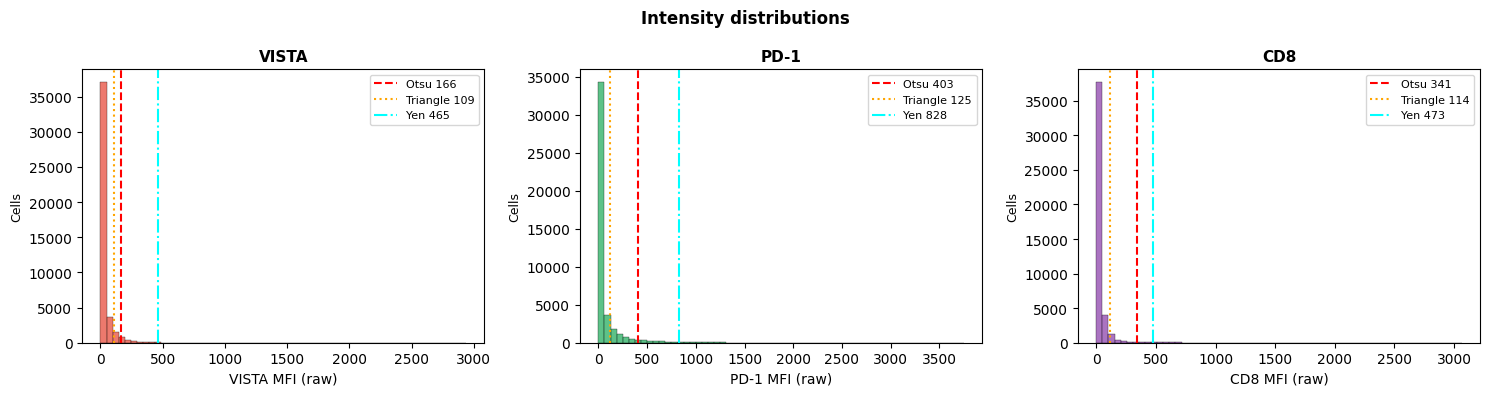

In [ ]:
# @title # STEP 6: Interactive Threshold & Cell Classification
# ✅ Single file: standard threshold UI
# ✅ Batch - user chooses:
#      GLOBAL  : one threshold set applied to all files
#      PER-FILE: individual threshold panel per file
# Shows which segmentation engine and mask expansion method produced
# the data being thresholded, pulled from Step 4 / Step 5B provenance.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from skimage.filters import threshold_otsu, threshold_triangle, threshold_yen
from itertools import combinations

df       = STATE.get('df')
ch_names = STATE['channel_names_clean']
roles    = STATE['channel_roles']
is_batch = bool(STATE.get('batch_dfs'))

if df is None:
    print('Run Step 5 first.')
    raise SystemExit

marker_indices = [v for k,v in roles.items() if k != 'nuclei']
marker_names   = [ch_names[i] for i in marker_indices]
safe_names     = [n.replace(' ','_').replace('/','_') for n in marker_names]
mean_cols      = [f'{s}_mean' for s in safe_names]

if not marker_names:
    print('No marker channels found. Go back to Step 3 and assign Marker roles.')
    raise SystemExit

palette = ['#e74c3c','#27ae60','#8e44ad','#f39c12','#2980b9','#16a085']

# ── Provenance: which engine and mask geometry produced this data ──
def _mask_provenance_str():
    """
    Builds a human-readable description of how the masks behind the
    current dataframe were produced, pulled from STATE set by Step 4
    (segmentation engine) and Step 5B (mask expansion, if it ran).
    Works the same regardless of whether Step 4 used Cellpose or uSAM,
    since both write the same STATE keys.
    """
    label = STATE.get('mask_expansion_label')
    if label:
        return label
    method = STATE.get('mask_expansion_method')
    ratio  = STATE.get('mask_expansion_ratio')
    if method == 'nucleus':
        return 'Nucleus only (no expansion)'
    elif method == 'distance':
        return (f'Distance-based expansion (ratio={ratio})' if ratio is not None
                else 'Distance-based expansion')
    elif method == 'watershed':
        note = (f'Watershed (cap ratio={ratio})' if ratio is not None else 'Watershed')
        return note + ', falls back to distance expansion per file if a pan-cellular marker was missing for that file'
    return 'Raw nuclear masks (Step 5B was not run)'

_seg_engine_label = STATE.get('batch_model_type', 'unknown engine')
_mask_provenance  = _mask_provenance_str()

def _print_provenance_banner():
    print(f"  Segmentation engine : {_seg_engine_label}")
    print(f"  Mask geometry       : {_mask_provenance}")
    print()

_provenance_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
    f"<b>Segmentation engine:</b> {_seg_engine_label}<br>"
    f"<b>Mask geometry:</b> {_mask_provenance}<br>"
    "<span style='color:#888'>The thresholds below are applied to intensity values "
    "already extracted using this geometry in Step 5, changing mask geometry now "
    "requires re-running Step 5B and Step 5, not just re-thresholding here.</span>"
    "</div>"
)

# ── Auto-threshold helper ─────────────────────────────────────
def _auto_thresholds(vals):
    # Drop NaN, pd.concat fills missing columns with NaN when
    # different groups have different channel names
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return {'Otsu': 0., 'Triangle': 0., 'Yen': 0.}
    t_ot = threshold_otsu(vals)
    try:   t_tr = threshold_triangle(vals)
    except: t_tr = t_ot
    try:   t_yn = threshold_yen(vals)
    except: t_yn = t_ot
    return {'Otsu': t_ot, 'Triangle': t_tr, 'Yen': t_yn}

# ── Build histogram figure for one dataframe ─────────────────
def _plot_histograms(df_src, title_suffix='', mnames=None, mcols=None):
    # Use passed-in names/cols, or fall back to global (for global/per-file modes)
    # Per-experiment mode passes group-specific names so blank columns are avoided
    mn = mnames if mnames is not None else marker_names
    mc = mcols  if mcols  is not None else mean_cols
    # Filter to columns that actually exist and have data in this df
    mn_mc = [(m, c) for m, c in zip(mn, mc)
             if c in df_src.columns and df_src[c].dropna().shape[0] > 0]
    if not mn_mc:
        print(f"  No valid MFI columns found in this group, check bio names in Step 3.")
        return {}
    n = len(mn_mc)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    if n == 1: axes = np.array([[axes]])
    axes_flat = np.array(axes).flatten()
    auto_t = {}
    for j, (mname, mcol) in enumerate(mn_mc):
        vals = df_src[mcol].dropna().values
        at   = _auto_thresholds(vals)
        auto_t[mname] = at
        ax = axes_flat[j]
        ax.hist(vals, bins=60, color=palette[j%len(palette)],
                alpha=0.75, edgecolor='black', linewidth=0.3)
        ax.axvline(at['Otsu'],     color='red',    ls='--', lw=1.5, label=f"Otsu {at['Otsu']:.0f}")
        ax.axvline(at['Triangle'], color='orange', ls=':',  lw=1.5, label=f"Triangle {at['Triangle']:.0f}")
        ax.axvline(at['Yen'],      color='cyan',   ls='-.', lw=1.5, label=f"Yen {at['Yen']:.0f}")
        ax.set_xlabel(f'{mname} MFI (raw)', fontsize=10)
        ax.set_ylabel('Cells', fontsize=9)
        ax.set_title(f'{mname}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle(f'Intensity distributions{title_suffix}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
    return auto_t

# ── Build threshold row widgets for one marker set ────────────
def _build_thresh_rows(auto_t, df_src, mnames=None, mcols=None):
    """Returns (thresh_rows_list, thresh_widgets_dict)."""
    mn = mnames if mnames is not None else marker_names
    mc = mcols  if mcols  is not None else mean_cols
    tw = {}
    rows = []
    for mname, mcol in zip(mn, mc):
        if mcol not in df_src.columns: continue
        vals = df_src[mcol].dropna().values
        if len(vals) == 0: continue
        vmin, vmax = float(vals.min()), float(vals.max())
        at = auto_t.get(mname)
        if at is None: continue
        t_default = at['Otsu']

        label_w   = widgets.HTML(
            f"<b style='min-width:120px;display:inline-block'>{mname}</b>")
        method_dd = widgets.Dropdown(
            options=['Otsu (auto)','Triangle (auto)','Yen (auto)','Manual'],
            value='Otsu (auto)', layout=widgets.Layout(width='160px'))
        manual_sl = widgets.FloatSlider(
            value=t_default, min=vmin, max=vmax,
            step=max((vmax-vmin)/200, 0.1), description='',
            layout=widgets.Layout(width='300px'), readout_format='.0f')
        val_lbl = widgets.HTML(f"<code>{t_default:.0f}</code>")

        def _upd(dd, sl, vl, ats):
            def upd(change):
                ch = dd.value
                if   'Otsu'     in ch: t = ats['Otsu']
                elif 'Triangle' in ch: t = ats['Triangle']
                elif 'Yen'      in ch: t = ats['Yen']
                else:                  t = sl.value
                if 'Manual' not in ch: sl.value = t
                vl.value = f"<code>{sl.value:.0f}</code>"
            return upd

        upd = _upd(method_dd, manual_sl, val_lbl, at)
        method_dd.observe(upd, names='value')
        manual_sl.observe(
            lambda c, vl=val_lbl: vl.__setattr__('value', f"<code>{c['new']:.0f}</code>"),
            names='value')

        tw[mname] = (method_dd, manual_sl)
        rows.append(widgets.HBox(
            [label_w, method_dd, manual_sl, val_lbl],
            layout=widgets.Layout(align_items='center', margin='4px 0')))
    return rows, tw

# ── Population summary printer ────────────────────────────────
def _print_summary(df_b, label='', t_dict=None):
    pos_cols = [c for c in df_b.columns if c.endswith('_positive')]
    single_p = [c for c in pos_cols if '__' not in c]
    combo_p  = [c for c in pos_cols if '__' in c]
    n_total  = len(df_b)
    # Resolve thresholds: prefer passed t_dict, then per_file lookup, then global
    fpath  = df_b['file_path'].iloc[0] if 'file_path' in df_b.columns else None
    _td    = (t_dict
              or STATE.get('per_file_thresholds', {}).get(fpath)
              or STATE.get('thresholds', {}))
    print(f"  {'─'*52}")
    if label: print(f"  {label}")
    print(f"  Total (DAPI+)         : {n_total:>5}  (100%)")
    for col in single_p:
        md  = col.replace('_positive','').replace('_',' ')
        np_ = int(df_b[col].sum())
        key = col.replace('_positive','')
        t   = _td.get(key, _td.get(key.replace('_',' '), '?'))
        t_s = f"{t:.0f}" if isinstance(t, (int,float)) else str(t)
        print(f"  {md+'+':28s}: {np_:>5}  ({100*np_/n_total:.1f}%)  [t={t_s}]")
    for col in combo_p:
        md  = col.replace('_positive','').replace('__','+').replace('_',' ')
        np_ = int(df_b[col].sum())
        print(f"  {md+'+':28s}: {np_:>5}  ({100*np_/n_total:.1f}%)")

# ══════════════════════════════════════════════════════════════
# SINGLE FILE
# ══════════════════════════════════════════════════════════════
if not is_batch:
    print("╔══════════════════════════════════════════════════╗")
    print("║          THRESHOLD CONFIGURATION                ║")
    print("╚══════════════════════════════════════════════════╝")
    _print_provenance_banner()
    print(f"  Markers: {marker_names}\n")

    display(_provenance_html)

    auto_t = _plot_histograms(df)
    rows, tw = _build_thresh_rows(auto_t, df)

    apply_btn  = widgets.Button(description='Apply Thresholds',
                                 button_style='success',
                                 layout=widgets.Layout(width='240px',height='42px'),
                                 style={'font_weight':'bold'})
    thresh_out = widgets.Output()

    def _apply_single(b):
        with thresh_out:
            clear_output()
            thresholds_used = {}
            for mname, (dd, sl) in tw.items():
                safe = mname.replace(' ','_').replace('/','_')
                thresholds_used[safe] = sl.value
                mcol = f'{safe}_mean'
                if mcol in df.columns:
                    df[f'{safe}_positive'] = df[mcol] > sl.value
            STATE['thresholds'] = thresholds_used
            STATE['df']         = df
            print(f"{'═'*55}")
            print("  CELL POPULATION SUMMARY")
            print(f"{'═'*55}")
            print(f"  Segmentation engine : {_seg_engine_label}")
            print(f"  Mask geometry       : {_mask_provenance}")
            _print_summary(df)
            print(f"{'═'*55}")
            print("\nProceed to Step 7.")

    apply_btn.on_click(_apply_single)
    display(widgets.VBox(rows + [widgets.HTML('<br>'), apply_btn, thresh_out]))

# ══════════════════════════════════════════════════════════════
# BATCH MODE
# ══════════════════════════════════════════════════════════════
else:
    batch_dfs = STATE['batch_dfs']
    n_files   = len(batch_dfs)

    print("╔══════════════════════════════════════════════════════╗")
    print("║       THRESHOLD CONFIGURATION - BATCH               ║")
    print("╚══════════════════════════════════════════════════════╝")
    _print_provenance_banner()
    print(f"  {n_files} files | Markers: {marker_names}")
    print()
    print("  Tip: use Per experiment folder for separate tissues/animals,")
    print("     each super-folder (KBH 334, KBH 336, etc) gets its own threshold")
    print("     based on its own staining intensity distribution.")
    print()

    display(_provenance_html)

    # ── Mode selector ─────────────────────────────────────────
    thresh_mode = widgets.RadioButtons(
        options=[
            ('Global            - one threshold for ALL files',
             'global'),
            ('Per experiment    - one threshold per super-folder / experiment '
             '(e.g. KBH 334 REG3B, KBH 336, etc)',
             'perexp'),
            ('Per file          - individual threshold per file',
             'perfile'),
        ],
        value='global',
        layout=widgets.Layout(width='800px')
    )
    mode_out    = widgets.Output()
    content_box = widgets.VBox([])

    display(widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>"
        "How should thresholds be applied?</div>"))
    display(thresh_mode, mode_out, content_box)

    # ─────────────────────────────────────────────────────────
    # GLOBAL MODE
    # ─────────────────────────────────────────────────────────
    def _build_global():
        # Use pooled intensities from ALL files for histogram
        pooled = pd.concat(list(batch_dfs.values()), ignore_index=True)
        print("  Histograms show pooled intensities from all files combined\n")
        auto_t = _plot_histograms(pooled, ' - pooled across all files')
        rows, tw = _build_thresh_rows(auto_t, pooled)

        apply_btn  = widgets.Button(
            description='Apply to all files',
            button_style='success',
            layout=widgets.Layout(width='260px',height='42px'),
            style={'font_weight':'bold'})
        apply_out = widgets.Output()

        def _apply_global(b):
            with apply_out:
                clear_output()
                thresholds_used = {}
                for mname, (dd, sl) in tw.items():
                    safe = mname.replace(' ','_').replace('/','_')
                    thresholds_used[safe] = sl.value
                    mcol = f'{safe}_mean'
                    for fpath, df_b in batch_dfs.items():
                        if mcol in df_b.columns:
                            df_b[f'{safe}_positive'] = df_b[mcol] > sl.value

                STATE['thresholds']       = thresholds_used
                STATE['threshold_mode']   = 'global'
                STATE['df'] = list(batch_dfs.values())[0]

                print(f"{'═'*58}")
                print(f"  GLOBAL THRESHOLDS APPLIED TO {n_files} FILES")
                print(f"{'═'*58}")
                print(f"  Segmentation engine : {_seg_engine_label}")
                print(f"  Mask geometry       : {_mask_provenance}")
                for safe, t in thresholds_used.items():
                    print(f"  {safe.replace('_',' '):20s}: {t:.0f}")
                print()

                for fpath, df_b in batch_dfs.items():
                    if len(df_b) == 0: continue
                    folder = df_b['folder_name'].iloc[0]
                    fname  = df_b['file'].iloc[0]
                    _print_summary(df_b, label=f"{folder}/{fname}")
                print(f"\n  {'─'*52}")
                print("Proceed to Step 7.")

        apply_btn._click_handlers.callbacks.clear()
        apply_btn.on_click(_apply_global)
        return widgets.VBox(rows + [widgets.HTML('<br>'), apply_btn, apply_out])

    # ─────────────────────────────────────────────────────────
    # PER-FILE MODE
    # ─────────────────────────────────────────────────────────
    def _build_perfile():
        file_panels = []   # one accordion entry per file
        file_tw     = {}   # fpath -> thresh_widgets dict

        for fpath, df_b in batch_dfs.items():
            if len(df_b) == 0:
                continue
            folder  = df_b['folder_name'].iloc[0]
            fname   = df_b['file'].iloc[0]
            n_cells = len(df_b)
            label   = f"{folder} / {fname}  ({n_cells} cells)"

            # Auto-detect actual MFI columns for THIS file
            # (don't use global mean_cols, bio names may differ per experiment)
            _excl_f = ('DAPI','HOECHST','BRIGHTFIELD','TD')
            file_mcols = sorted([
                c for c in df_b.columns
                if c.endswith('_mean')
                and not any(c.upper().startswith(x) for x in _excl_f)
                and df_b[c].dropna().shape[0] > 0
            ])
            file_mnames = [c.replace('_mean','').replace('_',' ')
                           for c in file_mcols]

            auto_t_f = {}
            for mname, mcol in zip(file_mnames, file_mcols):
                vals = df_b[mcol].dropna().values
                if len(vals) > 0:
                    auto_t_f[mname] = _auto_thresholds(vals)

            # Plot histograms for this file using its own detected columns
            hist_out = widgets.Output()
            with hist_out:
                _plot_histograms(df_b, f' - {folder}/{fname}',
                                 mnames=file_mnames, mcols=file_mcols)

            rows_f, tw_f = _build_thresh_rows(
                auto_t_f, df_b, mnames=file_mnames, mcols=file_mcols)
            file_tw[fpath] = (tw_f, df_b)

            panel = widgets.VBox(
                [hist_out] + rows_f,
                layout=widgets.Layout(
                    border='1px solid #ddd', border_radius='6px',
                    padding='10px', margin='4px 0')
            )

            header = widgets.HTML(
                f"<div style='font-weight:bold;font-size:11px;padding:4px 0'>"
                f"{label}</div>")
            file_panels.append(widgets.VBox([header, panel]))

        apply_all_btn = widgets.Button(
            description='Apply all per-file thresholds',
            button_style='success',
            layout=widgets.Layout(width='300px',height='42px'),
            style={'font_weight':'bold'})
        apply_all_out = widgets.Output()

        def _apply_perfile(b):
            with apply_all_out:
                clear_output()
                # Collect thresholds per file and apply
                per_file_thresholds = {}
                for fpath, (tw_f, df_b) in file_tw.items():
                    t_this = {}
                    for mname, (dd, sl) in tw_f.items():
                        safe = mname.replace(' ','_').replace('/','_')
                        t_this[safe] = sl.value
                        mcol = f'{safe}_mean'
                        if mcol in df_b.columns:
                            df_b[f'{safe}_positive'] = df_b[mcol] > sl.value
                    per_file_thresholds[fpath] = t_this

                # Store representative thresholds in STATE (first file)
                first_fpath = list(file_tw.keys())[0]
                STATE['thresholds']            = per_file_thresholds[first_fpath]
                STATE['per_file_thresholds']   = per_file_thresholds
                STATE['threshold_mode']        = 'per_file'
                STATE['df'] = list(batch_dfs.values())[0]

                print(f"{'═'*58}")
                print(f"  PER-FILE THRESHOLDS APPLIED - {n_files} FILES")
                print(f"{'═'*58}")
                print(f"  Segmentation engine : {_seg_engine_label}")
                print(f"  Mask geometry       : {_mask_provenance}\n")

                for fpath, t_dict in per_file_thresholds.items():
                    df_b   = batch_dfs[fpath]
                    folder = df_b['folder_name'].iloc[0]
                    fname  = df_b['file'].iloc[0]
                    t_str  = '  |  '.join(f"{k}={v:.0f}" for k,v in t_dict.items())
                    print(f"  {folder}/{fname}")
                    print(f"     thresholds: {t_str}")
                    _print_summary(df_b, t_dict=t_dict)
                    print()

                print("Proceed to Step 7.")

        apply_all_btn._click_handlers.callbacks.clear()
        apply_all_btn.on_click(_apply_perfile)

        # Full-height stack, no scroll cap, all panels fully visible
        panels_box = widgets.VBox(
            file_panels,
            layout=widgets.Layout(width='100%')
        )
        return widgets.VBox([
            widgets.HTML(
                "<div style='font-size:11px;padding:6px 8px;"
                "background:#e8f4fd;border-radius:6px;border-left:3px solid #3498db;"
                "margin-bottom:8px'>"
                "Each file shows its own intensity distribution. "
                "Thresholds are independent, changing one file does not affect others."
                "</div>"),
            panels_box,
            widgets.HTML('<br>'),
            apply_all_btn,
            apply_all_out,
        ])

    # ─────────────────────────────────────────────────────────
    # PER-EXPERIMENT (SUPER-FOLDER) MODE
    # ─────────────────────────────────────────────────────────
    def _build_perexp():
        """One threshold panel per super-folder (experiment/animal).
        Super-folder = grandparent directory = KBH 334 REG3B CK19 etc.
        Files directly in the experiment folder (no objective subfolder)
        keep their folder_name as the experiment key.
        """
        import re

        def _is_objective(name):
            return bool(re.match(r'^\d+[Xx]$', name.strip()))

        batch_files_all = STATE.get('batch_files', [])

        # Build fpath -> super_folder_name mapping
        fpath_to_exp = {}
        for fi in batch_files_all:
            fn = fi['folder_name']
            if _is_objective(fn):
                exp = os.path.basename(
                    os.path.dirname(os.path.dirname(fi['path'])))
            else:
                exp = fn
            fpath_to_exp[fi['path']] = exp

        # Group batch_dfs by experiment
        from collections import OrderedDict
        exp_groups = OrderedDict()
        for fpath, df_b in batch_dfs.items():
            if len(df_b) == 0:
                continue
            if fpath in fpath_to_exp:
                exp = fpath_to_exp[fpath]
            else:
                exp = df_b['folder_name'].iloc[0]
            exp_groups.setdefault(exp, []).append((fpath, df_b))

        print(f"  {len(exp_groups)} experiment group(s) detected:")
        for exp_name, files in exp_groups.items():
            print(f"     {exp_name}  ({len(files)} file(s))")
        print()

        exp_panels  = []
        exp_tw      = {}   # exp_name -> (tw_dict, [(fpath, df_b), ...])

        for exp_name, file_list in exp_groups.items():
            n_files_exp = len(file_list)
            # Pool all files in this experiment for histogram
            pooled_exp = pd.concat([df_b for _, df_b in file_list],
                                    ignore_index=True)

            # ── Auto-detect actual MFI columns for THIS group ─
            # Do NOT use global mean_cols, those come from STATE
            # (first file's bio names) and may differ per group.
            # Instead, read what columns actually exist with data.
            _excl = ('DAPI','HOECHST','HOECHST','BRIGHTFIELD','TD')
            grp_mcols = sorted([
                c for c in pooled_exp.columns
                if c.endswith('_mean')
                and not any(c.upper().startswith(x) for x in _excl)
                and pooled_exp[c].dropna().shape[0] > 0
            ])
            grp_mnames = [c.replace('_mean','').replace('_',' ')
                          for c in grp_mcols]

            if not grp_mcols:
                print(f"  {exp_name}: no MFI data found, check bio names in Step 3")
                continue

            hist_out = widgets.Output()
            with hist_out:
                _plot_histograms(pooled_exp,
                                 f' - {exp_name} ({n_files_exp} file(s))',
                                 mnames=grp_mnames, mcols=grp_mcols)

            auto_t_exp = {}
            for mname, mcol in zip(grp_mnames, grp_mcols):
                if mcol in pooled_exp.columns:
                    vals = pooled_exp[mcol].dropna().values
                    if len(vals) > 0:
                        auto_t_exp[mname] = _auto_thresholds(vals)

            rows_exp, tw_exp = _build_thresh_rows(
                auto_t_exp, pooled_exp,
                mnames=grp_mnames, mcols=grp_mcols)
            exp_tw[exp_name] = (tw_exp, file_list)

            header = widgets.HTML(
                f"<div style='font-weight:bold;font-size:12px;padding:6px 0;color:#7ecef4'>"
                f"{exp_name}"
                f"<span style='font-weight:normal;color:#888;font-size:11px'>"
                f"  - {n_files_exp} file(s)</span></div>")

            exp_panels.append(widgets.VBox(
                [header, hist_out] + rows_exp,
                layout=widgets.Layout(
                    border='1px solid #2d4a6d', border_radius='8px',
                    padding='10px', margin='6px 0')))

        apply_exp_btn = widgets.Button(
            description='Apply per-experiment thresholds',
            button_style='success',
            layout=widgets.Layout(width='310px', height='42px'),
            style={'font_weight': 'bold'})
        apply_exp_out = widgets.Output()

        def _apply_perexp(b):
            with apply_exp_out:
                clear_output()
                per_file_thresholds = {}
                global_rep          = None

                for exp_name, (tw_exp, file_list) in exp_tw.items():
                    # Build threshold dict for this experiment
                    t_exp = {}
                    for mname, (dd, sl) in tw_exp.items():
                        safe      = mname.replace(' ', '_').replace('/', '_')
                        t_exp[safe] = sl.value
                    if global_rep is None:
                        global_rep = t_exp

                    # Apply to every file in this experiment
                    for fpath, df_b in file_list:
                        for safe, t_val in t_exp.items():
                            mcol = f'{safe}_mean'
                            if mcol in df_b.columns:
                                df_b[f'{safe}_positive'] = df_b[mcol] > t_val
                        per_file_thresholds[fpath] = dict(t_exp)  # store a copy

                STATE['thresholds']          = global_rep or {}
                STATE['per_file_thresholds'] = per_file_thresholds
                STATE['threshold_mode']      = 'per_file'   # reuse per_file logic
                STATE['df'] = list(batch_dfs.values())[0]

                print(f"{'═'*60}")
                print(f"  PER-EXPERIMENT THRESHOLDS APPLIED")
                print(f"{'═'*60}")
                print(f"  Segmentation engine : {_seg_engine_label}")
                print(f"  Mask geometry       : {_mask_provenance}\n")
                for exp_name, (tw_exp, file_list) in exp_tw.items():
                    t_str = '  |  '.join(
                        f"{m}={sl.value:.0f}"
                        for m, (_, sl) in tw_exp.items())
                    print(f"  {exp_name}  [{len(file_list)} files]")
                    print(f"     thresholds: {t_str}")
                    for fpath, df_b in file_list:
                        fname  = df_b['file'].iloc[0]
                        folder = df_b['folder_name'].iloc[0]
                        # Look up THIS file's own threshold dict, avoids stale t_exp
                        t_this = per_file_thresholds.get(fpath, {})
                        _print_summary(df_b, label=f"  {folder}/{fname}", t_dict=t_this)
                    print()
                print("Proceed to Step 7.")

        apply_exp_btn._click_handlers.callbacks.clear()
        apply_exp_btn.on_click(_apply_perexp)

        return widgets.VBox([
            widgets.HTML(
                "<div style='font-size:11px;padding:6px 8px;"
                "background:#1a2a1a;border-radius:6px;"
                "border-left:3px solid #27ae60;margin-bottom:8px;color:#aaa'>"
                "Each panel shows intensity pooled from all files in that experiment. "
                "One threshold set is applied to all files sharing the same super-folder. "
                "Use this when each experiment is a different animal/tissue block.</div>"),
            widgets.VBox(exp_panels),
            widgets.HTML('<br>'),
            apply_exp_btn,
            apply_exp_out,
        ])

    # ── Wire up mode switcher ─────────────────────────────────
    def _switch_thresh_mode(change):
        with mode_out: clear_output()
        print("Building threshold panel...")
        if change['new'] == 'global':
            content_box.children = [_build_global()]
        elif change['new'] == 'perexp':
            content_box.children = [_build_perexp()]
        else:
            content_box.children = [_build_perfile()]
        with mode_out: clear_output()   # clear "building" message

    thresh_mode.observe(_switch_thresh_mode, names='value')

    # ── Lazy initial build, don't block cell execution ────────
    # With large batches (80+ files), pd.concat + plt.show() inside
    # _build_global() blocks the kernel before any widget renders.
    # Show a button instead; mode-switch also triggers a build.
    _init_btn = widgets.Button(
        description='Build threshold panel',
        button_style='primary',
        layout=widgets.Layout(width='260px', height='40px'))

    def _on_init_btn(b):
        _init_btn.disabled    = True
        _init_btn.description = 'Building...'
        content_box.children  = [_build_global()]

    _init_btn.on_click(_on_init_btn)
    content_box.children = [_init_btn]

> Spatial maps, population scatter plots, and bar charts — all auto-generated from your marker assignments.

HTML(value="<div style='font-size:11px;padding:8px 12px;margin:8px 0 10px;background:#1a1a2e;color:#ccc;border…

HTML(value="<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>Group / Condition Tag for Filena…

RadioButtons(index=1, layout=Layout(width='700px'), options=(('No tag, use folder_name only', 'none'), ('Use p…

HTML(value="<div style='font-size:11px;margin:4px 0 0 20px'>Preview folder_name -> tag:<br><div style='max-hei…

HTML(value="<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>Population Colours:</div>")

...

Output()

Output()

Saved: MyDrive_Stich_confocal_analysis_KBH 181 CD8 VISTA_viz_nuclearmask.svg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

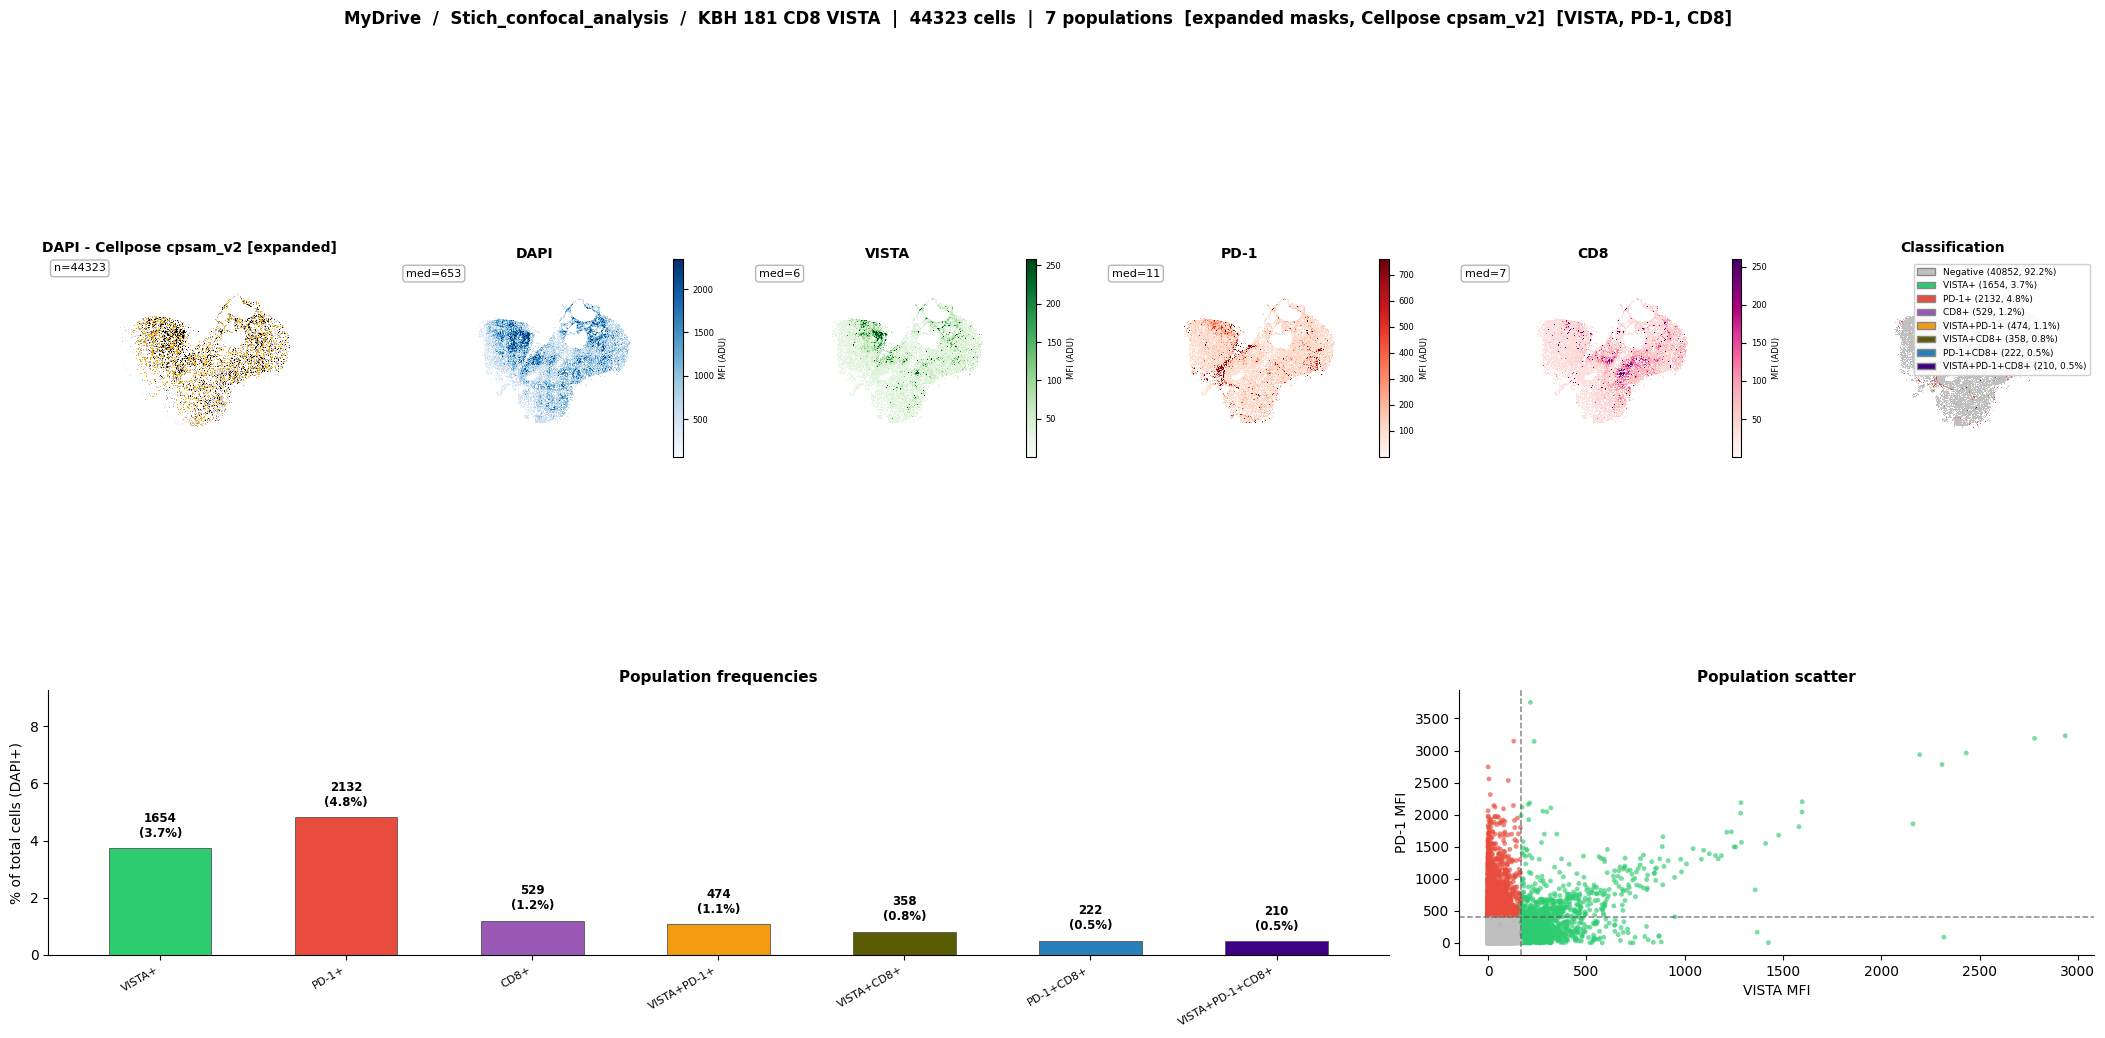

Rendered 2 figure(s). Adjust populations and re-render anytime.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title #STEP 7: Visualization Dashboard
# One full figure per file, per selected mask geometry (nuclear/expanded/both)
# Works with masks from either Cellpose or uSAM (Step 4), and with or
# without mask expansion (Step 5B), since both only ever produce plain
# label arrays by the time they reach this step.
# ============================================================

import os, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.cm as cm
from skimage.segmentation import find_boundaries
import ipywidgets as widgets
from IPython.display import display, clear_output
from itertools import combinations

matplotlib.rcParams['figure.facecolor']  = 'white'
matplotlib.rcParams['axes.facecolor']    = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'

df            = STATE.get('df')
masks         = STATE.get('masks')
channels      = STATE.get('channels')
ch_names      = STATE.get('channel_names_clean', [])
ch_colors     = STATE.get('channel_colors', [])
roles         = STATE.get('channel_roles', {})
is_batch      = bool(STATE.get('batch_results')) and bool(STATE.get('batch_dfs'))
source_folder = STATE.get('folder_path', '')
thresh_mode   = STATE.get('threshold_mode', 'global')
batch_files_all = STATE.get('batch_files', [])

if df is None:
    print("Run Steps 4-6 first.")
    raise SystemExit

single_pos_cols = [c for c in df.columns
                   if c.endswith('_positive') and '__' not in c]
marker_safe     = [pc.replace('_positive', '') for pc in single_pos_cols]

if not single_pos_cols:
    print("Run Step 6 first, no _positive columns found.")
    raise SystemExit

# ══════════════════════════════════════════════════════════════
# MASK GEOMETRY / ENGINE PROVENANCE
# Reads what Step 4 (segmentation engine) and Step 5B (mask expansion,
# if it ran) produced. Works identically whether Step 4 used Cellpose
# or uSAM, and whether or not Step 5B ran, since all of them are just
# label arrays by the time they reach this step.
# ══════════════════════════════════════════════════════════════
_seg_engine_label      = STATE.get('batch_model_type', 'unknown engine')
_expansion_label       = STATE.get('mask_expansion_label')
_expansion_method      = STATE.get('mask_expansion_method')
_masks_expanded_single = STATE.get('masks_expanded')
_batch_masks_expanded  = STATE.get('batch_masks_expanded', {})

if not is_batch:
    _expanded_available = _masks_expanded_single is not None
else:
    _expanded_available = bool(_batch_masks_expanded)

if _expansion_label:
    _expansion_desc = _expansion_label
elif _expansion_method:
    _expansion_desc = _expansion_method
else:
    _expansion_desc = 'not run'

def _engine_label_for_file(fpath):
    if is_batch:
        r = next((x for x in STATE.get('batch_results', []) if x['fpath'] == fpath), None)
        if r is not None:
            return r.get('engine_label', _seg_engine_label)
    return _seg_engine_label

def _resolve_masks(masks_nuc_b, fpath, geometry):
    """
    Returns (masks_to_use, geometry_tag, fell_back).
    geometry_tag is always 'nuclear' or 'expanded', fell_back is True
    if 'expanded' was requested but unavailable for this file, in which
    case nuclear masks are used instead and the caller should print a
    note rather than silently mislabel the output.
    """
    if geometry == 'nuclear':
        return masks_nuc_b, 'nuclear', False
    exp = (_batch_masks_expanded.get(fpath) if is_batch else _masks_expanded_single)
    if exp is not None:
        return exp, 'expanded', False
    return masks_nuc_b, 'nuclear', True

_provenance_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:8px 0 10px;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
    f"<b>Segmentation engine:</b> {_seg_engine_label}<br>"
    f"<b>Mask expansion (Step 5B):</b> {_expansion_desc}<br>"
    f"<b>Expanded masks available for visualization:</b> "
    f"{'yes' if _expanded_available else 'no, Step 5B was not run or produced nothing'}"
    "</div>"
)
display(_provenance_html)

# ══════════════════════════════════════════════════════════════
# ALL POSSIBLE POPULATIONS
# ══════════════════════════════════════════════════════════════
ALL_POPS = []
ALL_POPS.append(('Negative', [], 'negative'))
for ms, pc in zip(marker_safe, single_pos_cols):
    ALL_POPS.append((ms.replace('_', ' ') + '+', [pc], pc))
for r in range(2, len(single_pos_cols) + 1):
    for combo in combinations(single_pos_cols, r):
        lbl = '+'.join(c.replace('_positive', '').replace('_', ' ')
                       for c in combo) + '+'
        ALL_POPS.append((lbl, list(combo), None))

BASE_COLORS  = ['#2ECC71','#E74C3C','#9B59B6','#E67E22','#1ABC9C',
                '#F39C12','#16A085','#8E44AD','#2980B9','#D35400']
COMBO_COLORS = ['#2980B9','#1ABC9C','#8E44AD','#F39C12','#E74C3C']

POP_PALETTE = {'negative': '#C0C0C0'}
for i, ms in enumerate(marker_safe):
    POP_PALETTE[single_pos_cols[i]] = BASE_COLORS[i % len(BASE_COLORS)]
    POP_PALETTE[ms] = BASE_COLORS[i % len(BASE_COLORS)]
for j, (lbl, combo, _) in enumerate(ALL_POPS):
    if len(combo) >= 2:
        key = '__'.join(c for c in combo)
        POP_PALETTE[key] = COMBO_COLORS[j % len(COMBO_COLORS)]

CH_CMAPS = {
    'blue': 'Blues', 'cyan': 'GnBu', 'green': 'Greens',
    'yellow': 'YlOrBr', 'red': 'Reds', 'magenta': 'RdPu',
    'orange': 'Oranges', 'gray': 'Greys',
}

# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
def _pick_cmap(col_name, ch_idx, colors):
    if ch_idx < len(colors):
        return CH_CMAPS.get(colors[ch_idx].lower(), 'viridis')
    n = col_name.lower()
    if any(k in n for k in ['dapi', 'nucl']): return 'Blues'
    if any(k in n for k in ['gfp', 'fitc']):  return 'Greens'
    return ['Blues', 'Greens', 'RdPu', 'YlOrBr'][ch_idx % 4]

def _v_paint(masks_b, df_b, val_col, cmap_name):
    max_lbl = int(masks_b.max())
    if max_lbl == 0:
        return np.ones((*masks_b.shape, 3), np.float32), 0., 1.
    lut = np.zeros(max_lbl + 1, np.float32)
    lbl = df_b['label'].values.astype(int)
    val = df_b[val_col].values.astype(np.float32)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    lut[lbl[ok]] = val[ok]
    nz   = lut[1:][lut[1:] > 0]
    vmin = float(np.percentile(nz, 2))  if len(nz) else 0.
    vmax = float(np.percentile(nz, 98)) if len(nz) else 1.
    if vmax == vmin: vmax = vmin + 1
    n_lut = np.clip((lut - vmin) / (vmax - vmin), 0., 1.)
    n_lut[1:] = n_lut[1:] * 0.88 + 0.12
    n_lut[0]  = 0.
    rgb = plt.get_cmap(cmap_name)(n_lut[masks_b])[:, :, :3].astype(np.float32)
    rgb[masks_b == 0] = 1.
    return rgb, vmin, vmax

def _pop_mask(df_b, combo_cols, pos_cols=None):
    # pos_cols: per-file single positivity columns (defaults to global)
    _pc = pos_cols if pos_cols is not None else single_pos_cols
    if not combo_cols:
        avail = [c for c in _pc if c in df_b.columns]
        if not avail:
            return pd.Series([True] * len(df_b), index=df_b.index)
        return ~df_b[avail].any(axis=1)
    avail_combo = [c for c in combo_cols if c in df_b.columns]
    if not avail_combo:
        return pd.Series([False] * len(df_b), index=df_b.index)
    return df_b[avail_combo].all(axis=1)

def _v_classify_custom(masks_b, df_b, selected_pops, pos_cols=None):
    max_lbl = int(masks_b.max())
    lut_rgb = np.ones((max_lbl + 1, 3), np.float32)
    lbl = df_b['label'].values.astype(int)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    for _, combo_cols, color_hex in selected_pops:
        # .astype(bool) guards against float64 empty Series
        # (pd.Series([True]*0) has dtype float64, not bool)
        mask_bool = _pop_mask(df_b, combo_cols, pos_cols).values.astype(bool)
        lut_rgb[lbl[ok & mask_bool]] = mcolors.to_rgb(color_hex)
    return lut_rgb[masks_b].astype(np.float32)

def _get_thresholds_for_file(fpath):
    if thresh_mode == 'per_file':
        return STATE.get('per_file_thresholds', {}).get(
               fpath, STATE.get('thresholds', {}))
    return STATE.get('thresholds', {})

def _parent_from_path(fpath):
    return os.path.basename(os.path.dirname(os.path.dirname(str(fpath))))

def _mount_drive():
    try:
        from google.colab import drive as gdrive
        if not os.path.exists('/content/drive/MyDrive'):
            gdrive.mount('/content/drive')
        return True
    except Exception as e:
        print(f"Drive mount failed: {e}"); return False

def _copy_to_drive(src, dest):
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy2(src, dest)

# ══════════════════════════════════════════════════════════════
# GROUP / CONDITION LABEL - with custom name + 1800px scroll
# ══════════════════════════════════════════════════════════════
display(widgets.HTML(
    "<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>"
    "Group / Condition Tag for Filenames:</div>"
    "<div style='font-size:11px;color:#666;margin-bottom:8px'>"
    "Adds the condition name to every saved figure filename so you can "
    "identify images immediately without opening them.</div>"))

grp_radio = widgets.RadioButtons(
    options=[
        ('No tag, use folder_name only',                             'none'),
        ('Use parent folder as tag  (e.g. "CONTROL_1" from path)',    'parent'),
        ('Custom tag per file',                                        'custom'),
    ],
    value='parent',
    layout=widgets.Layout(width='700px'))

# Parent preview
_prev_html = []
_seen = set()
for fi in batch_files_all:
    parent = _parent_from_path(fi['path'])
    key    = (fi['folder_name'], parent)
    if key not in _seen:
        _seen.add(key)
        _prev_html.append(
            f"<tr><td style='padding:2px 8px;color:#7ecef4;"
            f"font-family:monospace;font-size:10px'>{fi['folder_name']}</td>"
            f"<td style='padding:2px 4px'>-></td>"
            f"<td style='padding:2px 8px;color:#2ecc71;"
            f"font-family:monospace;font-size:10px'>{parent}</td></tr>")

grp_preview = widgets.HTML(
    "<div style='font-size:11px;margin:4px 0 0 20px'>Preview folder_name -> tag:<br>"
    "<div style='max-height:160px;overflow-y:auto;border:1px solid #333;"
    "border-radius:4px;padding:4px;margin-top:4px'>"
    "<table>" + ''.join(_prev_html) + "</table></div></div>",
    layout=widgets.Layout(display='' if (batch_files_all and grp_radio.value == 'parent') else 'none'))

# Custom label boxes, one per unique file, max_height 1800px
_custom_tags  = {}   # fpath -> Text widget
_custom_rows  = []

_files_for_tags = (batch_files_all if is_batch
                   else ([{'path': STATE.get('file_path',''),
                            'folder_name': STATE.get('folder_name',''),
                            'filename': os.path.basename(STATE.get('file_path',''))}]
                         if STATE.get('file_path') else []))

for fi in _files_for_tags:
    parent   = _parent_from_path(fi['path'])
    tb       = widgets.Text(value=parent, placeholder='e.g. CONTROL',
                            layout=widgets.Layout(width='220px'))
    lbl_w    = widgets.HTML(
        f"<span style='font-size:11px;font-family:monospace'>"
        f"{fi['folder_name']}/{fi['filename'][:20]}</span>",
        layout=widgets.Layout(width='280px'))
    _custom_tags[fi['path']] = tb
    _custom_rows.append(widgets.HBox(
        [lbl_w, widgets.HTML("-> "), tb],
        layout=widgets.Layout(align_items='center', margin='1px 0')))

custom_tag_box = widgets.VBox(
    [widgets.HTML("<div style='font-size:11px;margin:4px 0 4px 20px'>"
                  "Type a condition tag for each file:</div>")]
    + _custom_rows,
    layout=widgets.Layout(
        display='none',
        max_height='1800px', overflow_y='auto',
        border='1px solid #ddd', border_radius='4px',
        padding='6px 10px', margin='4px 0 0 0'))

def _toggle_grp(change):
    grp_preview.layout.display    = '' if change['new'] == 'parent' else 'none'
    custom_tag_box.layout.display = '' if change['new'] == 'custom' else 'none'
grp_radio.observe(_toggle_grp, names='value')

display(grp_radio)
display(grp_preview)
display(custom_tag_box)

def _get_tag(fpath):
    """Return condition tag for a file based on current radio selection."""
    mode = grp_radio.value
    if mode == 'none':
        return ''
    elif mode == 'parent':
        return _parent_from_path(fpath)
    else:
        tb = _custom_tags.get(fpath)
        return tb.value.strip() if tb and tb.value.strip() else _parent_from_path(fpath)

def _build_figname(tag, folder_name, fname, ext='png', geometry_tag='nuclear'):
    base     = os.path.splitext(fname)[0]
    tag_pfx  = tag.replace(' ', '_').replace('/', '_') + '_' if tag else ''
    geom_sfx = f'_{geometry_tag}mask' if geometry_tag else ''
    return f"{tag_pfx}{folder_name}_{base}_viz{geom_sfx}.{ext}"

# ══════════════════════════════════════════════════════════════
# POPULATION COLOUR SELECTOR
# Single-file: one global panel (first file's markers)
# Batch: one panel PER EXPERIMENT (super-folder), each
# showing only that experiment's own markers and combos.
# Each experiment can have completely different colours.
# ══════════════════════════════════════════════════════════════
import re as _re
from collections import OrderedDict as _OD

def _is_obj(name):
    return bool(_re.match(r'^\d+[Xx]$', name.strip()))

def _exp_for_r(r):
    fn = r['folder_name']
    fp = r['fpath']
    return (os.path.basename(os.path.dirname(os.path.dirname(fp)))
            if _is_obj(fn) else fn)

def _exp_for_fpath(fp):
    fn = os.path.basename(os.path.dirname(fp))
    return (os.path.basename(os.path.dirname(os.path.dirname(fp)))
            if _is_obj(fn) else fn)

def _build_pop_row(lbl, combo, df_ref, n_single_so_far, color_override=None):
    """Build one checkbox+colour row for a population."""
    n_cells = len(df_ref)
    if not combo:
        avail = [c for c in combo if c in df_ref.columns] if combo else []
        n_pop = int((~df_ref[[c for c in df_ref.columns
                               if c.endswith('_positive') and '__' not in c
                               and c in df_ref.columns]].any(axis=1)).sum()
                    if [c for c in df_ref.columns
                        if c.endswith('_positive') and '__' not in c] else len(df_ref))
        default_color = '#C0C0C0'
    elif all(c in df_ref.columns for c in combo):
        n_pop = int(df_ref[list(combo)].all(axis=1).sum())
        if len(combo) == 1:
            default_color = BASE_COLORS[n_single_so_far % len(BASE_COLORS)]
        else:
            default_color = COMBO_COLORS[(n_single_so_far) % len(COMBO_COLORS)]
    else:
        n_pop = 0
        default_color = '#888888'

    if color_override:
        default_color = color_override

    pct      = 100 * n_pop / n_cells if n_cells else 0
    cb       = widgets.Checkbox(value=True, description='', indent=False,
                                layout=widgets.Layout(width='40px'))
    lbl_w    = widgets.HTML(f"<span style='font-size:10px'>{lbl}</span>",
                            layout=widgets.Layout(width='200px'))
    n_w      = widgets.HTML(f"<code style='font-size:9px'>{n_pop}</code>",
                            layout=widgets.Layout(width='60px'))
    pct_w    = widgets.HTML(f"<code style='font-size:9px'>{pct:.1f}%</code>",
                            layout=widgets.Layout(width='55px'))
    color_tb = widgets.Text(value=default_color, placeholder='#RRGGBB',
                            layout=widgets.Layout(width='90px'))
    swatch   = widgets.HTML(
        f"<div style='width:22px;height:18px;background:{default_color};"
        f"border:1px solid #aaa;border-radius:3px;margin-top:2px'></div>",
        layout=widgets.Layout(width='26px'))

    def _sw(change, sw=swatch):
        try:
            mcolors.to_rgb(change['new'])
            sw.value = (f"<div style='width:22px;height:18px;"
                        f"background:{change['new']};border:1px solid #aaa;"
                        f"border-radius:3px;margin-top:2px'></div>")
        except: pass
    color_tb.observe(_sw, names='value')

    return cb, color_tb, widgets.HBox(
        [cb, lbl_w, n_w, pct_w, color_tb, swatch],
        layout=widgets.Layout(gap='4px', align_items='center', margin='1px 0'))

def _build_exp_pops(df_ref):
    """Return list of (lbl, combo_cols) for an experiment DataFrame."""
    sp = [c for c in df_ref.columns if c.endswith('_positive') and '__' not in c]
    pops = [('Negative', [])]
    for pc in sp:
        ms = pc.replace('_positive','').replace('_',' ')
        pops.append((ms + '+', [pc]))
    for r2 in range(2, len(sp)+1):
        for combo in combinations(sp, r2):
            lbl_c = '+'.join(c.replace('_positive','').replace('_',' ')
                              for c in combo) + '+'
            pops.append((lbl_c, list(combo)))
    return pops

display(widgets.HTML(
    "<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>"
    "Population Colours:</div>"))

# ── Per-experiment data structures ────────────────────────────
_exp_pop_cbs = {}   # exp_name -> [(cb, lbl, combo, color_tb), ...]

if not is_batch:
    # ── SINGLE FILE: one global panel ────────────────────────
    _single_pop_cbs = []
    _single_rows    = []

    _single_rows.append(widgets.HBox([
        widgets.HTML("<b style='font-size:10px'>Show</b>",       layout=widgets.Layout(width='40px')),
        widgets.HTML("<b style='font-size:10px'>Population</b>", layout=widgets.Layout(width='200px')),
        widgets.HTML("<b style='font-size:10px'>n</b>",          layout=widgets.Layout(width='60px')),
        widgets.HTML("<b style='font-size:10px'>%</b>",          layout=widgets.Layout(width='55px')),
        widgets.HTML("<b style='font-size:10px'>Colour</b>",     layout=widgets.Layout(width='90px')),
    ], layout=widgets.Layout(background='#f0f0f0', padding='3px 6px',
                              border_radius='5px', gap='4px')))

    n_single_cnt = 0
    for lbl, combo in _build_exp_pops(df):
        cb, ctb, row = _build_pop_row(lbl, combo, df, n_single_cnt)
        if combo: n_single_cnt += 1
        _single_pop_cbs.append((cb, lbl, combo, ctb))
        _single_rows.append(row)

    display(widgets.VBox(_single_rows, layout=widgets.Layout(width='490px')))

    def _get_selected_pops():
        res = []
        for cb, lbl, combo, ctb in _single_pop_cbs:
            if not cb.value: continue
            try: mcolors.to_rgb(ctb.value); col = ctb.value
            except: col = '#888888'
            res.append((lbl, combo, col))
        return res

    def _get_pops_for_file(fp):
        return _get_selected_pops()

else:
    # ── BATCH: one panel per experiment (super-folder) ────────
    batch_dfs = STATE['batch_dfs']

    # Group batch_results by experiment
    _exp_groups_v = _OD()
    for r in batch_results:
        _exp_groups_v.setdefault(_exp_for_r(r), []).append(r)

    _exp_panel_widgets = []

    for exp_name, exp_files in _exp_groups_v.items():
        first_fp = exp_files[0]['fpath']
        df_ref   = batch_dfs.get(first_fp)
        if df_ref is None:
            continue

        pops_exp = _build_exp_pops(df_ref)
        exp_cbs  = []
        exp_rows = []

        # Table header
        exp_rows.append(widgets.HBox([
            widgets.HTML("<b style='font-size:10px'>Show</b>",       layout=widgets.Layout(width='40px')),
            widgets.HTML("<b style='font-size:10px'>Population</b>", layout=widgets.Layout(width='200px')),
            widgets.HTML("<b style='font-size:10px'>n</b>",          layout=widgets.Layout(width='60px')),
            widgets.HTML("<b style='font-size:10px'>%</b>",          layout=widgets.Layout(width='55px')),
            widgets.HTML("<b style='font-size:10px'>Colour</b>",     layout=widgets.Layout(width='90px')),
        ], layout=widgets.Layout(background='#1a2a1a', padding='3px 6px',
                                  border_radius='4px', gap='4px')))

        n_single_cnt = 0
        for lbl, combo in pops_exp:
            cb, ctb, row = _build_pop_row(lbl, combo, df_ref, n_single_cnt)
            if combo: n_single_cnt += 1
            exp_cbs.append((cb, lbl, combo, ctb))
            exp_rows.append(row)

        _exp_pop_cbs[exp_name] = exp_cbs

        # Quick-select buttons for this experiment
        _sa = widgets.Button(description='All',   button_style='',
                             layout=widgets.Layout(width='70px', height='26px'))
        _sn = widgets.Button(description='None',  button_style='',
                             layout=widgets.Layout(width='70px', height='26px'))
        _ss = widgets.Button(description='Singles', button_style='',
                             layout=widgets.Layout(width='70px', height='26px'))
        _sc = widgets.Button(description='Combos',  button_style='',
                             layout=widgets.Layout(width='70px', height='26px'))

        def _mk_sel(cbs):
            def _s(fn): [cb.__setattr__('value', fn(lbl, combo))
                         for cb, lbl, combo, _ in cbs]
            return _s
        _sfn = _mk_sel(exp_cbs)
        _sa.on_click(lambda b, fn=_sfn: fn(lambda l, c: True))
        _sn.on_click(lambda b, fn=_sfn: fn(lambda l, c: False))
        _ss.on_click(lambda b, fn=_sfn: fn(lambda l, c: len(c) <= 1))
        _sc.on_click(lambda b, fn=_sfn: fn(lambda l, c: len(c) >= 2))

        panel = widgets.VBox(
            [widgets.HBox([_sa, _sn, _ss, _sc],
                          layout=widgets.Layout(gap='4px', margin='0 0 4px 0'))]
            + exp_rows,
            layout=widgets.Layout(padding='6px 8px'))

        exp_header = widgets.HTML(
            f"<div style='font-weight:bold;font-size:11px;color:#7ecef4;padding:4px 0'>"
            f"{exp_name} "
            f"<span style='color:#888;font-weight:normal;font-size:10px'>"
            f"({len(exp_files)} file(s))"
            f"</span></div>")

        _exp_panel_widgets.append(widgets.VBox(
            [exp_header, panel],
            layout=widgets.Layout(
                border='1px solid #2d4a6d', border_radius='6px',
                padding='4px 10px', margin='4px 0')))

    display(widgets.HTML(
        "<div style='font-size:11px;padding:5px 8px;background:#1a2a1a;"
        "border-radius:5px;border-left:3px solid #27ae60;margin-bottom:6px;color:#aaa'>"
        "Each experiment uses its own colour set. Colours are applied per-experiment "
        "to figures from that cohort only.</div>"))
    display(widgets.VBox(
        _exp_panel_widgets,
        layout=widgets.Layout(max_height='2400px', overflow_y='auto')))

    def _get_pops_for_file(fp):
        """Return selected (lbl, combo, colour) for the experiment owning fp."""
        exp  = _exp_for_fpath(fp)
        rows = _exp_pop_cbs.get(exp, [])
        res  = []
        for cb, lbl, combo, ctb in rows:
            if not cb.value: continue
            try: mcolors.to_rgb(ctb.value); col = ctb.value
            except: col = '#888888'
            res.append((lbl, combo, col))
        return res

    def _get_selected_pops():
        # Fallback used only by single-file render path
        return _get_pops_for_file(STATE.get('file_path', ''))

# ══════════════════════════════════════════════════════════════
# MASK GEOMETRY SELECTOR
# Placed after population colours, before export settings. Lets the
# user decide whether to render/export nuclear-only masks, expanded
# masks (from Step 5B), or both, with filenames tagged accordingly so
# downloaded files never get confused with each other.
# ══════════════════════════════════════════════════════════════
display(widgets.HTML(
    "<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 4px'>"
    "Mask Geometry to Visualize / Export:</div>"))

_geom_options = [('Nuclear masks only', 'nuclear')]
if _expanded_available:
    _geom_options.append((f'Expanded masks ({_expansion_desc})', 'expanded'))
    _geom_options.append(('Both, nuclear and expanded (select all)', 'both'))

geometry_radio = widgets.RadioButtons(
    options=_geom_options, value=_geom_options[0][1],
    layout=widgets.Layout(width='700px'))

_geom_note = widgets.HTML(
    "<div style='font-size:11px;padding:6px 10px;margin:4px 0 10px;"
    "background:#1a1a2e;color:#999;border-radius:6px;border-left:3px solid #3498db'>"
    "Each mask geometry produces its own figure, tagged in the filename with "
    "<code>_nuclearmask</code> or <code>_expandedmask</code>. Selecting 'Both' "
    "doubles the number of figures rendered and exported."
    + ("" if _expanded_available else
       "<br><b style='color:#e67e22'>Expanded masks are not available.</b> Run "
       "Step 5B before this step if you want to visualize or export expanded "
       "or watershed geometry alongside nuclear masks.")
    + "</div>"
)

display(geometry_radio)
display(_geom_note)

def _geometries_to_render():
    v = geometry_radio.value
    if v == 'both':
        return ['nuclear', 'expanded']
    return [v]

# ══════════════════════════════════════════════════════════════
# FIGURE BUILDER
# ══════════════════════════════════════════════════════════════
def _make_figure(masks_b, chs_b, df_b, ch_names_b, ch_colors_b,
                 roles_b, fpath, folder_name, selected_pops, tag='',
                 geometry_tag='nuclear', engine_label=None):
    mean_cols_b = [c for c in df_b.columns if c.endswith('_mean')]
    n_markers   = len(mean_cols_b)
    n_sp        = n_markers + 2
    FIG_W       = max(18, 4.4 * n_sp)
    t_dict      = _get_thresholds_for_file(fpath)
    eng_lbl     = engine_label or _seg_engine_label

    # Detect THIS file's positivity columns, may differ from global single_pos_cols
    # e.g. first file has AF488_positive but KBH 334 has CK19_positive/REG3A_positive
    sp_cols_b = [c for c in df_b.columns
                 if c.endswith('_positive') and '__' not in c]

    # Filter selected_pops to only include populations whose columns exist in df_b
    def _pop_avail(combo_cols):
        if not combo_cols: return True   # Negative always applies
        return all(c in df_b.columns for c in combo_cols)  # all cols must exist

    sel = [(lbl, combo, col) for lbl, combo, col in selected_pops
           if _pop_avail(combo)]

    # If none of the user's marker populations match this file's columns
    # (different experiment, different markers), auto-build from the file's own columns
    if not any(combo for _, combo, _ in sel) and sp_cols_b:
        sel = [('Negative', [], '#C0C0C0')]
        for i, pc in enumerate(sp_cols_b):
            ms    = pc.replace('_positive', '').replace('_', ' ')
            color = BASE_COLORS[i % len(BASE_COLORS)]
            sel.append((ms + '+', [pc], color))
        # Add double-positive combos if 2 markers
        if len(sp_cols_b) == 2:
            lbl_c = '+'.join(c.replace('_positive','').replace('_',' ')
                             for c in sp_cols_b) + '+'
            sel.append((lbl_c, sp_cols_b, COMBO_COLORS[0]))

    fig = plt.figure(figsize=(FIG_W, 10.5), facecolor='white')
    gs  = gridspec.GridSpec(2, max(n_sp, 2), figure=fig,
                            height_ratios=[1.6, 1.0], hspace=0.35, wspace=0.25)

    nuc_i       = roles_b.get('nuclei', 0)
    nuc_f       = chs_b[nuc_i].astype(np.float32)
    p_lo, p_hi  = np.percentile(nuc_f, 1), np.percentile(nuc_f, 99.5)
    nuc_n       = np.clip((nuc_f - p_lo) / (p_hi - p_lo + 1e-8), 0, 1)
    bounds      = find_boundaries(masks_b, mode='outer')
    dapi_rgb    = np.stack([1.0 - nuc_n] * 3, axis=-1)
    dapi_rgb[bounds] = [1., 0.65, 0.]
    n_cells     = int(masks_b.max())

    ax_dapi = fig.add_subplot(gs[0, 0])
    ax_dapi.imshow(dapi_rgb, origin='upper', interpolation='nearest')
    ax_dapi.set_title(f'DAPI - {eng_lbl} [{geometry_tag}]', fontsize=10, fontweight='bold', pad=5)
    ax_dapi.text(0.02, 0.98, f'n={n_cells}', transform=ax_dapi.transAxes,
                 va='top', ha='left', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', alpha=0.85))
    ax_dapi.axis('off')

    for idx, col in enumerate(mean_cols_b):
        ax     = fig.add_subplot(gs[0, idx + 1])
        mname  = col.replace('_mean', '').replace('_', ' ')
        cmap_n = _pick_cmap(col, idx, ch_colors_b)
        rgb, vmin, vmax = _v_paint(masks_b, df_b, col, cmap_n)
        ax.imshow(rgb, origin='upper', interpolation='nearest')
        cb2 = fig.colorbar(
            cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap_n),
            ax=ax, fraction=0.035, pad=0.02)
        cb2.ax.tick_params(labelsize=6)
        cb2.set_label('MFI (ADU)', fontsize=6)
        ax.text(0.02, 0.98, f'med={df_b[col].median():.0f}',
                transform=ax.transAxes, va='top', ha='left', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', alpha=0.85))
        ax.set_title(mname, fontsize=10, fontweight='bold', pad=5)
        ax.axis('off')

    ax_cls  = fig.add_subplot(gs[0, n_markers + 1])
    cls_rgb = _v_classify_custom(masks_b, df_b, sel, pos_cols=sp_cols_b)
    ax_cls.imshow(cls_rgb, origin='upper', interpolation='nearest')
    n_total = len(df_b)
    patches = [Patch(fc=col, ec='#888',
                     label=f'{lbl} ({int(_pop_mask(df_b,combo,sp_cols_b).sum())}, '
                           f'{100*int(_pop_mask(df_b,combo,sp_cols_b).sum())/n_total:.1f}%)')
               for lbl, combo, col in sel]
    ax_cls.legend(handles=patches, loc='upper right', fontsize=6.5,
                  framealpha=0.92, facecolor='white', edgecolor='#ccc')
    ax_cls.set_title('Classification', fontsize=10, fontweight='bold', pad=5)
    ax_cls.axis('off')

    ax_bar  = fig.add_subplot(gs[1, :n_sp // 2 + 1])
    ax_scat = fig.add_subplot(gs[1, n_sp // 2 + 1:])

    bar_pops   = [(lbl, combo, col) for lbl, combo, col in sel if combo]
    bar_labels = [lbl for lbl, _, _ in bar_pops]
    bar_pcts   = [100 * int(_pop_mask(df_b, combo, sp_cols_b).sum()) / n_total
                  for _, combo, _ in bar_pops]
    bar_counts = [int(_pop_mask(df_b, combo, sp_cols_b).sum()) for _, combo, _ in bar_pops]
    bar_colors = [col for _, _, col in bar_pops]

    if bar_labels:
        bars = ax_bar.bar(bar_labels, bar_pcts, color=bar_colors,
                          edgecolor='#555', linewidth=0.6, width=0.55)
        for bar, pct, cnt in zip(bars, bar_pcts, bar_counts):
            ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                        f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom',
                        fontsize=8.5, fontweight='bold')
        ax_bar.set_ylim(0, max(bar_pcts) * 1.3 + 3)
    ax_bar.set_ylabel('% of total cells (DAPI+)', fontsize=10)
    ax_bar.set_title('Population frequencies', fontsize=11, fontweight='bold')
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    plt.setp(ax_bar.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    sp_local = [c for c in df_b.columns if c.endswith('_positive') and '__' not in c]
    ms_local = [pc.replace('_positive', '') for pc in sp_local]
    if len(ms_local) >= 2:
        ms0 = ms_local[0]; ms1 = ms_local[1]
        mc1 = ms0 + '_mean'; mc2 = ms1 + '_mean'
        if mc1 in df_b.columns and mc2 in df_b.columns:
            t1 = t_dict.get(ms0); t2 = t_dict.get(ms1)
            dot_colors = np.full(len(df_b), '#CCCCCC', dtype=object)
            for _, combo_cols, color_hex in reversed(sel):
                dot_colors[_pop_mask(df_b, combo_cols, sp_cols_b).values] = color_hex
            ax_scat.scatter(df_b[mc1], df_b[mc2], c=list(dot_colors),
                            s=12, alpha=0.65, edgecolors='none')
            if t1: ax_scat.axvline(t1, color='#555', ls='--', lw=1.1, alpha=0.7)
            if t2: ax_scat.axhline(t2, color='#555', ls='--', lw=1.1, alpha=0.7)
            ax_scat.set_xlabel(f'{ms0.replace("_"," ")} MFI', fontsize=10)
            ax_scat.set_ylabel(f'{ms1.replace("_"," ")} MFI', fontsize=10)
            ax_scat.set_title('Population scatter', fontsize=11, fontweight='bold')
            ax_scat.spines['top'].set_visible(False)
            ax_scat.spines['right'].set_visible(False)
    else:
        ax_scat.axis('off')

    base  = os.path.splitext(os.path.basename(fpath))[0]
    title = (f'{tag + "  /  " if tag else ""}{folder_name}  /  {base}'
             f'  |  {n_cells} cells  |  {len(bar_pops)} populations'
             f'  [{geometry_tag} masks, {eng_lbl}]'
             + (f'  [{", ".join(c.replace("_positive","") for c in sp_cols_b)}]'
                if sp_cols_b else ''))
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(pad=0.8)
    return fig

def _save_fig(fig, local_name, fmt, dpi):
    base = os.path.splitext(local_name)[0]
    if fmt == 'PNG':
        out = base + '.png'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    elif fmt == 'TIFF':
        out = base + '.tiff'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    else:
        out = base + '.svg'
        fig.savefig(out, format='svg', bbox_inches='tight', facecolor='white')
    return out

# ══════════════════════════════════════════════════════════════
# SINGLE FILE
# ══════════════════════════════════════════════════════════════
if not is_batch:
    fmt_radio  = widgets.RadioButtons(
        options=['PNG', 'SVG', 'TIFF'], value='PNG',
        description='Format:', style={'description_width': '70px'},
        layout=widgets.Layout(width='280px'))
    dpi_slider = widgets.IntSlider(
        value=150, min=72, max=600, step=10, description='DPI:',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='300px'))
    dpi_note   = widgets.HTML(
        "<small style='color:gray'>DPI applies to PNG and TIFF</small>")
    render_btn = widgets.Button(
        description='Render Figure(s)', button_style='primary',
        layout=widgets.Layout(width='200px', height='42px'))
    save_btn   = widgets.Button(
        description='Save & Download', button_style='success',
        layout=widgets.Layout(width='200px', height='38px'),
        disabled=True)
    render_out = widgets.Output()
    save_out   = widgets.Output()
    _last_figs = []      # list of (fig, geometry_tag)
    _dl_path   = [None]  # store path OUTSIDE Output block for download

    def _on_fmt(ch): dpi_slider.disabled = (ch['new'] == 'SVG')
    fmt_radio.observe(_on_fmt, names='value')

    def _render(b):
        with render_out:
            clear_output()
            sel = _get_selected_pops()
            if not sel: print("Select at least one population."); return
            tag = _get_tag(STATE.get('file_path', ''))
            _last_figs.clear()
            for geom in _geometries_to_render():
                masks_use, geom_tag, fell_back = _resolve_masks(
                    masks, STATE.get('file_path', ''), geom)
                if fell_back:
                    print(f"  Expanded masks unavailable, rendering nuclear instead.")
                fig = _make_figure(masks_use, channels, df, ch_names, ch_colors,
                                   roles, STATE.get('file_path', ''),
                                   STATE.get('folder_name', ''), sel, tag,
                                   geometry_tag=geom_tag, engine_label=_seg_engine_label)
                plt.show()
                _last_figs.append((fig, geom_tag))
            save_btn.disabled = False
            print(f"Rendered {len(_last_figs)} figure(s). Adjust populations and re-render anytime.")

    def _save(b):
        _dl_path[0] = None
        with save_out:
            clear_output()
            if not _last_figs: print("Render first."); return
            outs = []
            for fig, geom_tag in _last_figs:
                fname_base = _build_figname(
                    _get_tag(STATE.get('file_path', '')),
                    STATE.get('folder_name', 'file'),
                    os.path.basename(STATE.get('file_path', 'image.oir')),
                    geometry_tag=geom_tag)
                out = _save_fig(fig, fname_base, fmt_radio.value, dpi_slider.value)
                print(f"Saved: {out}")
                outs.append(out)

            if len(outs) == 1:
                _dl_path[0] = outs[0]
            else:
                zip_name = 'step7_figures.zip'
                with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
                    for o in outs:
                        zf.write(o, os.path.basename(o))
                print(f"Bundled into {zip_name}")
                _dl_path[0] = zip_name

        # ── Download OUTSIDE Output block, no double-trigger ─
        if _dl_path[0]:
            try:
                from google.colab import files as colab_files
                colab_files.download(_dl_path[0])
            except: print("Download from Files panel.")

    render_btn._click_handlers.callbacks.clear()
    save_btn._click_handlers.callbacks.clear()
    render_btn.on_click(_render)
    save_btn.on_click(_save)

    display(widgets.HTML("<hr><div style='font-weight:bold;margin:8px 0 4px'>"
                         "Export settings:</div>"))
    display(widgets.HBox([
        widgets.VBox([fmt_radio]),
        widgets.VBox([dpi_slider, dpi_note]),
        render_btn, save_btn],
        layout=widgets.Layout(align_items='flex-start', gap='16px')))
    display(render_out, save_out)

# ══════════════════════════════════════════════════════════════
# BATCH MODE
# ══════════════════════════════════════════════════════════════
else:
    batch_results = STATE['batch_results']
    batch_dfs     = STATE['batch_dfs']
    print(f"\n  {len(batch_results)} files | threshold mode: {thresh_mode}\n")

    fmt_radio  = widgets.RadioButtons(
        options=['PNG', 'SVG', 'TIFF'], value='PNG',
        description='Format:', style={'description_width': '70px'},
        layout=widgets.Layout(width='280px'))
    dpi_slider = widgets.IntSlider(
        value=150, min=72, max=600, step=10, description='DPI:',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='300px'))
    dpi_note   = widgets.HTML(
        "<small style='color:gray'>DPI applies to PNG and TIFF</small>")

    def _on_fmt2(ch): dpi_slider.disabled = (ch['new'] == 'SVG')
    fmt_radio.observe(_on_fmt2, names='value')

    dest_radio = widgets.RadioButtons(
        options=[
            ('Download ZIP to my computer',                          'download'),
            ('Save alongside source files on Drive',                   'source'),
            ('Save to output directory (mirrors structure)',            'mirror'),
        ],
        value='download', layout=widgets.Layout(width='700px'))
    mirror_tb  = widgets.Text(
        value=(source_folder.rstrip('/') + '/visualization_output'
               if source_folder else ''),
        placeholder='/content/drive/MyDrive/results/visualization/',
        layout=widgets.Layout(width='600px'))
    mirror_panel = widgets.VBox(
        [widgets.HTML("<div style='font-size:11px;color:#555;margin:4px 0 2px'>"
                      "Output root, subfolders mirror source</div>"), mirror_tb],
        layout=widgets.Layout(padding='4px 0 0 20px', display='none'))

    def _tog(ch): mirror_panel.layout.display = '' if ch['new'] == 'mirror' else 'none'
    dest_radio.observe(_tog, names='value')

    render_btn = widgets.Button(
        description=f'Render & Save {len(batch_results)} file(s)',
        button_style='success',
        layout=widgets.Layout(width='300px', height='42px'))
    fig_out    = widgets.Output()
    _zip_path  = [None]   # store ZIP path OUTSIDE Output block

    display(widgets.VBox([
        widgets.HTML("<hr><div style='font-size:12px;font-weight:bold;margin:8px 0 6px'>"
                     "Export figures:</div>"),
        widgets.HBox([widgets.VBox([fmt_radio]), widgets.VBox([dpi_slider, dpi_note])],
                     layout=widgets.Layout(align_items='flex-start', gap='20px')),
        widgets.HTML("<div style='font-size:11px;font-weight:bold;margin:10px 0 4px'>"
                     "Where to save:</div>"),
        dest_radio, mirror_panel,
        widgets.HTML('<br>'),
        render_btn, fig_out,
    ]))

    def _on_render(b):
        if STATE.get('_viz_running'): return
        STATE['_viz_running'] = True
        render_btn.disabled   = True
        _zip_path[0]          = None

        try:
            with fig_out:
                clear_output()
                # Validate that at least one experiment has a selection
                any_sel = any(
                    cb.value
                    for cbs in _exp_pop_cbs.values()
                    for cb, *_ in cbs
                ) if _exp_pop_cbs else bool(_get_selected_pops())
                if not any_sel:
                    print("Select at least one population in any experiment panel."); return

                fmt      = fmt_radio.value
                dpi      = dpi_slider.value
                mode     = dest_radio.value
                out_root = mirror_tb.value.strip().rstrip('/')
                ext      = fmt.lower()
                geoms    = _geometries_to_render()
                local_files = []

                for r in batch_results:
                    fpath       = r['fpath']
                    fname       = r['fname']
                    folder_name = r['folder_name']
                    df_b        = batch_dfs.get(fpath)
                    if df_b is None:
                        print(f"  No data for {fname}"); continue
                    if len(df_b) == 0:
                        print(f"  {fname}: 0 cells, skipped"); continue

                    sel_for_file = _get_pops_for_file(fpath)
                    tag          = _get_tag(fpath)
                    exp_lbl      = _exp_for_fpath(fpath)
                    eng_lbl      = _engine_label_for_file(fpath)

                    for geom in geoms:
                        masks_use, geom_tag, fell_back = _resolve_masks(r['masks'], fpath, geom)
                        if fell_back:
                            print(f"  {exp_lbl}/{folder_name}/{fname}: expanded masks "
                                  f"unavailable, rendering nuclear instead")

                        figname = _build_figname(tag, folder_name, fname, ext,
                                                  geometry_tag=geom_tag)
                        print(f"  {exp_lbl}/{folder_name}/{fname} [{geom_tag}]...")

                        fig = _make_figure(masks_use, r['channels_2d'], df_b,
                                           r['bio_names'], r['colors'], r['roles'],
                                           fpath, folder_name, sel_for_file, tag,
                                           geometry_tag=geom_tag, engine_label=eng_lbl)
                        plt.show()
                        lp = _save_fig(fig, figname, fmt, dpi)
                        plt.close(fig)
                        local_files.append((lp, folder_name, fname))
                        print(f"     saved: {lp}")

                print(f"\n{len(local_files)} figure(s) rendered.")

                if not local_files:
                    return

                if mode == 'download':
                    # ZIP all figures, flat structure using tagged filenames
                    zip_name = 'step7_visualization_figures.zip'
                    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
                        for lp, folder_name, fname in local_files:
                            zf.write(lp, os.path.basename(lp))
                    _zip_path[0] = zip_name
                    print(f"  ZIP ready: {zip_name}  ({len(local_files)} figures)")

                elif mode == 'source':
                    if not _mount_drive(): return
                    saved = []
                    for lp, folder_name, fname in local_files:
                        src_fi = next((fi for fi in batch_files_all
                                       if fi['folder_name'] == folder_name
                                       and fi['filename'] == fname), None)
                        dest   = (os.path.join(os.path.dirname(src_fi['path']),
                                               os.path.basename(lp))
                                  if src_fi else lp)
                        try:
                            _copy_to_drive(lp, dest)
                            saved.append(dest)
                            print(f"  {dest}")
                        except Exception as e:
                            print(f"  {lp}: {e}")
                    print(f"\n{len(saved)} figures saved alongside source files.")

                else:  # mirror
                    if not out_root: print("Enter output root."); return
                    if not _mount_drive(): return
                    saved = []
                    for lp, folder_name, _ in local_files:
                        dest = os.path.join(out_root, folder_name,
                                            os.path.basename(lp))
                        try:
                            _copy_to_drive(lp, dest)
                            saved.append(dest)
                            print(f"  {dest}")
                        except Exception as e:
                            print(f"  {lp}: {e}")
                    print(f"\n{len(saved)} figures saved to: {out_root}/")

        finally:
            STATE['_viz_running'] = False
            render_btn.disabled   = False

        # ── ZIP download OUTSIDE Output block, prevents double-trigger ──
        if _zip_path[0]:
            try:
                from google.colab import files as colab_files
                colab_files.download(_zip_path[0])
            except Exception as e:
                print(f"Download error: {e}")

    render_btn._click_handlers.callbacks.clear()
    render_btn.on_click(_on_render)

In [ ]:
# @title 🖼️ STEP 7-EXPORT - Every panel as a separate TIFF + SVG (Step 7 unchanged)
# ============================================================
# Run AFTER Step 7 has been displayed (its widgets define the population
# colours this cell reuses). Reads STATE only. Nothing here modifies Step 7.
#
# Produces, per file per mask geometry:
#   p1_DAPI, p2_<marker> (one per marker), p3_classification,
#   p4_legend  (the coloured population key, on its own),
#   p5_frequencies, p6_scatter
# each written as .tiff and .svg, then downloaded one by one.
# ============================================================

import os, gc, time, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from skimage.segmentation import find_boundaries
from itertools import combinations

# ─────────── SETTINGS ───────────
OUT_DIR   = '/content/panel_exports'
DPI       = 900           # journal minimum; 600 if the editor demands it
FORMATS   = ['tiff', 'svg']
PANEL_W   = 6.0            # inches, width of each image panel
DOWNLOAD  = True
MAX_INDIVIDUAL = 25        # above this many files, auto-bundle into one ZIP
CLASSIFICATION_ALSO_WITH_LEGEND = False   # True = extra combined copy
# ────────────────────────────────

matplotlib.rcParams['savefig.facecolor'] = 'white'
os.makedirs(OUT_DIR, exist_ok=True)

STATE_df   = STATE.get('df')
_is_batch  = bool(STATE.get('batch_results')) and bool(STATE.get('batch_dfs'))
if STATE_df is None and not _is_batch:
    raise SystemExit("Run Steps 4-6 and Step 7 first.")

_BASE = ['#2ECC71','#E74C3C','#9B59B6','#E67E22','#1ABC9C',
         '#F39C12','#16A085','#8E44AD','#2980B9','#D35400']
_COMBO = ['#2980B9','#1ABC9C','#8E44AD','#F39C12','#E74C3C']
_CMAPS = {'blue':'Blues','cyan':'GnBu','green':'Greens','yellow':'YlOrBr',
          'red':'Reds','magenta':'RdPu','orange':'Oranges','gray':'Greys'}

# ── local copies of the drawing helpers (do not touch Step 7's) ──
def x_cmap(col_name, idx, colors):
    if idx < len(colors):
        return _CMAPS.get(str(colors[idx]).lower(), 'viridis')
    n = col_name.lower()
    if any(k in n for k in ['dapi','nucl']): return 'Blues'
    if any(k in n for k in ['gfp','fitc']):  return 'Greens'
    return ['Blues','Greens','RdPu','YlOrBr'][idx % 4]

def x_paint(masks_b, df_b, val_col, cmap_name):
    max_lbl = int(masks_b.max())
    if max_lbl == 0:
        return np.ones((*masks_b.shape, 3), np.float32), 0., 1.
    lut = np.zeros(max_lbl + 1, np.float32)
    lbl = df_b['label'].values.astype(int)
    val = df_b[val_col].values.astype(np.float32)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    lut[lbl[ok]] = val[ok]
    nz   = lut[1:][lut[1:] > 0]
    vmin = float(np.percentile(nz, 2))  if len(nz) else 0.
    vmax = float(np.percentile(nz, 98)) if len(nz) else 1.
    if vmax == vmin: vmax = vmin + 1
    n_lut = np.clip((lut - vmin) / (vmax - vmin), 0., 1.)
    n_lut[1:] = n_lut[1:] * 0.88 + 0.12
    n_lut[0]  = 0.
    rgb = plt.get_cmap(cmap_name)(n_lut[masks_b])[:, :, :3].astype(np.float32)
    rgb[masks_b == 0] = 1.
    return np.clip(rgb, 0, 1), vmin, vmax

def x_popmask(df_b, combo_cols, pos_cols):
    if not combo_cols:
        avail = [c for c in pos_cols if c in df_b.columns]
        if not avail:
            return pd.Series([True]*len(df_b), index=df_b.index)
        return ~df_b[avail].any(axis=1)
    ac = [c for c in combo_cols if c in df_b.columns]
    if not ac:
        return pd.Series([False]*len(df_b), index=df_b.index)
    return df_b[ac].all(axis=1)

def x_classify(masks_b, df_b, sel, pos_cols):
    max_lbl = int(masks_b.max())
    lut = np.ones((max_lbl + 1, 3), np.float32)
    lbl = df_b['label'].values.astype(int)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    for _, combo, color_hex in sel:
        mb = x_popmask(df_b, combo, pos_cols).values.astype(bool)
        lut[lbl[ok & mb]] = mcolors.to_rgb(color_hex)
    return np.clip(lut[masks_b], 0, 1).astype(np.float32)

def x_autopops(df_b):
    """Fallback palette if Step 7's widget selection is unavailable."""
    sp = [c for c in df_b.columns if c.endswith('_positive') and '__' not in c]
    out = [('Negative', [], '#C0C0C0')]
    for i, pc in enumerate(sp):
        out.append((pc.replace('_positive','').replace('_',' ') + '+',
                    [pc], _BASE[i % len(_BASE)]))
    k = 0
    for r in range(2, len(sp)+1):
        for combo in combinations(sp, r):
            lab = '+'.join(c.replace('_positive','').replace('_',' ')
                           for c in combo) + '+'
            out.append((lab, list(combo), _COMBO[k % len(_COMBO)]))
            k += 1
    return out

def x_pops_for(fpath, df_b):
    """Reuse Step 7's per-experiment colour picks when they exist."""
    fn = globals().get('_get_pops_for_file')
    if callable(fn):
        try:
            sel = fn(fpath)
            keep = [(l, c, col) for l, c, col in sel
                    if (not c) or all(x in df_b.columns for x in c)]
            if any(c for _, c, _ in keep):
                return keep
        except Exception:
            pass
    return x_autopops(df_b)

def x_tag(fpath):
    fn = globals().get('_get_tag')
    if callable(fn):
        try: return fn(fpath)
        except Exception: pass
    return os.path.basename(os.path.dirname(os.path.dirname(str(fpath))))

def x_thresholds(fpath):
    if STATE.get('threshold_mode') == 'per_file':
        return STATE.get('per_file_thresholds', {}).get(
            fpath, STATE.get('thresholds', {}))
    return STATE.get('thresholds', {})

def x_masks(masks_nuc, fpath, geometry):
    if geometry == 'nuclear':
        return masks_nuc, 'nuclear', False
    exp = (STATE.get('batch_masks_expanded', {}).get(fpath) if _is_batch
           else STATE.get('masks_expanded'))
    if exp is not None:
        return exp, 'expanded', False
    return masks_nuc, 'nuclear', True

def x_geometries():
    rb = globals().get('geometry_radio')
    v = rb.value if rb is not None else None
    if v == 'both':  return ['nuclear', 'expanded']
    if v in ('nuclear', 'expanded'): return [v]
    exp_ok = (bool(STATE.get('batch_masks_expanded')) if _is_batch
              else STATE.get('masks_expanded') is not None)
    return ['expanded'] if exp_ok else ['nuclear']

_written = []
def x_save(fig, stem):
    stem = ''.join(c if c.isalnum() or c in '_-.' else '_' for c in stem)
    for f in FORMATS:
        p = os.path.join(OUT_DIR, f'{stem}.{f}')
        if f == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        elif f == 'tiff':
            fig.savefig(p, dpi=DPI, format='tiff', bbox_inches='tight',
                        facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white')
        _written.append(p)
    plt.close(fig); gc.collect()

def x_imfig(shape):
    h, w = shape[:2]
    return plt.figure(figsize=(PANEL_W, PANEL_W * h / w), facecolor='white')

# ══════════════════════════════════════════════════════════════
# PANEL RENDERERS
# ══════════════════════════════════════════════════════════════
def export_panels(masks_b, chs_b, df_b, ch_colors_b, roles_b,
                  fpath, folder_name, fname, geom_tag, eng_lbl):

    sp_cols = [c for c in df_b.columns if c.endswith('_positive') and '__' not in c]
    sel     = x_pops_for(fpath, df_b)
    tag     = x_tag(fpath)
    base    = os.path.splitext(fname)[0]
    pfx     = f"{(tag + '_') if tag else ''}{folder_name}_{base}_{geom_tag}mask"
    n_total = len(df_b)
    n_cells = int(masks_b.max())

    # ── p1: DAPI + segmentation boundaries ──
    nuc_i = roles_b.get('nuclei', 0)
    nuc_f = chs_b[nuc_i].astype(np.float32)
    lo, hi = np.percentile(nuc_f, 1), np.percentile(nuc_f, 99.5)
    nuc_n = np.clip((nuc_f - lo) / (hi - lo + 1e-8), 0, 1)
    dapi_rgb = np.stack([1.0 - nuc_n]*3, axis=-1)
    dapi_rgb[find_boundaries(masks_b, mode='outer')] = [1., 0.65, 0.]
    fig = x_imfig(nuc_n.shape); ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(np.clip(dapi_rgb, 0, 1), origin='upper', interpolation='nearest')
    ax.axis('off')
    x_save(fig, f'{pfx}_p1_DAPI_{eng_lbl}')

    # ── p2: one panel per marker MFI ──
    mean_cols = [c for c in df_b.columns if c.endswith('_mean')]
    for i, col in enumerate(mean_cols):
        mname = col.replace('_mean', '')
        cmap_n = x_cmap(col, i, ch_colors_b)
        rgb, vmin, vmax = x_paint(masks_b, df_b, col, cmap_n)
        fig = x_imfig(rgb.shape)
        ax = fig.add_axes([0, 0, 0.88, 1]); ax.imshow(rgb, origin='upper',
                                                      interpolation='nearest')
        ax.axis('off')
        cax = fig.add_axes([0.90, 0.15, 0.03, 0.70])
        cb = fig.colorbar(cm.ScalarMappable(
            norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap_n), cax=cax)
        cb.ax.tick_params(labelsize=7); cb.set_label('MFI (ADU)', fontsize=7)
        x_save(fig, f'{pfx}_p2_{mname}')

    # ── p3: classification image, no legend burned in ──
    cls_rgb = x_classify(masks_b, df_b, sel, sp_cols)
    fig = x_imfig(cls_rgb.shape); ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(cls_rgb, origin='upper', interpolation='nearest'); ax.axis('off')
    x_save(fig, f'{pfx}_p3_classification')

    # ── p4: the population key on its own ──
    handles = []
    for lbl, combo, col in sel:
        n = int(x_popmask(df_b, combo, sp_cols).sum())
        pct = 100 * n / n_total if n_total else 0
        handles.append(Patch(fc=col, ec='#888', label=f'{lbl}  ({n}, {pct:.1f}%)'))
    fig = plt.figure(figsize=(3.2, 0.32 * max(len(handles), 1) + 0.4),
                     facecolor='white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.legend(handles=handles, loc='center left', fontsize=8, frameon=True,
              framealpha=1.0, facecolor='white', edgecolor='#ccc',
              handlelength=1.2, handleheight=1.2, labelspacing=0.5)
    x_save(fig, f'{pfx}_p4_legend_key')

    if CLASSIFICATION_ALSO_WITH_LEGEND:
        fig = x_imfig(cls_rgb.shape); ax = fig.add_axes([0, 0, 1, 1])
        ax.imshow(cls_rgb, origin='upper', interpolation='nearest'); ax.axis('off')
        ax.legend(handles=handles, loc='upper right', fontsize=6.5,
                  framealpha=0.92, facecolor='white', edgecolor='#ccc')
        x_save(fig, f'{pfx}_p3b_classification_with_key')

    # ── p5: population frequency bars ──
    bar = [(l, c, col) for l, c, col in sel if c]
    if bar:
        labels = [l for l, _, _ in bar]
        counts = [int(x_popmask(df_b, c, sp_cols).sum()) for _, c, _ in bar]
        pcts   = [100 * n / n_total if n_total else 0 for n in counts]
        fig, ax = plt.subplots(figsize=(max(5, 0.95*len(labels)), 4.2),
                               facecolor='white')
        bars = ax.bar(labels, pcts, color=[c for _, _, c in bar],
                      edgecolor='#555', linewidth=0.6, width=0.55)
        for b, p, n in zip(bars, pcts, counts):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                    f'{n}\n({p:.1f}%)', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold')
        ax.set_ylim(0, max(pcts) * 1.3 + 3)
        ax.set_ylabel('% of total cells (DAPI+)', fontsize=10)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        fig.tight_layout()
        x_save(fig, f'{pfx}_p5_frequencies')

    # ── p6: two-marker scatter ──
    ms = [c.replace('_positive', '') for c in sp_cols]
    if len(ms) >= 2:
        c1, c2 = ms[0] + '_mean', ms[1] + '_mean'
        if c1 in df_b.columns and c2 in df_b.columns:
            td = x_thresholds(fpath)
            dots = np.full(len(df_b), '#CCCCCC', dtype=object)
            for _, combo, col in reversed(sel):
                dots[x_popmask(df_b, combo, sp_cols).values] = col
            fig, ax = plt.subplots(figsize=(5.4, 4.6), facecolor='white')
            ax.scatter(df_b[c1], df_b[c2], c=list(dots), s=12,
                       alpha=0.65, edgecolors='none')
            if td.get(ms[0]): ax.axvline(td[ms[0]], color='#555', ls='--', lw=1.1)
            if td.get(ms[1]): ax.axhline(td[ms[1]], color='#555', ls='--', lw=1.1)
            ax.set_xlabel(f'{ms[0].replace("_"," ")} MFI', fontsize=10)
            ax.set_ylabel(f'{ms[1].replace("_"," ")} MFI', fontsize=10)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            fig.tight_layout()
            x_save(fig, f'{pfx}_p6_scatter')

    print(f"  {folder_name}/{fname} [{geom_tag}]: {n_cells} cells, panels written")

# ══════════════════════════════════════════════════════════════
# DRIVE THE EXPORT
# ══════════════════════════════════════════════════════════════
_geoms = x_geometries()
print(f"Geometries: {_geoms} | formats: {FORMATS} | {DPI} dpi\n")

if _is_batch:
    for r in STATE['batch_results']:
        fpath = r['fpath']
        df_b  = STATE['batch_dfs'].get(fpath)
        if df_b is None or len(df_b) == 0:
            print(f"  {r['fname']}: no cells, skipped"); continue
        eng = r.get('engine_label', STATE.get('batch_model_type', 'engine'))
        for g in _geoms:
            mu, gt, fb = x_masks(r['masks'], fpath, g)
            if fb: print(f"  {r['fname']}: expanded unavailable, using nuclear")
            export_panels(mu, r['channels_2d'], df_b, r['colors'], r['roles'],
                          fpath, r['folder_name'], r['fname'], gt, eng)
else:
    fpath = STATE.get('file_path', '')
    eng   = STATE.get('batch_model_type', 'engine')
    for g in _geoms:
        mu, gt, fb = x_masks(STATE['masks'], fpath, g)
        if fb: print("  Expanded unavailable, using nuclear")
        export_panels(mu, STATE['channels'], STATE_df,
                      STATE.get('channel_colors', []), STATE.get('channel_roles', {}),
                      fpath, STATE.get('folder_name', 'file'),
                      os.path.basename(fpath) or 'image.oir', gt, eng)

_total_mb = sum(os.path.getsize(p) for p in _written) / 1e6
print(f"\n{len(_written)} files, {_total_mb:.1f} MB total, in {OUT_DIR}")

if DOWNLOAD and _written:
    from google.colab import files as colab_files
    if len(_written) > MAX_INDIVIDUAL:
        z = os.path.join(OUT_DIR, 'panel_exports.zip')
        with zipfile.ZipFile(z, 'w', zipfile.ZIP_DEFLATED) as zf:
            for p in _written: zf.write(p, os.path.basename(p))
        print(f"{len(_written)} files exceeds MAX_INDIVIDUAL={MAX_INDIVIDUAL}, "
              f"bundling instead: {os.path.basename(z)}")
        colab_files.download(z)
    else:
        for p in _written:
            colab_files.download(p)
            time.sleep(0.4)

Geometries: ['nuclear', 'expanded'] | formats: ['tiff', 'svg'] | 900 dpi

  Stich_confocal_analysis/KBH 181 CD8 VISTA.oir [nuclear]: 44323 cells, panels written
  Stich_confocal_analysis/KBH 181 CD8 VISTA.oir [expanded]: 44323 cells, panels written

36 files, 64.7 MB total, in /content/panel_exports
36 files exceeds MAX_INDIVIDUAL=25, bundling instead: panel_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title 🔍 STEP 7-EXPORT+ZOOM - Full panels and zoom panels as separate files (TIFF + SVG)
# ============================================================
# Run AFTER Step 7 has been displayed. Reads STATE only. Step 7 is untouched.
#
# Every panel is written as its OWN file. Nothing is combined.
# Per file, per mask geometry:
#   p1_DAPI                    p1_DAPI_zoom                [p1_DAPI_boxed]
#   p2_<marker>                p2_<marker>_zoom            [p2_<marker>_boxed]
#   p3_classification          p3_classification_zoom      [p3_classification_boxed]
#   p4_legend_key
#   p5_frequencies
#   p6_scatter
# each as .tiff and .svg.
#
# The zoom window is FRACTIONAL, so the same relative region is cropped
# from every image regardless of pixel dimensions. Marker zooms inherit
# the full image's vmin/vmax so intensities stay directly comparable.
# ============================================================

import os, gc, time, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch, Rectangle
from skimage.segmentation import find_boundaries
from itertools import combinations

# ══════════════════ SETTINGS ══════════════════
OUT_DIR   = '/content/panel_exports'
DPI       = 600
FORMATS   = ['tiff', 'svg']
PANEL_W   = 6.0            # inches, width of each full-image panel
ZOOM_W    = 6.0            # inches, width of each zoom panel

# Zoom window as fractions of image width/height: (x0, y0, width, height)
# 0,0 = top-left corner of the image.
ZOOM_FRAC   = (0.35, 0.30, 0.25, 0.25)
ZOOM_SQUARE = True         # True: height fraction wins, crop forced square in px

# Per-file window override. Key = filename (or any unique substring of the
# path), value = a (x0, y0, w, h) tuple. Files not listed use ZOOM_FRAC.
# Example: ZOOM_OVERRIDES = {'KBH 334 CD8 VISTA.oir': (0.55, 0.20, 0.25, 0.25)}
ZOOM_OVERRIDES = {}

PREVIEW_ONLY   = False     # True: draw the box on file 1 and stop, write nothing
EMIT_BOXED     = True      # also write a SEPARATE box-annotated full image
BOX_COLOR      = '#FF2D2D'
BOX_LW         = 2.5

EXPORT_FULL    = True      # write the full-image panels
EXPORT_ZOOM    = True      # write the zoom panels
EXPORT_PLOTS   = True      # write legend key, frequency bars, scatter

DOWNLOAD       = True
MAX_INDIVIDUAL = 25        # above this many files, bundle into one ZIP instead
# ══════════════════════════════════════════════

matplotlib.rcParams['savefig.facecolor'] = 'white'
os.makedirs(OUT_DIR, exist_ok=True)

STATE_df  = STATE.get('df')
_is_batch = bool(STATE.get('batch_results')) and bool(STATE.get('batch_dfs'))
if STATE_df is None and not _is_batch:
    raise SystemExit("Run Steps 4-6 and Step 7 first.")

_BASE  = ['#2ECC71','#E74C3C','#9B59B6','#E67E22','#1ABC9C',
          '#F39C12','#16A085','#8E44AD','#2980B9','#D35400']
_COMBO = ['#2980B9','#1ABC9C','#8E44AD','#F39C12','#E74C3C']
_CMAPS = {'blue':'Blues','cyan':'GnBu','green':'Greens','yellow':'YlOrBr',
          'red':'Reds','magenta':'RdPu','orange':'Oranges','gray':'Greys'}

# ─────────────── ZOOM GEOMETRY ───────────────
_active_frac = [ZOOM_FRAC]      # set per-file before each export call

def z_frac_for(fpath, fname):
    for key, val in ZOOM_OVERRIDES.items():
        if key == fname or key in str(fpath):
            return val
    return ZOOM_FRAC

def z_box(shape):
    """Fractional window -> integer pixel slice, clamped to the image.
    With ZOOM_SQUARE the height fraction is authoritative and the width
    is matched to it in pixels, so the crop is square regardless of the
    image's own aspect ratio."""
    h, w = shape[:2]
    fx, fy, fw, fh = _active_frac[0]
    x0, y0 = int(round(fx * w)), int(round(fy * h))
    if ZOOM_SQUARE:
        side = int(round(fh * h))
        x1, y1 = x0 + side, y0 + side
    else:
        x1, y1 = int(round((fx + fw) * w)), int(round((fy + fh) * h))
    x0 = max(0, min(x0, w - 2)); y0 = max(0, min(y0, h - 2))
    x1 = max(x0 + 1, min(x1, w)); y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1

def z_crop(arr):
    x0, y0, x1, y1 = z_box(arr.shape)
    return arr[y0:y1, x0:x1]

# ─────────────── DRAWING HELPERS ───────────────
def x_cmap(col_name, idx, colors):
    if idx < len(colors):
        return _CMAPS.get(str(colors[idx]).lower(), 'viridis')
    n = col_name.lower()
    if any(k in n for k in ['dapi','nucl']): return 'Blues'
    if any(k in n for k in ['gfp','fitc']):  return 'Greens'
    return ['Blues','Greens','RdPu','YlOrBr'][idx % 4]

def x_paint(masks_b, df_b, val_col, cmap_name):
    max_lbl = int(masks_b.max())
    if max_lbl == 0:
        return np.ones((*masks_b.shape, 3), np.float32), 0., 1.
    lut = np.zeros(max_lbl + 1, np.float32)
    lbl = df_b['label'].values.astype(int)
    val = df_b[val_col].values.astype(np.float32)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    lut[lbl[ok]] = val[ok]
    nz   = lut[1:][lut[1:] > 0]
    vmin = float(np.percentile(nz, 2))  if len(nz) else 0.
    vmax = float(np.percentile(nz, 98)) if len(nz) else 1.
    if vmax == vmin: vmax = vmin + 1
    n_lut = np.clip((lut - vmin) / (vmax - vmin), 0., 1.)
    n_lut[1:] = n_lut[1:] * 0.88 + 0.12
    n_lut[0]  = 0.
    rgb = plt.get_cmap(cmap_name)(n_lut[masks_b])[:, :, :3].astype(np.float32)
    rgb[masks_b == 0] = 1.
    return np.clip(rgb, 0, 1), vmin, vmax

def x_popmask(df_b, combo_cols, pos_cols):
    if not combo_cols:
        avail = [c for c in pos_cols if c in df_b.columns]
        if not avail:
            return pd.Series([True]*len(df_b), index=df_b.index)
        return ~df_b[avail].any(axis=1)
    ac = [c for c in combo_cols if c in df_b.columns]
    if not ac:
        return pd.Series([False]*len(df_b), index=df_b.index)
    return df_b[ac].all(axis=1)

def x_classify(masks_b, df_b, sel, pos_cols):
    max_lbl = int(masks_b.max())
    lut = np.ones((max_lbl + 1, 3), np.float32)
    lbl = df_b['label'].values.astype(int)
    ok  = (lbl > 0) & (lbl <= max_lbl)
    for _, combo, color_hex in sel:
        mb = x_popmask(df_b, combo, pos_cols).values.astype(bool)
        lut[lbl[ok & mb]] = mcolors.to_rgb(color_hex)
    return np.clip(lut[masks_b], 0, 1).astype(np.float32)

def x_autopops(df_b):
    sp = [c for c in df_b.columns if c.endswith('_positive') and '__' not in c]
    out = [('Negative', [], '#C0C0C0')]
    for i, pc in enumerate(sp):
        out.append((pc.replace('_positive','').replace('_',' ') + '+',
                    [pc], _BASE[i % len(_BASE)]))
    k = 0
    for r in range(2, len(sp)+1):
        for combo in combinations(sp, r):
            lab = '+'.join(c.replace('_positive','').replace('_',' ')
                           for c in combo) + '+'
            out.append((lab, list(combo), _COMBO[k % len(_COMBO)])); k += 1
    return out

def x_pops_for(fpath, df_b):
    """Reuse Step 7's per-experiment colour picks when that cell is in memory."""
    fn = globals().get('_get_pops_for_file')
    if callable(fn):
        try:
            sel = fn(fpath)
            keep = [(l, c, col) for l, c, col in sel
                    if (not c) or all(x in df_b.columns for x in c)]
            if any(c for _, c, _ in keep):
                return keep
        except Exception:
            pass
    return x_autopops(df_b)

def x_tag(fpath):
    fn = globals().get('_get_tag')
    if callable(fn):
        try: return fn(fpath)
        except Exception: pass
    return os.path.basename(os.path.dirname(os.path.dirname(str(fpath))))

def x_thresholds(fpath):
    if STATE.get('threshold_mode') == 'per_file':
        return STATE.get('per_file_thresholds', {}).get(
            fpath, STATE.get('thresholds', {}))
    return STATE.get('thresholds', {})

def x_masks(masks_nuc, fpath, geometry):
    if geometry == 'nuclear':
        return masks_nuc, 'nuclear', False
    exp = (STATE.get('batch_masks_expanded', {}).get(fpath) if _is_batch
           else STATE.get('masks_expanded'))
    if exp is not None:
        return exp, 'expanded', False
    return masks_nuc, 'nuclear', True

def x_geometries():
    rb = globals().get('geometry_radio')
    v = rb.value if rb is not None else None
    if v == 'both': return ['nuclear', 'expanded']
    if v in ('nuclear', 'expanded'): return [v]
    exp_ok = (bool(STATE.get('batch_masks_expanded')) if _is_batch
              else STATE.get('masks_expanded') is not None)
    return ['expanded'] if exp_ok else ['nuclear']

_written = []
def x_save(fig, stem):
    stem = ''.join(c if c.isalnum() or c in '_-.' else '_' for c in stem)
    for f in FORMATS:
        p = os.path.join(OUT_DIR, f'{stem}.{f}')
        if f == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        elif f == 'tiff':
            fig.savefig(p, dpi=DPI, format='tiff', bbox_inches='tight',
                        facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white')
        _written.append(p)
    plt.close(fig); gc.collect()

def x_imfig(shape, width):
    h, w = shape[:2]
    return plt.figure(figsize=(width, width * h / w), facecolor='white')

# ── Each of these writes ONE standalone file. Nothing is ever combined. ──
def emit_full(rgb, stem):
    if not EXPORT_FULL: return
    fig = x_imfig(rgb.shape, PANEL_W); ax = fig.add_axes([0,0,1,1])
    ax.imshow(rgb, origin='upper', interpolation='nearest'); ax.axis('off')
    x_save(fig, stem)

def emit_boxed(rgb, stem):
    if not (EXPORT_FULL and EMIT_BOXED): return
    x0, y0, x1, y1 = z_box(rgb.shape)
    fig = x_imfig(rgb.shape, PANEL_W); ax = fig.add_axes([0,0,1,1])
    ax.imshow(rgb, origin='upper', interpolation='nearest')
    ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                           edgecolor=BOX_COLOR, lw=BOX_LW, ls='--'))
    ax.set_xlim(0, rgb.shape[1]); ax.set_ylim(rgb.shape[0], 0); ax.axis('off')
    x_save(fig, stem + '_boxed')

def emit_zoom(rgb, stem):
    if not EXPORT_ZOOM: return
    zr = z_crop(rgb)
    fig = x_imfig(zr.shape, ZOOM_W); ax = fig.add_axes([0,0,1,1])
    ax.imshow(zr, origin='upper', interpolation='nearest'); ax.axis('off')
    x_save(fig, stem + '_zoom')

def emit_full_cbar(rgb, stem, cmap_n, vmin, vmax, boxed=False):
    if not EXPORT_FULL: return
    fig = x_imfig(rgb.shape, PANEL_W)
    ax = fig.add_axes([0, 0, 0.88, 1])
    ax.imshow(rgb, origin='upper', interpolation='nearest')
    if boxed:
        x0, y0, x1, y1 = z_box(rgb.shape)
        ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                               edgecolor=BOX_COLOR, lw=BOX_LW, ls='--'))
        ax.set_xlim(0, rgb.shape[1]); ax.set_ylim(rgb.shape[0], 0)
    ax.axis('off')
    cax = fig.add_axes([0.90, 0.15, 0.03, 0.70])
    cb = fig.colorbar(cm.ScalarMappable(
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap_n), cax=cax)
    cb.ax.tick_params(labelsize=7); cb.set_label('MFI (ADU)', fontsize=7)
    x_save(fig, stem + ('_boxed' if boxed else ''))

def emit_zoom_cbar(rgb, stem, cmap_n, vmin, vmax):
    """Zoom keeps the FULL image's vmin/vmax so it is comparable to its parent."""
    if not EXPORT_ZOOM: return
    zr = z_crop(rgb)
    fig = x_imfig(zr.shape, ZOOM_W)
    ax = fig.add_axes([0, 0, 0.88, 1])
    ax.imshow(zr, origin='upper', interpolation='nearest'); ax.axis('off')
    cax = fig.add_axes([0.90, 0.15, 0.03, 0.70])
    cb = fig.colorbar(cm.ScalarMappable(
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap_n), cax=cax)
    cb.ax.tick_params(labelsize=7); cb.set_label('MFI (ADU)', fontsize=7)
    x_save(fig, stem + '_zoom')

# ═════════════════ PREVIEW ═════════════════
def preview():
    if _is_batch:
        r = STATE['batch_results'][0]
        chs, roles_b, name, fp = r['channels_2d'], r['roles'], r['fname'], r['fpath']
    else:
        chs, roles_b = STATE['channels'], STATE.get('channel_roles', {})
        fp   = STATE.get('file_path', '')
        name = os.path.basename(fp) or 'image'
    _active_frac[0] = z_frac_for(fp, name)
    nuc = chs[roles_b.get('nuclei', 0)].astype(np.float32)
    lo, hi = np.percentile(nuc, 1), np.percentile(nuc, 99.5)
    n = np.clip((nuc - lo) / (hi - lo + 1e-8), 0, 1)
    x0, y0, x1, y1 = z_box(n.shape)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='white')
    axes[0].imshow(1 - n, cmap='gray'); axes[0].axis('off')
    axes[0].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                                edgecolor=BOX_COLOR, lw=BOX_LW, ls='--'))
    axes[0].set_title(f'{name}  ({n.shape[1]}x{n.shape[0]} px)', fontsize=10)
    axes[1].imshow(1 - n[y0:y1, x0:x1], cmap='gray'); axes[1].axis('off')
    axes[1].set_title(f'zoom = x[{x0}:{x1}] y[{y0}:{y1}]  '
                      f'({x1-x0}x{y1-y0} px)', fontsize=10)
    plt.tight_layout(); plt.show()
    print("This side-by-side view is the PREVIEW ONLY. Exported files are always "
          "written separately, one panel per file.")
    print("Adjust ZOOM_FRAC = (x0, y0, width, height) as fractions of the image, "
          "then set PREVIEW_ONLY = False and re-run.")

if PREVIEW_ONLY:
    preview()
    raise SystemExit   # expected, this is the preview stopping the cell

# ═════════════════ PANEL EXPORT ═════════════════
def export_panels(masks_b, chs_b, df_b, ch_colors_b, roles_b,
                  fpath, folder_name, fname, geom_tag, eng_lbl):

    _active_frac[0] = z_frac_for(fpath, fname)

    sp_cols = [c for c in df_b.columns if c.endswith('_positive') and '__' not in c]
    sel  = x_pops_for(fpath, df_b)
    tag  = x_tag(fpath)
    base = os.path.splitext(fname)[0]
    pfx  = f"{(tag + '_') if tag else ''}{folder_name}_{base}_{geom_tag}mask"
    n_total, n_cells = len(df_b), int(masks_b.max())

    # ── p1: DAPI with segmentation boundaries ──
    nuc = chs_b[roles_b.get('nuclei', 0)].astype(np.float32)
    lo, hi = np.percentile(nuc, 1), np.percentile(nuc, 99.5)
    nn = np.clip((nuc - lo) / (hi - lo + 1e-8), 0, 1)
    dapi = np.stack([1.0 - nn]*3, axis=-1)
    dapi[find_boundaries(masks_b, mode='outer')] = [1., 0.65, 0.]
    dapi = np.clip(dapi, 0, 1)
    s = f'{pfx}_p1_DAPI_{eng_lbl}'
    emit_full(dapi, s); emit_boxed(dapi, s); emit_zoom(dapi, s)

    # ── p2: one pair per marker, zoom inherits full-image scaling ──
    for i, col in enumerate([c for c in df_b.columns if c.endswith('_mean')]):
        mname  = col.replace('_mean', '')
        cmap_n = x_cmap(col, i, ch_colors_b)
        rgb, vmin, vmax = x_paint(masks_b, df_b, col, cmap_n)
        s = f'{pfx}_p2_{mname}'
        emit_full_cbar(rgb, s, cmap_n, vmin, vmax, boxed=False)
        if EMIT_BOXED:
            emit_full_cbar(rgb, s, cmap_n, vmin, vmax, boxed=True)
        emit_zoom_cbar(rgb, s, cmap_n, vmin, vmax)

    # ── p3: classification ──
    cls = x_classify(masks_b, df_b, sel, sp_cols)
    s = f'{pfx}_p3_classification'
    emit_full(cls, s); emit_boxed(cls, s); emit_zoom(cls, s)

    if EXPORT_PLOTS:
        # ── p4: population colour key, standalone ──
        handles = []
        for lbl, combo, col in sel:
            n = int(x_popmask(df_b, combo, sp_cols).sum())
            pct = 100 * n / n_total if n_total else 0
            handles.append(Patch(fc=col, ec='#888',
                                 label=f'{lbl}  ({n}, {pct:.1f}%)'))
        fig = plt.figure(figsize=(3.2, 0.32*max(len(handles),1)+0.4),
                         facecolor='white')
        ax = fig.add_axes([0,0,1,1]); ax.axis('off')
        ax.legend(handles=handles, loc='center left', fontsize=8, frameon=True,
                  framealpha=1.0, facecolor='white', edgecolor='#ccc',
                  handlelength=1.2, handleheight=1.2, labelspacing=0.5)
        x_save(fig, f'{pfx}_p4_legend_key')

        # ── p5: population frequencies ──
        bar = [(l, c, col) for l, c, col in sel if c]
        if bar:
            labels = [l for l, _, _ in bar]
            counts = [int(x_popmask(df_b, c, sp_cols).sum()) for _, c, _ in bar]
            pcts   = [100*n/n_total if n_total else 0 for n in counts]
            fig, ax = plt.subplots(figsize=(max(5, 0.95*len(labels)), 4.2),
                                   facecolor='white')
            bars = ax.bar(labels, pcts, color=[c for _, _, c in bar],
                          edgecolor='#555', linewidth=0.6, width=0.55)
            for b, p, n in zip(bars, pcts, counts):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                        f'{n}\n({p:.1f}%)', ha='center', va='bottom',
                        fontsize=8.5, fontweight='bold')
            ax.set_ylim(0, max(pcts)*1.3+3)
            ax.set_ylabel('% of total cells (DAPI+)', fontsize=10)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
            fig.tight_layout(); x_save(fig, f'{pfx}_p5_frequencies')

        # ── p6: two-marker scatter ──
        ms = [c.replace('_positive','') for c in sp_cols]
        if (len(ms) >= 2 and ms[0]+'_mean' in df_b.columns
                and ms[1]+'_mean' in df_b.columns):
            td = x_thresholds(fpath)
            dots = np.full(len(df_b), '#CCCCCC', dtype=object)
            for _, combo, col in reversed(sel):
                dots[x_popmask(df_b, combo, sp_cols).values] = col
            fig, ax = plt.subplots(figsize=(5.4, 4.6), facecolor='white')
            ax.scatter(df_b[ms[0]+'_mean'], df_b[ms[1]+'_mean'], c=list(dots),
                       s=12, alpha=0.65, edgecolors='none')
            if td.get(ms[0]): ax.axvline(td[ms[0]], color='#555', ls='--', lw=1.1)
            if td.get(ms[1]): ax.axhline(td[ms[1]], color='#555', ls='--', lw=1.1)
            ax.set_xlabel(f'{ms[0].replace("_"," ")} MFI', fontsize=10)
            ax.set_ylabel(f'{ms[1].replace("_"," ")} MFI', fontsize=10)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            fig.tight_layout(); x_save(fig, f'{pfx}_p6_scatter')

    x0, y0, x1, y1 = z_box(masks_b.shape)
    print(f"  {folder_name}/{fname} [{geom_tag}]: {n_cells} cells, "
          f"zoom x[{x0}:{x1}] y[{y0}:{y1}] ({x1-x0}x{y1-y0} px)")

# ═════════════════ RUN ═════════════════
_geoms = x_geometries()
print(f"Geometries: {_geoms} | {FORMATS} | {DPI} dpi")
print(f"ZOOM_FRAC={ZOOM_FRAC} | square={ZOOM_SQUARE} | "
      f"overrides={len(ZOOM_OVERRIDES)}\n")

if _is_batch:
    for r in STATE['batch_results']:
        df_b = STATE['batch_dfs'].get(r['fpath'])
        if df_b is None or len(df_b) == 0:
            print(f"  {r['fname']}: no cells, skipped"); continue
        eng = r.get('engine_label', STATE.get('batch_model_type', 'engine'))
        for g in _geoms:
            mu, gt, fb = x_masks(r['masks'], r['fpath'], g)
            if fb: print(f"  {r['fname']}: expanded unavailable, using nuclear")
            export_panels(mu, r['channels_2d'], df_b, r['colors'], r['roles'],
                          r['fpath'], r['folder_name'], r['fname'], gt, eng)
else:
    fp = STATE.get('file_path', '')
    for g in _geoms:
        mu, gt, fb = x_masks(STATE['masks'], fp, g)
        if fb: print("  Expanded unavailable, using nuclear")
        export_panels(mu, STATE['channels'], STATE_df,
                      STATE.get('channel_colors', []),
                      STATE.get('channel_roles', {}),
                      fp, STATE.get('folder_name','file'),
                      os.path.basename(fp) or 'image.oir', gt,
                      STATE.get('batch_model_type','engine'))

print(f"\n{len(_written)} files, "
      f"{sum(os.path.getsize(p) for p in _written)/1e6:.1f} MB, in {OUT_DIR}")

if DOWNLOAD and _written:
    from google.colab import files as colab_files
    if len(_written) > MAX_INDIVIDUAL:
        z = os.path.join(OUT_DIR, 'panel_exports.zip')
        with zipfile.ZipFile(z, 'w', zipfile.ZIP_DEFLATED) as zf:
            for p in _written: zf.write(p, os.path.basename(p))
        print(f"{len(_written)} files exceeds MAX_INDIVIDUAL={MAX_INDIVIDUAL}, "
              f"bundling: {os.path.basename(z)}")
        colab_files.download(z)
    else:
        for p in _written:
            colab_files.download(p); time.sleep(0.4)

Geometries: ['nuclear', 'expanded'] | ['tiff', 'svg'] | 600 dpi
ZOOM_FRAC=(0.35, 0.3, 0.25, 0.25) | square=True | overrides=0

  Stich_confocal_analysis/KBH 181 CD8 VISTA.oir [nuclear]: 44323 cells, zoom x[3551:5327] y[2131:3907] (1776x1776 px)
  Stich_confocal_analysis/KBH 181 CD8 VISTA.oir [expanded]: 44323 cells, zoom x[3551:5327] y[2131:3907] (1776x1776 px)

84 files, 117.2 MB, in /content/panel_exports
84 files exceeds MAX_INDIVIDUAL=25, bundling: panel_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title 🔬 RAW CHANNEL EXPORT v2 - Z-max LUT channels, separate panels + zoom inset
# ============================================================
# Run AFTER Step 3 (channel assignment). Reads STATE only, edits nothing.
#
# Z HANDLING: forces maximum-intensity projection. If Step 3 used Max
# (the default), STATE['channels'] is already correct and is used as-is.
# If Step 3 used Mean or Sum, this cell re-projects from STATE['raw_data']
# so the exported figures are unambiguously Z-max, and says so on screen.
#
# Writes, per file, each as its OWN file in .tiff and .svg:
#   c0_DAPI          c0_DAPI_zoom      c0_DAPI_boxed      c0_DAPI_inset
#   ... one set per included channel ...
#   composite        composite_zoom    composite_boxed    composite_inset
# The inset variant is the full image with the zoom placed in a corner and
# a connector drawn back to the source region. It is an EXTRA file, not a
# replacement: the standalone full and zoom panels are still written.
# ============================================================

import os, gc, time, zipfile
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch

try:
    import tifffile
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tifffile'])
    import tifffile

# ══════════════════════ SETTINGS ══════════════════════
OUT_DIR   = '/content/channel_exports'
FORMATS   = ['tiff', 'svg']
SVG_W     = 6.0
SVG_DPI   = 600

# ── Z projection ──
FORCE_MAX_Z = True         # re-project from raw_data if Step 3 used Mean/Sum

# ── zoom window, fractions of image width/height: (x0, y0, w, h) ──
ZOOM_FRAC      = (0.35, 0.30, 0.25, 0.25)
ZOOM_SQUARE    = True
ZOOM_OVERRIDES = {}        # {'KBH 334 CD8 VISTA.oir': (0.55, 0.20, 0.25, 0.25)}

PREVIEW_ONLY = False        # run once as True to check the box; writes nothing

# ── contrast ──
# Raising PCT_LO suppresses background before the additive blend, which is
# what stops a 4-marker composite over sparse tissue from washing out grey.
PCT_LO           = 1.0     # per-channel low percentile (single-channel panels)
PCT_HI           = 99.5
COMPOSITE_PCT_LO = 5.0     # higher floor, used only when blending the composite
COMPOSITE_GAMMA  = 0.9     # <1 brightens mid-tones, 1.0 = off

FULL_MAX_PX = 4000         # full panels downsampled to this; zooms stay native

# ── zoom inset variant ──
EXPORT_INSET   = True
INSET_CORNER   = 'upper right'   # upper right / upper left / lower right / lower left
INSET_SIZE     = 0.40      # inset width as a fraction of the panel width
INSET_PAD      = 0.02
INSET_EDGE     = '#FF2D2D'
INSET_LW       = 1.8
INSET_CONNECT  = True      # draw lines from the source box to the inset
INSET_DPI      = 600       # inset TIFF is a composed figure, so raster dpi

EMIT_BOXED = True
BOX_COLOR  = (255, 45, 45)
BOX_LW_PX  = 12

EXPORT_CHANNELS  = True
EXPORT_COMPOSITE = True
EXPORT_ZOOM      = True
PAIR_COMPOSITES  = False   # also write DAPI + each marker two-colour overlays

INVERT_BACKGROUND = False  # True: white bg, dark signal

SCALEBAR       = True
SCALEBAR_UM    = None
SCALEBAR_FRAC  = 0.18
SCALEBAR_COLOR = 255

DOWNLOAD       = True
MAX_INDIVIDUAL = 25
# ══════════════════════════════════════════════════════

matplotlib.rcParams['savefig.facecolor'] = 'white'
os.makedirs(OUT_DIR, exist_ok=True)

_IJ = {'blue':[0,0,1], 'cyan':[0,1,1], 'green':[0,1,0], 'yellow':[1,1,0],
       'red':[1,0,0], 'magenta':[1,0,1], 'orange':[1,.5,0],
       'gray':[1,1,1], 'grey':[1,1,1], 'white':[1,1,1]}

_is_batch = bool(STATE.get('batch_results'))
if not STATE.get('channels') and not _is_batch:
    raise SystemExit("No channels in STATE. Run Step 2 and Step 3 first.")

# ═════════ Z PROJECTION VERIFICATION / REPROJECTION ═════════
def _proj_method_recorded():
    for k in ('batch_proj_method', 'proj_method', 'z_projection'):
        v = STATE.get(k)
        if v: return str(v)
    return None

def _is_max(method):
    return method is None or 'max' in str(method).lower()

def _match_original_indices(chs, raw):
    """Map each included channel back to its index in raw_data by comparing
    downsampled projections. Needed because raw_data still holds the skipped
    TD/brightfield channel while STATE['channels'] does not."""
    C = raw.shape[1]
    s = max(1, max(raw.shape[3], raw.shape[4]) // 200)
    sigs_raw = []
    for i in range(C):
        blk = raw[0, i, :, ::s, ::s]
        sigs_raw.append((blk.max(axis=0) if blk.shape[0] > 1 else blk[0]
                         ).astype(np.float32))
    out = []
    for ch in chs:
        sig = ch[::s, ::s].astype(np.float32)
        best, best_score = None, -np.inf
        for i, sr in enumerate(sigs_raw):
            if sr.shape != sig.shape: continue
            a = sig.ravel() - sig.mean(); b = sr.ravel() - sr.mean()
            d = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-9
            score = float(a @ b / d)
            if score > best_score: best, best_score = i, score
        out.append(best)
    return out

def resolve_channels(chs, note_prefix=''):
    """Return (channels, z_note). Re-projects to Z-max when needed."""
    method = _proj_method_recorded()
    raw    = STATE.get('raw_data')
    if _is_max(method):
        return chs, f"Z-max{'' if method else ' (Step 3 default)'}"
    if not (FORCE_MAX_Z and raw is not None):
        return chs, f"Z-{method} (NOT re-projected, raw_data unavailable)"
    if raw.shape[2] <= 1:
        return chs, "single Z plane, projection irrelevant"
    try:
        idx = _match_original_indices(chs, raw)
        if any(i is None for i in idx):
            return chs, f"Z-{method} (channel mapping failed, left as-is)"
        new = [raw[0, i, :, :, :].max(axis=0) for i in idx]
        print(f"{note_prefix}Step 3 used '{method}'. Re-projected to Z-max from "
              f"raw_data, original channel indices {idx}.")
        return new, "Z-max (re-projected by export cell)"
    except Exception as e:
        return chs, f"Z-{method} (re-projection failed: {e})"

# ─────────────── ZOOM GEOMETRY ───────────────
_active_frac = [ZOOM_FRAC]

def z_frac_for(fpath, fname):
    for key, val in ZOOM_OVERRIDES.items():
        if key == fname or key in str(fpath):
            return val
    return ZOOM_FRAC

def z_box(shape):
    h, w = shape[:2]
    fx, fy, fw, fh = _active_frac[0]
    x0, y0 = int(round(fx * w)), int(round(fy * h))
    if ZOOM_SQUARE:
        side = int(round(fh * h)); x1, y1 = x0 + side, y0 + side
    else:
        x1, y1 = int(round((fx + fw) * w)), int(round((fy + fh) * h))
    x0 = max(0, min(x0, w - 2)); y0 = max(0, min(y0, h - 2))
    x1 = max(x0 + 1, min(x1, w)); y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1

def z_crop(arr):
    x0, y0, x1, y1 = z_box(arr.shape)
    return arr[y0:y1, x0:x1]

def ds(arr, max_px=FULL_MAX_PX):
    h, w = arr.shape[:2]
    s = max(1, int(np.ceil(max(h, w) / max_px)))
    return arr[::s, ::s] if s > 1 else arr

# ─────────────── LUT RENDERING ───────────────
def norm01(ch2d, pct_lo=None, gamma=1.0):
    lo_p = PCT_LO if pct_lo is None else pct_lo
    flat = ch2d[ch2d > 0]
    if flat.size:
        lo = float(np.percentile(flat, lo_p)); hi = float(np.percentile(flat, PCT_HI))
    else:
        lo, hi = 0.0, float(ch2d.max()) or 1.0
    n = np.clip((ch2d.astype(np.float32) - lo) / (hi - lo + 1e-8), 0, 1)
    return n if gamma == 1.0 else np.power(n, gamma, dtype=np.float32)

def lut_rgb(ch2d, color_name):
    c = np.array(_IJ.get(str(color_name).lower(), [1,1,1]), np.float32)
    n = norm01(ch2d)
    rgb = (n[:, :, None] * c[None, None, :] * 255).clip(0, 255).astype(np.uint8)
    del n; return rgb

def composite_rgb(ch_list, color_list):
    h, w = ch_list[0].shape
    acc = np.zeros((h, w, 3), np.float32)
    for ch, col in zip(ch_list, color_list):
        c = np.array(_IJ.get(str(col).lower(), [1,1,1]), np.float32)
        n = norm01(ch, pct_lo=COMPOSITE_PCT_LO, gamma=COMPOSITE_GAMMA)
        for k in range(3):
            if c[k]: acc[:, :, k] += n * c[k]
        del n
    out = (np.clip(acc, 0, 1) * 255).astype(np.uint8)
    del acc; gc.collect(); return out

def invert(rgb):
    return (255 - rgb) if INVERT_BACKGROUND else rgb

def add_scalebar(rgb, px_um):
    if not (SCALEBAR and px_um): return rgb, None
    h, w = rgb.shape[:2]
    target = SCALEBAR_UM or (w * px_um * SCALEBAR_FRAC)
    if SCALEBAR_UM is None:
        nice = [1,2,5,10,20,25,50,100,200,250,500,1000,2000,2500,5000]
        target = min(nice, key=lambda v: abs(v - target))
    bar = int(round(target / px_um))
    if bar < 4 or bar > w * 0.9: return rgb, None
    th, pad = max(3, int(round(h*0.008))), int(round(w*0.04))
    y1, y0, x1, x0 = h-pad, h-pad-th, w-pad, w-pad-bar
    if x0 < 0 or y0 < 0: return rgb, None
    rgb = rgb.copy(); rgb[y0:y1, x0:x1, :] = SCALEBAR_COLOR
    return rgb, target

# ─────────────── SAVING ───────────────
_written, _bars = [], {}

def _clean(stem):
    return ''.join(c if c.isalnum() or c in '_-.' else '_' for c in stem)

def save_image(rgb, stem, px_um=None, box=None):
    """Standalone image -> pixel-exact TIFF + SVG. box = (x0,y0,x1,y1)."""
    stem = _clean(stem)
    if box is not None:
        x0, y0, x1, y1 = box
        rgb = rgb.copy(); lw = BOX_LW_PX
        rgb[y0:y0+lw, x0:x1] = BOX_COLOR; rgb[y1-lw:y1, x0:x1] = BOX_COLOR
        rgb[y0:y1, x0:x0+lw] = BOX_COLOR; rgb[y0:y1, x1-lw:x1] = BOX_COLOR
    if 'tiff' in FORMATS:
        p = os.path.join(OUT_DIR, stem + '.tiff')
        kw = dict(resolution=(1e4/px_um, 1e4/px_um),
                  metadata={'unit':'um','PhysicalSizeX':px_um,
                            'PhysicalSizeY':px_um}) if px_um else {}
        tifffile.imwrite(p, rgb, photometric='rgb', compression='lzw', **kw)
        _written.append(p)
    if 'svg' in FORMATS:
        h, w = rgb.shape[:2]
        fig = plt.figure(figsize=(SVG_W, SVG_W*h/w), facecolor='white')
        ax = fig.add_axes([0,0,1,1]); ax.imshow(rgb, origin='upper',
                                                interpolation='nearest')
        ax.axis('off')
        p = os.path.join(OUT_DIR, stem + '.svg')
        fig.savefig(p, format='svg', dpi=SVG_DPI, bbox_inches='tight',
                    facecolor='white')
        plt.close(fig); _written.append(p)
    del rgb; gc.collect()

def save_inset(full_rgb, zoom_rgb, box_ds, stem):
    """Full image with the zoom placed in a corner and a connector drawn back
    to its source region. This is a composed matplotlib figure, so both the
    TIFF and the SVG come from savefig rather than tifffile."""
    stem = _clean(stem)
    h, w = full_rgb.shape[:2]
    fig = plt.figure(figsize=(SVG_W, SVG_W*h/w), facecolor='white')
    ax  = fig.add_axes([0,0,1,1])
    ax.imshow(full_rgb, origin='upper', interpolation='nearest')
    ax.set_xlim(0, w); ax.set_ylim(h, 0); ax.axis('off')

    x0, y0, x1, y1 = box_ds
    ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                           edgecolor=INSET_EDGE, lw=INSET_LW))

    zh, zw = zoom_rgb.shape[:2]
    iw = INSET_SIZE
    ih = iw * (zh/zw) * (w/h)
    corners = {
        'upper right': (1-iw-INSET_PAD, 1-ih-INSET_PAD),
        'upper left':  (INSET_PAD,      1-ih-INSET_PAD),
        'lower right': (1-iw-INSET_PAD, INSET_PAD),
        'lower left':  (INSET_PAD,      INSET_PAD),
    }
    ix, iy = corners.get(INSET_CORNER, corners['upper right'])
    axi = fig.add_axes([ix, iy, iw, ih])
    axi.imshow(zoom_rgb, origin='upper', interpolation='nearest')
    axi.set_xticks([]); axi.set_yticks([])
    for sp in axi.spines.values():
        sp.set_edgecolor(INSET_EDGE); sp.set_linewidth(INSET_LW)

    if INSET_CONNECT:
        src = [(x1, y0), (x1, y1)] if 'right' in INSET_CORNER else [(x0, y0), (x0, y1)]
        dst = ([(0, 0), (0, zh)] if 'right' in INSET_CORNER
               else [(zw, 0), (zw, zh)])
        for (sx, sy), (dx, dy) in zip(src, dst):
            fig.add_artist(ConnectionPatch(
                xyA=(sx, sy), coordsA=ax.transData,
                xyB=(dx, dy), coordsB=axi.transData,
                color=INSET_EDGE, lw=INSET_LW*0.7, alpha=0.85))

    for fmt in FORMATS:
        p = os.path.join(OUT_DIR, f'{stem}.{fmt}')
        if fmt == 'svg':
            fig.savefig(p, format='svg', dpi=SVG_DPI, bbox_inches='tight',
                        facecolor='white')
        else:
            fig.savefig(p, format='tiff', dpi=INSET_DPI, bbox_inches='tight',
                        facecolor='white', pil_kwargs={'compression':'tiff_lzw'})
        _written.append(p)
    plt.close(fig); gc.collect()

# ─────────────── PREVIEW ───────────────
def preview():
    if _is_batch:
        r = STATE['batch_results'][0]
        chs, names, colors = r['channels_2d'], r['bio_names'], r['colors']
        roles, fp, fname = r['roles'], r['fpath'], r['fname']
    else:
        chs    = STATE['channels']; names = STATE.get('channel_names_clean', [])
        colors = STATE.get('channel_colors', []); roles = STATE.get('channel_roles', {})
        fp = STATE.get('file_path',''); fname = os.path.basename(fp) or 'image'
    chs, znote = resolve_channels(chs, '  ')
    _active_frac[0] = z_frac_for(fp, fname)
    nuc = chs[roles.get('nuclei', 0)]
    n   = norm01(ds(nuc))
    x0, y0, x1, y1 = z_box(n.shape)
    fx0, fy0, fx1, fy1 = z_box(nuc.shape)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='white')
    axes[0].imshow(1-n, cmap='gray'); axes[0].axis('off')
    axes[0].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                                edgecolor='#FF2D2D', lw=2.5, ls='--'))
    axes[0].set_title(f'{fname}  |  {len(chs)} included channels  |  {znote}\n'
                      f'{nuc.shape[1]}x{nuc.shape[0]} px', fontsize=10)
    axes[1].imshow(1-ds(norm01(z_crop(nuc)), 1500), cmap='gray'); axes[1].axis('off')
    axes[1].set_title(f'zoom = x[{fx0}:{fx1}] y[{fy0}:{fy1}]  '
                      f'({fx1-fx0}x{fy1-fy0} px, native res)', fontsize=10)
    plt.tight_layout(); plt.show()
    print(f"Z projection: {znote}")
    print("Channels to export:")
    for i, nm in enumerate(names):
        role = next((k for k, v in roles.items() if v == i), 'marker')
        print(f"   c{i}  {nm:<20} {role:<14} "
              f"{colors[i] if i < len(colors) else '?'}")
    print("\nEach panel is written as a SEPARATE file. The inset variant is an "
          "extra file, not a replacement.")
    print("Adjust ZOOM_FRAC, then set PREVIEW_ONLY = False and re-run.")

if PREVIEW_ONLY:
    preview()
    raise SystemExit   # expected: the preview stopping the cell, not an error

# ─────────────── EXPORT ONE FILE ───────────────
def export_file(chs, names, colors, roles, fpath, folder_name, fname, px_um):
    chs, znote = resolve_channels(chs, '  ')
    _active_frac[0] = z_frac_for(fpath, fname)
    base = os.path.splitext(fname)[0]
    pfx  = f"{folder_name}_{base}_Zmax"

    chs_ds = [ds(c) for c in chs]
    bx_ds  = z_box(chs_ds[0].shape)
    scale  = chs[0].shape[1] / chs_ds[0].shape[1]
    px_ds  = px_um * scale if px_um else None

    def emit_set(rgb_full_ds, rgb_zoom, stem):
        r1, bar = add_scalebar(rgb_full_ds, px_ds)
        if bar: _bars[stem] = bar
        save_image(r1, stem, px_um)
        if EMIT_BOXED:
            save_image(rgb_full_ds, stem + '_boxed', px_um, box=bx_ds)
        if EXPORT_ZOOM and rgb_zoom is not None:
            r2, zbar = add_scalebar(rgb_zoom, px_um)
            if zbar: _bars[stem + '_zoom'] = zbar
            save_image(r2, stem + '_zoom', px_um)
        if EXPORT_INSET and rgb_zoom is not None:
            save_inset(rgb_full_ds, ds(rgb_zoom, 1800), bx_ds, stem + '_inset')

    if EXPORT_CHANNELS:
        for i, (ch, nm) in enumerate(zip(chs, names)):
            col  = colors[i] if i < len(colors) else 'Gray'
            stem = f'{pfx}_c{i}_{str(nm).replace(" ","_")}_{col}'
            emit_set(invert(lut_rgb(chs_ds[i], col)),
                     invert(lut_rgb(z_crop(ch), col)) if EXPORT_ZOOM else None,
                     stem)

    if EXPORT_COMPOSITE:
        emit_set(invert(composite_rgb(chs_ds, colors)),
                 invert(composite_rgb([z_crop(c) for c in chs], colors))
                 if EXPORT_ZOOM else None,
                 f'{pfx}_composite')

    if PAIR_COMPOSITES:
        ni = roles.get('nuclei', 0)
        for i in range(len(chs)):
            if i == ni: continue
            pc = [colors[ni] if ni < len(colors) else 'Blue',
                  colors[i]  if i  < len(colors) else 'Green']
            stem = (f'{pfx}_pair_{str(names[ni]).replace(" ","_")}'
                    f'_{str(names[i]).replace(" ","_")}')
            emit_set(invert(composite_rgb([chs_ds[ni], chs_ds[i]], pc)),
                     invert(composite_rgb([z_crop(chs[ni]), z_crop(chs[i])], pc))
                     if EXPORT_ZOOM else None,
                     stem)

    del chs_ds; gc.collect()
    x0, y0, x1, y1 = z_box(chs[0].shape)
    print(f"  {folder_name}/{fname}: {len(chs)} ch | {znote} | "
          f"zoom x[{x0}:{x1}] y[{y0}:{y1}] ({x1-x0}x{y1-y0} px native)")

# ─────────────── RUN ───────────────
print(f"Formats: {FORMATS} | full panels <= {FULL_MAX_PX} px | zoom native")
print(f"ZOOM_FRAC={ZOOM_FRAC} square={ZOOM_SQUARE} | inset={EXPORT_INSET} "
      f"({INSET_CORNER}) | composite floor p{COMPOSITE_PCT_LO}\n")

px_um_global = STATE.get('pixel_size_um')

if _is_batch:
    for r in STATE['batch_results']:
        export_file(r['channels_2d'], r['bio_names'], r['colors'], r['roles'],
                    r['fpath'], r['folder_name'], r['fname'],
                    r.get('pixel_size_um', px_um_global))
else:
    fp = STATE.get('file_path', '')
    export_file(STATE['channels'], STATE.get('channel_names_clean', []),
                STATE.get('channel_colors', []), STATE.get('channel_roles', {}),
                fp, STATE.get('folder_name','file'),
                os.path.basename(fp) or 'image.oir', px_um_global)

if _bars:
    print("\nScale bar lengths for your figure captions:")
    for k, v in _bars.items():
        print(f"   {k}: {v:g} um")

print(f"\n{len(_written)} files, "
      f"{sum(os.path.getsize(p) for p in _written)/1e6:.1f} MB, in {OUT_DIR}")

if DOWNLOAD and _written:
    from google.colab import files as colab_files
    if len(_written) > MAX_INDIVIDUAL:
        z = os.path.join(OUT_DIR, 'channel_exports.zip')
        with zipfile.ZipFile(z, 'w', zipfile.ZIP_DEFLATED) as zf:
            for p in _written: zf.write(p, os.path.basename(p))
        print(f"{len(_written)} files > MAX_INDIVIDUAL={MAX_INDIVIDUAL}, "
              f"bundling: {os.path.basename(z)}")
        colab_files.download(z)
    else:
        for p in _written:
            colab_files.download(p); time.sleep(0.4)

Formats: ['tiff', 'svg'] | full panels <= 4000 px | zoom native
ZOOM_FRAC=(0.35, 0.3, 0.25, 0.25) square=True | inset=True (upper right) | composite floor p5.0

  Stich_confocal_analysis/KBH 181 CD8 VISTA.oir: 4 ch | Z-max (Step 3 default) | zoom x[3551:5327] y[2131:3907] (1776x1776 px native)

Scale bar lengths for your figure captions:
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c0_DAPI_blue: 1000 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c0_DAPI_blue_zoom: 200 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c1_VISTA_green: 1000 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c1_VISTA_green_zoom: 200 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c2_PD-1_red: 1000 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c2_PD-1_red_zoom: 200 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c3_CD8_magenta: 1000 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_c3_CD8_magenta_zoom: 200 um
   Stich_confocal_analysis_KBH 181 CD8 VISTA_Zmax_composite: 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>  **Download per-cell CSV, summary Excel sheet, and all plots.**

╔══════════════════════════════════════════════════════╗
║          EXPORT - CSV / Excel / FCS                 ║
╚══════════════════════════════════════════════════════╝
  Cells x columns: 44323 x 34
  Segmentation engine : Cellpose cpsam_v2
  Mask geometry       : Distance expansion (radius=8px)



HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;background:#1a1a2e;color:#ccc;border…

HTML(value="<hr><div style='font-size:12px;font-weight:bold;margin:12px 0 4px'>Group / Condition Label:</div><…

RadioButtons(index=1, layout=Layout(width='700px'), options=(('No group label', 'none'), ('Use parent folder n…

HTML(value="<div style='font-size:11px;margin:6px 0 0 20px'>Preview folder_name -> group:<br><table style='fon…

...

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title # Step 8B : Graphing Export Csv
# KEY FIX: uses file_path (full path) for unique file identity.
# The 'file' column stores only basename (1.oir, 1_0001.oir)
# so many files share the same name across conditions. Using
# file_path correctly identifies all 48+ unique files.
#
# Segmentation engine and mask geometry (from Step 4 / Step 5B) are
# recorded in a provenance sidecar file included in the ZIP, and as
# columns on the master all-cells CSV. They are NOT added as columns
# to the summary/grouped CSVs, since those have a rigid structure
# (group names as headers, populations as rows) meant for direct
# paste into Prism, adding text columns there would break that.
# ══════════════════════════════════════════════════════════════

print()
print("╔══════════════════════════════════════════════════════╗")
print("║        GRAPHPAD PRISM EXPORT                        ║")
print("╚══════════════════════════════════════════════════════╝")

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import os, zipfile

# ── Provenance: segmentation engine + mask geometry ────────────
def _mask_provenance_str():
    label = STATE.get('mask_expansion_label')
    if label:
        return label
    method = STATE.get('mask_expansion_method')
    ratio  = STATE.get('mask_expansion_ratio')
    if method == 'nucleus':
        return 'Nucleus only (no expansion)'
    elif method == 'distance':
        return (f'Distance-based expansion (ratio={ratio})' if ratio is not None
                else 'Distance-based expansion')
    elif method == 'watershed':
        return f'Watershed (cap ratio={ratio})' if ratio is not None else 'Watershed'
    return 'Raw nuclear masks (Step 5B was not run)'

SEG_ENGINE_LABEL = STATE.get('batch_model_type', 'unknown engine')
MASK_GEOMETRY    = _mask_provenance_str()

print(f"  Segmentation engine : {SEG_ENGINE_LABEL}")
print(f"  Mask geometry       : {MASK_GEOMETRY}")
print()

display(widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
    f"<b>Segmentation engine:</b> {SEG_ENGINE_LABEL}<br>"
    f"<b>Mask geometry:</b> {MASK_GEOMETRY}<br>"
    "<span style='color:#888'>Recorded in a provenance sidecar file included in the "
    "ZIP, and as columns on the master all-cells CSV. Not added to the summary or "
    "grouped CSVs, those are structured for direct paste into Prism.</span>"
    "</div>"
))

# ── Master dataframe ──────────────────────────────────────────
if STATE.get('batch_master_df') is not None:
    _gp_master = STATE['batch_master_df'].copy()
elif STATE.get('df') is not None:
    _gp_master = STATE['df'].copy()
else:
    print("No data found in STATE. Run Steps 4-6 first.")
    raise SystemExit

_all_pos_cols = [c for c in _gp_master.columns if c.endswith('_positive')]
_mfi_cols     = [c for c in _gp_master.columns if c.endswith('_mean')
                 and not c.startswith('DAPI') and not c.startswith('Hoechst')]

# ── CRITICAL: identify files by file_path not just filename ───
# Multiple files can share the same basename (1.oir) across conditions.
# file_path is the full Google Drive path, always unique.
_has_path = 'file_path' in _gp_master.columns

if _has_path:
    _unique_files = (_gp_master[['file_path','file','folder_name']]
                     .drop_duplicates('file_path')
                     .to_dict('records'))
else:
    # Fallback: use file + folder_name combination
    _unique_files = (_gp_master[['file','folder_name']]
                     .drop_duplicates()
                     .assign(file_path=lambda d: d['folder_name']+'/'+d['file'])
                     .to_dict('records'))

print(f"  Unique files : {len(_unique_files)}")
print(f"  Total cells  : {len(_gp_master)}")
print(f"  MFI columns  : {_mfi_cols}")
print()

def _pop_label(col):
    return col.replace('_positive','').replace('__',' + ').replace('_',' ')

def _parent_from_path(fpath):
    """Grandparent dir = condition folder above objective subfolder."""
    return os.path.basename(os.path.dirname(os.path.dirname(str(fpath))))

def _get_cells(finfo):
    """Return rows from _gp_master belonging to this file."""
    if _has_path:
        return _gp_master[_gp_master['file_path'] == finfo['file_path']]
    else:
        return _gp_master[(_gp_master['file']        == finfo['file']) &
                           (_gp_master['folder_name'] == finfo['folder_name'])]

# ══════════════════════════════════════════════════════════════
# GROUP / CONDITION ASSIGNMENT
# ══════════════════════════════════════════════════════════════
display(widgets.HTML(
    "<hr><div style='font-weight:bold;font-size:12px;margin:8px 0 4px'>"
    "Group / Condition Assignment:</div>"
    "<div style='font-size:11px;color:#666;margin-bottom:8px'>"
    "Determines column headers in GraphPad CSVs and the group tag in "
    "the master all-cells CSV.</div>"))

gp_group_radio = widgets.RadioButtons(
    options=[
        ('Use filename as label  (one column per file, default)', 'filename'),
        ('Use parent folder as group label  (e.g. "IL6_TREATED_1")', 'parent'),
        ('Define custom label per file',                              'custom'),
    ],
    value='parent',
    layout=widgets.Layout(width='700px'))

# Parent preview, shows all unique files with their parent folder
_prev_rows = []
for fi in _unique_files:
    parent = _parent_from_path(fi['file_path'])
    label  = f"{fi['folder_name']}/{fi['file']}"
    _prev_rows.append(
        f"<tr>"
        f"<td style='padding:2px 8px;color:#aaa;font-family:monospace;font-size:10px'>{label}</td>"
        f"<td style='padding:2px 4px'>-></td>"
        f"<td style='padding:2px 8px;color:#2ecc71;font-family:monospace;font-size:10px'>{parent}</td>"
        f"</tr>")

parent_preview_gp = widgets.HTML(
    "<div style='font-size:11px;margin:4px 0 0 20px'>Preview (all files):<br>"
    "<div style='max-height:200px;overflow-y:auto;border:1px solid #333;"
    "border-radius:4px;padding:4px;margin-top:4px'>"
    "<table style='font-size:10px'>" + ''.join(_prev_rows) + "</table></div></div>",
    layout=widgets.Layout(display='none'))

# Custom label boxes, one per unique file
_gp_custom = {}
_gp_custom_rows = []
for fi in _unique_files:
    parent = _parent_from_path(fi['file_path'])
    key    = fi['file_path']
    tb     = widgets.Text(value=parent, placeholder='e.g. Control',
                          layout=widgets.Layout(width='220px'))
    label  = f"{fi['folder_name']}/{fi['file']}"
    lbl_w  = widgets.HTML(
        f"<span style='font-size:11px;font-family:monospace'>{label[:35]}</span>",
        layout=widgets.Layout(width='280px'))
    _gp_custom[key] = tb
    _gp_custom_rows.append(widgets.HBox(
        [lbl_w, widgets.HTML("-> "), tb],
        layout=widgets.Layout(align_items='center', margin='1px 0')))

custom_box_gp = widgets.VBox(
    [widgets.HTML("<div style='font-size:11px;margin:4px 0 4px 20px'>"
                  "Type a group label per file:</div>")]
    + _gp_custom_rows,
    layout=widgets.Layout(
        display='none', max_height='1800px', overflow_y='auto',
        border='1px solid #ddd', border_radius='4px',
        padding='6px 10px', margin='4px 0 0 0'))

def _toggle_gp(change):
    parent_preview_gp.layout.display = '' if change['new']=='parent' else 'none'
    custom_box_gp.layout.display     = '' if change['new']=='custom' else 'none'
gp_group_radio.observe(_toggle_gp, names='value')

display(gp_group_radio)
display(parent_preview_gp)
display(custom_box_gp)

def _get_gp_label(finfo):
    """Return condition label for one file record using its full file_path."""
    mode = gp_group_radio.value
    if mode == 'filename':
        return f"{finfo['folder_name']}_{os.path.splitext(finfo['file'])[0]}"
    elif mode == 'parent':
        return _parent_from_path(finfo['file_path'])
    else:
        tb = _gp_custom.get(finfo['file_path'])
        return (tb.value.strip() if tb and tb.value.strip()
                else _parent_from_path(finfo['file_path']))

# ══════════════════════════════════════════════════════════════
# SCATTER MODE
# ══════════════════════════════════════════════════════════════
display(widgets.HTML(
    "<hr><div style='font-weight:bold;font-size:12px;margin:8px 0 4px'>"
    "Scatter CSV column structure:</div>"))

scatter_mode_radio = widgets.RadioButtons(
    options=[
        ('One column per file   (individual replicates, each file = one column)', 'per_file'),
        ('One column per group  (all cells from same condition stacked, violin plots)', 'per_group'),
    ],
    value='per_group',
    layout=widgets.Layout(width='750px'))
display(scatter_mode_radio)
display(widgets.HTML(
    "<div style='font-size:11px;padding:6px 10px;background:#1a2a1a;"
    "border-left:3px solid #27ae60;border-radius:4px;margin:4px 0 12px 0;color:#aaa'>"
    "<b style='color:#2ecc71'>Per file</b>: e.g. 48 columns for 48 files. "
    "Use for showing individual variation.<br>"
    "<b style='color:#2ecc71'>Per group</b>: e.g. 4 columns for 4 conditions. "
    "All cells from all animals in each group stacked. "
    "Paste into GraphPad Column table, Violin plot.</div>"))

# ══════════════════════════════════════════════════════════════
# POPULATION + MFI SELECTORS
# ══════════════════════════════════════════════════════════════
display(widgets.HTML(
    "<hr><div style='font-weight:bold;margin:8px 0 6px'>"
    "Select populations to include:</div>"))
pop_cbs = {}
for pc in _all_pos_cols:
    n  = int(_gp_master[pc].sum())
    cb = widgets.Checkbox(
        value=True,
        description=f"{_pop_label(pc)}  ({n} cells total)",
        layout=widgets.Layout(width='600px'),
        style={'description_width':'0px'})
    pop_cbs[pc] = cb
    display(cb)

display(widgets.HTML(
    "<div style='font-weight:bold;margin:10px 0 4px'>"
    "MFI to use for scatter Y-axis:</div>"))
mfi_cbs = {}
for mc in _mfi_cols:
    cb = widgets.Checkbox(
        value=True,
        description=mc.replace('_mean',''),
        layout=widgets.Layout(width='220px'),
        style={'description_width':'0px'})
    mfi_cbs[mc] = cb
display(widgets.HBox(list(mfi_cbs.values()),
                     layout=widgets.Layout(flex_wrap='wrap', gap='8px')))

# ══════════════════════════════════════════════════════════════
# GENERATE
# ══════════════════════════════════════════════════════════════
display(widgets.HTML('<br>'))
gen_gp_btn = widgets.Button(
    description='Generate GraphPad CSVs',
    button_style='success',
    layout=widgets.Layout(width='240px', height='42px'))
gp_out = widgets.Output()
display(gen_gp_btn, gp_out)

def _write_provenance_sidecar(fname, extra_info=None):
    """
    Writes a small text file documenting how the exported data was
    produced. Included in the ZIP alongside the numeric CSVs, which
    are kept metadata-free so they paste directly into Prism without
    extra columns breaking the expected layout.
    """
    lines = [
        'GraphPad Prism export provenance',
        '=================================',
        f'Segmentation engine : {SEG_ENGINE_LABEL}',
        f'Mask geometry       : {MASK_GEOMETRY}',
    ]
    if extra_info:
        lines.append('')
        lines.extend(extra_info)
    with open(fname, 'w') as f:
        f.write('\n'.join(lines) + '\n')
    return fname

def _make_graphpad_csvs(b):
    if STATE.get('_gp_running'): return
    STATE['_gp_running'] = True
    gen_gp_btn.disabled  = True
    _to_zip = []

    try:
        with gp_out:
            clear_output()
            selected_pops = [pc for pc, cb in pop_cbs.items() if cb.value]
            selected_mfis = [mc for mc, cb in mfi_cbs.items() if cb.value]
            col_mode      = scatter_mode_radio.value

            if not selected_pops:
                print("Select at least one population."); return
            if not selected_mfis:
                print("Select at least one MFI column."); return

            print(f"Segmentation engine : {SEG_ENGINE_LABEL}")
            print(f"Mask geometry       : {MASK_GEOMETRY}")
            print()

            # Build label for every unique file
            file_label_map = {fi['file_path']: _get_gp_label(fi)
                               for fi in _unique_files}

            print(f"Files -> group labels ({len(_unique_files)} files):")
            for fi in _unique_files:
                fp  = fi['file_path']
                lbl = file_label_map[fp]
                print(f"  {fi['folder_name']}/{fi['file']:<15}  ->  {lbl}")
            print()

            unique_labels = list(dict.fromkeys(file_label_map.values()))
            print(f"Unique groups: {unique_labels}")
            print()

            # ── FILE 1: Summary CSV ───────────────────────────
            # Aggregate by group: sum counts, recalc %
            summary_rows = []

            # Total cells per group
            tot_row = {'Population': 'Total cells (DAPI+)'}
            for lbl in unique_labels:
                fps   = [fp for fp, l in file_label_map.items() if l == lbl]
                cells = sum(len(_get_cells(fi))
                            for fi in _unique_files if file_label_map[fi['file_path']] == lbl)
                tot_row[f'{lbl}_count'] = cells
                tot_row[f'{lbl}_pct']   = 100.0
            summary_rows.append(tot_row)

            for pc in selected_pops:
                row = {'Population': _pop_label(pc)}
                for lbl in unique_labels:
                    total = tot_row[f'{lbl}_count']
                    n_pos = 0
                    for fi in _unique_files:
                        if file_label_map[fi['file_path']] != lbl: continue
                        sub    = _get_cells(fi)
                        n_pos += int(sub[pc].sum())
                    row[f'{lbl}_count'] = n_pos
                    row[f'{lbl}_pct']   = round(100*n_pos/total, 4) if total else 0.0
                summary_rows.append(row)

            summary_df = pd.DataFrame(summary_rows)
            summary_df.to_csv('graphpad_summary.csv', index=False)
            _to_zip.append('graphpad_summary.csv')
            print("Summary CSV: graphpad_summary.csv")
            print(summary_df.to_string(index=False))
            print()

            # ── FILE 2: Scatter CSVs ──────────────────────────
            for mc in selected_mfis:
                mc_label = mc.replace('_mean','')
                for pc in selected_pops:
                    pop_clean = _pop_label(pc).replace(' ','_').replace('+','pos')
                    fname     = f'graphpad_scatter_{pop_clean}_{mc_label}_MFI.csv'

                    col_data = {}  # label -> list of MFI values

                    for fi in _unique_files:
                        fp        = fi['file_path']
                        lbl       = file_label_map[fp]
                        sub       = _get_cells(fi)
                        pos_cells = sub[sub[pc]==True][mc].dropna().values

                        if col_mode == 'per_group':
                            col_data.setdefault(lbl, [])
                            col_data[lbl].extend(pos_cells.tolist())
                        else:
                            # Per file: make unique key from folder+filename
                            col_key = f"{fi['folder_name']}_{os.path.splitext(fi['file'])[0]}"
                            col_data[col_key] = pos_cells.tolist()

                    col_data = {k: np.array(v) for k, v in col_data.items()}
                    max_len  = max((len(v) for v in col_data.values()), default=0)
                    if max_len == 0:
                        print(f"  {pop_clean} x {mc_label}: no data (this population's "
                              f"experiments don't measure this MFI channel), skipped.")
                        continue

                    padded = {}
                    for lbl, vals in col_data.items():
                        pad = np.full(max_len, np.nan)
                        pad[:len(vals)] = vals
                        padded[lbl] = pad

                    pd.DataFrame(padded).to_csv(fname, index=False)
                    _to_zip.append(fname)
                    mode_str = 'per group' if col_mode=='per_group' else 'per file'
                    print(f"Scatter ({mode_str}): {fname}")
                    for lbl, vals in col_data.items():
                        if len(vals):
                            print(f"  {lbl:<40} {len(vals):>5} cells  "
                                  f"mean={np.mean(vals):.1f}  "
                                  f"range {np.min(vals):.0f}-{np.max(vals):.0f}")
                        else:
                            print(f"  {lbl:<40}     0 cells")
                    print()

            # ── FILE 3: Master all-cells CSV ──────────────────
            # This one carries provenance columns, it's a general data
            # table for R/Python, not a direct Prism paste target like
            # the summary/grouped CSVs, so extra columns are safe here.
            print("Building master all-cells CSV...")
            parts = []
            for fi in _unique_files:
                fp  = fi['file_path']
                lbl = file_label_map[fp]
                sub = _get_cells(fi).copy()
                sub.insert(0, 'group', lbl)
                sub['segmentation_engine'] = SEG_ENGINE_LABEL
                sub['mask_geometry']       = MASK_GEOMETRY
                parts.append(sub)

            master_all = pd.concat(parts, ignore_index=True)
            keep = (['group','segmentation_engine','mask_geometry','folder_name','file']
                    + [c for c in master_all.columns if c.endswith('_mean')]
                    + [c for c in master_all.columns if c.endswith('_positive')]
                    + [c for c in master_all.columns
                       if c in ('area','area_um2','circularity',
                                'elongation','eccentricity')])
            keep = [c for c in keep if c in master_all.columns]
            master_all[keep].to_csv('graphpad_master_all_cells.csv', index=False)
            _to_zip.append('graphpad_master_all_cells.csv')

            print(f"Master CSV: graphpad_master_all_cells.csv")
            print(f"  {len(master_all)} total cells  |  "
                  f"{master_all['group'].nunique()} groups  |  "
                  f"{len(keep)} columns")
            for grp, gdf in master_all.groupby('group'):
                print(f"  {grp:<40} {len(gdf):>6} cells")
            print()

            # ── FILES 4-6: GraphPad Grouped table format ──────
            # Format matches the Prism Grouped table exactly:
            #   Row 1 header: condition name repeated per animal
            #   Rows: one per population
            #   Subcolumns: one per animal within each condition
            # Paste into Prism: File > New > Grouped table
            # Kept numeric-only, engine/geometry go in the sidecar file
            # instead, so the exact column structure Prism expects
            # is not disturbed.

            from collections import OrderedDict as _OD
            _grp_order = _OD()
            for fi in _unique_files:
                _lbl = file_label_map[fi['file_path']]
                _grp_order.setdefault(_lbl, []).append(fi)

            _hdr = ['Row Title']
            for _lbl, _fis in _grp_order.items():
                for _ in _fis:
                    _hdr.append(_lbl)

            _pops = [('Total cells (DAPI+)', None)] + [
                (_pop_label(pc) + '+', pc) for pc in selected_pops]

            def _grouped_csv(metric, fname):
                rows = [_hdr[:]]
                for pop_name, pc in _pops:
                    row = [pop_name]
                    for _lbl, _fis in _grp_order.items():
                        for fi in _fis:
                            sub   = _get_cells(fi)
                            total = len(sub)
                            if pc is None:
                                val = (total if metric == 'count'
                                       else 100.0 if metric == 'pct'
                                       else '')
                            else:
                                pos_sub = sub[sub[pc] == True]
                                n_pos   = len(pos_sub)
                                if metric == 'count':
                                    val = n_pos
                                elif metric == 'pct':
                                    val = round(100*n_pos/total, 4) if total else 0.0
                                else:  # mfi
                                    # Must find a column with actual data for THIS file.
                                    # After pd.concat all columns exist (NaN where not
                                    # measured), so check for non-empty after dropna.
                                    mfi_vals = np.array([])
                                    for mc in selected_mfis:
                                        if mc in pos_sub.columns:
                                            candidate = pos_sub[mc].dropna().values
                                            if len(candidate) > 0:
                                                mfi_vals = candidate
                                                break
                                    val = (round(float(np.mean(mfi_vals)), 2)
                                           if len(mfi_vals) else '')
                            row.append(val)
                    rows.append(row)
                max_c = max(len(r) for r in rows)
                padded = [r + ['']*(max_c-len(r)) for r in rows]
                pd.DataFrame(padded[1:], columns=padded[0]).to_csv(fname, index=False)
                return fname

            _f4 = _grouped_csv('count', 'graphpad_grouped_count.csv')
            _f5 = _grouped_csv('pct',   'graphpad_grouped_percent.csv')
            _f6 = _grouped_csv('mfi',   'graphpad_grouped_mfi.csv')
            _to_zip += [_f4, _f5, _f6]

            # ── FILE 7: Provenance sidecar ────────────────────
            _prov_lines = [
                f'Files exported: {len(_unique_files)}',
                f'Total cells: {len(_gp_master)}',
                f'Groups: {unique_labels}',
                f'Scatter column mode: {"per group" if col_mode == "per_group" else "per file"}',
                f'Populations included: {[_pop_label(pc) for pc in selected_pops]}',
                f'MFI columns included: {[m.replace("_mean","") for m in selected_mfis]}',
            ]
            _f7 = _write_provenance_sidecar(
                'graphpad_export_provenance.txt', _prov_lines)
            _to_zip.append(_f7)

            _mfi_note = selected_mfis[0].replace('_mean','') if selected_mfis else ''
            print("GraphPad Grouped table CSVs (paste into Prism Grouped table):")
            print(f"  graphpad_grouped_count.csv   : absolute cell count per animal")
            print(f"  graphpad_grouped_percent.csv : % DAPI+ cells positive")
            print(f"  graphpad_grouped_mfi.csv     : mean {_mfi_note} MFI of positive cells")
            print(f"  Rows=populations | Column groups=conditions | Subcolumns=animals")
            print()

            print(f"{'='*55}")
            print(f"  {len(_to_zip)} files ready:")
            print(f"  1. graphpad_summary.csv")
            print(f"  2. graphpad_scatter_*.csv")
            print(f"  3. graphpad_master_all_cells.csv (includes engine/geometry columns)")
            print(f"  4. graphpad_grouped_count.csv")
            print(f"  5. graphpad_grouped_percent.csv")
            print(f"  6. graphpad_grouped_mfi.csv")
            print(f"  7. graphpad_export_provenance.txt (engine, geometry, run details)")
            print(f"{'='*55}")

    finally:
        STATE['_gp_running'] = False
        gen_gp_btn.disabled  = False

    if not _to_zip: return
    if len(_to_zip) == 1:
        from google.colab import files as colab_files
        colab_files.download(_to_zip[0])
    else:
        zip_name = 'graphpad_prism_export.zip'
        with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
            for fp in _to_zip:
                zf.write(fp, os.path.basename(fp))
        from google.colab import files as colab_files
        colab_files.download(zip_name)

gen_gp_btn._click_handlers.callbacks.clear()
gen_gp_btn.on_click(_make_graphpad_csvs)

display(widgets.HTML("""
<div style='font-size:11px;padding:10px;background:#1a2e1a;color:#a8d9a8;
border-radius:8px;border-left:3px solid #27ae60;margin:12px 0;line-height:1.8'>
<b style='color:#2ecc71'>Files in ZIP:</b><br><br>
<b style='color:#2ecc71'>graphpad_summary.csv</b>: count + % per condition group (aggregated across all animals in group)<br>
<b style='color:#2ecc71'>graphpad_scatter_*.csv</b>: per file: 48 columns; per group: N columns where N = conditions<br>
<b style='color:#2ecc71'>graphpad_master_all_cells.csv</b>: every cell, every file, with group, segmentation_engine, and mask_geometry tags.
  Import into GraphPad or R/Python for violin plots.<br>
<b style='color:#2ecc71'>graphpad_export_provenance.txt</b>: segmentation engine, mask geometry, and export settings used, for methods write-up.
</div>
"""))


╔══════════════════════════════════════════════════════╗
║        GRAPHPAD PRISM EXPORT                        ║
╚══════════════════════════════════════════════════════╝
  Segmentation engine : Cellpose cpsam_v2
  Mask geometry       : Distance expansion (radius=8px)



HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;background:#1a1a2e;color:#ccc;border…

  Unique files : 1
  Total cells  : 44323
  MFI columns  : ['VISTA_mean', 'PD-1_mean', 'CD8_mean']



HTML(value="<hr><div style='font-weight:bold;font-size:12px;margin:8px 0 4px'>Group / Condition Assignment:</d…

RadioButtons(index=1, layout=Layout(width='700px'), options=(('Use filename as label  (one column per file, de…

...

Button(button_style='success', description='Generate GraphPad CSVs', layout=Layout(height='42px', width='240px…

Output()

HTML(value="\n<div style='font-size:11px;padding:10px;background:#1a2e1a;color:#a8d9a8;\nborder-radius:8px;bor…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title # Step 10 - Shape & Morphology Analysis (Optional)
# Compute elongation, circularity, and area distributions per population.
# Useful for distinguishing cell types morphologically.
# Segmentation engine and mask geometry (from Step 4 / Step 5B) are shown
# in every figure title and stamped as columns in every stats CSV.
# ============================================================

import os, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from itertools import combinations

matplotlib.rcParams['figure.facecolor']  = 'white'
matplotlib.rcParams['axes.facecolor']    = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'

is_batch        = bool(STATE.get('batch_dfs'))
source_folder   = STATE.get('folder_path', '')
batch_files_all = STATE.get('batch_files', [])

ref_df = (list(STATE['batch_dfs'].values())[0]
          if is_batch and STATE.get('batch_dfs')
          else STATE.get('df'))

if ref_df is None:
    print("Complete Steps 5 and 6 first.")
    raise SystemExit

# ── Provenance: segmentation engine + mask geometry ────────────
def _mask_provenance_str():
    label = STATE.get('mask_expansion_label')
    if label:
        return label
    method = STATE.get('mask_expansion_method')
    ratio  = STATE.get('mask_expansion_ratio')
    if method == 'nucleus':
        return 'Nucleus only (no expansion)'
    elif method == 'distance':
        return (f'Distance-based expansion (ratio={ratio})' if ratio is not None
                else 'Distance-based expansion')
    elif method == 'watershed':
        return f'Watershed (cap ratio={ratio})' if ratio is not None else 'Watershed'
    return 'Raw nuclear masks (Step 5B was not run)'

SEG_ENGINE_LABEL = STATE.get('batch_model_type', 'unknown engine')
MASK_GEOMETRY    = _mask_provenance_str()

# ── Available metrics ─────────────────────────────────────────
ALL_METRICS = {
    'area_um2':          'Cell Area (um2)',
    'area':              'Cell Area (px2)',
    'circularity':       'Circularity  [0-1]',
    'elongation':        'Elongation  (minor/major)',
    'eccentricity':      'Eccentricity',
    'solidity':          'Solidity',
    'axis_major_length': 'Major Axis Length (px)',
    'axis_minor_length': 'Minor Axis Length (px)',
    'perimeter':         'Perimeter (px)',
}
available_metrics = {k: v for k, v in ALL_METRICS.items() if k in ref_df.columns}

if not available_metrics:
    print("No morphology columns found. Run Step 5 first.")
    raise SystemExit

print("╔══════════════════════════════════════════════════════╗")
print("║        MORPHOLOGY ANALYSIS - Step 10               ║")
print("╚══════════════════════════════════════════════════════╝")
_mode_str = ('Batch, ' + str(len(STATE['batch_dfs'])) + ' files') if is_batch else 'Single file'
print(f"  Mode                : {_mode_str}")
print(f"  Segmentation engine : {SEG_ENGINE_LABEL}")
print(f"  Mask geometry       : {MASK_GEOMETRY}")
print(f"  Metrics             : {list(available_metrics.keys())}")
print()

display(widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
    f"<b>Segmentation engine:</b> {SEG_ENGINE_LABEL}<br>"
    f"<b>Mask geometry:</b> {MASK_GEOMETRY}<br>"
    "<span style='color:#888'>Note that morphology metrics (area, circularity, "
    "elongation, etc) describe the geometry actually measured, if masks were "
    "expanded or watershed-grown in Step 5B, these values describe the expanded "
    "shape, not the raw nuclear shape.</span>"
    "</div>"
))

# ── Population label builder ──────────────────────────────────
def _morph_pop_label(row, pos_cols):
    singles = [c for c in pos_cols if '__' not in c]
    combos  = sorted([c for c in pos_cols if '__' in c],
                     key=lambda c: len(c.split('__')), reverse=True)
    for cc in combos:
        parts = [p + '_positive' for p in cc.replace('_positive', '').split('__')]
        if all(row.get(p, False) for p in parts):
            return cc.replace('_positive', '').replace('__', '+').replace('_', ' ') + '+'
    active = [c for c in singles if row.get(c, False)]
    if not active: return 'Negative'
    return '+'.join(c.replace('_positive', '').replace('_', ' ') for c in active) + '+'

BASE_COLORS  = ['#e74c3c', '#27ae60', '#8e44ad', '#f39c12', '#2980b9',
                '#16a085', '#d35400', '#8e44ad', '#c0392b']
COMBO_COLORS = ['gold', '#1abc9c', '#e67e22', '#9b59b6', '#f1c40f']

def _build_palette(df_b, pos_cols):
    pops    = sorted(df_b['population'].unique())
    palette = {'Negative': '#95a5a6'}
    singles = [c for c in pos_cols if '__' not in c]
    combos  = [c for c in pos_cols if '__' in c]
    for i, pc in enumerate(singles):
        lbl = pc.replace('_positive', '').replace('_', ' ') + '+'
        palette[lbl] = BASE_COLORS[i % len(BASE_COLORS)]
    for i, pc in enumerate(combos):
        lbl = pc.replace('_positive', '').replace('__', '+').replace('_', ' ') + '+'
        palette[lbl] = COMBO_COLORS[i % len(COMBO_COLORS)]
    for j, p in enumerate([p for p in pops if p not in palette]):
        palette[p] = BASE_COLORS[(j + len(singles)) % len(BASE_COLORS)]
    return palette

# ── Metric checkboxes ─────────────────────────────────────────
display(widgets.HTML(
    "<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>"
    "Select metrics to plot:</div>"))

metric_cbs = {}
met_rows   = []
for key, label in available_metrics.items():
    n_vals = ref_df[key].dropna()
    cb = widgets.Checkbox(
        value=key in ('area_um2', 'area', 'circularity', 'elongation'),
        description='', indent=False,
        layout=widgets.Layout(width='30px'))
    lbl_html = widgets.HTML(
        f"<span style='font-size:11px;font-weight:bold'>{label}</span>"
        f"<br><span style='font-size:9px;color:#777'>"
        f"median={n_vals.median():.2f}  "
        f"range [{n_vals.min():.2f}, {n_vals.max():.2f}]</span>",
        layout=widgets.Layout(width='360px'))
    metric_cbs[key] = cb
    met_rows.append(widgets.HBox([cb, lbl_html],
                                  layout=widgets.Layout(align_items='flex-start',
                                                        margin='2px 0')))

display(widgets.VBox(met_rows))
display(widgets.HTML('<br>'))

# ── Plot type ─────────────────────────────────────────────────
plot_type_radio = widgets.RadioButtons(
    options=[
        ('Violin + box  (distribution shape + quartiles)', 'violin'),
        ('Box + strip   (quartiles + individual points)',   'boxstrip'),
        ('Violin + strip (distribution + all points)',      'violinstrip'),
    ],
    value='violin', layout=widgets.Layout(width='540px'))

display(widgets.HTML(
    "<div style='font-size:11px;font-weight:bold;margin:8px 0 4px'>Plot type:</div>"))
display(plot_type_radio)
display(widgets.HTML('<br>'))

# ── Export format ─────────────────────────────────────────────
fmt_radio  = widgets.RadioButtons(
    options=['PNG', 'SVG', 'TIFF'], value='PNG',
    description='Format:', style={'description_width': '70px'},
    layout=widgets.Layout(width='280px'))
dpi_slider = widgets.IntSlider(
    value=150, min=72, max=600, step=10, description='DPI:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='300px'))

def _on_fmt(ch): dpi_slider.disabled = (ch['new'] == 'SVG')
fmt_radio.observe(_on_fmt, names='value')

# ── Save destination ──────────────────────────────────────────
dest_radio = widgets.RadioButtons(
    options=[
        ('Download to my computer',                              'download'),
        ('Save alongside source files on Drive',                 'source'),
        ('Save to a new output directory on Drive (mirrors structure)', 'mirror'),
    ],
    value='download', layout=widgets.Layout(width='680px'))

mirror_tb    = widgets.Text(
    value=(source_folder.rstrip('/') + '/morphology_output' if source_folder else ''),
    placeholder='/content/drive/MyDrive/results/',
    layout=widgets.Layout(width='600px'))
mirror_label = widgets.HTML(
    "<div style='font-size:11px;color:#555;margin:4px 0 2px;padding-left:20px'>"
    "Output root, subfolders mirror source structure</div>")
mirror_panel = widgets.VBox(
    [mirror_label, widgets.HBox([widgets.HTML("&nbsp;" * 5), mirror_tb])],
    layout=widgets.Layout(display='none'))
source_note  = widgets.HTML(
    "<div style='font-size:11px;color:#555;padding:4px 0 0 20px'>"
    "Saved next to each .oir file on Drive</div>")
source_note.layout.display = 'none'

def _tog_dest(ch):
    source_note.layout.display  = '' if ch['new'] == 'source' else 'none'
    mirror_panel.layout.display = '' if ch['new'] == 'mirror' else 'none'
dest_radio.observe(_tog_dest, names='value')

display(widgets.HTML(
    "<div style='font-size:11px;font-weight:bold;margin:8px 0 4px'>"
    "Export format + save destination:</div>"))
display(widgets.HBox(
    [widgets.VBox([fmt_radio]),
     widgets.VBox([dpi_slider,
                   widgets.HTML("<small style='color:gray'>DPI applies to PNG/TIFF</small>")])],
    layout=widgets.Layout(align_items='flex-start', gap='20px')))
display(widgets.VBox([dest_radio, source_note, mirror_panel]))
display(widgets.HTML('<br>'))

render_btn = widgets.Button(
    description='Run Morphology Analysis',
    button_style='success',
    layout=widgets.Layout(width='260px', height='42px'))
morph_out = widgets.Output()
display(render_btn, morph_out)

# ── Core helpers ──────────────────────────────────────────────
def _save_fig(fig, base, fmt, dpi):
    """base has NO extension. Returns saved path."""
    if fmt == 'PNG':
        out = base + '.png'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    elif fmt == 'TIFF':
        out = base + '.tiff'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    else:
        out = base + '.svg'
        fig.savefig(out, format='svg', bbox_inches='tight', facecolor='white')
    return out

def _mount_drive():
    try:
        from google.colab import drive as gdrive
        if not os.path.exists('/content/drive/MyDrive'):
            print("Mounting Drive..."); gdrive.mount('/content/drive')
        return True
    except Exception as e:
        print(f"Drive mount failed: {e}"); return False

def _copy_to_drive(local_path, dest_path):
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    shutil.copy2(local_path, dest_path)

def _source_dir_for(folder_name, fname):
    src = next((fi for fi in batch_files_all
                if fi['folder_name'] == folder_name and fi['filename'] == fname), None)
    return os.path.dirname(src['path']) if src else None

def _morph_figure(df_b, selected_metrics, plot_type, folder_name, fname):
    pos_cols = [c for c in df_b.columns if c.endswith('_positive')]
    if not pos_cols:
        return None, None

    df_b = df_b.copy()
    df_b['population'] = df_b.apply(lambda r: _morph_pop_label(r, pos_cols), axis=1)
    palette = _build_palette(df_b, pos_cols)

    singles_pops = sorted([p for p in df_b['population'].unique()
                            if '+' in p and p.count('+') == 1])
    combo_pops   = sorted([p for p in df_b['population'].unique()
                            if p.count('+') > 1])
    pop_order    = (['Negative']
                    + [p for p in singles_pops if p in df_b['population'].unique()]
                    + [p for p in combo_pops   if p in df_b['population'].unique()])
    pop_order    = [p for p in pop_order if p in df_b['population'].unique()]

    n_met = len(selected_metrics)
    fig, axes = plt.subplots(1, n_met, figsize=(5.5 * n_met, 5.5), facecolor='white')
    if n_met == 1: axes = [axes]

    for ax, metric in zip(axes, selected_metrics):
        label = available_metrics.get(metric, metric)
        valid = df_b[['population', metric]].dropna()

        if plot_type == 'violin':
            sns.violinplot(data=valid, x='population', y=metric,
                           order=pop_order, palette=palette,
                           ax=ax, inner='box', cut=0, linewidth=0.8)
        elif plot_type == 'boxstrip':
            sns.boxplot(data=valid, x='population', y=metric,
                        order=pop_order, palette=palette,
                        ax=ax, linewidth=0.8, fliersize=0)
            sns.stripplot(data=valid, x='population', y=metric,
                          order=pop_order, palette=palette,
                          ax=ax, size=2.5, alpha=0.4, jitter=True)
        else:  # violinstrip
            sns.violinplot(data=valid, x='population', y=metric,
                           order=pop_order, palette=palette,
                           ax=ax, inner=None, cut=0, linewidth=0.8, alpha=0.7)
            sns.stripplot(data=valid, x='population', y=metric,
                          order=pop_order, palette=palette,
                          ax=ax, size=2, alpha=0.35, jitter=True)

        for i, pop in enumerate(pop_order):
            n = int((valid['population'] == pop).sum())
            ax.text(i, ax.get_ylim()[1] * 0.98, f'n={n}',
                    ha='center', va='top', fontsize=7, color='#555')

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(label, fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    base  = os.path.splitext(fname)[0]
    title = f'{folder_name} / {base}  -  {len(df_b)} cells  [{MASK_GEOMETRY}, {SEG_ENGINE_LABEL}]'
    plt.suptitle(f'Morphology by Population\n{title}',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(pad=1.0)

    stats = df_b.groupby('population')[selected_metrics].agg(
        ['mean', 'std', 'median', 'min', 'max']).round(3)
    stats.columns = ['__'.join(c).strip() for c in stats.columns]
    stats = stats.reset_index()
    stats.insert(1, 'n_cells', df_b.groupby('population').size().values)
    stats['segmentation_engine'] = SEG_ENGINE_LABEL
    stats['mask_geometry']       = MASK_GEOMETRY

    return fig, stats

# ── Run callback ──────────────────────────────────────────────
def run_morphology(b):
    if STATE.get('_morph_running'): return
    STATE['_morph_running'] = True
    render_btn.disabled = True

    _files_to_download = []   # populated inside block, used outside

    try:
        with morph_out:
            clear_output()

            selected  = [k for k, cb in metric_cbs.items() if cb.value and k in ref_df.columns]
            fmt       = fmt_radio.value
            dpi       = dpi_slider.value
            mode      = dest_radio.value
            plot_type = plot_type_radio.value
            out_root  = mirror_tb.value.strip().rstrip('/') if mode == 'mirror' else ''

            if not selected:
                print("Select at least one metric above."); return

            print(f"Segmentation engine : {SEG_ENGINE_LABEL}")
            print(f"Mask geometry       : {MASK_GEOMETRY}")
            print()

            if is_batch:
                items = [(fpath, df_b) for fpath, df_b in STATE['batch_dfs'].items()]
            else:
                items = [(STATE.get('file_path', 'unknown'), STATE['df'])]

            local_files = []   # (fig_path, csv_path, folder_name, fname)

            for fpath, df_b in items:
                fname       = os.path.basename(fpath)
                folder_name = (df_b['folder_name'].iloc[0]
                               if 'folder_name' in df_b.columns
                               else STATE.get('folder_name', ''))

                print(f"  {folder_name}/{fname}...")
                fig, stats = _morph_figure(df_b, selected, plot_type, folder_name, fname)
                if fig is None:
                    print(f"     No positivity columns, skipping"); continue

                plt.show()

                base     = f"{folder_name}_{os.path.splitext(fname)[0]}_morphology"
                fig_path = _save_fig(fig, base, fmt, dpi)
                csv_path = base + '_stats.csv'
                stats.to_csv(csv_path, index=False)
                plt.close(fig)

                print(f"     {fig_path}")
                print(f"     {csv_path}")
                display(stats.style.background_gradient(
                    cmap='Blues',
                    subset=[c for c in stats.columns if 'mean' in c]))

                local_files.append((fig_path, csv_path, folder_name, fname))

            if not local_files:
                print("No files processed."); return

            print(f"\n{len(local_files)} file(s) processed.\n")

            # Collect all output paths
            all_paths = []
            for fig_path, csv_path, _, _ in local_files:
                all_paths.append(fig_path)
                all_paths.append(csv_path)

            if mode == 'download':
                # Mark for download, triggered OUTSIDE this block
                _files_to_download.extend(all_paths)
                print(f"{len(all_paths)} file(s) ready for download.")

            elif mode == 'source':
                if not _mount_drive(): return
                saved = []
                for fig_path, csv_path, folder_name, fname in local_files:
                    src_dir = _source_dir_for(folder_name, fname)
                    for f in [fig_path, csv_path]:
                        dest = os.path.join(src_dir or '.', os.path.basename(f))
                        try:
                            _copy_to_drive(f, dest)
                            saved.append(dest)
                            print(f"  Saved: {dest}")
                        except Exception as e:
                            print(f"  Error: {f}: {e}")
                print(f"\n{len(saved)} file(s) saved alongside source files.")

            else:  # mirror
                if not out_root: print("Enter output root."); return
                if not _mount_drive(): return
                saved = []
                for fig_path, csv_path, folder_name, _ in local_files:
                    dest_dir = os.path.join(out_root, folder_name)
                    for f in [fig_path, csv_path]:
                        dest = os.path.join(dest_dir, os.path.basename(f))
                        try:
                            _copy_to_drive(f, dest)
                            saved.append(dest)
                            print(f"  Saved: {dest}")
                        except Exception as e:
                            print(f"  Error: {f}: {e}")
                print(f"\n{len(saved)} file(s) saved to: {out_root}/")

    finally:
        STATE['_morph_running'] = False
        render_btn.disabled     = False

    # ── Download triggered OUTSIDE the Output block ───────────
    # Calling colab_files.download() inside a widgets.Output context
    # causes Colab to inject the JS hook twice, two identical prompts.
    # Moving it here ensures exactly one download prompt.
    if not _files_to_download:
        return

    from google.colab import files as colab_files

    if len(_files_to_download) == 1:
        colab_files.download(_files_to_download[0])
    else:
        zip_path = 'morphology_export.zip'
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
            for fp in _files_to_download:
                zf.write(fp, os.path.basename(fp))
        colab_files.download(zip_path)

# Clear callbacks before registering to prevent stacking on cell re-run
render_btn._click_handlers.callbacks.clear()
render_btn.on_click(run_morphology)

╔══════════════════════════════════════════════════════╗
║        MORPHOLOGY ANALYSIS - Step 10               ║
╚══════════════════════════════════════════════════════╝
  Mode                : Single file
  Segmentation engine : Cellpose cpsam_v2
  Mask geometry       : Distance expansion (radius=8px)
  Metrics             : ['area_um2', 'area', 'circularity', 'elongation', 'eccentricity', 'solidity', 'axis_major_length', 'axis_minor_length', 'perimeter']



HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0 10px;background:#1a1a2e;color:#ccc;border…

HTML(value="<div style='font-size:12px;font-weight:bold;margin-bottom:6px'>Select metrics to plot:</div>")

HTML(value='<br>')

HTML(value="<div style='font-size:11px;font-weight:bold;margin:8px 0 4px'>Plot type:</div>")

...

HTML(value='<br>')

Button(button_style='success', description='Run Morphology Analysis', layout=Layout(height='42px', width='260p…

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 🧬 PART 2 — IHC H-SCORE MODULE (Brightfield / Chromogenic DAB IHC)

**Standalone branch — independent of Part 1 (Steps 1–10, fluorescence `STATE`).**
Chromogenic RGB brightfield IHC requires colour deconvolution rather than
channel unmixing, so this branch runs on its own `IHC_STATE` dict instead of
continuing the fluorescence pipeline.

---

**Pipeline:** upload RGB images (single file or batch folder) → stain profile
selection (H-DAB, Ruifrok & Johnston 2001, or a custom stain matrix) →
Cellpose segmentation on the nuclear counterstain channel → per-cell or
per-pixel optical density in a user-selected measurement region → threshold
classification → H-score (cell mode) or stained-area score (area mode) →
CSV/XLSX export.

Two analysis modes are available per marker, set in Step H2:

- **Cell-based** — segments nuclei and measures per-cell optical density in a
  chosen compartment (nuclear, perinuclear ring, or whole cell), producing a
  conventional H-score from the proportion of cells in each intensity band.
  Appropriate for markers with a clear cellular boundary and a countable
  positive population.
- **Area-based** — no segmentation. Measures the fraction of tissue area at
  each intensity band from the deconvolved signal directly, producing an
  area-weighted score on the same 0–300 scale. Appropriate for markers with
  no clean per-cell boundary, or for special stains and matrix proteins with
  no cellular denominator.

Cell-based markers additionally specify a **measurement compartment**:

- **Nuclear** — measured inside the segmented nucleus. For nuclear markers
  such as Ki-67, p53, ER and PR.
- **Perinuclear ring** — the nuclear mask expanded outward and the nucleus
  subtracted, leaving a ring. For membranous markers such as HER2, EGFR,
  PD-L1 and E-cadherin, where a nuclear mask would measure the unstained
  interior and under-report the signal.
- **Whole cell** — the expanded mask including the nucleus. For cytoplasmic
  markers.

An optional **negative control** (folder or individual files) can be supplied
per marker. When present, it is measured under identical settings and used
only to derive the negative/positive threshold at a stated tolerance; control
measurements are excluded from every sample result.

---

**Folder structure expected for batch mode** — one super-folder containing one
subfolder per DAB marker, e.g.:
```
IHC master folder/
├── Cyclin D1/ ← all files here default to marker "Cyclin D1"
├── Ki67/ ← all files here default to marker "Ki67"
└── p53/ ← all files here default to marker "p53"
```
---

Step H2 auto-suggests the marker name from each subfolder name, but every
subfolder's marker is editable, and — if the per-file override table is
enabled — every individual file's marker tag can be set independently of its
subfolder (useful if a subfolder contains mixed staining runs). Step H2 also
sets, per marker, the analysis mode, the measurement compartment (cell mode
only), and the negative control assignment.

Thresholds in Step H4 are estimated **per marker** by default, since pooling
markers with different dynamic ranges would let one bright marker set the cut
for a faint one; a pooled option is available when a single marker spans
several experimental conditions and a shared cut is wanted for comparability.

All exports (CSV/XLSX) are broken out per file, per subfolder/marker, and per
super-folder using whatever marker tags, modes and compartments are confirmed
in Step H2.

---

In [ ]:
# @title Step H1 - Load images, stain profile and negative controls
# ============================================================
# STEP H1: Image source, stain profile, negative controls
#
# One stain profile per run. The profile sets the colour deconvolution
# matrix and determines which options are offered downstream, so it is
# chosen here rather than per file.
#
# H-DAB uses the Ruifrok and Johnston haematoxylin, eosin and DAB
# vectors as implemented in skimage.color.rgb2hed. Channel 0 is
# haematoxylin and channel 2 is DAB. This is the profile under which the
# pipeline's segmentation and scoring were validated.
#
# Custom profiles accept stain optical density vectors as rows. Rows are
# normalised to unit length, a third vector is generated by cross
# product when only two stains are supplied, and the matrix is inverted
# for use with skimage.color.separate_stains. Condition number, pairwise
# stain angles and inversion residual are reported. A poorly conditioned
# matrix produces a warning rather than a refusal, and the values are
# recorded in the run metadata for export.
#
# Uploads travel through the notebook connection, which reports no
# progress and is unreliable for large files. Reading from a Drive
# folder involves no transfer and is the better route for whole slide
# images.
#
# Negative controls are optional. Each control image is given a key name
# here and is bound to markers in Step H2 by that key. A control marked
# as run wide is offered to every marker; otherwise a marker claims a
# key in Step H2. One control image is sufficient when the same
# no primary or isotype slide covers the whole run.
# ============================================================

import os, json, time, threading, html as _html
from io import BytesIO
from collections import OrderedDict

import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage
from skimage.color import rgb2hed, separate_stains

PILImage.MAX_IMAGE_PIXELS = None

SCHEMA_VERSION = 3
IHC_SUPPORTED_EXTS = {'.tif', '.tiff', '.png', '.jpg', '.jpeg'}
SAMPLE_UPLOAD_DIR = '/content/ihc_samples'
CONTROL_UPLOAD_DIR = '/content/ihc_controls'
THUMB_PX = 110

IHC_STATE = {
    'schema_version': SCHEMA_VERSION,
    'run': {
        'stain_type':      None,  # 'hdab' or 'custom'
        'stain_names':     None,  # display names per deconvolved channel
        'stain_matrix_od': None,  # 3x3, rows are stain OD vectors
        'conv_matrix':     None,  # inverse, for separate_stains
        'matrix_qc':       {},
        'created':         None,
    },
    'batch_files':    [],   # [{'path','filename','subfolder','relative_path'}]
    'control_files':  [],   # as above plus 'control_key' and 'applies_to_all'
    'control_keys':   {},   # key -> {n_files, applies_to_all, files}
    'superfolder':    '',
    'markers':        {},   # filled in H2
    'file_marker':    {},   # filled in H2
    'control_marker': {},   # filled in H2, path -> [marker names]
    'cells':          None, # filled in H3, cell mode
    'area':           None, # filled in H3, area mode
    'area_tiles':     None,
    'file_summary':   None,
    'marker_summary': None,
    'thresholds':     {},
}

# ══════════════════════════════════════════════════════════════
# STAIN PROFILES
# ══════════════════════════════════════════════════════════════
HDAB_OD = np.array([
    [0.65, 0.70, 0.29],   # haematoxylin
    [0.07, 0.99, 0.11],   # eosin
    [0.27, 0.57, 0.78],   # DAB
])
HDAB_NAMES = ['Haematoxylin', 'Eosin', 'DAB']


def build_stain_matrix(od_rows):
    """
    Normalise stain OD vectors, complete a two-stain matrix by cross
    product, invert, and report quality metrics.
    Returns (od_matrix, conv_matrix, qc_dict).
    """
    M = np.array(od_rows, dtype=np.float64).reshape(3, 3).copy()
    filled_third = False
    if np.allclose(M[2], 0):
        M[2] = np.cross(M[0], M[1])
        filled_third = True

    norms = np.linalg.norm(M, axis=1)
    if np.any(norms < 1e-9):
        raise ValueError('a stain vector has zero length')
    M = M / norms[:, None]

    det = float(np.linalg.det(M))
    if abs(det) < 1e-9:
        raise ValueError('stain matrix is singular and cannot be inverted')

    conv = np.linalg.inv(M)
    residual = float(np.max(np.abs(M @ conv - np.eye(3))))
    cond = float(np.linalg.cond(M))

    angles = {}
    for i, j in ((0, 1), (0, 2), (1, 2)):
        c = float(np.clip(np.dot(M[i], M[j]), -1, 1))
        angles[f'{i}-{j}'] = round(float(np.degrees(np.arccos(c))), 1)

    qc = {
        'condition_number': round(cond, 2),
        'determinant': round(det, 4),
        'inversion_residual': float(f'{residual:.2e}'),
        'stain_angles_deg': angles,
        'third_vector_from_cross_product': filled_third,
        'row_norms_before_normalisation': [round(float(n), 4) for n in norms],
    }
    return M, conv, qc


def deconvolve(rgb, state=None):
    """Deconvolve an RGB image using the run's stain profile."""
    st = (state or IHC_STATE)['run']
    if st['stain_type'] == 'hdab':
        return rgb2hed(rgb)
    return separate_stains(rgb, np.asarray(st['conv_matrix']))


def qc_verdict(qc):
    cond = qc['condition_number']
    amin = min(qc['stain_angles_deg'].values())
    msgs = []
    if cond > 20:
        msgs.append(f'condition number {cond:.1f} is high, so small colour '
                    f'differences between slides will produce large changes '
                    f'in the separated channels')
    if amin < 15:
        msgs.append(f'two stain vectors are only {amin:.1f} degrees apart '
                    f'and will not separate cleanly')
    if qc['inversion_residual'] > 1e-8:
        msgs.append('inversion residual is larger than expected')
    return msgs


# ══════════════════════════════════════════════════════════════
# SHARED HELPERS
# ══════════════════════════════════════════════════════════════
def mount_drive_if_needed():
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
        return True
    except Exception as e:
        print(f'Drive mount failed: {e}')
        return False


def scan_ihc_folder(folder_path, recursive=True):
    found = []
    if recursive:
        for root, dirs, files in os.walk(folder_path):
            dirs.sort()
            for f in sorted(files):
                if os.path.splitext(f)[1].lower() in IHC_SUPPORTED_EXTS:
                    full = os.path.join(root, f)
                    found.append({'path': full, 'filename': f,
                                  'subfolder': os.path.basename(root),
                                  'relative_path': os.path.relpath(full,
                                                                   folder_path)})
    else:
        for f in sorted(os.listdir(folder_path)):
            if os.path.splitext(f)[1].lower() in IHC_SUPPORTED_EXTS:
                full = os.path.join(folder_path, f)
                found.append({'path': full, 'filename': f,
                              'subfolder': os.path.basename(folder_path),
                              'relative_path': f})
    return found


def _uploaded_items(w):
    """FileUpload.value is a dict in ipywidgets 7 and a tuple in 8."""
    v = w.value
    if isinstance(v, dict):
        return [(k, d['content']) for k, d in v.items()]
    return [(d['name'], d['content']) for d in v]


def _fmt_size(n):
    return f'{n/1e6:.1f} MB' if n >= 1e6 else f'{n/1e3:.0f} KB'


def _describe(path):
    try:
        w, h = PILImage.open(path).size
        dims = f'{w} x {h} px'
    except Exception:
        dims = 'unreadable'
    try:
        size = _fmt_size(os.path.getsize(path))
    except OSError:
        size = ''
    return dims, size


def _thumb(path):
    try:
        im = PILImage.open(path)
        im.thumbnail((THUMB_PX, THUMB_PX))
        buf = BytesIO()
        im.convert('RGB').save(buf, format='PNG')
        return widgets.Image(value=buf.getvalue(), format='png',
                             layout=widgets.Layout(width=f'{THUMB_PX}px',
                                                   border='1px solid #333'))
    except Exception:
        return widgets.HTML(
            f"<div style='font-size:11px;color:#c0392b;width:{THUMB_PX}px'>"
            f"preview unavailable</div>")


def build_file_table(files, on_confirm, confirm_label='Confirm selection'):
    """Grouped, scrollable file selector. Returns (widget, get_selected)."""
    fg = OrderedDict()
    for fi in files:
        fg.setdefault(fi['subfolder'], []).append(fi)

    cbs, all_cbs = {}, []
    count_lbl = widgets.HTML(f'<b>{len(files)}</b> / {len(files)} selected')

    def _count(*_):
        n = sum(1 for c in all_cbs if c.value)
        count_lbl.value = f'<b>{n}</b> / {len(files)} selected'

    sel_all = widgets.Button(description='Select all',
                             layout=widgets.Layout(width='100px',
                                                   height='28px'))
    desel_all = widgets.Button(description='Deselect all',
                               layout=widgets.Layout(width='100px',
                                                     height='28px'))
    sel_all.on_click(lambda b: [c.__setattr__('value', True) for c in all_cbs])
    desel_all.on_click(lambda b: [c.__setattr__('value', False)
                                  for c in all_cbs])

    hdr = f"{'#':>3}.  {'Filename':<26}  {'Folder':<18}  {'Relative path'}"
    rows = [widgets.HBox(
        [widgets.HTML('', layout=widgets.Layout(width='28px')),
         widgets.HTML("<code style='font-size:11px;font-weight:bold;color:#999;"
                      "white-space:nowrap'>" + _html.escape(hdr) + '</code>',
                      layout=widgets.Layout(flex='1'))],
        layout=widgets.Layout(padding='4px 8px', background='#252535',
                              border_bottom='2px solid #444'))]

    n = 0
    for sub, sf in fg.items():
        gcb = widgets.Checkbox(value=True, description='', indent=False,
                               layout=widgets.Layout(width='28px'))
        rows.append(widgets.HBox(
            [gcb, widgets.HTML(
                f"<span style='font-size:12px;font-weight:bold;color:#7ecef4'>"
                f"  {sub}</span><span style='font-size:11px;color:#888'>"
                f"  ({len(sf)} file(s))</span>")],
            layout=widgets.Layout(padding='5px 8px', margin='4px 0 0 0',
                                  border_top='1px solid #333',
                                  align_items='center')))
        this = []
        for fi in sf:
            n += 1
            cb = widgets.Checkbox(value=True, description='', indent=False,
                                  layout=widgets.Layout(width='28px'))
            cbs[fi['path']] = cb
            this.append(cb)
            all_cbs.append(cb)
            cb.observe(_count, names='value')
            line = (f"{n:3d}.  {fi['filename'][:26]:<26}  "
                    f"{fi['subfolder'][:18]:<18}  {fi['relative_path'][:30]}")
            rows.append(widgets.HBox(
                [cb, widgets.HTML("<code style='font-size:11px;color:#ccc;"
                                  "white-space:nowrap'>"
                                  + _html.escape(line) + '</code>',
                                  layout=widgets.Layout(width='560px'))],
                layout=widgets.Layout(align_items='center',
                                      padding='2px 8px')))

        def _obs(ch, t=this):
            for c in t:
                c.value = ch['new']
        gcb.observe(_obs, names='value')

    table = widgets.VBox(rows, layout=widgets.Layout(
        border='1px solid #333', border_radius='6px'))

    btn = widgets.Button(description=confirm_label, button_style='success',
                         layout=widgets.Layout(width='200px', height='36px'))
    status = widgets.HTML('')

    def get_selected():
        return [fi for fi in files if cbs[fi['path']].value]

    btn.on_click(lambda b: on_confirm(get_selected(), status))

    return widgets.VBox([
        widgets.HBox([sel_all, desel_all, widgets.HTML('&nbsp;'), count_lbl],
                     layout=widgets.Layout(align_items='center',
                                           margin='0 0 8px 0')),
        table, widgets.HTML('<br>'), btn, status]), get_selected


# ══════════════════════════════════════════════════════════════
# STAIN PROFILE PANEL
# ══════════════════════════════════════════════════════════════
stain_radio = widgets.RadioButtons(
    options=[('H-DAB, haematoxylin and DAB (Ruifrok and Johnston)', 'hdab'),
             ('Custom stain vectors', 'custom')],
    value='hdab', layout=widgets.Layout(width='620px'))

stain_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;"
    "border-left:3px solid #3498db'>"
    "One stain profile applies to the whole run. H-DAB is the profile under "
    "which this pipeline's segmentation and scoring were validated, and is "
    "the correct choice for any brown DAB chromogen with a haematoxylin "
    "counterstain.<br><br>"
    "Custom vectors take optical density values for each stain, one stain per "
    "row. Supply two rows and leave the third at zero to have it generated by "
    "cross product. Published presets for trichrome and Alcian blue exist but "
    "are unreliable across laboratories, because the red component of "
    "trichrome is a variable mixture of two dyes and iron haematoxylin absorbs "
    "broadly across the spectrum. If you use a custom profile, derive the "
    "vectors from single-stain control slides imaged on your own scanner."
    "</div>")

_vec_rows = []
for _i, (_lbl, _dflt) in enumerate([
        ('Stain 1 (R, G, B):', '0.650, 0.704, 0.286'),
        ('Stain 2 (R, G, B):', '0.268, 0.570, 0.776'),
        ('Stain 3 (R, G, B):', '0, 0, 0')]):
    _vec_rows.append(widgets.Text(
        value=_dflt, description=_lbl,
        style={'description_width': '150px'},
        layout=widgets.Layout(width='430px')))

name_tb = widgets.Text(
    value='Stain 1, Stain 2, Residual', description='Channel names:',
    style={'description_width': '150px'}, layout=widgets.Layout(width='430px'))

validate_btn = widgets.Button(description='Validate matrix',
                              layout=widgets.Layout(width='160px',
                                                    height='32px'))
custom_box = widgets.VBox([])
stain_status = widgets.HTML('')


def _parse_vec(txt):
    parts = [p for p in txt.replace(',', ' ').split() if p]
    if len(parts) != 3:
        raise ValueError(f"expected three numbers, got '{txt}'")
    return [float(p) for p in parts]


def set_profile(kind, quiet=False):
    try:
        if kind == 'hdab':
            M, conv, qc = build_stain_matrix(HDAB_OD)
            names = HDAB_NAMES
        else:
            rows = [_parse_vec(w.value) for w in _vec_rows]
            M, conv, qc = build_stain_matrix(rows)
            names = [s.strip() for s in name_tb.value.split(',')]
            names = (names + ['Stain 2', 'Stain 3'])[:3]
    except Exception as e:
        stain_status.value = (f"<div style='color:#c0392b;font-size:12px'>"
                              f"{e}</div>")
        IHC_STATE['run']['stain_type'] = None
        return False

    IHC_STATE['run'].update(
        stain_type=kind, stain_names=names,
        stain_matrix_od=M.tolist(), conv_matrix=conv.tolist(),
        matrix_qc=qc, created=time.strftime('%Y-%m-%d %H:%M:%S'))

    warns = qc_verdict(qc)
    rows_html = ''.join(
        f"<tr><td style='padding:1px 10px'>{names[i]}</td>"
        + ''.join(f"<td style='padding:1px 8px;font-family:monospace'>"
                  f"{M[i][j]:+.4f}</td>" for j in range(3))
        + '</tr>' for i in range(3))
    ang = ', '.join(f'{k}: {v} deg' for k, v in qc['stain_angles_deg'].items())
    body = (
        f"<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        f"background:#{'332b12' if warns else '1a2a1a'};"
        f"color:#{'f5d78e' if warns else 'bbb'};border-radius:6px;"
        f"border-left:3px solid {'#f39c12' if warns else '#27ae60'}'>"
        f"<b>Stain profile set: {kind}</b>"
        f"<table style='margin:6px 0'>{rows_html}</table>"
        f"condition number {qc['condition_number']}, "
        f"determinant {qc['determinant']}, "
        f"inversion residual {qc['inversion_residual']}<br>"
        f"angles between stain vectors: {ang}"
        + ('<br>third vector generated by cross product'
           if qc['third_vector_from_cross_product'] else ''))
    if warns:
        body += '<br><br>' + '<br>'.join(f'Warning: {w}' for w in warns) \
              + '<br>Analysis will proceed. These values are recorded in the ' \
                'run metadata and exported.'
    body += '</div>'
    if not quiet:
        stain_status.value = body
    return True


def _on_stain(change):
    custom_box.children = (tuple(_vec_rows) + (name_tb, validate_btn)
                           if change['new'] == 'custom' else ())
    if change['new'] == 'hdab':
        set_profile('hdab')
    else:
        stain_status.value = ("<div style='font-size:11px;color:#888'>"
                              "Enter vectors and press Validate matrix.</div>")


stain_radio.observe(_on_stain, names='value')
validate_btn.on_click(lambda b: set_profile('custom'))
set_profile('hdab')

# ══════════════════════════════════════════════════════════════
# SAMPLE IMAGE SOURCE
# ══════════════════════════════════════════════════════════════
main_out = widgets.Output()


def show_file(path, subfolder=''):
    """Preview one image with its deconvolved channels."""
    with main_out:
        clear_output()
        if not os.path.isfile(path):
            print(f'file not found: {path}')
            return
        if os.path.splitext(path)[1].lower() not in IHC_SUPPORTED_EXTS:
            print(f'unsupported extension: {path}')
            return
        if IHC_STATE['run']['stain_type'] is None:
            print('Set a valid stain profile first.')
            return

        rgb = np.asarray(PILImage.open(path).convert('RGB'))
        dec = deconvolve(rgb)
        names = IHC_STATE['run']['stain_names']

        print(f"{os.path.basename(path)}   {rgb.shape[1]} x {rgb.shape[0]} px"
              f"   folder: "
              f"{subfolder or os.path.basename(os.path.dirname(path))}")

        s = max(1, int(np.ceil(max(rgb.shape[:2]) / 700)))
        small = rgb[::s, ::s]
        dsmall = dec[::s, ::s]
        h, w = small.shape[:2]
        panel_w = 17 / 4
        fig, ax = plt.subplots(1, 4, figsize=(17, panel_w * h / w + 0.6),
                               facecolor='white')
        ax[0].imshow(small)
        ax[0].set_title('original', fontsize=10)
        for i in range(3):
            ch = dsmall[:, :, i]
            lo, hi = np.percentile(ch, 1), np.percentile(ch, 99.5)
            ax[i + 1].imshow(np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1),
                             cmap='gray_r')
            ax[i + 1].set_title(f'channel {i}: {names[i]}', fontsize=10)
        for a in ax:
            a.set_xticks([])
            a.set_yticks([])
        plt.tight_layout()
        plt.show()
        print('Check that each channel isolates the stain it names. '
              'Heavy signal appearing in more than one channel indicates the '
              'stain vectors do not match this staining.')


mode_toggle = widgets.ToggleButtons(
    options=[('Upload file', 'upload'),
             ('Drive, single file', 'drive_single'),
             ('Drive, folder', 'drive_folder')],
    value='drive_folder',
    style={'button_width': '180px', 'font_weight': 'bold'})

# ── sample upload, two steps ──
su_widget = widgets.FileUpload(
    accept='.tif,.tiff,.png,.jpg,.jpeg', multiple=True,
    description='1. Choose files', button_style='info',
    layout=widgets.Layout(width='200px', height='36px'))
su_load = widgets.Button(description='2. Load into notebook',
                         button_style='success',
                         layout=widgets.Layout(width='190px', height='36px'))
su_status = widgets.HTML('')

upload_panel = widgets.VBox([
    widgets.HBox([su_widget, su_load],
                 layout=widgets.Layout(gap='10px', align_items='center')),
    widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0 0;"
        "background:#332b12;color:#f5d78e;border-radius:6px;"
        "border-left:3px solid #f39c12'>"
        "Choose the files, then press Load into notebook. The count on the "
        "first button changes as soon as the files are selected, but the data "
        "travels through the notebook connection afterwards and reports no "
        "progress, so press Load again if nothing appears at first.<br><br>"
        "Every uploaded file is placed in one folder named after the first "
        "file, which becomes a single marker in Step H2. For several markers, "
        "or for files above roughly 50 MB, use a Drive folder instead."
        "</div>"),
    su_status])


def _su_set(msg, colour='#7ecef4'):
    su_status.value = (f"<span style='font-size:11px;color:{colour}'>"
                       f"{msg}</span>")


def _su_ingest():
    items = _uploaded_items(su_widget)
    if not items:
        return 0
    os.makedirs(SAMPLE_UPLOAD_DIR, exist_ok=True)
    group = os.path.splitext(items[0][0])[0]
    files, total = [], 0
    for name, content in items:
        path = os.path.join(SAMPLE_UPLOAD_DIR, name)
        data = bytes(content)
        total += len(data)
        with open(path, 'wb') as fh:
            fh.write(data)
        files.append({'path': path, 'filename': name,
                      'subfolder': group, 'relative_path': name})
    IHC_STATE['batch_files'] = files
    IHC_STATE['superfolder'] = ''
    _su_set(f"{len(files)} file(s) received, {_fmt_size(total)}, folder tag "
            f"'{group}'", '#2ecc71')
    show_file(files[0]['path'], group)
    return len(files)


def _on_su_load(b):
    if not _su_ingest():
        _su_set('nothing has arrived yet. If files are selected the transfer '
                'is still running; press Load again in a moment. If the count '
                'on the first button is zero, no files were chosen.',
                '#f39c12')


su_widget.observe(lambda c: _su_ingest(), names='value')
su_load.on_click(_on_su_load)

# ── drive, single file ──
ds_path = widgets.Text(placeholder='/content/drive/MyDrive/IHC/Ki67/1.tif',
                       layout=widgets.Layout(width='560px'))
ds_btn = widgets.Button(description='Load', button_style='primary',
                        layout=widgets.Layout(width='110px', height='34px'))
drive_single_panel = widgets.VBox([widgets.HBox([ds_path, ds_btn])])


def _on_ds(b):
    p = ds_path.value.strip()
    if not p:
        with main_out:
            clear_output()
            print('enter a path')
        return
    IHC_STATE['batch_files'] = [{
        'path': p, 'filename': os.path.basename(p),
        'subfolder': os.path.basename(os.path.dirname(p)),
        'relative_path': os.path.basename(p)}]
    IHC_STATE['superfolder'] = ''
    show_file(p)


ds_btn.on_click(_on_ds)

# ── drive, folder ──
df_path = widgets.Text(placeholder='/content/drive/MyDrive/IHC master folder/',
                       layout=widgets.Layout(width='500px'))
df_scan = widgets.Button(description='Scan folder', button_style='warning',
                         layout=widgets.Layout(width='130px', height='34px'))
df_rec = widgets.Checkbox(value=True, description='Include subfolders',
                          indent=False, layout=widgets.Layout(width='220px'))
df_area = widgets.VBox([])
df_msg = widgets.Output()

drive_folder_panel = widgets.VBox([
    widgets.HTML("<div style='font-size:11px;color:#7ecef4;margin-bottom:4px'>"
                 "Master folder containing one subfolder per marker. Subfolder "
                 "names become the default marker tags in Step H2.</div>"),
    widgets.HBox([df_path, df_scan]), df_rec, df_msg, df_area])


def _confirm_samples(selected, status):
    if not selected:
        status.value = ("<span style='color:#c0392b'>select at least one "
                        "file</span>")
        return
    IHC_STATE['batch_files'] = selected
    IHC_STATE['superfolder'] = os.path.basename(
        df_path.value.strip().rstrip('/'))
    subs = sorted({f['subfolder'] for f in selected})
    status.value = (f"<span style='color:#2ecc71;font-weight:bold'>"
                    f"{len(selected)} file(s) across {len(subs)} folder(s): "
                    f"{', '.join(subs)}</span>")
    show_file(selected[0]['path'], selected[0]['subfolder'])


def _on_scan(b):
    df_area.children = ()
    with df_msg:
        clear_output()
        folder = df_path.value.strip()
        if not folder or not os.path.isdir(folder):
            print(f'folder not found: {folder}')
            return
        files = scan_ihc_folder(folder, df_rec.value)
        if not files:
            print(f'no supported image files in {folder}')
            return
        print(f'{len(files)} file(s) found')
    tbl, _ = build_file_table(files, _confirm_samples)
    df_area.children = (tbl,)


df_scan.on_click(_on_scan)

panel_box = widgets.VBox([drive_folder_panel])


def _switch(change):
    m = change['new']
    if m == 'upload':
        panel_box.children = (upload_panel,)
    elif m == 'drive_single':
        mount_drive_if_needed()
        panel_box.children = (drive_single_panel,)
    else:
        mount_drive_if_needed()
        panel_box.children = (drive_folder_panel,)


mode_toggle.observe(_switch, names='value')

# ══════════════════════════════════════════════════════════════
# NEGATIVE CONTROLS
# ══════════════════════════════════════════════════════════════
ctrl_radio = widgets.RadioButtons(
    options=[('No negative control', 'none'),
             ('Upload files', 'upload'),
             ('Folder on Drive', 'folder')],
    value='none', layout=widgets.Layout(width='420px'))

ctrl_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;"
    "border-left:3px solid #9b59b6'>"
    "A negative control is a slide carrying no target signal, normally a "
    "no primary or isotype control, processed in the same staining run and "
    "imaged on the same scanner at the same settings. With the primary "
    "antibody omitted, what remains is secondary antibody binding and DAB "
    "deposition unrelated to the target, which is what the negative to "
    "positive threshold has to sit above.<br><br>"
    "One image is enough when the same control slide covers the whole run, "
    "and several images can be supplied where each marker was controlled "
    "separately. Give each control a short key name below. Markers claim a "
    "key in Step H2, so one control can serve one marker, several markers or "
    "all of them. A control marked run wide is preselected for every "
    "marker.<br><br>"
    "The same control image is measured once for each marker that claims it, "
    "using that marker's compartment and settings, because background inside "
    "a nucleus and background in a perinuclear ring are different "
    "measurements.<br><br>"
    "Controls never enter sample results. A control from a different staining "
    "batch or scanner calibrates nothing; leave this off rather than "
    "supplying a mismatched control.</div>")

ctrl_box = widgets.VBox([])
ctrl_keys_box = widgets.VBox([])
ctrl_summary = widgets.HTML('')

# rows: [(key_textbox, run_wide_checkbox, [(filename, path), ...])]
_ctrl_rows = []
_ctrl_uploaded = []


def _sync_ctrl_state(*_):
    files, keys = [], OrderedDict()
    blank = 0
    for key_tb, allcb, members in _ctrl_rows:
        key = key_tb.value.strip()
        if not key:
            blank += 1
            continue
        entry = keys.setdefault(key, {'n_files': 0, 'applies_to_all': False,
                                      'files': []})
        entry['applies_to_all'] = entry['applies_to_all'] or allcb.value
        for name, path in members:
            files.append({'path': path, 'filename': name,
                          'subfolder': key, 'relative_path': name,
                          'control_key': key,
                          'applies_to_all': bool(allcb.value)})
            entry['n_files'] += 1
            entry['files'].append(name)
    for f in files:
        f['applies_to_all'] = keys[f['control_key']]['applies_to_all']

    IHC_STATE['control_files'] = files
    IHC_STATE['control_keys'] = keys

    if not files and not blank:
        ctrl_summary.value = ''
        return
    parts = []
    for k, v in keys.items():
        parts.append(f"<b>{_html.escape(k)}</b> ({v['n_files']} image"
                     + ('s' if v['n_files'] != 1 else '')
                     + (', run wide' if v['applies_to_all'] else '') + ')')
    warn = (f"<br><span style='color:#c0392b'>{blank} control(s) have an "
            f"empty key name and are not recorded</span>" if blank else '')
    ctrl_summary.value = (
        f"<div style='font-size:11px;margin:6px 0'>"
        f"<span style='color:#2ecc71;font-weight:bold'>{len(files)} control "
        f"image(s) under {len(keys)} key(s):</span> "
        + ', '.join(parts) + warn + '</div>')


def _key_row(default_key, members, thumb_path, label_html, run_wide=False):
    key_tb = widgets.Text(value=default_key,
                          layout=widgets.Layout(width='210px'))
    allcb = widgets.Checkbox(value=run_wide, indent=False,
                             description='Use for every marker',
                             layout=widgets.Layout(width='210px'))
    key_tb.observe(_sync_ctrl_state, names='value')
    allcb.observe(_sync_ctrl_state, names='value')
    _ctrl_rows.append((key_tb, allcb, members))
    return widgets.HBox([
        _thumb(thumb_path),
        widgets.HTML(label_html, layout=widgets.Layout(width='290px')),
        key_tb, allcb],
        layout=widgets.Layout(align_items='center', margin='4px 0', gap='12px',
                              padding='4px 0',
                              border_bottom='1px solid #2a2a2a'))


def _render_key_table(groups):
    """groups: [(default_key, [(filename, path), ...], label_html)]"""
    global _ctrl_rows
    _ctrl_rows = []
    if not groups:
        ctrl_keys_box.children = ()
        _sync_ctrl_state()
        return

    header = widgets.HBox([
        widgets.HTML('', layout=widgets.Layout(width=f'{THUMB_PX}px')),
        widgets.HTML("<b style='font-size:11px'>Control image</b>",
                     layout=widgets.Layout(width='290px')),
        widgets.HTML("<b style='font-size:11px'>Key name</b>",
                     layout=widgets.Layout(width='210px')),
        widgets.HTML("<b style='font-size:11px'>Scope</b>",
                     layout=widgets.Layout(width='210px'))],
        layout=widgets.Layout(background='#1a1a2e', padding='5px 8px',
                              border_radius='4px', gap='12px'))

    single = len(groups) == 1
    rows = [_key_row(dk, members, members[0][1], lbl, run_wide=single)
            for dk, members, lbl in groups]

    mark_all = widgets.Button(description='Mark all run wide',
                              layout=widgets.Layout(width='170px',
                                                    height='30px'))
    mark_none = widgets.Button(description='Clear run wide',
                               layout=widgets.Layout(width='150px',
                                                     height='30px'))
    mark_all.on_click(lambda b: [cb.__setattr__('value', True)
                                 for _, cb, _ in _ctrl_rows])
    mark_none.on_click(lambda b: [cb.__setattr__('value', False)
                                  for _, cb, _ in _ctrl_rows])

    hint = widgets.HTML(
        "<div style='font-size:11px;color:#888;margin:4px 0 6px'>"
        "The key name is what Step H2 offers in each marker's Control column, "
        "so use something recognisable such as no_primary or isotype_batch2. "
        "Run wide preselects the key for every marker; the choice can still "
        "be changed per marker in Step H2.</div>")

    ctrl_keys_box.children = (widgets.VBox(
        [hint, widgets.HBox([mark_all, mark_none],
                            layout=widgets.Layout(gap='8px',
                                                  margin='0 0 6px 0')),
         header] + rows,
        layout=widgets.Layout(border='1px solid #333', border_radius='6px',
                              padding='8px 12px')),)
    _sync_ctrl_state()


# ── control upload, two steps ──
cu_widget = widgets.FileUpload(
    accept='.tif,.tiff,.png,.jpg,.jpeg', multiple=True,
    description='1. Choose files', button_style='info',
    layout=widgets.Layout(width='200px', height='36px'))
cu_load = widgets.Button(description='2. Load into notebook',
                         button_style='success',
                         layout=widgets.Layout(width='190px', height='36px'))
cu_clear = widgets.Button(description='Clear',
                          layout=widgets.Layout(width='90px', height='36px'))
cu_status = widgets.HTML('')
cu_hint = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#332b12;color:#f5d78e;border-radius:6px;"
    "border-left:3px solid #f39c12'>"
    "<b>Two steps.</b> Choose the files, then press Load into notebook. The "
    "count on the first button changes as soon as the files are selected, but "
    "the data travels through the notebook connection afterwards and reports "
    "no progress while it does. If Load says nothing has arrived, wait and "
    "press it again; the status line below counts the seconds while it "
    "waits.<br><br>"
    "This channel is unreliable above roughly 50 MB per file and a whole "
    "slide image may never arrive. Put large images in a Drive folder and use "
    "Folder on Drive, which reads from disk with no transfer at all.</div>")

_cu_watch = {'on': False}


def _cu_set(msg, colour='#7ecef4'):
    cu_status.value = (f"<span style='font-size:11px;color:{colour}'>"
                       f"{msg}</span>")


def _render_upload_keys():
    groups = []
    n = len(_ctrl_uploaded)
    for i, (name, path) in enumerate(_ctrl_uploaded, 1):
        dims, size = _describe(path)
        label = (f"<div style='font-size:11px;font-family:monospace;"
                 f"color:#ccc'>{_html.escape(name[:38])}</div>"
                 f"<div style='font-size:11px;color:#777'>{dims}   "
                 f"{size}</div>")
        groups.append((f'control_{i}' if n > 1 else 'negative_control',
                       [(name, path)], label))
    _render_key_table(groups)


def _cu_ingest():
    """Write whatever has arrived. Returns the number of new files."""
    items = _uploaded_items(cu_widget)
    if not items:
        return 0
    os.makedirs(CONTROL_UPLOAD_DIR, exist_ok=True)
    known = {p for _, p in _ctrl_uploaded}
    added, total = 0, 0
    for name, content in items:
        path = os.path.join(CONTROL_UPLOAD_DIR, name)
        data = bytes(content)
        total += len(data)
        with open(path, 'wb') as fh:
            fh.write(data)
        if path not in known:
            _ctrl_uploaded.append((name, path))
            known.add(path)
            added += 1
    _cu_set(f'{len(items)} file(s) received, {_fmt_size(total)} written to '
            f'{CONTROL_UPLOAD_DIR}', '#2ecc71')
    _render_upload_keys()
    return added


def _cu_poll():
    """Report elapsed time until the data arrives, since the transfer itself
    emits no progress."""
    t0 = time.time()
    while _cu_watch['on']:
        if _uploaded_items(cu_widget):
            _cu_watch['on'] = False
            _cu_ingest()
            return
        _cu_set(f'waiting for the browser to finish sending, '
                f'{time.time() - t0:.0f} s elapsed')
        time.sleep(1.0)


def _on_cu_load(b):
    if _cu_ingest():
        return
    if _uploaded_items(cu_widget):
        return
    if not _cu_watch['on']:
        _cu_watch['on'] = True
        threading.Thread(target=_cu_poll, daemon=True).start()
    _cu_set('nothing has arrived yet. If files are selected the transfer is '
            'still running and will appear here when it completes. If the '
            'count on the first button is zero, no files were chosen.',
            '#f39c12')


def _on_cu_clear(b):
    _cu_watch['on'] = False
    _ctrl_uploaded.clear()
    IHC_STATE['control_files'] = []
    IHC_STATE['control_keys'] = {}
    try:
        cu_widget.value = {} if isinstance(cu_widget.value, dict) else ()
    except Exception:
        pass
    cu_status.value = ''
    _render_key_table([])


cu_widget.observe(lambda c: _cu_ingest(), names='value')
cu_load.on_click(_on_cu_load)
cu_clear.on_click(_on_cu_clear)

# ── control folder on Drive ──
cf_path = widgets.Text(placeholder='/content/drive/MyDrive/IHC controls/',
                       layout=widgets.Layout(width='500px'))
cf_scan = widgets.Button(description='Scan folder', button_style='warning',
                         layout=widgets.Layout(width='130px', height='34px'))
cf_rec = widgets.Checkbox(value=True, description='Include subfolders',
                          indent=False, layout=widgets.Layout(width='220px'))
cf_area = widgets.VBox([])
cf_msg = widgets.Output()


def _confirm_controls(selected, status):
    if not selected:
        status.value = ("<span style='color:#c0392b'>select at least one "
                        "file</span>")
        return
    grouped = OrderedDict()
    for fi in selected:
        grouped.setdefault(fi['subfolder'], []).append(fi)
    groups = []
    for sub, items in grouped.items():
        members = [(fi['filename'], fi['path']) for fi in items]
        label = (f"<div style='font-size:11px;font-family:monospace;"
                 f"color:#ccc'>{_html.escape(sub[:32])}</div>"
                 f"<div style='font-size:11px;color:#777'>"
                 f"{len(items)} image(s)</div>")
        groups.append((sub, members, label))
    status.value = (f"<span style='color:#2ecc71;font-weight:bold'>"
                    f"{len(selected)} control file(s) across "
                    f"{len(groups)} folder(s)</span>")
    _render_key_table(groups)


def _on_cf_scan(b):
    cf_area.children = ()
    _render_key_table([])
    with cf_msg:
        clear_output()
        folder = cf_path.value.strip()
        if not folder or not os.path.isdir(folder):
            print(f'folder not found: {folder}')
            return
        files = scan_ihc_folder(folder, cf_rec.value)
        if not files:
            print(f'no supported image files in {folder}')
            return
        print(f'{len(files)} control file(s) found')
    tbl, _ = build_file_table(files, _confirm_controls,
                             confirm_label='Confirm controls')
    cf_area.children = (tbl,)


cf_scan.on_click(_on_cf_scan)


def _on_ctrl(change):
    m = change['new']
    _cu_watch['on'] = False
    IHC_STATE['control_files'] = []
    IHC_STATE['control_keys'] = {}
    ctrl_keys_box.children = ()
    ctrl_summary.value = ''
    if m == 'none':
        ctrl_box.children = ()
    elif m == 'folder':
        mount_drive_if_needed()
        ctrl_box.children = (widgets.HBox([cf_path, cf_scan]), cf_rec,
                             cf_msg, cf_area, ctrl_keys_box, ctrl_summary)
    else:
        ctrl_box.children = (
            widgets.HBox([cu_widget, cu_load, cu_clear],
                         layout=widgets.Layout(gap='10px',
                                               align_items='center')),
            cu_status, cu_hint, ctrl_keys_box, ctrl_summary)
        if _ctrl_uploaded:
            _render_upload_keys()


ctrl_radio.observe(_on_ctrl, names='value')

# ══════════════════════════════════════════════════════════════
# RUN SUMMARY
# ══════════════════════════════════════════════════════════════
summary_btn = widgets.Button(description='Confirm run setup',
                             button_style='success',
                             layout=widgets.Layout(width='220px',
                                                   height='40px'))
summary_out = widgets.Output()


def _on_summary(b):
    with summary_out:
        clear_output()
        r = IHC_STATE['run']
        if r['stain_type'] is None:
            print('Stain profile is not valid. Fix it before continuing.')
            return
        if not IHC_STATE['batch_files']:
            print('No sample images selected.')
            return

        subs = sorted({f['subfolder'] for f in IHC_STATE['batch_files']})
        print('=' * 66)
        print('  RUN SETUP')
        print('=' * 66)
        print(f"  schema version    {IHC_STATE['schema_version']}")
        print(f"  stain profile     {r['stain_type']}")
        print(f"  channels          {', '.join(r['stain_names'])}")
        print(f"  condition number  {r['matrix_qc']['condition_number']}")
        print(f"  sample images     {len(IHC_STATE['batch_files'])} "
              f"across {len(subs)} folder(s)")
        for s in subs:
            n = sum(1 for f in IHC_STATE['batch_files']
                    if f['subfolder'] == s)
            print(f"                      {s}  ({n})")

        keys = IHC_STATE.get('control_keys', {})
        if keys:
            print(f"  control images    {len(IHC_STATE['control_files'])} "
                  f"under {len(keys)} key(s)")
            for k, v in keys.items():
                scope = ('offered to every marker' if v['applies_to_all']
                         else 'assign in Step H2')
                print(f"                      {k}  ({v['n_files']} image(s), "
                      f"{scope})")
            if not any(v['applies_to_all'] for v in keys.values()):
                print('  note: no control is marked run wide, so each marker '
                      'must claim a key in Step H2')
        else:
            print('  control images    none')
        print('=' * 66)
        print('  Proceed to Step H2 to assign markers and analysis modes.')


summary_btn.on_click(_on_summary)

# ══════════════════════════════════════════════════════════════
# RENDER
# ══════════════════════════════════════════════════════════════
display(widgets.VBox([
    widgets.HTML("<b style='font-size:13px'>Stain profile</b>"),
    stain_radio, stain_note, custom_box, stain_status,
    widgets.HTML("<hr style='margin:10px 0'>"
                 "<b style='font-size:13px'>Sample images</b>"),
    mode_toggle, panel_box, main_out,
    widgets.HTML("<hr style='margin:10px 0'>"
                 "<b style='font-size:13px'>Negative controls, optional</b>"),
    ctrl_radio, ctrl_note, ctrl_box,
    widgets.HTML("<hr style='margin:10px 0'>"),
    summary_btn, summary_out,
]))

Mounted at /content/drive


In [ ]:
# @title Step H2 - Markers, analysis mode and channel assignment
# ============================================================
# STEP H2: Marker assignment
#
# Each subfolder becomes a marker. Every marker carries three settings
# that determine how Step H3 measures it:
#
#   Analysis mode      cell based, producing an H-score from per-cell
#                      optical density, or area based, producing a
#                      stained area fraction. Cell mode requires a
#                      nuclear counterstain to segment on. Area mode
#                      does not, and is the correct choice for targets
#                      with no cellular denominator, such as collagen
#                      and other matrix proteins.
#
#   Compartment        cell mode only. Where the optical density is
#                      measured relative to each segmented nucleus.
#
#   Target channel     which deconvolved channel carries the signal for
#                      this marker. Fixed for H-DAB, chosen for custom
#                      stain profiles.
#
#   Control key        which negative control from Step H1 defines the
#                      background for this marker. A key marked run wide
#                      in Step H1 is preselected for every marker and
#                      can be changed here. Several markers may claim
#                      the same key; the control image is then measured
#                      once for each of them, under that marker's own
#                      compartment and settings.
# ============================================================

import os
from collections import OrderedDict

import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

if not IHC_STATE.get('batch_files'):
    print('Run Step H1 first.')
    raise SystemExit
if IHC_STATE['run'].get('stain_type') is None:
    print('Stain profile is not set. Return to Step H1.')
    raise SystemExit

_run      = IHC_STATE['run']
_stain    = _run['stain_type']
_ch_names = _run['stain_names']
_batch    = IHC_STATE['batch_files']
_controls = IHC_STATE.get('control_files', [])

_subfolders = sorted({f['subfolder'] for f in _batch})

_ctrl_meta = IHC_STATE.get('control_keys', {})
if not _ctrl_meta and _controls:
    _ctrl_meta = OrderedDict()
    for f in _controls:
        k = f.get('control_key', f['subfolder'])
        e = _ctrl_meta.setdefault(k, {'n_files': 0, 'applies_to_all': False,
                                      'files': []})
        e['n_files'] += 1
        e['files'].append(f['filename'])

_ctrl_keys = list(_ctrl_meta.keys())
_run_wide  = [k for k, v in _ctrl_meta.items() if v.get('applies_to_all')]

# For H-DAB the channel roles are fixed by rgb2hed: 0 haematoxylin,
# 1 eosin, 2 DAB. For a custom profile the user assigns them, since the
# channel order follows the order the vectors were entered.
if _stain == 'hdab':
    NUCLEAR_CH_FIXED = 0
    TARGET_CH_FIXED  = 2
else:
    NUCLEAR_CH_FIXED = None
    TARGET_CH_FIXED  = None

COMPARTMENTS = [
    ('Nuclear, inside the segmented nucleus', 'nuclear'),
    ('Perinuclear ring, expanded then nucleus removed', 'ring'),
    ('Whole cell, expanded including the nucleus', 'whole'),
]

# ══════════════════════════════════════════════════════════════
# GUIDANCE
# ══════════════════════════════════════════════════════════════
_ctrl_line = ('none' if not _ctrl_keys else
              ', '.join(f"{k} ({v['n_files']} image"
                        + ('s' if v['n_files'] != 1 else '')
                        + (', run wide' if v['applies_to_all'] else '') + ')'
                        for k, v in _ctrl_meta.items()))

display(widgets.HTML(
    f"<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    f"background:#1a1a2e;color:#ccc;border-radius:6px;"
    f"border-left:3px solid #3498db'>"
    f"<b>Stain profile:</b> {_stain}, channels "
    f"{', '.join(f'{i}: {n}' for i, n in enumerate(_ch_names))}<br>"
    f"<b>Sample images:</b> {len(_batch)} across {len(_subfolders)} folder(s)"
    f"<br><b>Negative controls:</b> {_ctrl_line}</div>"))

display(widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;"
    "border-left:3px solid #27ae60'>"
    "<b>Choosing an analysis mode</b><br><br>"
    "<b>Cell based</b> for anything expressed by cells. Nuclei are segmented "
    "on the counterstain and optical density is measured per cell, giving an "
    "H-score from the proportion of cells in each intensity band.<br><br>"
    "<b>Area based</b> for targets with no cellular denominator: collagen, "
    "fibronectin, laminin and other matrix proteins, and for special stains. "
    "Stained area is measured as a fraction of tissue area, so no "
    "segmentation is performed. An H-score would be meaningless here because "
    "the signal does not belong to countable cells.<br><br>"
    "<b>Choosing a compartment</b><br><br>"
    "<b>Nuclear</b> for Ki-67, p53, ER, PR and other nuclear markers.<br>"
    "<b>Perinuclear ring</b> for HER2, EGFR, PD-L1, E-cadherin and other "
    "membranous markers. The nuclear mask is expanded and the nucleus "
    "subtracted, leaving a ring. This approximates the membrane compartment "
    "from nuclear geometry; it is not a segmented membrane boundary, and a "
    "nuclear mask on a membranous marker measures the unstained interior and "
    "under-reads the signal.<br>"
    "<b>Whole cell</b> for cytoplasmic markers, where signal fills the cell "
    "body rather than outlining it.<br><br>"
    "<b>Choosing a control key</b><br><br>"
    "A single no primary or isotype slide can serve the whole run, in which "
    "case give every marker the same key. Where each antibody had its own "
    "control, give each marker its own key. A marker left on none has its "
    "threshold estimated from the samples in Step H4, which is the default "
    "behaviour and not an error."
    "</div>"))

# ══════════════════════════════════════════════════════════════
# PER MARKER CONTROLS
# ══════════════════════════════════════════════════════════════
_rows, _w = [], {}

_hdr = widgets.HBox([
    widgets.HTML("<b style='font-size:11px'>Folder</b>",
                 layout=widgets.Layout(width='150px')),
    widgets.HTML("<b style='font-size:11px'>Marker name</b>",
                 layout=widgets.Layout(width='190px')),
    widgets.HTML("<b style='font-size:11px'>Mode</b>",
                 layout=widgets.Layout(width='150px')),
    widgets.HTML("<b style='font-size:11px'>Compartment</b>",
                 layout=widgets.Layout(width='190px')),
    widgets.HTML("<b style='font-size:11px'>Target channel</b>",
                 layout=widgets.Layout(width='170px')),
    widgets.HTML("<b style='font-size:11px'>Control key</b>",
                 layout=widgets.Layout(width='190px')),
], layout=widgets.Layout(background='#1a1a2e', padding='5px 8px',
                         border_radius='4px', gap='6px'))
_rows.append(_hdr)

_ctrl_opts = [('none', '')] + [
    (f"{k} ({_ctrl_meta[k]['n_files']})"
     + (' run wide' if _ctrl_meta[k]['applies_to_all'] else ''), k)
    for k in _ctrl_keys]


def _default_ctrl(sf):
    if sf in _ctrl_keys:
        return sf
    if _run_wide:
        return _run_wide[0]
    return ''


for sf in _subfolders:
    n = sum(1 for f in _batch if f['subfolder'] == sf)

    lbl = widgets.HTML(
        f"<span style='font-size:11px;font-family:monospace;color:#aaa'>"
        f"{sf[:20]}<br><span style='color:#666'>{n} file(s)</span></span>",
        layout=widgets.Layout(width='150px'))

    name = widgets.Text(value=sf, layout=widgets.Layout(width='185px'))

    mode = widgets.Dropdown(
        options=[('Cell based', 'cell'), ('Area based', 'area')],
        value='cell', layout=widgets.Layout(width='145px'))

    comp = widgets.Dropdown(
        options=COMPARTMENTS, value='nuclear',
        layout=widgets.Layout(width='185px'))

    tgt = widgets.Dropdown(
        options=[(f'{i}: {nm}', i) for i, nm in enumerate(_ch_names)],
        value=(TARGET_CH_FIXED if TARGET_CH_FIXED is not None else 2),
        layout=widgets.Layout(width='165px'),
        disabled=(TARGET_CH_FIXED is not None))

    ctrl = widgets.Dropdown(
        options=_ctrl_opts, value=_default_ctrl(sf),
        layout=widgets.Layout(width='185px'),
        disabled=(not _ctrl_keys))

    def _on_mode(ch, c=comp):
        c.disabled = (ch['new'] == 'area')
    mode.observe(_on_mode, names='value')

    _w[sf] = dict(name=name, mode=mode, comp=comp, tgt=tgt, ctrl=ctrl)
    _rows.append(widgets.HBox([lbl, name, mode, comp, tgt, ctrl],
                              layout=widgets.Layout(align_items='center',
                                                    margin='2px 0', gap='6px')))

marker_table = widgets.VBox(
    _rows, layout=widgets.Layout(border='1px solid #333', border_radius='6px',
                                 padding='6px 10px',
                                 max_height='620px', overflow_y='auto'))

# ── bulk control assignment ──
bulk_ctrl = widgets.Dropdown(
    options=_ctrl_opts, value='', description='Set control for all markers:',
    style={'description_width': '190px'},
    layout=widgets.Layout(width='430px', display='' if _ctrl_keys else 'none'))

def _on_bulk_ctrl(change):
    for sf in _subfolders:
        _w[sf]['ctrl'].value = change['new']
bulk_ctrl.observe(_on_bulk_ctrl, names='value')

bulk_box = widgets.VBox((bulk_ctrl, widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:2px 0 8px 195px'>"
    "Use this when one no primary slide covers the whole run. Individual "
    "markers can still be changed afterwards.</div>")) if _ctrl_keys else ())

# ── nuclear channel, custom profiles only ──
nuc_dd = widgets.Dropdown(
    options=[(f'{i}: {nm}', i) for i, nm in enumerate(_ch_names)],
    value=(NUCLEAR_CH_FIXED if NUCLEAR_CH_FIXED is not None else 0),
    description='Nuclear counterstain channel:',
    style={'description_width': '230px'},
    layout=widgets.Layout(width='450px'))

nuc_box = widgets.VBox(
    () if _stain == 'hdab' else (
        nuc_dd,
        widgets.HTML(
            "<div style='font-size:11px;color:#888;margin:2px 0 8px 0'>"
            "Cellpose segments on this channel. Choose the channel carrying "
            "the nuclear counterstain. If your stain has no nuclear "
            "counterstain, set every marker to area based instead.</div>")))

# ── per file override ──
override_cb = widgets.Checkbox(
    value=False, description='Override marker per individual file',
    indent=False, layout=widgets.Layout(width='320px'))
override_box = widgets.VBox([])
_file_tb = {}

def _build_override():
    rows = [widgets.HBox([
        widgets.HTML("<b style='font-size:11px'>File</b>",
                     layout=widgets.Layout(width='330px')),
        widgets.HTML("<b style='font-size:11px'>Marker</b>",
                     layout=widgets.Layout(width='200px')),
    ], layout=widgets.Layout(background='#1a1a2e', padding='4px 8px',
                             border_radius='4px', gap='6px'))]
    for f in _batch:
        tb = widgets.Text(value=_w[f['subfolder']]['name'].value,
                          layout=widgets.Layout(width='195px'))
        _file_tb[f['path']] = tb
        rows.append(widgets.HBox([
            widgets.HTML(f"<span style='font-size:10px;font-family:monospace;"
                         f"color:#aaa'>{f['subfolder']}/{f['filename'][:34]}"
                         f"</span>", layout=widgets.Layout(width='330px')),
            tb], layout=widgets.Layout(align_items='center', margin='1px 0',
                                       gap='6px')))
    return widgets.VBox(rows, layout=widgets.Layout(
        border='1px solid #333', border_radius='6px', padding='6px 10px',
        max_height='420px', overflow_y='auto'))

def _on_override(ch):
    override_box.children = (_build_override(),) if ch['new'] else ()
override_cb.observe(_on_override, names='value')

# ══════════════════════════════════════════════════════════════
# CONFIRM
# ══════════════════════════════════════════════════════════════
confirm_btn = widgets.Button(description='Confirm marker assignment',
                             button_style='success',
                             layout=widgets.Layout(width='250px', height='40px'))
h2_out = widgets.Output()

def _on_confirm(b):
    with h2_out:
        clear_output()

        names = {sf: _w[sf]['name'].value.strip() or sf for sf in _subfolders}
        dupes = [n for n in set(names.values())
                 if list(names.values()).count(n) > 1]
        if dupes:
            print(f"Marker names must be unique. Repeated: {', '.join(dupes)}")
            print('Two folders sharing a name would have their measurements '
                  'pooled under one threshold, which is almost never intended.')
            return

        nuclear_ch = (NUCLEAR_CH_FIXED if NUCLEAR_CH_FIXED is not None
                      else nuc_dd.value)

        markers = {}
        for sf in _subfolders:
            w, nm = _w[sf], names[sf]
            mode = w['mode'].value
            tgt  = (TARGET_CH_FIXED if TARGET_CH_FIXED is not None
                    else w['tgt'].value)
            if mode == 'cell' and tgt == nuclear_ch:
                print(f"{nm}: the target channel and the nuclear counterstain "
                      f"channel are the same ({tgt}: {_ch_names[tgt]}).")
                print('Segmentation and measurement would use one channel, so '
                      'the signal would be measured against itself.')
                return
            key = w['ctrl'].value or None
            markers[nm] = {
                'name': nm,
                'source_subfolder': sf,
                'analysis_mode': mode,
                'compartment': (w['comp'].value if mode == 'cell' else None),
                'target_channel': int(tgt),
                'target_channel_name': _ch_names[tgt],
                'nuclear_channel': (int(nuclear_ch) if mode == 'cell' else None),
                'control_key': key,
                'control_subfolder': key,
                'n_files': sum(1 for f in _batch if f['subfolder'] == sf),
            }

        file_marker = {}
        for f in _batch:
            if override_cb.value and f['path'] in _file_tb:
                v = _file_tb[f['path']].value.strip()
                file_marker[f['path']] = v or names[f['subfolder']]
            else:
                file_marker[f['path']] = names[f['subfolder']]

        unknown = sorted(set(file_marker.values()) - set(markers))
        if unknown:
            print('Per file overrides introduced marker names with no settings: '
                  + ', '.join(unknown))
            print('Use one of the folder marker names, or add a folder for '
                  'these files.')
            return

        # A control file is bound to every marker that claims its key, so one
        # no primary slide can calibrate the whole run.
        control_marker = {}
        key_users = {k: [] for k in _ctrl_keys}
        for nm, m in markers.items():
            if m['control_key']:
                key_users.setdefault(m['control_key'], []).append(nm)
        for f in _controls:
            k = f.get('control_key', f['subfolder'])
            users = key_users.get(k, [])
            if users:
                control_marker[f['path']] = list(users)

        IHC_STATE['markers']         = markers
        IHC_STATE['file_marker']     = file_marker
        IHC_STATE['control_marker']  = control_marker
        IHC_STATE['nuclear_channel'] = int(nuclear_ch)

        print('=' * 80)
        print('  MARKER ASSIGNMENT')
        print('=' * 80)
        print(f"  {'marker':<18}{'files':>6}  {'mode':<6}  {'compartment':<10}"
              f"  {'target ch':<18}  control key")
        for nm, m in markers.items():
            print(f"  {nm[:18]:<18}{m['n_files']:>6}  {m['analysis_mode']:<6}  "
                  f"{(m['compartment'] or '-'):<10}  "
                  f"{str(m['target_channel']) + ': ' + m['target_channel_name']:<18}  "
                  f"{m['control_key'] or '-'}")

        n_cell = sum(1 for m in markers.values() if m['analysis_mode'] == 'cell')
        n_area = len(markers) - n_cell
        print()
        print(f"  {n_cell} marker(s) cell based, {n_area} area based")
        if n_cell:
            print(f"  nuclear counterstain channel: {nuclear_ch}: "
                  f"{_ch_names[nuclear_ch]}")

        if _ctrl_keys:
            print()
            print('  NEGATIVE CONTROLS')
            n_jobs = 0
            for k in _ctrl_keys:
                users = key_users.get(k, [])
                n_img = _ctrl_meta[k]['n_files']
                n_jobs += n_img * len(users)
                if users:
                    print(f"    {k}  {n_img} image(s)  ->  "
                          f"{', '.join(users)}")
                else:
                    print(f"    {k}  {n_img} image(s)  ->  not claimed by any "
                          f"marker, will not be measured")
            comps = {}
            for k in _ctrl_keys:
                for nm in key_users.get(k, []):
                    m = markers[nm]
                    if m['analysis_mode'] == 'cell':
                        comps.setdefault(k, set()).add(m['compartment'])
            shared = {k: c for k, c in comps.items() if len(c) > 1}
            if shared:
                for k, c in shared.items():
                    print(f"    {k} is claimed by markers using different "
                          f"compartments ({', '.join(sorted(c))}), so it is "
                          f"measured once per compartment")
            print(f"    {n_jobs} control measurement(s) will run in Step H3")
            no_ctrl = [nm for nm, m in markers.items() if not m['control_key']]
            if no_ctrl:
                print(f"    no control assigned: {', '.join(no_ctrl)}")
                print('    thresholds for these will be estimated from the '
                      'samples in Step H4')
        else:
            print()
            print('  No negative controls in this run. Thresholds will be '
                  'estimated from the samples in Step H4.')

        area_markers = [nm for nm, m in markers.items()
                        if m['analysis_mode'] == 'area']
        if area_markers:
            print()
            print('  Area based markers produce a stained area fraction, not '
                  'an H-score:')
            print(f"    {', '.join(area_markers)}")

        print('=' * 80)
        print('  Proceed to Step H3.')

confirm_btn.on_click(_on_confirm)

display(widgets.VBox([
    nuc_box,
    widgets.HTML("<b style='font-size:13px'>Markers</b>"),
    marker_table,
    widgets.HTML('<br>'),
    bulk_box,
    override_cb, override_box,
    widgets.HTML('<br>'),
    confirm_btn, h2_out,
]))

HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0;background:#1a1a2e;color:#ccc;border-radi…

HTML(value="<div style='font-size:11px;padding:8px 12px;margin:6px 0;background:#1a1a2e;color:#ccc;border-radi…

In [ ]:
# @title Step H3 - Deconvolution, segmentation and measurement
# ============================================================
# STEP H3: Measurement
#
# Each marker is processed according to the analysis mode set in Step H2.
#
# CELL MODE
#   Deconvolve, normalise the nuclear counterstain channel, segment with
#   Cellpose, build the measurement region from the marker's compartment,
#   and record per-cell optical density in the target channel. Optical
#   density is measured on the unmodified deconvolved channel; the
#   normalisation applies only to the image given to Cellpose.
#
#   The expansion ratio is set per marker, since it is a property of the
#   marker's compartment rather than of the batch. Nuclear markers are
#   measured on the unexpanded mask and have no ratio.
#
# AREA MODE
#   Deconvolve, build a tissue mask by Otsu on total optical density,
#   and record the distribution of target channel optical density within
#   tissue. No segmentation is performed.
#
#   The measurement is stored as a histogram rather than a threshold
#   result, because the thresholds are not set until Step H4. Area
#   fractions are then computed by summing histogram bins above each cut.
#   With 1024 logarithmically spaced bins the binning error on an area
#   fraction is below 0.1 percent.
#
#   Classification in Step H4 uses a Gaussian smoothed copy of the target
#   channel, since thresholding raw per-pixel optical density produces
#   speckled masks. Pixels are therefore binned by their smoothed value,
#   and the sum of raw optical density is accumulated alongside each bin.
#   Mean optical density within any band is then an exact ratio of sums
#   taken from the unsmoothed channel, which matters because smoothing
#   attenuates peaks and would otherwise change the quantity reported.
#
# NEGATIVE CONTROLS
#   The unit of work is a file and a marker, not a file alone. A control
#   claimed by several markers in Step H2 is measured once for each of
#   them, under that marker's compartment, expansion ratio and target
#   channel, because background inside a nucleus and background in a
#   perinuclear ring are different quantities. The image is therefore
#   read once per claiming marker.
#
#   Control measurements are stored alongside the samples, tagged
#   is_control, and are excluded from every sample summary. They are used
#   only to derive thresholds in Step H4.
#
# Figures are written to disk and released as soon as they are drawn, so
# the save format and resolution must be set before running. Files can be
# reprocessed individually afterwards without repeating the batch.
# ============================================================

import os, gc, sys, time, shutil, zipfile, subprocess, resource
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage
from skimage import measure
from skimage.filters import threshold_otsu, gaussian
from skimage.segmentation import find_boundaries, expand_labels
from skimage.measure import regionprops
from skimage.color import label2rgb

PILImage.MAX_IMAGE_PIXELS = None
matplotlib.rcParams['figure.facecolor'] = 'white'

if not IHC_STATE.get('markers'):
    print('Run Step H2 first.')
    raise SystemExit

_MARKERS  = IHC_STATE['markers']
_FILE_MK  = IHC_STATE['file_marker']
_CTRL_MK  = IHC_STATE.get('control_marker', {})
_BATCH    = IHC_STATE['batch_files']
_CONTROLS = IHC_STATE.get('control_files', [])
_CH_NAMES = IHC_STATE['run']['stain_names']
_NUC_CH   = IHC_STATE.get('nuclear_channel', 0)

_NEEDS_CELL = any(m['analysis_mode'] == 'cell' for m in _MARKERS.values())
_NEEDS_AREA = any(m['analysis_mode'] == 'area' for m in _MARKERS.values())
_EXPANDING  = [n for n, m in _MARKERS.items()
               if m['analysis_mode'] == 'cell'
               and m['compartment'] != 'nuclear']
_NUCLEAR_MK = [n for n, m in _MARKERS.items()
               if m['analysis_mode'] == 'cell'
               and m['compartment'] == 'nuclear']

_CTRL_BY_PATH = {f['path']: f for f in _CONTROLS}


def ctrl_markers_for(path):
    """control_marker holds a list of markers per control file. A string is
    accepted so a state written by an earlier version still loads."""
    v = _CTRL_MK.get(path)
    if v is None:
        return []
    if isinstance(v, str):
        v = [v]
    return [m for m in v if m in _MARKERS]


def build_jobs():
    """One job per file and marker pair."""
    jobs = [(f, _FILE_MK[f['path']], False)
            for f in _BATCH
            if _FILE_MK.get(f['path']) in _MARKERS]
    for f in _CONTROLS:
        for mk in ctrl_markers_for(f['path']):
            jobs.append((f, mk, True))
    return jobs


_JOBS = build_jobs()
_N_SAMPLE_JOBS = sum(1 for _, _, isc in _JOBS if not isc)
_N_CTRL_JOBS = len(_JOBS) - _N_SAMPLE_JOBS

# Shared histogram support for area mode. Fixed edges make histograms from
# different files directly comparable and summable.
HIST_N     = 1024
HIST_LOG   = np.linspace(-5.0, 0.5, HIST_N + 1)
HIST_EDGES = 10.0 ** HIST_LOG
HIST_CTRS  = 10.0 ** ((HIST_LOG[:-1] + HIST_LOG[1:]) / 2.0)
IHC_STATE['hist_edges'] = HIST_EDGES.tolist()


def _mem_mb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024


def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))


# ══════════════════════════════════════════════════════════════
# CELLPOSE
# ══════════════════════════════════════════════════════════════
_CP_OK, _CP_MAJOR, _CP_VERSION, models = False, 0, 'not installed', None
if _NEEDS_CELL:
    try:
        from cellpose import models as _cpm
        models, _CP_OK = _cpm, True
    except ImportError:
        print('Installing Cellpose...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        'cellpose'], capture_output=True, timeout=900)
        try:
            from cellpose import models as _cpm
            models, _CP_OK = _cpm, True
        except ImportError as e:
            print(f'Cellpose unavailable: {e}')
            print('Restart the runtime and re-run, or set every marker to '
                  'area based in Step H2.')
    if _CP_OK:
        try:
            import importlib.metadata
            _CP_VERSION = importlib.metadata.version('cellpose')
            _CP_MAJOR = int(_CP_VERSION.split('.')[0])
        except Exception:
            _CP_MAJOR = 4

import torch
_USE_GPU = torch.cuda.is_available()

_MODEL_INFO = OrderedDict([
    ('cpsam_v2', 'SAM-ViTL. Best default. Fewer spurious masks in low '
                 'contrast regions than the original cpsam.'),
    ('cpsam',    'SAM-ViTL. The original CellposeSAM release, for '
                 'reproducing an earlier analysis.'),
    ('cpdino',   'DINOv3-ViTL. Larger processing tile. Worth trying when '
                 'nuclei are large, elongated or densely packed.'),
    ('cpdino-vitb', 'DINOv3-ViTB. Smaller and faster.'),
])
if _CP_OK and _CP_MAJOR >= 4:
    try:
        from cellpose.models import MODEL_NAMES as _MN
        _MODEL_OPTS = [n for n in _MN if n in _MODEL_INFO] or list(_MODEL_INFO)
    except ImportError:
        _MODEL_OPTS = list(_MODEL_INFO)
else:
    _MODEL_OPTS = ['nuclei']
_MODEL_DEFAULT = 'cpsam_v2' if 'cpsam_v2' in _MODEL_OPTS else _MODEL_OPTS[0]

_model_cache = {}


def get_model(name):
    if name not in _model_cache:
        if _CP_MAJOR >= 4:
            _model_cache[name] = models.CellposeModel(gpu=_USE_GPU,
                                                      pretrained_model=name)
        else:
            _model_cache[name] = models.Cellpose(gpu=_USE_GPU,
                                                 model_type='nuclei')
    return _model_cache[name]


def run_cellpose(model, img, diameter, flow_t, prob_t, min_sz):
    kw = dict(flow_threshold=flow_t, cellprob_threshold=prob_t,
              min_size=min_sz)
    if diameter:
        kw['diameter'] = diameter
    out = model.eval(img, **kw)
    return out[0]


# ══════════════════════════════════════════════════════════════
# PROCESSING
# ══════════════════════════════════════════════════════════════
def norm01(a):
    lo, hi = np.percentile(a, 1), np.percentile(a, 99.5)
    return np.clip((a - lo) / (hi - lo + 1e-8), 0, 1)


def total_od(rgb):
    """Optical density summed across RGB, used to separate tissue from glass."""
    x = rgb.astype(np.float32) + 1.0
    return float(np.log10(256.0)) - np.log10(x).mean(axis=2)


def tissue_mask(rgb, offset=1.0):
    """Otsu on total optical density. The offset scales the Otsu value, so
    1.0 is Otsu itself, below 1 admits fainter tissue, above 1 is stricter."""
    od = total_od(rgb)
    t = float(threshold_otsu(od)) * float(offset)
    return od >= t, t, od


def nuclear_diameter(masks):
    pr = regionprops(masks)
    if not pr:
        return 30.0
    a = np.array([p.area for p in pr], np.float64)
    return float(np.median(np.sqrt(4 * a / np.pi)))


def measurement_mask(masks, compartment, ratio):
    """Nuclear returns the raw mask and never uses the ratio."""
    if compartment == 'nuclear':
        return masks.copy(), 0
    r = max(1, int(round(nuclear_diameter(masks) / 2.0 * ratio)))
    exp = expand_labels(masks, distance=r)
    if compartment == 'whole':
        return exp.astype(masks.dtype), r
    ring = exp.copy()
    ring[masks > 0] = 0
    return ring.astype(masks.dtype), r


def bin_and_sum(smoothed, raw):
    """Bin pixels by smoothed optical density and accumulate the sum of raw
    optical density per bin, so a mean over any set of bins is exact."""
    idx = np.clip(np.searchsorted(HIST_EDGES, smoothed, side='right') - 1,
                  0, HIST_N - 1)
    counts = np.bincount(idx, minlength=HIST_N).astype(np.int64)
    sums = np.bincount(idx, weights=raw.astype(np.float64), minlength=HIST_N)
    return counts, sums


def process_cell(fi, marker, p, is_control=False):
    """Returns (per_cell_df, figure, info)."""
    rgb = np.asarray(PILImage.open(fi['path']).convert('RGB'))
    dec = deconvolve(rgb)
    nuc_ch = dec[:, :, _NUC_CH].astype(np.float32)
    tgt_ch = dec[:, :, marker['target_channel']].astype(np.float32)

    model = get_model(p['model'])
    masks = run_cellpose(model, (norm01(nuc_ch) * 255).astype(np.uint8),
                         p['diameter'], p['flow'], p['prob'], p['min_size'])
    n_cells = int(masks.max())
    if n_cells == 0:
        del rgb, dec, nuc_ch, tgt_ch, masks
        gc.collect()
        return None, None, dict(n_cells=0, n_dropped=0, radius=0, ratio=None,
                                diam=0.0)

    diam = nuclear_diameter(masks)
    ratio = p['ratio'].get(marker['name'])
    mm, radius = measurement_mask(masks, marker['compartment'],
                                  ratio if ratio is not None else 0.5)

    nuc = pd.DataFrame(measure.regionprops_table(
        masks, intensity_image=tgt_ch,
        properties=['label', 'area', 'centroid', 'intensity_mean'])).rename(
        columns={'area': 'nuc_area', 'intensity_mean': 'OD_nuclear',
                 'centroid-0': 'y_px', 'centroid-1': 'x_px'})
    cnt = pd.DataFrame(measure.regionprops_table(
        masks, intensity_image=nuc_ch,
        properties=['label', 'intensity_mean'])).rename(
        columns={'intensity_mean': 'OD_counterstain'})
    mea = pd.DataFrame(measure.regionprops_table(
        mm, intensity_image=tgt_ch,
        properties=['label', 'area', 'intensity_mean'])).rename(
        columns={'area': 'measure_area', 'intensity_mean': 'OD_mean'})

    df = nuc.merge(cnt, on='label', how='left')
    before = len(df)
    df = df.merge(mea, on='label', how='inner')
    dropped = before - len(df)

    df['file'] = fi['filename']
    df['file_path'] = fi['path']
    df['subfolder'] = fi['subfolder']
    df['marker'] = marker['name']
    df['compartment'] = marker['compartment']
    df['expansion_ratio'] = (ratio if marker['compartment'] != 'nuclear'
                             else np.nan)
    df['ring_radius_px'] = radius
    df['nuc_diam_px'] = diam
    df['n_cells_image'] = n_cells
    df['segmentation_model'] = p['model']
    df['control_key'] = (fi.get('control_key', fi['subfolder'])
                         if is_control else None)

    fig = fig_cell(rgb, masks, mm, nuc_ch, tgt_ch, fi, marker,
                   p['model'], n_cells, radius, ratio, is_control)
    del rgb, dec, nuc_ch, tgt_ch, masks, mm
    gc.collect()
    return df, fig, dict(n_cells=n_cells, n_dropped=dropped, radius=radius,
                         ratio=ratio, diam=diam)


def process_area(fi, marker, p, is_control=False):
    """Returns (summary_dict, tile_df_or_None, figure, info)."""
    rgb = np.asarray(PILImage.open(fi['path']).convert('RGB'))
    tmask, t_otsu, od = tissue_mask(rgb, p['tissue_offset'])
    dec = deconvolve(rgb)
    tgt = dec[:, :, marker['target_channel']].astype(np.float32)

    # The smoothed copy drives classification in Step H4; the raw channel is
    # what mean optical density is measured on.
    tgt_s = (gaussian(tgt, sigma=p['sigma'],
                      preserve_range=True).astype(np.float32)
             if p['sigma'] > 0 else tgt)

    tissue_px = int(tmask.sum())
    total_px = int(tmask.size)
    if tissue_px == 0:
        del rgb, dec, tgt, tgt_s, tmask, od
        gc.collect()
        return None, None, None, dict(tissue_px=0, tiles=0)

    hs, raw_sum = bin_and_sum(tgt_s[tmask], tgt[tmask])

    summary = {
        'file': fi['filename'], 'file_path': fi['path'],
        'subfolder': fi['subfolder'], 'marker': marker['name'],
        'target_channel': marker['target_channel'],
        'total_px': total_px, 'tissue_px': tissue_px,
        'tissue_fraction': tissue_px / total_px,
        'tissue_otsu': t_otsu, 'tissue_offset': p['tissue_offset'],
        'sigma': p['sigma'],
        'hist_smoothed': hs, 'raw_od_sum': raw_sum,
        'mean_od_tissue': float(tgt[tmask].mean()),
        'control_key': (fi.get('control_key', fi['subfolder'])
                        if is_control else None),
    }

    tiles = None
    if p['tiling']:
        ts = p['tile_px']
        H, W = tmask.shape
        rows = []
        for r0 in range(0, H - ts + 1, ts):
            for c0 in range(0, W - ts + 1, ts):
                tm = tmask[r0:r0 + ts, c0:c0 + ts]
                tf = tm.mean()
                if tf < p['min_tissue']:
                    continue
                ss = tgt_s[r0:r0 + ts, c0:c0 + ts][tm]
                rr = tgt[r0:r0 + ts, c0:c0 + ts][tm]
                tc, tsum = bin_and_sum(ss, rr)
                rows.append({
                    'file': fi['filename'], 'file_path': fi['path'],
                    'marker': marker['name'],
                    'tile_row': r0 // ts, 'tile_col': c0 // ts,
                    'y0': r0, 'x0': c0, 'tile_px': ts,
                    'tissue_px': int(tm.sum()), 'tissue_fraction': float(tf),
                    'hist_smoothed': tc.astype(np.int32),
                    'raw_od_sum': tsum,
                    'mean_od_tissue': float(rr.mean()),
                })
        tiles = pd.DataFrame(rows) if rows else None

    fig = fig_area(rgb, tmask, tgt, tgt_s, fi, marker, t_otsu, p,
                   tissue_px / total_px, is_control)
    del rgb, dec, tgt, tgt_s, tmask, od
    gc.collect()
    return summary, tiles, fig, dict(
        tissue_px=tissue_px, tiles=(0 if tiles is None else len(tiles)))


# ══════════════════════════════════════════════════════════════
# FIGURES
# ══════════════════════════════════════════════════════════════
def _ds(a, m=1400):
    s = max(1, int(np.ceil(max(a.shape[:2]) / m)))
    return a[::s, ::s]


def _suptitle(fi, marker, is_control, tail):
    kind = ('negative control, key '
            f"{fi.get('control_key', fi['subfolder'])}" if is_control
            else fi['subfolder'])
    return (f"{kind} / {fi['filename']}   marker {marker['name']}   {tail}")


def fig_cell(rgb, masks, mm, nuc_ch, tgt_ch, fi, marker, model, n_cells,
             radius, ratio, is_control=False):
    rgb_s, m_s, mm_s = _ds(rgb), _ds(masks), _ds(mm)
    nuc_s, tgt_s = _ds(nuc_ch), _ds(tgt_ch)
    bg = norm01(nuc_s)
    seg = np.clip(label2rgb(m_s, image=bg, bg_label=0, alpha=.4,
                            image_alpha=1.), 0, 1)
    mea = np.clip(label2rgb(mm_s, image=bg * .4, bg_label=0, alpha=.85,
                            image_alpha=1.), 0, 1)
    fig, ax = plt.subplots(1, 4, figsize=(20, 5.2), facecolor='white')
    ax[0].imshow(rgb_s)
    ax[0].set_title('original', fontsize=10)
    ax[1].imshow(seg)
    ax[1].set_title(f'nuclei, {model}, n={n_cells}', fontsize=10)
    if marker['compartment'] == 'nuclear':
        lab = 'nuclear, unexpanded'
    else:
        nm = {'ring': 'perinuclear ring',
              'whole': 'whole cell'}[marker['compartment']]
        lab = f'{nm}, ratio {ratio:.2f}, r={radius} px'
    ax[2].imshow(mea)
    ax[2].set_title(f'measured region: {lab}', fontsize=10)
    im = ax[3].imshow(tgt_s, cmap='Oranges',
                      vmin=0, vmax=float(np.percentile(tgt_s, 99.5)))
    ax[3].contour(find_boundaries(m_s, mode='outer'), colors='#2c3e50',
                  linewidths=.3)
    cb = fig.colorbar(im, ax=ax[3], fraction=.035, pad=.02)
    cb.ax.tick_params(labelsize=7)
    cb.set_label(f"{marker['target_channel_name']} OD", fontsize=7)
    ax[3].set_title('target channel optical density', fontsize=10)
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    fig.suptitle(_suptitle(fi, marker, is_control,
                           f"cell mode, {marker['compartment']}"),
                 fontsize=11, fontweight='bold')
    plt.tight_layout(pad=.8)
    return fig


def fig_area(rgb, tmask, tgt, tgt_s, fi, marker, t_otsu, p, tfrac,
             is_control=False):
    rgb_d, tm_d, tg_d, ts_d = _ds(rgb), _ds(tmask), _ds(tgt), _ds(tgt_s)
    ov = rgb_d.astype(np.float32) / 255.
    ov[~tm_d] = ov[~tm_d] * .25 + .75
    vmax = float(np.percentile(tg_d[tm_d], 99.5)) if tm_d.any() else 1.
    fig, ax = plt.subplots(1, 4, figsize=(20, 5.2), facecolor='white')
    ax[0].imshow(rgb_d)
    ax[0].set_title('original', fontsize=10)
    ax[1].imshow(np.clip(ov, 0, 1))
    ax[1].set_title(f'tissue mask, {100*tfrac:.1f}% of frame\n'
                    f'Otsu {t_otsu:.3f} x offset {p["tissue_offset"]:.2f}',
                    fontsize=10)
    ax[2].imshow(tg_d, cmap='Oranges', vmin=0, vmax=vmax)
    ax[2].set_title('target channel, raw', fontsize=10)
    im = ax[3].imshow(ts_d, cmap='Oranges', vmin=0, vmax=vmax)
    cb = fig.colorbar(im, ax=ax[3], fraction=.035, pad=.02)
    cb.ax.tick_params(labelsize=7)
    cb.set_label(f"{marker['target_channel_name']} OD", fontsize=7)
    ax[3].set_title(f'target channel, smoothed sigma {p["sigma"]:.1f}'
                    if p['sigma'] > 0 else 'target channel, no smoothing',
                    fontsize=10)
    if p['tiling']:
        ts = p['tile_px']
        sc = tm_d.shape[0] / tmask.shape[0]
        for r0 in range(0, tmask.shape[0] - ts + 1, ts):
            ax[1].axhline(r0 * sc, color='#3498db', lw=.4, alpha=.6)
        for c0 in range(0, tmask.shape[1] - ts + 1, ts):
            ax[1].axvline(c0 * sc, color='#3498db', lw=.4, alpha=.6)
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    fig.suptitle(_suptitle(fi, marker, is_control, 'area mode'),
                 fontsize=11, fontweight='bold')
    plt.tight_layout(pad=.8)
    return fig


def save_fig(fig, base, fmt, dpi):
    out = base + {'PNG': '.png', 'TIFF': '.tiff', 'SVG': '.svg'}[fmt]
    if fmt == 'SVG':
        fig.savefig(out, format='svg', bbox_inches='tight', facecolor='white')
    else:
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    return out


# ══════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════
_sw = {'description_width': '170px'}
_lw = widgets.Layout(width='440px')

model_dd = widgets.Dropdown(options=_MODEL_OPTS, value=_MODEL_DEFAULT,
                            description='Segmentation model:',
                            style=_sw, layout=widgets.Layout(width='360px'))
model_html = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;"
    "border-left:3px solid #9b59b6'><table>"
    + ''.join(f"<tr><td style='padding:3px 8px;font-family:monospace'>{k}</td>"
              f"<td style='padding:3px 8px'>{v}</td></tr>"
              for k, v in _MODEL_INFO.items() if k in _MODEL_OPTS)
    + '</table></div>')

diam_sl = widgets.FloatSlider(value=0, min=0, max=120, step=1,
                              description='Diameter, 0 is auto:',
                              style=_sw, layout=_lw)
flow_sl = widgets.FloatSlider(value=.4, min=0, max=1, step=.05,
                              description='Flow threshold:',
                              style=_sw, layout=_lw)
prob_sl = widgets.FloatSlider(value=0., min=-6, max=6, step=.5,
                              description='Cell probability threshold:',
                              style=_sw, layout=_lw)
minsz_sl = widgets.IntSlider(value=15, min=0, max=300, step=5,
                             description='Minimum mask size, px:',
                             style=_sw, layout=_lw)

# One expansion ratio per expanding marker. Nuclear markers are measured on
# the unexpanded mask, so they are not listed.
ratio_sl = {}
_ratio_rows = []
for _n in _EXPANDING:
    _c = _MARKERS[_n]['compartment']
    _sl = widgets.FloatSlider(
        value=.5, min=.05, max=2., step=.05,
        description=f'{_n[:24]} ({_c}):', readout_format='.2f',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='520px'))
    ratio_sl[_n] = _sl
    _ratio_rows.append(_sl)

if _EXPANDING:
    ratio_box = widgets.VBox(
        [widgets.HTML("<div style='font-size:12px;font-weight:bold;"
                      "margin:10px 0 2px'>Expansion ratio, per marker</div>")]
        + _ratio_rows
        + [widgets.HTML(
            "<div style='font-size:11px;color:#888;margin:2px 0 8px 0'>"
            "Expansion distance is the ratio times half the nuclear diameter "
            "measured in each image, so it adapts to magnification rather "
            "than being a fixed pixel count. The same ratio is applied to a "
            "negative control claimed by this marker."
            + (f"<br>Measured on the unexpanded mask, no ratio applies: "
               f"{', '.join(_NUCLEAR_MK)}." if _NUCLEAR_MK else '')
            + '</div>')])
elif _NUCLEAR_MK:
    ratio_box = widgets.VBox([widgets.HTML(
        "<div style='font-size:11px;color:#888;margin:6px 0'>"
        "No expanding markers in this run. All cell based markers are "
        "measured on the unexpanded nuclear mask.</div>")])
else:
    ratio_box = widgets.VBox([])

cell_box = widgets.VBox(
    (model_dd, model_html, diam_sl, flow_sl, prob_sl, minsz_sl,
     ratio_box) if _NEEDS_CELL else ())

tissue_sl = widgets.FloatSlider(value=1.0, min=.4, max=2.0, step=.05,
                                description='Tissue mask offset:',
                                readout_format='.2f', style=_sw, layout=_lw)
tissue_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 175px'>"
    "Multiplies the Otsu threshold that separates tissue from glass. 1.00 is "
    "Otsu itself. Lower admits faint tissue, higher is stricter. This mask is "
    "the denominator of every area fraction, so check it on the preview "
    "before running.</div>")
sigma_sl = widgets.FloatSlider(value=3., min=0., max=10., step=.5,
                               description='Smoothing sigma, px:',
                               style=_sw, layout=_lw)
sigma_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 175px'>"
    "Gaussian smoothing applied before classification only. Mean optical "
    "density is measured on the unsmoothed channel. Set to 0 to disable.</div>")
tile_cb = widgets.Checkbox(value=False, description='Tile the image',
                           indent=False, layout=widgets.Layout(width='260px'))
tile_dd = widgets.Dropdown(options=[256, 512, 1024, 2048], value=512,
                           description='Tile size, px:', style=_sw,
                           layout=widgets.Layout(width='320px'))
mintis_sl = widgets.FloatSlider(value=.10, min=0., max=.9, step=.05,
                                description='Minimum tissue per tile:',
                                readout_format='.2f', style=_sw, layout=_lw)
tile_box = widgets.VBox([])
tile_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 175px'>"
    "Non overlapping tiles give a heterogeneity map and make large stitched "
    "scans tractable. Thresholds are still estimated once per marker in Step "
    "H4 and applied unchanged to every tile, so a blank tile stays blank. "
    "Tiles below the minimum tissue fraction are discarded as glass or "
    "artefact.</div>")


def _on_tile(c):
    tile_box.children = (tile_dd, mintis_sl, tile_note) if c['new'] else ()


tile_cb.observe(_on_tile, names='value')

area_box = widgets.VBox(
    (tissue_sl, tissue_note, sigma_sl, sigma_note, tile_cb, tile_box)
    if _NEEDS_AREA else ())

fmt_radio = widgets.RadioButtons(options=['PNG', 'SVG', 'TIFF'], value='PNG',
                                 description='Figure format:', style=_sw,
                                 layout=widgets.Layout(width='300px'))
dpi_sl = widgets.IntSlider(value=150, min=72, max=600, step=10,
                           description='Resolution, dpi:', style=_sw,
                           layout=widgets.Layout(width='340px'))


def _on_fmt(c):
    dpi_sl.disabled = (c['new'] == 'SVG')


fmt_radio.observe(_on_fmt, names='value')
fmt_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#999;border-radius:6px;"
    "border-left:3px solid #3498db'>"
    "Each figure is written to disk and released as soon as it is drawn, so "
    "these settings apply at processing time. Changing them afterwards "
    "affects only files reprocessed after the change. The marker is part of "
    "each figure name, so a control claimed by more than one marker produces "
    "one figure per marker.</div>")


def params():
    return dict(model=model_dd.value,
                diameter=(diam_sl.value or None),
                flow=flow_sl.value, prob=prob_sl.value,
                min_size=minsz_sl.value,
                ratio={n: sl.value for n, sl in ratio_sl.items()},
                tissue_offset=tissue_sl.value, sigma=sigma_sl.value,
                tiling=tile_cb.value, tile_px=tile_dd.value,
                min_tissue=mintis_sl.value)


# ══════════════════════════════════════════════════════════════
# PREVIEW
# ══════════════════════════════════════════════════════════════
_PREVIEW = [(f, mk, isc) for f, mk, isc in _JOBS]
prev_dd = widgets.Dropdown(
    options=[((f"[control] {f['subfolder']}/{f['filename']}  ->  {mk}"
               if isc else f"{f['subfolder']}/{f['filename']}  ->  {mk}"), i)
             for i, (f, mk, isc) in enumerate(_PREVIEW)],
    value=0, description='Preview:', style=_sw,
    layout=widgets.Layout(width='620px'))
prev_btn = widgets.Button(description='Preview settings', button_style='info',
                          layout=widgets.Layout(width='180px', height='36px'))
prev_out = widgets.Output()


def _on_prev(b):
    with prev_out:
        clear_output()
        fi, mk_name, isc = _PREVIEW[prev_dd.value]
        mk = _MARKERS[mk_name]
        p = params()
        t0 = time.time()
        print(f"{'negative control  ' if isc else ''}{fi['filename']}   "
              f"marker {mk['name']}   {mk['analysis_mode']} mode"
              + (f", {mk['compartment']}" if mk['analysis_mode'] == 'cell'
                 else ''))
        if mk['analysis_mode'] == 'cell':
            if not _CP_OK:
                print('Cellpose unavailable.')
                return
            df, fig, info = process_cell(fi, mk, p, isc)
            if fig is None:
                print('no cells segmented')
                return
            plt.show()
            print(f"{info['n_cells']} cells, {info['n_dropped']} without "
                  f"pixels in the chosen compartment, "
                  f"nuclear diameter {info['diam']:.1f} px"
                  + (f", expansion radius {info['radius']} px"
                     if info['radius'] else '')
                  + f", median OD {df.OD_mean.median():.4f}, "
                  f"{time.time()-t0:.1f} s")
        else:
            s, tiles, fig, info = process_area(fi, mk, p, isc)
            if fig is None:
                print('tissue mask is empty; lower the tissue mask offset')
                return
            plt.show()
            print(f"tissue {info['tissue_px']:,} px "
                  f"({100*s['tissue_fraction']:.1f}% of frame), "
                  f"mean OD in tissue {s['mean_od_tissue']:.4f}"
                  + (f", {info['tiles']} tiles kept" if p['tiling'] else '')
                  + f", {time.time()-t0:.1f} s")
        plt.close('all')
        gc.collect()


prev_btn.on_click(_on_prev)

# ══════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════
run_btn = widgets.Button(description='Run all files', button_style='success',
                         layout=widgets.Layout(width='220px', height='42px'))
prog = widgets.IntProgress(value=0, min=0, max=1, description='idle',
                           layout=widgets.Layout(width='440px'))
prog_lbl = widgets.HTML('')
run_out = widgets.Output()
rerun_box = widgets.VBox([], layout=widgets.Layout(display='none'))
export_box = widgets.VBox([], layout=widgets.Layout(display='none'))


def process_one(fi, mk_name, p, is_control=False):
    if mk_name not in _MARKERS:
        return None
    mk = _MARKERS[mk_name]
    tag = 'control' if is_control else 'sample'
    base = (f"{_safe(fi['subfolder'])}_"
            f"{_safe(os.path.splitext(fi['filename'])[0])}_"
            f"{_safe(mk_name)}_{mk['analysis_mode']}_{tag}")

    if mk['analysis_mode'] == 'cell':
        df, fig, info = process_cell(fi, mk, p, is_control)
        if df is None:
            return dict(kind='cell', df=None, fig_path=None, info=info,
                        marker=mk_name, is_control=is_control, base=base,
                        fi=fi)
        df['is_control'] = is_control
        path = save_fig(fig, base, fmt_radio.value, dpi_sl.value)
        plt.close(fig)
        return dict(kind='cell', df=df, fig_path=path, info=info,
                    marker=mk_name, is_control=is_control, base=base, fi=fi)

    s, tiles, fig, info = process_area(fi, mk, p, is_control)
    if s is None:
        return dict(kind='area', summary=None, tiles=None, fig_path=None,
                    info=info, marker=mk_name, is_control=is_control,
                    base=base, fi=fi)
    s['is_control'] = is_control
    if tiles is not None:
        tiles['is_control'] = is_control
    path = save_fig(fig, base, fmt_radio.value, dpi_sl.value)
    plt.close(fig)
    return dict(kind='area', summary=s, tiles=tiles, fig_path=path,
                info=info, marker=mk_name, is_control=is_control,
                base=base, fi=fi)


def _fig_entry(res, fi, isc):
    return (res['fig_path'], res['base'], fi['subfolder'], fi['filename'],
            fi['path'], isc, res['marker'])


def _on_run(b):
    if IHC_STATE.get('_h3_running'):
        return
    IHC_STATE['_h3_running'] = True
    run_btn.disabled = True
    try:
        with run_out:
            clear_output()
            p = params()
            jobs = _JOBS
            prog.max, prog.value, prog.bar_style = len(jobs), 0, 'info'
            print(f"{_N_SAMPLE_JOBS} sample measurement(s)"
                  + (f", {_N_CTRL_JOBS} control measurement(s) across "
                     f"{len({f['path'] for f, _, isc in jobs if isc})} "
                     f"control image(s)" if _N_CTRL_JOBS else '')
                  + f"   start memory {_mem_mb():.0f} MB")
            if p['ratio']:
                print('expansion ratios: '
                      + ', '.join(f'{k} {v:.2f}'
                                  for k, v in p['ratio'].items()))
            print()

            cells, areas, tiles, figs = [], [], [], []
            for i, (fi, mk_name, isc) in enumerate(jobs, 1):
                prog_lbl.value = (
                    f"<span style='font-size:12px'>{i}/{len(jobs)} "
                    f"{fi['subfolder']}/{fi['filename']} -> {mk_name}</span>")
                res = process_one(fi, mk_name, p, isc)
                if res is None:
                    print(f"  {fi['filename']}: marker {mk_name} not found, "
                          f"skipped")
                    prog.value = i
                    continue
                mark = 'control ' if isc else ''
                if res['kind'] == 'cell':
                    if res['df'] is None:
                        print(f"  {mark}{fi['filename']}  {mk_name}: "
                              f"no cells segmented")
                    else:
                        cells.append(res['df'])
                        d = res['info']
                        print(f"  {mark}{fi['filename']}  {mk_name}  "
                              f"{d['n_cells']} cells, diam {d['diam']:.0f} px"
                              + (f", r={d['radius']} px" if d['radius'] else '')
                              + (f", {d['n_dropped']} without compartment px"
                                 if d['n_dropped'] else '')
                              + f"  RAM {_mem_mb():.0f} MB")
                else:
                    if res['summary'] is None:
                        print(f"  {mark}{fi['filename']}  {mk_name}: "
                              f"empty tissue mask")
                    else:
                        areas.append(res['summary'])
                        if res['tiles'] is not None:
                            tiles.append(res['tiles'])
                        print(f"  {mark}{fi['filename']}  {mk_name}  "
                              f"tissue {res['info']['tissue_px']:,} px"
                              + (f", {res['info']['tiles']} tiles"
                                 if p['tiling'] else '')
                              + f"  RAM {_mem_mb():.0f} MB")
                if res.get('fig_path'):
                    figs.append(_fig_entry(res, fi, isc))
                prog.value = i
                plt.close('all')
                gc.collect()

            prog.bar_style = 'success'
            prog_lbl.value = (f"<span style='font-size:12px;color:#2ecc71'>"
                              f"complete, {len(jobs)} measurement(s)</span>")

            IHC_STATE['cells'] = (pd.concat(cells, ignore_index=True)
                                  if cells else None)
            IHC_STATE['area'] = pd.DataFrame(areas) if areas else None
            IHC_STATE['area_tiles'] = (pd.concat(tiles, ignore_index=True)
                                       if tiles else None)
            IHC_STATE['_figs'] = figs
            IHC_STATE['_last_rerun'] = set()
            IHC_STATE['h3_params'] = p
            IHC_STATE['cellpose_version'] = _CP_VERSION

            print()
            if IHC_STATE['cells'] is not None:
                c = IHC_STATE['cells']
                s = c[~c.is_control]
                print(f"cell mode: {len(s):,} sample cells across "
                      f"{s.file.nunique()} file(s)")
                print(s.groupby(['marker', 'compartment'])
                       .agg(files=('file', 'nunique'), cells=('label', 'size'),
                            ratio=('expansion_ratio', 'first'),
                            radius=('ring_radius_px', 'median'),
                            median_OD=('OD_mean', 'median'))
                       .round(4).to_string())
                if c.is_control.any():
                    k = c[c.is_control]
                    print('\ncontrol cells, by marker:')
                    print(k.groupby(['marker', 'compartment'])
                           .agg(images=('file', 'nunique'),
                                cells=('label', 'size'),
                                median_OD=('OD_mean', 'median'),
                                p99_OD=('OD_mean',
                                        lambda v: np.percentile(v, 99)))
                           .round(4).to_string())
            if IHC_STATE['area'] is not None:
                a = IHC_STATE['area']
                print(f"\narea mode: {int((~a.is_control).sum())} sample "
                      f"file(s)")
                print(a[~a.is_control].groupby('marker')
                       .agg(files=('file', 'size'),
                            tissue_px=('tissue_px', 'sum'),
                            mean_tissue_fraction=('tissue_fraction', 'mean'),
                            mean_OD=('mean_od_tissue', 'mean'))
                       .round(4).to_string())
                if a.is_control.any():
                    print('\ncontrol area measurements, by marker:')
                    print(a[a.is_control].groupby('marker')
                           .agg(images=('file', 'size'),
                                tissue_px=('tissue_px', 'sum'),
                                mean_OD=('mean_od_tissue', 'mean'))
                           .round(4).to_string())
                if IHC_STATE['area_tiles'] is not None:
                    print(f"\n{len(IHC_STATE['area_tiles']):,} tiles retained")
            print(f"\nfinal memory {_mem_mb():.0f} MB")
            print('Proceed to Step H4 to set thresholds.')
    finally:
        IHC_STATE['_h3_running'] = False
        run_btn.disabled = False
    rerun_box.children = (build_rerun(),)
    rerun_box.layout.display = ''
    export_box.children = (build_export(),)
    export_box.layout.display = ''


run_btn.on_click(_on_run)


# ══════════════════════════════════════════════════════════════
# RERUN
# ══════════════════════════════════════════════════════════════
def build_rerun():
    counts = {}
    c = IHC_STATE.get('cells')
    if c is not None:
        counts.update(c.groupby(['file_path', 'marker']).size().to_dict())
    a = IHC_STATE.get('area')
    if a is not None:
        counts.update(a.groupby(['file_path', 'marker'])
                       .tissue_px.sum().to_dict())

    cbs = {}
    rows = [widgets.HBox([
        widgets.HTML("<b style='font-size:11px'>Select</b>",
                     layout=widgets.Layout(width='60px')),
        widgets.HTML("<b style='font-size:11px'>File</b>",
                     layout=widgets.Layout(width='320px')),
        widgets.HTML("<b style='font-size:11px'>Marker</b>",
                     layout=widgets.Layout(width='160px')),
        widgets.HTML("<b style='font-size:11px'>Cells or tissue px</b>",
                     layout=widgets.Layout(width='150px'))],
        layout=widgets.Layout(background='#1a1a2e', padding='4px 8px',
                              border_radius='4px', gap='6px'))]

    for f, mk_name, isc in _JOBS:
        cb = widgets.Checkbox(value=False, description='', indent=False,
                              layout=widgets.Layout(width='60px'))
        cbs[(f['path'], mk_name, isc)] = cb
        rows.append(widgets.HBox([
            cb,
            widgets.HTML(f"<span style='font-size:11px;font-family:monospace;"
                         f"color:#ccc'>{'[ctrl] ' if isc else ''}"
                         f"{f['subfolder']}/{f['filename'][:28]}</span>",
                         layout=widgets.Layout(width='320px')),
            widgets.HTML(f"<span style='font-size:11px'>{mk_name}</span>",
                         layout=widgets.Layout(width='160px')),
            widgets.HTML(f"<code style='font-size:11px'>"
                         f"{counts.get((f['path'], mk_name), '-')}</code>",
                         layout=widgets.Layout(width='150px'))],
            layout=widgets.Layout(align_items='center', margin='1px 0',
                                  gap='6px')))

    sa = widgets.Button(description='Select all',
                        layout=widgets.Layout(width='100px', height='28px'))
    da = widgets.Button(description='Deselect all',
                        layout=widgets.Layout(width='100px', height='28px'))
    sa.on_click(lambda b: [c_.__setattr__('value', True)
                           for c_ in cbs.values()])
    da.on_click(lambda b: [c_.__setattr__('value', False)
                           for c_ in cbs.values()])

    need = 26 * len(_JOBS) + 50
    tbl = widgets.VBox(rows, layout=widgets.Layout(
        border='1px solid #333', border_radius='6px',
        **({'max_height': '520px', 'overflow_y': 'auto'}
           if need > 520 else {})))

    go = widgets.Button(description='Rerun selected', button_style='warning',
                        layout=widgets.Layout(width='200px', height='38px'))
    out = widgets.Output()

    def _rerun(b):
        sel = [k for k, cb in cbs.items() if cb.value]
        if not sel:
            with out:
                clear_output()
                print('select at least one row')
            return
        if IHC_STATE.get('_h3_running'):
            with out:
                clear_output()
                print('a run is already in progress')
            return
        IHC_STATE['_h3_running'] = True
        go.disabled = True
        try:
            with run_out:
                p = params()
                print(f"\n{'='*60}\n  RERUN {len(sel)} measurement(s)"
                      f"\n{'='*60}")
                if p['ratio']:
                    print('expansion ratios: '
                          + ', '.join(f'{k} {v:.2f}'
                                      for k, v in p['ratio'].items()))
                by_path = {f['path']: f for f in _BATCH + _CONTROLS}
                new_cells, new_area, new_tiles = [], [], []
                for i, (path, mk_name, isc) in enumerate(sel, 1):
                    fi = by_path[path]
                    print(f"[{i}/{len(sel)}] {fi['filename']} -> {mk_name}")
                    res = process_one(fi, mk_name, p, isc)
                    if res is None:
                        continue
                    if res['kind'] == 'cell' and res['df'] is not None:
                        new_cells.append(res['df'])
                        print(f"    {res['info']['n_cells']} cells"
                              + (f", r={res['info']['radius']} px"
                                 if res['info']['radius'] else ''))
                    elif res['kind'] == 'area' and res['summary'] is not None:
                        new_area.append(res['summary'])
                        if res['tiles'] is not None:
                            new_tiles.append(res['tiles'])
                        print(f"    tissue {res['info']['tissue_px']:,} px")
                    if res.get('fig_path'):
                        figs = IHC_STATE['_figs']
                        entry = _fig_entry(res, fi, isc)
                        for k, e in enumerate(figs):
                            if e[4] == fi['path'] and e[6] == mk_name:
                                figs[k] = entry
                                break
                        else:
                            figs.append(entry)
                    plt.close('all')
                    gc.collect()

                pairs = {(path, mk) for path, mk, _ in sel}

                def _drop(df):
                    keys = list(zip(df.file_path, df.marker))
                    return df[[k not in pairs for k in keys]]

                if new_cells:
                    old = IHC_STATE.get('cells')
                    keep = _drop(old) if old is not None else None
                    IHC_STATE['cells'] = pd.concat(
                        ([keep] if keep is not None else []) + new_cells,
                        ignore_index=True)
                if new_area:
                    old = IHC_STATE.get('area')
                    keep = _drop(old) if old is not None else None
                    IHC_STATE['area'] = pd.concat(
                        ([keep] if keep is not None else [])
                        + [pd.DataFrame(new_area)], ignore_index=True)
                if new_tiles:
                    old = IHC_STATE.get('area_tiles')
                    keep = _drop(old) if old is not None else None
                    IHC_STATE['area_tiles'] = pd.concat(
                        ([keep] if keep is not None else []) + new_tiles,
                        ignore_index=True)
                IHC_STATE['_last_rerun'] = pairs
                print(f"\n{len(sel)} measurement(s) updated. Step H4 uses the "
                      f"most recent measurement for each file and marker.")
        finally:
            IHC_STATE['_h3_running'] = False
            go.disabled = False

    go.on_click(_rerun)
    return widgets.VBox([
        widgets.HTML("<hr><b style='font-size:13px'>Reprocess individual "
                     "measurements</b>"
                     "<div style='font-size:11px;color:#888;margin:4px 0 8px'>"
                     "One row per file and marker. A control claimed by "
                     "several markers appears once for each, because the "
                     "compartment differs. Adjust the settings above and "
                     "rerun only the rows that need it; measurements are "
                     "replaced and the figures already shown remain visible "
                     "for comparison.</div>"),
        widgets.HBox([sa, da], layout=widgets.Layout(gap='8px',
                                                     margin='0 0 6px 0')),
        tbl, widgets.HTML('<br>'), go, out])


# ══════════════════════════════════════════════════════════════
# EXPORT FIGURES
# ══════════════════════════════════════════════════════════════
def build_export():
    scope = widgets.RadioButtons(
        options=[('All measurements', 'all'),
                 ('Only the most recent rerun', 'rerun'),
                 ('Samples only, excluding controls', 'samples')],
        value='all', layout=widgets.Layout(width='420px'))
    dest = widgets.RadioButtons(
        options=[('Save beside the source files', 'source'),
                 ('Save to an output folder', 'mirror')],
        value='source', layout=widgets.Layout(width='420px'))
    root = widgets.Text(
        value=((IHC_STATE.get('superfolder') or '') + '/segmentation_output'
               if IHC_STATE.get('superfolder') else ''),
        placeholder='/content/drive/MyDrive/results/',
        layout=widgets.Layout(width='520px'))
    root_box = widgets.VBox([])

    def _on_dest(c):
        root_box.children = (root,) if c['new'] == 'mirror' else ()

    dest.observe(_on_dest, names='value')

    sbtn = widgets.Button(description='Save to Drive', button_style='warning',
                          layout=widgets.Layout(width='170px', height='38px'))
    dbtn = widgets.Button(description='Download as ZIP', button_style='info',
                          layout=widgets.Layout(width='170px', height='38px'))
    out = widgets.Output()

    def scoped():
        figs = IHC_STATE.get('_figs', [])
        if scope.value == 'rerun':
            last = IHC_STATE.get('_last_rerun', set())
            return [e for e in figs if (e[4], e[6]) in last]
        if scope.value == 'samples':
            return [e for e in figs if not e[5]]
        return figs

    def _save(b):
        with out:
            clear_output()
            figs = scoped()
            if not figs:
                print('nothing to export at this scope')
                return
            try:
                from google.colab import drive as gd
                if not os.path.exists('/content/drive/MyDrive'):
                    gd.mount('/content/drive')
            except Exception as e:
                print(f'Drive mount error: {e}')
                return
            n = 0
            for lp, base, sub, fn, path, isc, mk in figs:
                if dest.value == 'source':
                    tgt = os.path.join(os.path.dirname(path),
                                       os.path.basename(lp))
                else:
                    r = root.value.strip().rstrip('/')
                    if not r:
                        print('enter an output folder')
                        return
                    tgt = os.path.join(r, sub, os.path.basename(lp))
                    os.makedirs(os.path.dirname(tgt), exist_ok=True)
                try:
                    shutil.copy2(lp, tgt)
                    n += 1
                except Exception as e:
                    print(f'  {os.path.basename(lp)}: {e}')
            print(f'{n} figure(s) saved')

    def _dl(b):
        z = None
        with out:
            clear_output()
            figs = scoped()
            if not figs:
                print('nothing to export at this scope')
                return
            z = 'ihc_h3_figures.zip'
            with zipfile.ZipFile(z, 'w', zipfile.ZIP_DEFLATED) as zf:
                for lp, base, sub, fn, path, isc, mk in figs:
                    zf.write(lp, os.path.join(sub, os.path.basename(lp)))
            print(f'{z}  {os.path.getsize(z)/1e6:.1f} MB, '
                  f'{len(figs)} figure(s)')
        if z:
            try:
                from google.colab import files as cf
                cf.download(z)
            except Exception:
                pass

    sbtn.on_click(_save)
    dbtn.on_click(_dl)
    return widgets.VBox([
        widgets.HTML("<hr><b style='font-size:13px'>Export figures</b>"
                     "<div style='font-size:11px;color:#888;margin:4px 0 8px'>"
                     "Figures were written during processing. This copies or "
                     "bundles the existing files.</div>"),
        widgets.HTML("<b style='font-size:11px'>Scope</b>"), scope,
        widgets.HTML("<b style='font-size:11px'>Destination</b>"), dest,
        root_box, widgets.HTML('<br>'),
        widgets.HBox([sbtn, dbtn], layout=widgets.Layout(gap='10px')), out])


# ══════════════════════════════════════════════════════════════
# RENDER
# ══════════════════════════════════════════════════════════════
_mode_lines = ''.join(
    f"<tr><td style='padding:2px 10px'>{n}</td>"
    f"<td style='padding:2px 10px'>{m['analysis_mode']}</td>"
    f"<td style='padding:2px 10px'>{m['compartment'] or '-'}</td>"
    f"<td style='padding:2px 10px'>{m['target_channel']}: "
    f"{m['target_channel_name']}</td>"
    f"<td style='padding:2px 10px'>{m['n_files']}</td>"
    f"<td style='padding:2px 10px'>"
    f"{sum(1 for f, mk, isc in _JOBS if isc and mk == n)}</td></tr>"
    for n, m in _MARKERS.items())

display(widgets.VBox([
    widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;"
        "border-left:3px solid #9b59b6'><b>Markers from Step H2</b>"
        "<table style='margin-top:4px'><tr style='color:#9b59b6'>"
        "<th style='padding:2px 10px;text-align:left'>marker</th>"
        "<th style='padding:2px 10px;text-align:left'>mode</th>"
        "<th style='padding:2px 10px;text-align:left'>compartment</th>"
        "<th style='padding:2px 10px;text-align:left'>target channel</th>"
        "<th style='padding:2px 10px;text-align:left'>sample files</th>"
        "<th style='padding:2px 10px;text-align:left'>control images</th>"
        "</tr>" + _mode_lines + '</table>'
        + f"<br>{_N_SAMPLE_JOBS} sample measurement(s)"
        + (f", {_N_CTRL_JOBS} control measurement(s)"
           if _N_CTRL_JOBS else ', no negative controls')
        + (f"<br>nuclear counterstain channel {_NUC_CH}: {_CH_NAMES[_NUC_CH]}"
           f"<br>Cellpose {_CP_VERSION}, "
           f"{'GPU' if _USE_GPU else 'CPU'}" if _NEEDS_CELL else '')
        + '</div>'),
    widgets.HTML("<b style='font-size:13px'>Segmentation settings</b>"
                 if _NEEDS_CELL else ''),
    cell_box,
    widgets.HTML("<hr style='margin:8px 0'>"
                 "<b style='font-size:13px'>Area settings</b>"
                 if _NEEDS_AREA else ''),
    area_box,
    widgets.HTML("<hr style='margin:8px 0'>"
                 "<b style='font-size:13px'>Figure output</b>"),
    widgets.HBox([fmt_radio, dpi_sl],
                 layout=widgets.Layout(align_items='flex-start', gap='20px')),
    fmt_note,
    widgets.HTML("<hr style='margin:8px 0'>"
                 "<b style='font-size:13px'>Preview</b>"
                 "<div style='font-size:11px;color:#888;margin:4px 0 6px'>"
                 "Check the settings on one measurement before running the "
                 "batch. Controls appear as separate entries, one per marker "
                 "that claims them.</div>"),
    widgets.HBox([prev_dd, prev_btn],
                 layout=widgets.Layout(align_items='center', gap='10px')),
    prev_out,
    widgets.HTML("<hr style='margin:8px 0'>"),
    run_btn, prog, prog_lbl, run_out, rerun_box, export_box,
]))

In [ ]:
# @title Step H4 - Thresholds, classification and scoring

"""Threshold selection, band classification and preview.

Optical density is logarithmic with respect to transmitted light. Thresholds
are estimated on a further log10 transform because the pooled per-cell and
per-pixel distributions are strongly right skewed and are not consistently
bimodal on the native scale. The transform improves separation and numerical
behaviour; it does not make the data bimodal, and it does not guarantee that
Otsu's two class split corresponds to a biological boundary. All thresholds
are reported and exported in raw optical density units.

Measurements are per-cell mean deconvolved optical density in the selected
compartment, or per-pixel optical density within tissue in area mode. Neither
is comparable to published pixel level cutpoints from other pipelines.

Thresholds are estimated once per scope and applied unchanged to every file
and, in area mode, to every tile. Estimating per file or per tile would
redefine the bands for each image and destroy comparability across a batch.

Negative controls measured in Step H3 are reported here as a background
panel: how many control measurements exist for the current marker, their
distribution, and what fraction of them the current negative cut would call
positive. That fraction is the false positive rate the cut implies on tissue
known to carry no target signal, and it is stored with the threshold and
exported. Control images can also be previewed with the cuts applied.

The boundaries between weak, moderate and strong staining have no formal
definition in the literature. Every method below is a reporting convention and
a starting point; the sliders are authoritative and their final values are what
is exported. Mean optical density, which requires no thresholds at all, is
reported alongside the banded score.

cell_h_score = 1 x %weak + 2 x %moderate + 3 x %strong
area_intensity_score applies the same weighting to area fractions rather than
cell counts. It shares the 0 to 300 range with the cell score but is not the
same measurement, because a large stained cell contributes more area than a
small one.
"""

import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage
from skimage.filters import threshold_otsu, threshold_multiotsu, gaussian

PILImage.MAX_IMAGE_PIXELS = None
matplotlib.rcParams['figure.facecolor'] = 'white'

_CELLS = IHC_STATE.get('cells')
_AREA = IHC_STATE.get('area')
_TILES = IHC_STATE.get('area_tiles')
if _CELLS is None and _AREA is None:
    print('Run Step H3 first.')
    raise SystemExit

_MARKERS = IHC_STATE['markers']
_HIST_EDGES = np.asarray(IHC_STATE['hist_edges'])
_HIST_N = len(_HIST_EDGES) - 1
_HIST_CTR = np.sqrt(_HIST_EDGES[:-1] * _HIST_EDGES[1:])

# Marker lists are built from sample rows only. A marker whose control was
# measured but whose samples produced nothing cannot be thresholded.
_SAMPLE_CELL = (set(_CELLS[~_CELLS.is_control].marker.unique())
                if _CELLS is not None else set())
_SAMPLE_AREA = (set(_AREA[~_AREA.is_control].marker.unique())
                if _AREA is not None else set())

_CELL_MK = sorted({n for n, m in _MARKERS.items()
                   if m['analysis_mode'] == 'cell'} & _SAMPLE_CELL)
_AREA_MK = sorted({n for n, m in _MARKERS.items()
                   if m['analysis_mode'] == 'area'} & _SAMPLE_AREA)
_ALL_MK = _CELL_MK + _AREA_MK

if not _ALL_MK:
    print('No marker has any sample measurement. Return to Step H3.')
    raise SystemExit

_ORPHAN = [n for n in _MARKERS if n not in _ALL_MK]

_CTRL_PATHS = {f['path'] for f in IHC_STATE.get('control_files', [])}

EPS = 1e-5

# Fixed offsets above the negative cut, in log10 optical density units.
# Additive on the log scale, equivalent to 2.5x and 5x on the linear scale.
# A reporting convention selected during exploratory analysis, not derived
# from any physical or biological model.
UPPER_LOG_OFFSETS = (0.398, 0.699)

BAND_COLORS = ['#ffffff', '#f4d03f', '#e67e22', '#c0392b']
BAND_NAMES = ['negative', 'weak', 'moderate', 'strong']

IHC_STATE.setdefault('thresholds', {})


def to_z(x):
    return np.log10(np.clip(np.asarray(x, float), EPS, None))


def from_z(z):
    return float(10 ** z)


def mode_of(marker):
    return _MARKERS[marker]['analysis_mode']


def cell_values(markers, controls=False):
    if _CELLS is None:
        return np.array([])
    d = _CELLS[_CELLS.marker.isin(markers) & (_CELLS.is_control == controls)]
    v = d.OD_mean.values
    return v[np.isfinite(v) & (v > 0)]


def area_hist(markers, controls=False):
    """Equal weight per file, so one large image cannot set the thresholds
    for a whole batch."""
    if _AREA is None:
        return np.zeros(_HIST_N), np.zeros(_HIST_N)
    d = _AREA[_AREA.marker.isin(markers) & (_AREA.is_control == controls)]
    if len(d) == 0:
        return np.zeros(_HIST_N), np.zeros(_HIST_N)
    counts = np.zeros(_HIST_N)
    sums = np.zeros(_HIST_N)
    for _, row in d.iterrows():
        h = np.asarray(row.hist_smoothed, float)
        total = h.sum()
        if total <= 0:
            continue
        counts += h / total
        sums += np.asarray(row.raw_od_sum, float) / total
    return counts, sums


def hist_to_sample(weights, n=200000):
    total = weights.sum()
    if total <= 0:
        return np.array([])
    draws = np.random.default_rng(0).multinomial(min(n, int(1e7)),
                                                 weights / total)
    return np.repeat(_HIST_CTR, draws)


def hist_quantile(counts, q):
    total = counts.sum()
    if total <= 0:
        return float('nan')
    cdf = np.cumsum(counts) / total
    i = int(np.searchsorted(cdf, q))
    return float(_HIST_CTR[min(i, len(_HIST_CTR) - 1)])


def seed(method, sample, control=None, tol=0.01, n_cuts=3):
    """Return (cuts_in_OD, note) or (None, reason)."""
    z = to_z(sample)
    z = z[np.isfinite(z)]
    if len(z) < 100:
        return None, 'too few measurements to estimate a threshold'

    if method == 'otsu_offsets':
        z1 = float(threshold_otsu(z))
        if n_cuts == 1:
            return ([from_z(z1)],
                    'two class Otsu on log10 transformed optical density')
        return ([from_z(z1), from_z(z1 + UPPER_LOG_OFFSETS[0]),
                 from_z(z1 + UPPER_LOG_OFFSETS[1])],
                f'Otsu on log10 optical density for the negative cut, upper '
                f'cuts at fixed offsets of {UPPER_LOG_OFFSETS[0]:.3f} and '
                f'{UPPER_LOG_OFFSETS[1]:.3f} log10 units above it '
                f'(2.5 and 5 times on the linear scale)')

    if method == 'otsu_multiotsu':
        z1 = float(threshold_otsu(z))
        if n_cuts == 1:
            return [from_z(z1)], 'two class Otsu on log10 optical density'
        upper = z[z > z1]
        if len(upper) < 100:
            return None, ('Otsu placed the negative cut with too few '
                          'measurements above it for the upper cuts')
        z2, z3 = threshold_multiotsu(upper, classes=3)
        return ([from_z(z1), from_z(z2), from_z(z3)],
                'Otsu for the negative cut, three class multi-Otsu above it')

    if method == 'multiotsu':
        if n_cuts == 1:
            return [from_z(float(threshold_otsu(z)))], 'two class Otsu'
        cuts = threshold_multiotsu(z, classes=4)
        return ([from_z(t) for t in cuts],
                'four class multi-Otsu on log10 optical density')

    if method == 'control':
        if control is None or len(control) < 100:
            return None, 'no control measurements available for this marker'
        cz = to_z(control)
        cz = cz[np.isfinite(cz)]
        z1 = float(np.quantile(cz, 1 - tol))
        note = (f'negative cut at the {100 * (1 - tol):.3f} percentile of the '
                f'negative control, n = {len(cz):,} control measurements')
        if n_cuts == 1:
            return [from_z(z1)], note
        upper = z[z > z1]
        if len(upper) < 100:
            return ([from_z(z1), from_z(z1 + UPPER_LOG_OFFSETS[0]),
                     from_z(z1 + UPPER_LOG_OFFSETS[1])],
                    note + '; too few samples above the control cut, upper '
                           'cuts placed at fixed log offsets')
        z2, z3 = threshold_multiotsu(upper, classes=3)
        return ([from_z(z1), from_z(z2), from_z(z3)],
                note + ', three class multi-Otsu above it')

    return None, 'manual'


def bands_of(v, cuts):
    return np.searchsorted(np.sort(cuts), np.asarray(v, float), side='left')


_sw = {'description_width': '150px'}
_can_pool = len(_CELL_MK) > 1 or len(_AREA_MK) > 1

scope_radio = widgets.RadioButtons(
    options=[('Per marker, independent cuts', 'per_marker'),
             ('Pooled within each analysis mode', 'pooled')],
    value='per_marker', description='Scope:', style=_sw,
    layout=widgets.Layout(width='520px',
                          display='' if _can_pool else 'none'))
scope_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 155px'>"
    "Per marker is correct when the batch contains different antibodies, "
    "since a bright marker would otherwise set the cut for a faint one, and "
    "pooling markers with different dynamic ranges produces a combined "
    "distribution whose shape belongs to neither. Pooled is correct when one "
    "marker spans several conditions, because a shared cut is what makes the "
    "conditions comparable. Cell and area markers are never pooled together. "
    "Pooling also pools the negative controls, including across compartments, "
    "so use it only where the compartments match.</div>" if _can_pool else '')

marker_dd = widgets.Dropdown(options=_ALL_MK, value=_ALL_MK[0],
                             description='Marker:', style=_sw,
                             layout=widgets.Layout(width='400px'))

method_radio = widgets.RadioButtons(
    options=[('Otsu, then fixed log offsets above it', 'otsu_offsets'),
             ('Otsu, then multi-Otsu above it', 'otsu_multiotsu'),
             ('Multi-Otsu, four class', 'multiotsu'),
             ('From negative control', 'control'),
             ('Imported from a previous run', 'imported'),
             ('Manual, sliders only', 'manual')],
    value='otsu_offsets', description='Method:', style=_sw,
    layout=widgets.Layout(width='520px'))
method_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0 8px 155px;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;"
    "border-left:3px solid #3498db'>"
    "Four class multi-Otsu assumes four separated modes. Optical density "
    "usually forms one dominant low mode with a long tail, so multi-Otsu "
    "tends to divide the negative population itself and place all three cuts "
    "too low.<br><br>"
    "The default sets the negative cut by two class Otsu on log10 optical "
    f"density, then places the upper two at fixed offsets of "
    f"{UPPER_LOG_OFFSETS[0]:.3f} and {UPPER_LOG_OFFSETS[1]:.3f} log10 units "
    "above it, equivalent to 2.5 and 5 times on the linear scale. Those "
    "offsets are a reporting convention, not a derived constant: the "
    "boundaries between weak, moderate and strong staining have no formal "
    "definition in the literature. Check the preview and adjust the sliders "
    "where the cuts do not match the staining.<br><br>"
    "From negative control places the negative cut at a percentile of the "
    "control measurements rather than inferring it from the samples, and is "
    "the only method here that does not assume the samples contain a negative "
    "population.<br><br>"
    "If the distribution shows no distinct low intensity population, no "
    "automatic method can locate a negative class. Use a negative control or "
    "set the cuts manually against the image.<br><br>"
    "Mean optical density, reported alongside the banded score, requires no "
    "thresholds and is unaffected by this choice.</div>")

bands_radio = widgets.RadioButtons(
    options=[('Three bands: weak, moderate, strong', 3),
             ('Single cut: unstained or stained', 1)],
    value=3, description='Bands:', style=_sw,
    layout=widgets.Layout(width='520px'))
bands_box = widgets.VBox([])

tol_sl = widgets.FloatLogSlider(
    value=0.01, base=10, min=-4, max=-1, step=0.05,
    description='Control tolerance:', readout_format='.4f',
    style=_sw, layout=widgets.Layout(width='460px'))
tol_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 155px'>"
    "The fraction of control measurements permitted above the negative cut. "
    "0.01 is the usual default for per cell measurements; per pixel "
    "populations have heavier tails, so 0.001 is the usual default for area "
    "mode.</div>")
tol_box = widgets.VBox([])

imp_path = widgets.Text(
    value='ihc_thresholds.json', placeholder='path to a thresholds json',
    layout=widgets.Layout(width='420px'))
imp_btn = widgets.Button(description='Load',
                         layout=widgets.Layout(width='90px', height='30px'))
imp_msg = widgets.HTML('')
imp_box = widgets.VBox([])

seed_btn = widgets.Button(description='Estimate thresholds',
                          button_style='info',
                          layout=widgets.Layout(width='200px', height='36px'))
seed_msg = widgets.HTML('')

ctrl_html = widgets.HTML('')

_slkw = dict(readout_format='.4f', continuous_update=False,
             style=_sw, layout=widgets.Layout(width='560px'))
t1_sl = widgets.FloatSlider(description='negative / weak:', **_slkw)
t2_sl = widgets.FloatSlider(description='weak / moderate:', **_slkw)
t3_sl = widgets.FloatSlider(description='moderate / strong:', **_slkw)
slider_box = widgets.VBox([])

live_cb = widgets.Checkbox(value=False, description='Live preview',
                           indent=False, layout=widgets.Layout(width='150px'))
upd_btn = widgets.Button(description='Update preview',
                         layout=widgets.Layout(width='160px', height='32px'))
live_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:2px 0 8px'>"
    "Off, the preview redraws only when Update is pressed. On, it redraws "
    "when a slider is released. Leave it off for large images.</div>")

view_radio = widgets.RadioButtons(
    options=[('Distribution and cuts', 'hist'),
             ('Whole image, downsampled', 'whole'),
             ('Single tile, native resolution', 'tile')],
    value='hist', description='View:', style=_sw,
    layout=widgets.Layout(width='440px'))
ctrl_view_cb = widgets.Checkbox(
    value=False, indent=False,
    description='Include negative control images in the file list',
    layout=widgets.Layout(width='420px'))
ctrl_view_note = widgets.HTML(
    "<div style='font-size:11px;color:#888;margin:0 0 8px 0'>"
    "A control previewed here is classified with the same cuts as the "
    "samples. Anything that lights up is background the cut is failing to "
    "exclude.</div>")
file_dd = widgets.Dropdown(description='File:', style=_sw,
                           layout=widgets.Layout(width='620px'))
tile_sl = widgets.IntSlider(value=0, min=0, max=0, description='Tile:',
                            continuous_update=False, style=_sw,
                            layout=widgets.Layout(width='440px'))
prev_out = widgets.Output()
stat_html = widgets.HTML('')

store_btn = widgets.Button(description='Store for this marker',
                           button_style='warning',
                           layout=widgets.Layout(width='200px', height='36px'))
store_msg = widgets.HTML('')
apply_btn = widgets.Button(description='Apply and score all files',
                           button_style='success',
                           layout=widgets.Layout(width='240px', height='42px'))
apply_out = widgets.Output()


def key_for(marker):
    if scope_radio.value == 'per_marker':
        return marker
    return '__pooled_cell__' if mode_of(marker) == 'cell' else '__pooled_area__'


def markers_in_key(k):
    if k == '__pooled_cell__':
        return _CELL_MK
    if k == '__pooled_area__':
        return _AREA_MK
    return [k]


def active_key():
    return key_for(marker_dd.value)


def active_markers():
    return markers_in_key(active_key())


def active_mode():
    return mode_of(marker_dd.value)


def n_cuts():
    return bands_radio.value if active_mode() == 'area' else 3


def cur_cuts():
    return sorted([t1_sl.value] if n_cuts() == 1
                  else [t1_sl.value, t2_sl.value, t3_sl.value])


def active_sample():
    markers = active_markers()
    if active_mode() == 'cell':
        return cell_values(markers, False)
    counts, _ = area_hist(markers, False)
    return hist_to_sample(counts)


_ctrl_cache = {}


def control_raw(markers, mode):
    """Per-cell values in cell mode, a histogram in area mode, or None."""
    key = (tuple(markers), mode)
    if key not in _ctrl_cache:
        if mode == 'cell':
            v = cell_values(markers, True)
            _ctrl_cache[key] = v if len(v) else None
        else:
            counts, _ = area_hist(markers, True)
            _ctrl_cache[key] = counts if counts.sum() > 0 else None
    return _ctrl_cache[key]


def active_control():
    """A sample-like array for the seeding functions."""
    raw = control_raw(active_markers(), active_mode())
    if raw is None:
        return None
    if active_mode() == 'cell':
        return raw
    return hist_to_sample(raw)


def control_stats(markers, mode, cut=None):
    raw = control_raw(markers, mode)
    if raw is None:
        return None
    if mode == 'cell':
        n = int(len(raw))
        med = float(np.median(raw))
        p99 = float(np.percentile(raw, 99))
        p999 = float(np.percentile(raw, 99.9))
        above = (float(np.mean(raw > cut)) if cut is not None else None)
        images = int(_CELLS[_CELLS.marker.isin(markers)
                            & _CELLS.is_control].file.nunique())
        unit = 'cells'
    else:
        n = int(_AREA[_AREA.marker.isin(markers) & _AREA.is_control]
                .tissue_px.sum())
        med = hist_quantile(raw, .5)
        p99 = hist_quantile(raw, .99)
        p999 = hist_quantile(raw, .999)
        above = (float(raw[_HIST_CTR > cut].sum() / raw.sum())
                 if cut is not None else None)
        images = int(_AREA[_AREA.marker.isin(markers)
                           & _AREA.is_control].file.nunique())
        unit = 'tissue px'
    return dict(n=n, images=images, unit=unit, median=med, p99=p99,
                p999=p999, above=above)


def refresh_control_note():
    st = control_stats(active_markers(), active_mode(), cur_cuts()[0])
    if st is None:
        ctrl_html.value = (
            "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
            "background:#1a1a2e;color:#888;border-radius:6px;"
            "border-left:3px solid #555'>"
            "No negative control was measured for this marker. The negative "
            "cut is being inferred from the samples themselves.</div>")
        return
    pct = 100 * st['above']
    if pct <= 1:
        colour, edge, verdict = '#bbb', '#27ae60', 'consistent with background'
    elif pct <= 5:
        colour, edge, verdict = '#f5d78e', '#f39c12', 'high for a control'
    else:
        colour, edge, verdict = ('#f5b7b1', '#c0392b',
                                 'the cut is inside the background '
                                 'distribution')
    ctrl_html.value = (
        f"<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        f"background:#1a1a2e;color:{colour};border-radius:6px;"
        f"border-left:3px solid {edge}'>"
        f"<b>Negative control</b>, {st['images']} image(s), "
        f"{st['n']:,} {st['unit']}<br>"
        f"median OD {st['median']:.4f}&nbsp;&nbsp;"
        f"p99 {st['p99']:.4f}&nbsp;&nbsp;p99.9 {st['p999']:.4f}<br>"
        f"the negative cut at {cur_cuts()[0]:.4f} would call "
        f"<b>{pct:.2f}%</b> of control {st['unit']} positive, {verdict}"
        f"</div>")


def refresh_range(extra=None):
    """Slider bounds follow the data, with headroom above it. Seeded or
    imported values are passed in so a cut lying beyond the observed range
    widens the range rather than being silently clipped to it."""
    v = active_sample()
    if len(v) == 0:
        return
    lo = float(np.percentile(v, 0.2))
    hi = float(np.percentile(v, 99.8))
    if extra:
        finite = [float(e) for e in np.atleast_1d(extra) if np.isfinite(e)]
        if finite:
            lo = min(lo, min(finite))
            hi = max(hi, max(finite))
    hi = max(hi * 1.5, lo + 1e-3)
    lo = max(lo * 0.5, 0.0)
    for sl in (t1_sl, t2_sl, t3_sl):
        sl.min, sl.max = -1e9, 1e9
        sl.min, sl.max, sl.step = lo, hi, (hi - lo) / 500


def set_sliders(cuts):
    """Assign cuts to the sliders and report any that could not be reached."""
    clipped = []
    for sl, v in zip((t1_sl, t2_sl, t3_sl), cuts):
        sl.value = float(np.clip(v, sl.min, sl.max))
        if abs(sl.value - float(v)) > 1e-9:
            clipped.append(float(v))
    return clipped


def is_control_path(path):
    return path in _CTRL_PATHS


def refresh_files():
    markers = active_markers()
    source = _CELLS if active_mode() == 'cell' else _AREA
    d = source[source.marker.isin(markers)]
    opts = [(os.path.basename(p), p)
            for p in sorted(d[~d.is_control].file_path.unique())]
    if ctrl_view_cb.value:
        opts += [(f'[control] {os.path.basename(p)}', p)
                 for p in sorted(d[d.is_control].file_path.unique())]
    file_dd.options = opts
    if opts:
        file_dd.value = opts[0][1]


_pcache = {}


def load_preview(path, view, tile_idx):
    marker = _MARKERS[marker_dd.value]
    key = (path, view, tile_idx, marker_dd.value, active_mode())
    if key in _pcache:
        return _pcache[key]
    if not os.path.exists(path):
        return None
    params = IHC_STATE.get('h3_params', {})
    im = PILImage.open(path).convert('RGB')
    width, height = im.size
    tile_px = params.get('tile_px', 512)

    if view == 'whole':
        step = max(1, int(np.ceil(max(width, height) / 900)))
        rgb = np.asarray(im)[::step, ::step]
        offset, exact = (0, 0), False
    else:
        ncol = max(1, width // tile_px)
        row, col = divmod(tile_idx, ncol)
        x0, y0 = col * tile_px, row * tile_px
        if y0 >= height:
            x0 = y0 = 0
        rgb = np.asarray(im.crop((x0, y0, min(x0 + tile_px, width),
                                  min(y0 + tile_px, height))))
        offset, exact, step = (x0, y0), True, 1

    target = deconvolve(rgb)[:, :, marker['target_channel']].astype(np.float32)
    sigma = params.get('sigma', 3.0)
    if active_mode() == 'area' and sigma > 0:
        target = gaussian(target, sigma=sigma,
                          preserve_range=True).astype(np.float32)
    tissue = (tissue_mask(rgb, params.get('tissue_offset', 1.0))[0]
              if active_mode() == 'area' else None)

    _pcache[key] = dict(rgb=rgb, target=target, tissue=tissue, scale=step,
                        offset=offset, exact=exact)
    if len(_pcache) > 8:
        _pcache.pop(next(iter(_pcache)))
    return _pcache[key]


def n_tiles_for(path):
    if not os.path.exists(path):
        return 1
    width, height = PILImage.open(path).size
    tile_px = IHC_STATE.get('h3_params', {}).get('tile_px', 512)
    return max(1, (width // tile_px) * (height // tile_px))


def draw():
    cuts = cur_cuts()
    mode = active_mode()
    with prev_out:
        clear_output(wait=True)

        if view_radio.value == 'hist':
            fig, ax = plt.subplots(figsize=(8.4, 3.6))
            if mode == 'cell':
                values = active_sample()
                control = control_raw(active_markers(), 'cell')
                if control is not None:
                    ax.hist(to_z(control), bins=70, color='#7f8c8d', alpha=.55,
                            density=True, label='negative control')
                ax.hist(to_z(values), bins=70, color='#e67e22', alpha=.7,
                        density=True, label='samples')
                ax.set_xlabel('log$_{10}$ mean optical density per cell')
            else:
                counts, _ = area_hist(active_markers(), False)
                ctrl_counts = control_raw(active_markers(), 'area')
                log_ctr = np.log10(_HIST_CTR)
                if ctrl_counts is not None:
                    ax.fill_between(log_ctr,
                                    ctrl_counts / max(ctrl_counts.sum(), 1),
                                    step='mid', color='#7f8c8d', alpha=.55,
                                    label='negative control')
                ax.fill_between(log_ctr, counts / max(counts.sum(), 1),
                                step='mid', color='#e67e22', alpha=.7,
                                label='samples')
                if (counts > 0).any():
                    ax.set_xlim(np.log10(max(_HIST_EDGES[0], EPS)),
                                float(np.log10(_HIST_CTR[counts > 0].max())))
                ax.set_xlabel('log$_{10}$ optical density per pixel, '
                              'tissue only')
            for cut, color, name in zip(cuts,
                                        ['#2980b9', '#8e44ad', '#c0392b'],
                                        ['t1', 't2', 't3']):
                ax.axvline(np.log10(max(cut, EPS)), color=color, ls='--',
                           lw=1.2)
                ax.text(np.log10(max(cut, EPS)), ax.get_ylim()[1] * .95, name,
                        ha='center', fontsize=8)
            ax.set_ylabel('density')
            ax.legend(fontsize=8, frameon=False)
            ax.spines[['top', 'right']].set_visible(False)
            plt.tight_layout()
            plt.show()
        else:
            if not file_dd.value:
                print('no file selected')
                return
            data = load_preview(file_dd.value, view_radio.value, tile_sl.value)
            if data is None:
                print('image not found')
                return
            isc = is_control_path(file_dd.value)
            rgb, target = data['rgb'], data['target']
            overlay = rgb.astype(np.float32) / 255.
            cells_here = None

            if mode == 'area':
                b = bands_of(target, cuts)
                if data['tissue'] is not None:
                    b = np.where(data['tissue'], b, 0)
                for i in range(1, len(cuts) + 1):
                    m = b == i
                    if m.any():
                        color = np.array(mcolors.to_rgb(BAND_COLORS[i]),
                                         np.float32)
                        overlay[m] = .45 * overlay[m] + .55 * color
            else:
                cells_here = _CELLS[(_CELLS.file_path == file_dd.value)
                                    & _CELLS.marker.isin(active_markers())
                                    & (_CELLS.is_control == isc)]

            fig, ax = plt.subplots(1, 2, figsize=(11.5, 5.6))
            ax[0].imshow(rgb)
            ax[0].set_title('negative control, original' if isc
                            else 'original', fontsize=9)
            ax[1].imshow(np.clip(overlay, 0, 1))
            if cells_here is not None and len(cells_here):
                bands = bands_of(cells_here.OD_mean.values, cuts)
                scale = 1.0 / data['scale']
                x = cells_here.x_px.values * scale
                y = cells_here.y_px.values * scale
                if data['exact']:
                    x = x - data['offset'][0]
                    y = y - data['offset'][1]
                radius = np.sqrt(cells_here.nuc_area.values / np.pi) * scale
                inside = ((x >= 0) & (x < rgb.shape[1])
                          & (y >= 0) & (y < rgb.shape[0]))
                for i in range(len(cuts) + 1):
                    m = inside & (bands == i)
                    if not m.any():
                        continue
                    ax[1].scatter(x[m], y[m],
                                  s=np.maximum(radius[m], 1.2) ** 2 * 3.1,
                                  facecolors=('none' if i == 0
                                              else BAND_COLORS[i]),
                                  edgecolors=('#888' if i == 0 else '#333'),
                                  linewidths=.4, alpha=.75)
                ax[1].set_xlim(0, rgb.shape[1])
                ax[1].set_ylim(rgb.shape[0], 0)
            ax[1].set_title(('exact, native resolution' if data['exact']
                             else 'approximate, downsampled')
                            + (', cell centroids sized by measured area'
                               if mode == 'cell' else '')
                            + (', anything coloured is background'
                               if isc else ''), fontsize=9)
            for a in ax:
                a.set_xticks([])
                a.set_yticks([])
            plt.tight_layout()
            plt.show()

    update_stats(cuts)


def update_stats(cuts):
    mode = active_mode()
    single_file = view_radio.value != 'hist'
    isc = bool(single_file and file_dd.value
               and is_control_path(file_dd.value))

    if mode == 'cell':
        d = _CELLS[_CELLS.marker.isin(active_markers())
                   & (_CELLS.is_control == isc)]
        if single_file:
            d = d[d.file_path == file_dd.value]
        b = bands_of(d.OD_mean.values, cuts)
        n = max(len(b), 1)
        counts = [int((b == i).sum()) for i in range(len(cuts) + 1)]
        mean_od = float(d.OD_mean.mean()) if len(d) else float('nan')
        unit, label = 'cells', 'cell_h_score'
    else:
        d = _AREA[_AREA.marker.isin(active_markers())
                  & (_AREA.is_control == isc)]
        if single_file:
            d = d[d.file_path == file_dd.value]
        h = np.zeros(_HIST_N)
        raw = np.zeros(_HIST_N)
        for _, row in d.iterrows():
            h += np.asarray(row.hist_smoothed, float)
            raw += np.asarray(row.raw_od_sum, float)
        bin_band = bands_of(_HIST_CTR, cuts)
        n = max(h.sum(), 1)
        counts = [int(h[bin_band == i].sum()) for i in range(len(cuts) + 1)]
        mean_od = float(raw.sum() / n)
        unit, label = 'tissue px', 'area_intensity_score'

    pct = [100 * c / n for c in counts]
    score = sum(i * pct[i] for i in range(1, len(pct)))
    names = BAND_NAMES if len(pct) == 4 else ['negative', 'stained']
    cells_html = ''.join(
        f"<td style='padding:2px 12px'>{names[i]}<br>"
        f"<b>{counts[i]:,}</b><br>{pct[i]:.1f}%</td>"
        for i in range(len(pct)))
    if isc:
        tail = (f"<td style='padding:2px 18px;border-left:1px solid #ccc'>"
                f"called positive<br><b>{100 - pct[0]:.2f}%</b><br>"
                f"<span style='color:#777'>background</span></td>")
    else:
        tail = (f"<td style='padding:2px 18px;border-left:1px solid #ccc'>"
                f"{label}<br><b>{score:.1f}</b></td>")
    stat_html.value = (
        f"<div style='font-size:11px;margin-top:6px'><table><tr>{cells_html}"
        f"{tail}"
        f"<td style='padding:2px 18px'>mean OD<br><b>{mean_od:.4f}</b><br>"
        f"<span style='color:#777'>no thresholds</span></td></tr></table>"
        f"<span style='color:#777'>"
        + ('negative control, ' if isc else '')
        + (f"{os.path.basename(file_dd.value)}" if single_file
           else 'all files in scope')
        + f", n = {int(n):,} {unit}</span></div>")


def toggle(*_):
    nc = n_cuts()
    slider_box.children = (t1_sl,) if nc == 1 else (t1_sl, t2_sl, t3_sl)
    bands_box.children = ((bands_radio,) if active_mode() == 'area' else ())
    tol_box.children = ((tol_sl, tol_note)
                        if method_radio.value == 'control' else ())
    imp_box.children = ((widgets.HBox([imp_path, imp_btn]), imp_msg)
                        if method_radio.value == 'imported' else ())
    tile_sl.layout.display = '' if view_radio.value == 'tile' else 'none'
    file_dd.layout.display = 'none' if view_radio.value == 'hist' else ''
    ctrl_view_cb.layout.display = ('none' if view_radio.value == 'hist'
                                   else '')
    ctrl_view_note.layout.display = ('none' if view_radio.value == 'hist'
                                     else '')
    if method_radio.value == 'control':
        tol_sl.value = 0.01 if active_mode() == 'cell' else 0.001


def store_current(note=None, seeded=False, cuts=None):
    """cuts is passed explicitly when seeding or importing, so the stored
    values are the ones that were derived rather than whatever the sliders
    hold after any clipping."""
    key = active_key()
    previous = IHC_STATE['thresholds'].get(key, {})
    final = (sorted(float(c) for c in cuts) if cuts is not None
             else cur_cuts())
    st = control_stats(active_markers(), active_mode(), final[0])
    IHC_STATE['thresholds'][key] = dict(
        cuts=final,
        markers=active_markers(),
        analysis_mode=active_mode(),
        method=method_radio.value,
        note=note or previous.get('note', 'manual'),
        scope=scope_radio.value,
        n_bands=n_cuts() + 1,
        upper_log_offsets=(list(UPPER_LOG_OFFSETS)
                           if method_radio.value == 'otsu_offsets' else None),
        tolerance=(tol_sl.value if method_radio.value == 'control' else None),
        control_n=(st['n'] if st else None),
        control_positive_fraction=(round(st['above'], 6) if st else None),
        overridden=(False if seeded else True))


def load_stored():
    key = active_key()
    stored = IHC_STATE['thresholds'].get(key)
    if stored:
        refresh_range(extra=stored['cuts'])
        set_sliders(stored['cuts'])
        seed_msg.value = (f"<span style='color:#555'>stored for "
                          f"<b>{key}</b>: {stored['note']}</span>")
    else:
        seed_msg.value = ("<span style='color:#777'>no thresholds stored for "
                          "this scope yet</span>")


def on_marker(*_):
    toggle()
    refresh_range()
    refresh_files()
    load_stored()
    refresh_control_note()
    if view_radio.value == 'tile' and file_dd.value:
        tile_sl.max = max(0, n_tiles_for(file_dd.value) - 1)
    if live_cb.value:
        draw()


def on_seed(_=None):
    cuts, note = seed(method_radio.value, active_sample(), active_control(),
                      tol_sl.value, n_cuts())
    if cuts is None:
        seed_msg.value = f"<span style='color:#c0392b'>{note}</span>"
        return
    refresh_range(extra=cuts)
    clipped = set_sliders(cuts)
    store_current(note, seeded=True, cuts=cuts)
    refresh_control_note()
    warn = ('' if not clipped else
            "<br><span style='color:#c0392b'>the slider could not reach "
            + ', '.join(f'{c:.4f}' for c in clipped)
            + '; the stored value is correct but the control is pinned</span>')
    seed_msg.value = (f"<span style='color:#555'>{note}<br>"
                      + '&nbsp;&nbsp;'.join(f'{c:.4f}' for c in cuts)
                      + warn + '</span>')
    if live_cb.value:
        draw()


def on_import(_=None):
    path = imp_path.value.strip()
    if not os.path.exists(path):
        imp_msg.value = f"<span style='color:#c0392b'>not found: {path}</span>"
        return
    obj = json.load(open(path))
    if (obj.get('stain_type')
            and obj['stain_type'] != IHC_STATE['run']['stain_type']):
        imp_msg.value = (f"<span style='color:#e67e22'>this file was written "
                         f"under stain profile '{obj['stain_type']}', this run "
                         f"uses '{IHC_STATE['run']['stain_type']}'. Optical "
                         f"density values are not comparable between "
                         f"profiles.</span>")
        return
    stored = obj.get('thresholds', {})
    key = active_key()
    if key not in stored:
        imp_msg.value = (f"<span style='color:#e67e22'>no entry for '{key}'. "
                         f"Available: {', '.join(stored) or 'none'}</span>")
        return
    cuts = sorted(stored[key]['cuts'])
    refresh_range(extra=cuts)
    set_sliders(cuts)
    imp_msg.value = (f"<span style='color:#2e7d32'>loaded {len(cuts)} cut(s) "
                     f"for '{key}'</span>")
    store_current(f'imported from {os.path.basename(path)}',
                  seeded=True, cuts=cuts)
    refresh_control_note()
    if live_cb.value:
        draw()


def on_slider(_=None):
    if active_key() in IHC_STATE['thresholds']:
        store_current()
    refresh_control_note()
    if live_cb.value:
        draw()


def on_file(_=None):
    if file_dd.value:
        tile_sl.max = max(0, n_tiles_for(file_dd.value) - 1)
    if live_cb.value:
        draw()


def on_ctrl_view(_=None):
    refresh_files()
    if live_cb.value:
        draw()


def on_store(_=None):
    store_current()
    refresh_control_note()
    store_msg.value = (f"<span style='color:#2e7d32'>stored for "
                       f"<b>{active_key()}</b>: "
                       + '  '.join(f'{c:.4f}' for c in cur_cuts()) + '</span>')


def on_apply(_=None):
    with apply_out:
        clear_output()
        store_current()
        needed = sorted({key_for(m) for m in _ALL_MK})
        missing = [k for k in needed if k not in IHC_STATE['thresholds']]
        if missing:
            print('thresholds not set for: ' + ', '.join(missing))
            print('select each in turn and press Estimate thresholds, or '
                  'Store for this marker after adjusting the sliders')
            return

        th_for = {}
        for key in needed:
            for marker in markers_in_key(key):
                th_for[marker] = IHC_STATE['thresholds'][key]

        cell_rows, per_cell = [], None
        if _CELLS is not None and _CELL_MK:
            scored = _CELLS.copy()
            scored['band'] = 0
            for marker in _CELL_MK:
                idx = scored.index[scored.marker == marker]
                scored.loc[idx, 'band'] = bands_of(
                    scored.loc[idx, 'OD_mean'].values, th_for[marker]['cuts'])
            per_cell = scored
            for (marker, path), grp in (scored[~scored.is_control]
                                        .groupby(['marker', 'file_path'])):
                n = len(grp)
                pct = {i: 100 * (grp.band == i).sum() / n for i in range(4)}
                cell_rows.append({
                    'marker': marker, 'analysis_mode': 'cell',
                    'file': grp.file.iloc[0],
                    'subfolder': grp.subfolder.iloc[0],
                    'compartment': grp.compartment.iloc[0],
                    'n_cells': n,
                    **{f'pct_{BAND_NAMES[i]}': round(pct[i], 2)
                       for i in range(4)},
                    'mean_OD': round(float(grp.OD_mean.mean()), 5),
                    'median_OD': round(float(grp.OD_mean.median()), 5),
                    'score': round(pct[1] + 2 * pct[2] + 3 * pct[3], 2),
                    'score_type': 'cell_h_score'})

        area_rows, tile_rows = [], []
        if _AREA is not None and _AREA_MK:
            for _, row in _AREA[~_AREA.is_control].iterrows():
                cuts = th_for[row.marker]['cuts']
                h = np.asarray(row.hist_smoothed, float)
                raw = np.asarray(row.raw_od_sum, float)
                bin_band = bands_of(_HIST_CTR, cuts)
                nb = len(cuts) + 1
                total = max(h.sum(), 1)
                counts = [h[bin_band == i].sum() for i in range(nb)]
                pct = [100 * c / total for c in counts]
                stained = total - counts[0]
                mean_band = [(raw[bin_band == i].sum() / counts[i])
                             if counts[i] > 0 else np.nan for i in range(nb)]
                mean_stained = (raw[bin_band > 0].sum() / stained
                                if stained > 0 else np.nan)
                rec = {
                    'marker': row.marker, 'analysis_mode': 'area',
                    'file': row.file, 'subfolder': row.subfolder,
                    'tissue_px': int(row.tissue_px),
                    'tissue_fraction': round(float(row.tissue_fraction), 4),
                    'stained_area_fraction': round(float(stained / total), 4),
                    'mean_OD_stained': (round(float(mean_stained), 5)
                                        if np.isfinite(mean_stained)
                                        else None),
                    'mean_OD': round(float(row.mean_od_tissue), 5)}
                if nb == 4:
                    rec.update({f'pct_{BAND_NAMES[i]}': round(pct[i], 2)
                                for i in range(4)})
                    rec.update({f'mean_OD_{BAND_NAMES[i]}':
                                (round(float(mean_band[i]), 5)
                                 if np.isfinite(mean_band[i]) else None)
                                for i in range(1, 4)})
                    rec['score'] = round(pct[1] + 2 * pct[2] + 3 * pct[3], 2)
                    rec['score_type'] = 'area_intensity_score'
                else:
                    rec['pct_negative'] = round(pct[0], 2)
                    rec['pct_stained'] = round(pct[1], 2)
                    rec['score'] = round(pct[1], 2)
                    rec['score_type'] = 'stained_area_percent'
                area_rows.append(rec)

            if _TILES is not None:
                for _, row in _TILES[~_TILES.is_control].iterrows():
                    cuts = th_for[row.marker]['cuts']
                    h = np.asarray(row.hist_smoothed, float)
                    raw = np.asarray(row.raw_od_sum, float)
                    bin_band = bands_of(_HIST_CTR, cuts)
                    nb = len(cuts) + 1
                    total = max(h.sum(), 1)
                    counts = [h[bin_band == i].sum() for i in range(nb)]
                    stained = total - counts[0]
                    tile_rows.append({
                        'marker': row.marker, 'file': row.file,
                        'tile_row': int(row.tile_row),
                        'tile_col': int(row.tile_col),
                        'y0': int(row.y0), 'x0': int(row.x0),
                        'tile_px': int(row.tile_px),
                        'tissue_px': int(row.tissue_px),
                        'tissue_fraction': round(float(row.tissue_fraction), 4),
                        'stained_area_fraction': round(float(stained / total),
                                                       4),
                        'mean_OD': round(float(row.mean_od_tissue), 5),
                        'mean_OD_stained': (round(float(raw[bin_band > 0].sum()
                                                        / stained), 5)
                                            if stained > 0 else None),
                        'score': round(sum(i * 100 * counts[i] / total
                                           for i in range(1, nb)), 2)})

        file_summary = pd.DataFrame(cell_rows + area_rows)
        IHC_STATE['file_summary'] = file_summary
        IHC_STATE['tile_summary'] = (pd.DataFrame(tile_rows)
                                     if tile_rows else None)
        if per_cell is not None:
            IHC_STATE['cells'] = per_cell

        marker_summary = (file_summary
                          .groupby(['marker', 'analysis_mode', 'score_type'])
                          .agg(n_files=('file', 'count'),
                               mean_score=('score', 'mean'),
                               sd_score=('score', 'std'),
                               mean_OD=('mean_OD', 'mean'))
                          .round(4).reset_index())
        IHC_STATE['marker_summary'] = marker_summary

        payload = {
            'schema_version': IHC_STATE['schema_version'],
            'written': time.strftime('%Y-%m-%d %H:%M:%S'),
            'stain_type': IHC_STATE['run']['stain_type'],
            'measurement': 'per-cell mean deconvolved optical density in the '
                           'selected compartment, or per-pixel optical '
                           'density within tissue in area mode',
            'transform': 'log10(clip(OD, 1e-5)) for estimation, '
                         'thresholds stored in raw OD',
            'upper_log_offsets': list(UPPER_LOG_OFFSETS),
            'thresholds': IHC_STATE['thresholds']}
        json_path = 'ihc_thresholds.json'
        json.dump(payload, open(json_path, 'w'), indent=2, default=float)

        print('=' * 78)
        print('  THRESHOLDS APPLIED')
        print('=' * 78)
        for key, th in IHC_STATE['thresholds'].items():
            cuts_str = '  '.join(f'{v:.4f}' for v in th['cuts'])
            print(f"  {key:<24}{cuts_str:<30}{th['method']}"
                  + ('  [slider adjusted]' if th['overridden'] else ''))
            print(f"  {'':24}{th['note']}")
            if th.get('control_positive_fraction') is not None:
                print(f"  {'':24}negative control: "
                      f"{100 * th['control_positive_fraction']:.2f}% of "
                      f"{th['control_n']:,} control measurement(s) fall above "
                      f"the negative cut")
        print()
        print(marker_summary.to_string(index=False))
        print()
        print(file_summary.head(20).to_string(index=False))
        if len(file_summary) > 20:
            print(f'  ... {len(file_summary) - 20} more row(s)')
        if tile_rows:
            print(f'\n{len(tile_rows):,} tile row(s) stored')
        print(f'\nthresholds written to {os.path.abspath(json_path)}')
        print('Proceed to Step H5 to export.')


for widget, handler in [(scope_radio, on_marker), (marker_dd, on_marker),
                        (method_radio, lambda c: toggle()),
                        (bands_radio, lambda c: (toggle(), refresh_range())),
                        (view_radio, lambda c: toggle()),
                        (ctrl_view_cb, on_ctrl_view),
                        (file_dd, on_file)]:
    widget.observe(handler, names='value')
for sl in (t1_sl, t2_sl, t3_sl):
    sl.observe(on_slider, names='value')
tile_sl.observe(lambda c: draw() if live_cb.value else None, names='value')
seed_btn.on_click(on_seed)
imp_btn.on_click(on_import)
upd_btn.on_click(lambda b: draw())
store_btn.on_click(on_store)
apply_btn.on_click(on_apply)

toggle()
refresh_range()
refresh_files()
load_stored()
refresh_control_note()
on_file()


def _counts_for(n):
    src = _CELLS if mode_of(n) == 'cell' else _AREA
    if src is None:
        return 0, 0, 0
    d = src[src.marker == n]
    s = int((~d.is_control).sum())
    c = int(d.is_control.sum())
    imgs = int(d[d.is_control].file.nunique())
    return s, c, imgs


_rows = ''
for _n in _ALL_MK:
    _s, _c, _i = _counts_for(_n)
    _rows += (f"<tr><td style='padding:2px 10px'>{_n}</td>"
              f"<td style='padding:2px 10px'>{mode_of(_n)}</td>"
              f"<td style='padding:2px 10px'>"
              f"{_MARKERS[_n]['compartment'] or '-'}</td>"
              f"<td style='padding:2px 10px'>{_s:,}</td>"
              f"<td style='padding:2px 10px'>"
              + (f"{_c:,} from {_i} image(s)" if _c else 'none')
              + "</td></tr>")

display(widgets.VBox([
    widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;"
        "border-left:3px solid #9b59b6'><b>Measurements from Step H3</b>"
        "<table style='margin-top:4px'><tr style='color:#9b59b6'>"
        "<th style='padding:2px 10px;text-align:left'>marker</th>"
        "<th style='padding:2px 10px;text-align:left'>mode</th>"
        "<th style='padding:2px 10px;text-align:left'>compartment</th>"
        "<th style='padding:2px 10px;text-align:left'>sample cells or "
        "files</th>"
        "<th style='padding:2px 10px;text-align:left'>negative control</th>"
        "</tr>" + _rows + '</table>'
        + (f"<br><span style='color:#f39c12'>no sample measurement for: "
           f"{', '.join(_ORPHAN)}. These markers cannot be thresholded and "
           f"are not listed.</span>" if _ORPHAN else '')
        + '</div>'),
    widgets.HTML("<b style='font-size:13px'>Threshold selection</b>"),
    scope_radio, scope_note, marker_dd, method_radio, method_note, bands_box,
    tol_box, imp_box,
    widgets.HBox([seed_btn, seed_msg],
                 layout=widgets.Layout(align_items='center', gap='12px')),
    widgets.HTML("<hr style='margin:8px 0'>"),
    slider_box, ctrl_html,
    widgets.HBox([store_btn, store_msg],
                 layout=widgets.Layout(align_items='center', gap='12px')),
    widgets.HTML("<hr style='margin:8px 0'>"
                 "<b style='font-size:13px'>Preview</b>"),
    widgets.HBox([live_cb, upd_btn],
                 layout=widgets.Layout(align_items='center', gap='12px')),
    live_note, view_radio, ctrl_view_cb, ctrl_view_note, file_dd, tile_sl,
    prev_out, stat_html,
    widgets.HTML("<hr style='margin:8px 0'>"),
    apply_btn, apply_out,
]))

In [ ]:
# @title Step H5 - Export results
# ============================================================
# STEP H5: Export
#
# Sheets written depend on which analysis modes ran.
#
#   Run_Metadata      schema and software versions, stain profile with the
#                     full deconvolution matrix and its quality metrics,
#                     segmentation and area parameters, and the negative
#                     control keys with the markers that claimed them.
#                     Enough to reproduce the run.
#   Thresholds        every cut applied, its scope, the method that
#                     produced it, whether a slider was moved afterwards,
#                     and the percentage of negative control measurements
#                     the cut would call positive.
#   Cell_Detail       per file H-score and band percentages, cell mode.
#   Cell_PerCell      optional, one row per cell. Large.
#   Area_Detail       per file stained area fraction and mean optical
#                     density, area mode.
#   Area_Tiles        per tile measurements when tiling was used.
#   Plotting          long format, one row per file with marker, group
#                     and score, ready for GraphPad or R.
#   Control_QC        negative control measurements, one row per control
#                     image and marker, with the percentage called
#                     positive under the applied cut. Kept separate from
#                     the sample sheets.
#   Mask_QC           tissue mask parameters and coverage, area mode.
#
# A control image claimed by several markers appears once per marker,
# because the compartment differs and the two measurements are not the
# same quantity.
#
# cell_h_score and area_intensity_score share the range 0 to 300 but are
# not the same measurement. The first weights cells, the second weights
# tissue area, so a large stained cell contributes more area than a small
# one. They are reported under separate names for that reason.
# ============================================================

import os, json, time, zipfile, subprocess, sys, shutil
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

_FS = IHC_STATE.get('file_summary')
if _FS is None or len(_FS) == 0:
    print('No scored results found. In Step H4, press Apply and score all '
          'files, check that the summary table prints, then run this cell.')
    raise SystemExit

_CELLS = IHC_STATE.get('cells')
_TILES = IHC_STATE.get('tile_summary')
_AREA_RAW = IHC_STATE.get('area')
_TH = IHC_STATE.get('thresholds', {})
_MK = IHC_STATE['markers']
_RUN = IHC_STATE['run']
_CTRL_KEYS = IHC_STATE.get('control_keys', {})
_CTRL_MK = IHC_STATE.get('control_marker', {})

_HAS_CELL = (_FS.analysis_mode == 'cell').any()
_HAS_AREA = (_FS.analysis_mode == 'area').any()
_HAS_CTRL = ((_CELLS is not None and 'is_control' in _CELLS
              and _CELLS.is_control.any())
             or (_AREA_RAW is not None and 'is_control' in _AREA_RAW
                 and _AREA_RAW.is_control.any()))

# marker -> the threshold entry that was applied to it
_TH_FOR = {}
for _k, _t in _TH.items():
    for _m in _t.get('markers', []):
        _TH_FOR[_m] = _t


def _cut1(marker):
    t = _TH_FOR.get(marker)
    return float(t['cuts'][0]) if t and t.get('cuts') else None


def _hist_ctr():
    edges = np.asarray(IHC_STATE['hist_edges'])
    return np.sqrt(edges[:-1] * edges[1:])


# ══════════════════════════════════════════════════════════════
# SHEETS
# ══════════════════════════════════════════════════════════════
def sheet_run_metadata():
    qc = _RUN.get('matrix_qc', {})
    M = _RUN.get('stain_matrix_od') or []
    rows = [
        ('schema_version', IHC_STATE.get('schema_version')),
        ('exported', time.strftime('%Y-%m-%d %H:%M:%S')),
        ('superfolder', IHC_STATE.get('superfolder', '')),
        ('stain_type', _RUN.get('stain_type')),
        ('stain_profile_created', _RUN.get('created')),
        ('channel_names', ', '.join(_RUN.get('stain_names') or [])),
        ('nuclear_channel', IHC_STATE.get('nuclear_channel')),
        ('matrix_condition_number', qc.get('condition_number')),
        ('matrix_determinant', qc.get('determinant')),
        ('matrix_inversion_residual', qc.get('inversion_residual')),
        ('stain_vector_angles_deg', json.dumps(qc.get('stain_angles_deg', {}))),
        ('third_vector_from_cross_product',
         qc.get('third_vector_from_cross_product')),
    ]
    names = _RUN.get('stain_names') or ['stain 1', 'stain 2', 'stain 3']
    for i, r in enumerate(M):
        rows.append((f'stain_vector_OD_{i}_{names[i]}',
                     ', '.join(f'{v:.6f}' for v in r)))

    p = IHC_STATE.get('h3_params', {})
    rows += [
        ('cellpose_version', IHC_STATE.get('cellpose_version')),
        ('segmentation_model', p.get('model')),
        ('diameter_px', p.get('diameter') if p.get('diameter') else 'auto'),
        ('flow_threshold', p.get('flow')),
        ('cellprob_threshold', p.get('prob')),
        ('min_mask_size_px', p.get('min_size')),
        ('expansion_ratio_per_marker', json.dumps(p.get('ratio', {}))),
        ('tissue_mask_offset', p.get('tissue_offset')),
        ('smoothing_sigma_px', p.get('sigma')),
        ('tiling', p.get('tiling')),
        ('tile_px', p.get('tile_px') if p.get('tiling') else None),
        ('min_tissue_fraction_per_tile',
         p.get('min_tissue') if p.get('tiling') else None),
        ('threshold_transform',
         'log10(clip(OD, 1e-5)) for estimation, thresholds stored in raw OD'),
        ('n_sample_files', len(IHC_STATE.get('batch_files', []))),
        ('n_control_files', len(IHC_STATE.get('control_files', []))),
        ('n_markers', len(_MK)),
    ]

    for name, m in _MK.items():
        rows.append((f'marker_{name}',
                     f"mode {m['analysis_mode']}, compartment "
                     f"{m['compartment'] or 'n/a'}, target channel "
                     f"{m['target_channel']} {m['target_channel_name']}, "
                     f"control key "
                     f"{m.get('control_key') or m.get('control_subfolder') or 'none'}"))

    if _CTRL_KEYS:
        n_meas = 0
        if _CELLS is not None and 'is_control' in _CELLS:
            n_meas += int(_CELLS[_CELLS.is_control]
                          .groupby(['file', 'marker']).ngroups)
        if _AREA_RAW is not None and 'is_control' in _AREA_RAW:
            n_meas += int(_AREA_RAW[_AREA_RAW.is_control]
                          .groupby(['file', 'marker']).ngroups)
        rows.append(('n_control_measurements', n_meas))
        for key, meta in _CTRL_KEYS.items():
            claimed = sorted({nm for nm, m in _MK.items()
                              if (m.get('control_key')
                                  or m.get('control_subfolder')) == key})
            rows.append((f'control_key_{key}',
                         f"{meta.get('n_files', 0)} image(s), "
                         f"{'offered to every marker' if meta.get('applies_to_all') else 'assigned per marker'}, "
                         f"claimed by {', '.join(claimed) if claimed else 'no marker'}"))
    else:
        rows.append(('negative_controls', 'none'))

    return pd.DataFrame(rows, columns=['parameter', 'value'])


def sheet_thresholds():
    rows = []
    for key, th in _TH.items():
        cuts = th['cuts']
        cpf = th.get('control_positive_fraction')
        rows.append({
            'scope_key': key,
            'markers': ', '.join(th.get('markers', [])),
            'analysis_mode': th.get('analysis_mode'),
            'scope': th.get('scope'),
            'method': th.get('method'),
            'n_bands': th.get('n_bands'),
            'cut_1_negative_positive': round(cuts[0], 6),
            'cut_2_weak_moderate': (round(cuts[1], 6) if len(cuts) > 1
                                    else None),
            'cut_3_moderate_strong': (round(cuts[2], 6) if len(cuts) > 2
                                      else None),
            'control_tolerance': th.get('tolerance'),
            'control_n_measurements': th.get('control_n'),
            'control_pct_above_cut1': (round(100 * cpf, 3)
                                       if cpf is not None else None),
            'slider_adjusted': th.get('overridden'),
            'derivation': th.get('note'),
            'upper_log_offsets': (', '.join(str(v) for v
                                            in th.get('upper_log_offsets'))
                                  if th.get('upper_log_offsets') else None),
        })
    return pd.DataFrame(rows)


def sheet_cell_detail():
    d = _FS[_FS.analysis_mode == 'cell'].copy()
    cols = ['marker', 'subfolder', 'file', 'compartment', 'n_cells',
            'pct_negative', 'pct_weak', 'pct_moderate', 'pct_strong',
            'mean_OD', 'median_OD', 'score', 'score_type']
    return d[[c for c in cols if c in d.columns]]


def sheet_area_detail():
    d = _FS[_FS.analysis_mode == 'area'].copy()
    cols = ['marker', 'subfolder', 'file', 'tissue_px', 'tissue_fraction',
            'stained_area_fraction', 'pct_negative', 'pct_weak',
            'pct_moderate', 'pct_strong', 'pct_stained',
            'mean_OD', 'mean_OD_stained',
            'mean_OD_weak', 'mean_OD_moderate', 'mean_OD_strong',
            'score', 'score_type']
    return d[[c for c in cols if c in d.columns]]


def sheet_plotting():
    """Long format for plotting software. mean_OD requires no thresholds and
    is carried alongside the banded score as a parallel metric."""
    d = _FS.copy()
    d['group'] = d['subfolder']
    cols = ['marker', 'analysis_mode', 'group', 'file', 'score', 'score_type',
            'mean_OD']
    return d[[c for c in cols if c in d.columns]].sort_values(
        ['marker', 'group', 'file'])


def sheet_marker_summary():
    return IHC_STATE.get('marker_summary', pd.DataFrame())


def sheet_control_qc():
    """One row per control image and marker. The same image measured under
    two compartments gives two rows, because the measured region differs."""
    rows = []

    if _CELLS is not None and 'is_control' in _CELLS:
        c = _CELLS[_CELLS.is_control]
        for (mk, fn), g in c.groupby(['marker', 'file']):
            v = g.OD_mean.values
            v = v[np.isfinite(v)]
            if not len(v):
                continue
            cut = _cut1(mk)
            rows.append({
                'marker': mk, 'analysis_mode': 'cell',
                'compartment': (g.compartment.iloc[0]
                                if 'compartment' in g else None),
                'control_key': (g.control_key.iloc[0]
                                if 'control_key' in g else None),
                'file': fn,
                'n_measurements': int(len(v)),
                'median_OD': round(float(np.median(v)), 6),
                'p90_OD': round(float(np.percentile(v, 90)), 6),
                'p99_OD': round(float(np.percentile(v, 99)), 6),
                'p99.9_OD': round(float(np.percentile(v, 99.9)), 6),
                'max_OD': round(float(v.max()), 6),
                'applied_cut_1': (round(cut, 6) if cut is not None else None),
                'pct_above_cut_1': (round(100 * float(np.mean(v > cut)), 3)
                                    if cut is not None else None)})

    if _AREA_RAW is not None and 'is_control' in _AREA_RAW:
        ctr = _hist_ctr()
        for _, r in _AREA_RAW[_AREA_RAW.is_control].iterrows():
            h = np.asarray(r.hist_smoothed, float)
            tot = h.sum()
            if tot <= 0:
                continue
            cdf = np.cumsum(h) / tot

            def q(p_):
                i = int(np.searchsorted(cdf, p_))
                return float(ctr[min(i, len(ctr) - 1)])

            cut = _cut1(r.marker)
            rows.append({
                'marker': r.marker, 'analysis_mode': 'area',
                'compartment': None,
                'control_key': (r.control_key if 'control_key' in r.index
                                else None),
                'file': r.file,
                'n_measurements': int(tot),
                'median_OD': round(q(.5), 6),
                'p90_OD': round(q(.9), 6),
                'p99_OD': round(q(.99), 6),
                'p99.9_OD': round(q(.999), 6),
                'max_OD': round(float(ctr[h > 0].max()), 6),
                'applied_cut_1': (round(cut, 6) if cut is not None else None),
                'pct_above_cut_1': (round(100 * float(h[ctr > cut].sum() / tot),
                                          3) if cut is not None else None)})

    return pd.DataFrame(rows)


def sheet_mask_qc():
    if _AREA_RAW is None:
        return pd.DataFrame()
    d = _AREA_RAW.copy()
    cols = ['marker', 'subfolder', 'file', 'is_control', 'control_key',
            'total_px', 'tissue_px', 'tissue_fraction', 'tissue_otsu',
            'tissue_offset', 'sigma', 'mean_od_tissue']
    return d[[c for c in cols if c in d.columns]]


def sheet_per_cell():
    if _CELLS is None:
        return pd.DataFrame()
    d = _CELLS[~_CELLS.is_control].copy()
    cols = ['marker', 'subfolder', 'file', 'label', 'x_px', 'y_px',
            'nuc_area', 'measure_area', 'compartment', 'expansion_ratio',
            'ring_radius_px', 'nuc_diam_px', 'OD_mean', 'OD_nuclear',
            'OD_counterstain', 'band', 'segmentation_model']
    return d[[c for c in cols if c in d.columns]]


# ══════════════════════════════════════════════════════════════
# UI
# ══════════════════════════════════════════════════════════════
_base = (IHC_STATE.get('superfolder') or 'ihc').replace(' ', '_') or 'ihc'

fmt_radio = widgets.RadioButtons(
    options=[('XLSX, one workbook with a sheet per table', 'xlsx'),
             ('CSV, one file per table, bundled into a zip', 'csv')],
    value='xlsx', description='Format:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='520px'))

percell_cb = widgets.Checkbox(
    value=False, indent=False,
    description='Include the per cell table',
    layout=widgets.Layout(width='340px'),
    disabled=not _HAS_CELL)
percell_note = widgets.HTML(
    f"<div style='font-size:11px;color:#888;margin:0 0 8px 24px'>"
    f"One row per segmented sample cell"
    + (f", {int((~_CELLS.is_control).sum()):,} rows in this run"
       if _CELLS is not None else '')
    + ". Useful for replotting or reclassifying without rerunning "
      "segmentation. Excel is limited to about 1,048,576 rows per sheet, so "
      "choose CSV if the table is larger than that.</div>")

name_tb = widgets.Text(value=f'{_base}_ihc_results',
                       description='File name:',
                       style={'description_width': '90px'},
                       layout=widgets.Layout(width='440px'))

dest_radio = widgets.RadioButtons(
    options=[('Download to this computer', 'download'),
             ('Save to Google Drive', 'drive'),
             ('Both', 'both')],
    value='download', description='Destination:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='420px'))
drive_tb = widgets.Text(
    value=((IHC_STATE.get('superfolder') or '') + '/results'
           if IHC_STATE.get('superfolder') else
           '/content/drive/MyDrive/ihc_results'),
    placeholder='/content/drive/MyDrive/results/',
    layout=widgets.Layout(width='520px'))
drive_box = widgets.VBox([])


def _on_dest(c):
    drive_box.children = ((widgets.HTML(
        "<div style='font-size:11px;color:#888;margin:0 0 2px 92px'>"
        "Output folder on Drive</div>"), drive_tb)
        if c['new'] in ('drive', 'both') else ())


dest_radio.observe(_on_dest, names='value')

export_btn = widgets.Button(description='Export', button_style='primary',
                            layout=widgets.Layout(width='180px',
                                                  height='42px'))
out = widgets.Output()


def _collect():
    sheets = [('Run_Metadata', sheet_run_metadata()),
              ('Thresholds', sheet_thresholds())]
    if _HAS_CELL:
        sheets.append(('Cell_Detail', sheet_cell_detail()))
    if _HAS_AREA:
        sheets.append(('Area_Detail', sheet_area_detail()))
        mq = sheet_mask_qc()
        if len(mq):
            sheets.append(('Mask_QC', mq))
    if _TILES is not None and len(_TILES):
        sheets.append(('Area_Tiles', _TILES))
    sheets.append(('Per_Marker_Summary', sheet_marker_summary()))
    sheets.append(('Plotting', sheet_plotting()))
    if _HAS_CTRL:
        cq = sheet_control_qc()
        if len(cq):
            sheets.append(('Control_QC', cq))
    if percell_cb.value and _HAS_CELL:
        sheets.append(('Cell_PerCell', sheet_per_cell()))
    return sheets


def _export(b):
    if IHC_STATE.get('_h5_running'):
        return
    IHC_STATE['_h5_running'] = True
    export_btn.disabled = True
    made, to_download = [], None
    try:
        with out:
            clear_output()
            sheets = _collect()
            stem = (name_tb.value.strip() or f'{_base}_ihc_results')
            stem = ''.join(ch if ch.isalnum() or ch in '_-.' else '_'
                           for ch in stem)

            print('tables')
            for nm, df in sheets:
                print(f'  {nm:<22}{len(df):>9,} row(s)  '
                      f'{len(df.columns)} column(s)')

            big = [nm for nm, df in sheets if len(df) > 1_048_575]
            if big and fmt_radio.value == 'xlsx':
                print()
                print(f"{', '.join(big)} exceeds the Excel row limit. "
                      f"Switch to CSV, or clear the per cell table.")
                return

            if fmt_radio.value == 'xlsx':
                try:
                    import openpyxl  # noqa: F401
                except ImportError:
                    subprocess.run([sys.executable, '-m', 'pip', 'install',
                                    '-q', 'openpyxl'])
                path = f'{stem}.xlsx'
                with pd.ExcelWriter(path, engine='openpyxl') as w:
                    for nm, df in sheets:
                        df.to_excel(w, sheet_name=nm[:31], index=False)
                made.append(path)
            else:
                paths = []
                for nm, df in sheets:
                    p = f'{stem}_{nm}.csv'
                    df.to_csv(p, index=False)
                    paths.append(p)
                path = f'{stem}.zip'
                with zipfile.ZipFile(path, 'w', zipfile.ZIP_DEFLATED) as zf:
                    for p in paths:
                        zf.write(p, os.path.basename(p))
                made.append(path)

            # thresholds json alongside, for reimport in a later run
            jp = f'{stem}_thresholds.json'
            json.dump({'schema_version': IHC_STATE.get('schema_version'),
                       'written': time.strftime('%Y-%m-%d %H:%M:%S'),
                       'stain_type': _RUN.get('stain_type'),
                       'transform': 'log10(clip(OD, 1e-5)) for estimation, '
                                    'thresholds stored in raw OD',
                       'thresholds': _TH},
                      open(jp, 'w'), indent=2, default=float)
            made.append(jp)

            print()
            for p in made:
                print(f'  {p}   {os.path.getsize(p)/1024:.0f} KB')

            if dest_radio.value in ('drive', 'both'):
                try:
                    from google.colab import drive as gd
                    if not os.path.exists('/content/drive/MyDrive'):
                        gd.mount('/content/drive')
                    root = drive_tb.value.strip().rstrip('/')
                    if not root:
                        print('\nenter an output folder for Drive')
                    else:
                        os.makedirs(root, exist_ok=True)
                        for p in made:
                            shutil.copy2(p, os.path.join(root,
                                                         os.path.basename(p)))
                        print(f'\nsaved to {root}')
                except Exception as e:
                    print(f'\nDrive save failed: {e}')

            # The browser accepts one download per action reliably, so several
            # outputs are bundled rather than sent one after another.
            if dest_radio.value in ('download', 'both'):
                if len(made) == 1:
                    to_download = made[0]
                else:
                    bundle = f'{stem}_export.zip'
                    with zipfile.ZipFile(bundle, 'w',
                                         zipfile.ZIP_DEFLATED) as zf:
                        for p in made:
                            zf.write(p, os.path.basename(p))
                    to_download = bundle
                    print(f'\n{bundle} bundles '
                          f'{", ".join(os.path.basename(p) for p in made)} '
                          f'for a single download')

            print('\nThe thresholds json can be loaded in Step H4 of a later '
                  'run so a cohort measured across sessions uses identical '
                  'cuts.')
    finally:
        IHC_STATE['_h5_running'] = False
        export_btn.disabled = False

    if to_download:
        try:
            from google.colab import files as cf
            cf.download(to_download)
        except Exception:
            pass


export_btn.on_click(_export)

_present = []
if _HAS_CELL:
    _present.append(f"cell mode, "
                    f"{int((_FS.analysis_mode == 'cell').sum())} file(s)")
if _HAS_AREA:
    _present.append(f"area mode, "
                    f"{int((_FS.analysis_mode == 'area').sum())} file(s)")
if _TILES is not None and len(_TILES):
    _present.append(f"{len(_TILES):,} tile(s)")
if _HAS_CTRL:
    _present.append('negative controls')

_ctrl_line = ''
if _HAS_CTRL:
    bits = []
    for k, th in _TH.items():
        cpf = th.get('control_positive_fraction')
        if cpf is not None:
            bits.append(f"{k} {100 * cpf:.2f}%")
    if bits:
        _ctrl_line = ("<br><b>Control positive at the negative cut:</b> "
                      + '; '.join(bits))

display(widgets.VBox([
    widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;"
        "border-left:3px solid #27ae60'>"
        f"<b>Results ready:</b> {'; '.join(_present)}<br>"
        f"<b>Thresholds:</b> "
        + '; '.join(f"{k} [{', '.join(f'{v:.4f}' for v in t['cuts'])}]"
                    for k, t in _TH.items())
        + _ctrl_line
        + "<br><br>cell_h_score and area_intensity_score share the range 0 to "
          "300 but weight different things, cells against tissue area, and are "
          "reported under separate names for that reason."
        "</div>"),
    fmt_radio,
    percell_cb, percell_note,
    name_tb,
    widgets.HTML("<hr style='margin:8px 0'>"),
    dest_radio, drive_box,
    widgets.HTML('<br>'),
    export_btn, out,
]))

Run Step H4 first.


SystemExit: 